# LFPC Hybrid Pruning Experiment — Phase 1 + Phase 2/3 Enhanced

This notebook implements the corrected **Approach 1: LFPC** workflow.

Enhancements integrated in this version:

1. **FLOPs-aware LFPC discovery objective** using a differentiable FLOPs/proxy reduction penalty.
2. **Probability confidence diagnostics**: top-1 probability, runner-up, top-2 margin, entropy, effective number of plausible methods, and decision type.
3. **Uncertain-layer fallback rule**: if LFPC probabilities are too close, the cheaper top candidate can be selected.
4. **Same pruning ratio consistency**: the pruning ratio used during method/stack discovery is exactly the same ratio used for fixed-stack benchmarking.
5. **Algorithm 2 threshold grid**: for each pruning ratio, the notebook experiments with different variance, Spearman-rank, and Jaccard thresholds instead of treating pruning ratio as the threshold-search variable.
6. **Fixed-stack benchmark discipline**: LFPC discovery overhead is excluded from benchmark runtime. Benchmarking compares frozen stacks against singular methods.

The final benchmark time means: selected-method scoring + mask building + structural pruning + healing/fine-tuning + evaluation.


**Phase 2/3 extension:** adds fair fixed-stack comparison, best-stack selection, Pareto diagnostics, threshold-grid stability, and convergence summaries.


<!-- reduc_nn_lfpc_cell_doc -->
### Code cell 1: Environment, imports, and reproducibility setup

**Context.** This cell belongs to the `FLOPs + Accuracy` LFPC experiment for `Cats-vs-Dogs` with `ResNet18`.

**What it does.** Environment, imports, and reproducibility setup.

**How it works.** It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.

**Expected result.** The notebook runtime has the libraries, paths, and helper functions needed by the experiment.

If this cell fails, inspect the active dataset/model/objective context and the artifact paths printed by the notebook before continuing.

In [2]:
# [ReduCNN LFPC cell note]
# Purpose: Environment, imports, and reproducibility setup.
# Mechanics: It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.
# Expected result: The notebook runtime has the libraries, paths, and helper functions needed by the experiment.

# --- PHASE 0: BOOTLOADER (fast Colab path setup; no expensive Drive walk unless needed) ---
import sys, os, importlib, subprocess
from pathlib import Path

# Known stable shortcut for this project. Override before running if needed.
os.environ.setdefault(
    "REDUCNN_PROJECT_PATH",
    "/content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning",
)

try:
    from google.colab import drive
    if not Path("/content/drive").exists() or not any(Path("/content/drive").iterdir()):
        drive.mount("/content/drive")
    else:
        print("Google Drive already mounted; skipping force remount.")

    PROJECT_FOLDER_NAMES = ("activation-based-pruning", "activation-based-prunning")
    DIRECT_CANDIDATES = [
        os.environ.get("REDUCNN_PROJECT_PATH", ""),
        "/content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning",
        "/content/drive/MyDrive/Colab Notebooks/activation-based-pruning",
        "/content/drive/Othercomputers/My laptop/activation-based-pruning",
        "/content/drive/Othercomputers/My laptop (1)/activation-based-pruning",
        "/content/drive/MyDrive/activation-based-pruning",
        "/content/drive/MyDrive/activation-based-prunning",
    ]
    SEARCH_ROOTS = [
        "/content/drive/.shortcut-targets-by-id",
        "/content/drive/MyDrive",
    ]

    def looks_like_reducnn_repo(path_like):
        p = Path(path_like)
        return (p / "src" / "reducnn").exists() and (p / "pyproject.toml").exists()

    def find_colab_project_root(verbose=True, allow_recursive=False):
        checked = []
        if verbose:
            print("\nChecking REDUCNN project path candidates...\n")
        for candidate in DIRECT_CANDIDATES:
            if not candidate:
                continue
            checked.append(candidate)
            if looks_like_reducnn_repo(candidate):
                print(f"[SELECTED] {candidate}")
                return str(Path(candidate).resolve()), checked
            print(f"[NOT FOUND] {candidate}")

        if not allow_recursive:
            return None, checked

        skipped = {".git", ".pytest_cache", "__pycache__", "node_modules", ".Trash-0", "reports", "outputs", "saved_models", "data"}
        for base in SEARCH_ROOTS:
            if not os.path.exists(base):
                print(f"[SEARCH ROOT MISSING] {base}")
                continue
            print(f"[SEARCHING ROOT] {base}")
            for root, dirs, files in os.walk(base):
                dirs[:] = [d for d in dirs if d not in skipped]
                for name in PROJECT_FOLDER_NAMES:
                    if name in dirs:
                        candidate = os.path.join(root, name)
                        checked.append(candidate)
                        if looks_like_reducnn_repo(candidate):
                            print(f"[SELECTED - DISCOVERED] {candidate}")
                            return str(Path(candidate).resolve()), checked
        return None, checked

    project_path, checked_paths = find_colab_project_root(verbose=True, allow_recursive=False)
    if not project_path:
        print("Direct candidates failed. Trying limited recursive discovery once...")
        project_path, checked_paths = find_colab_project_root(verbose=False, allow_recursive=True)
    if not project_path:
        raise FileNotFoundError("Could not find ReduCNN repo. Set REDUCNN_PROJECT_PATH to the exact folder.")

    print("\nUsing ReduCNN project path:")
    print(project_path)
    os.chdir(project_path)

    for extra in (project_path, os.path.join(project_path, "src"), os.path.join(project_path, "ui")):
        if extra not in sys.path:
            sys.path.insert(0, extra)

    # Install only when import is not already resolved from this repo.
    needs_install = True
    try:
        import reducnn
        loaded_from = str(Path(reducnn.__file__).resolve())
        needs_install = project_path not in loaded_from
        if not needs_install:
            print("ReduCNN already importable from project; skipping pip install -e .")
    except Exception:
        needs_install = True

    if needs_install:
        print("Installing ReduCNN editable package...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", "."])
        import reducnn

    try:
        import imp
    except ImportError:
        from types import ModuleType
        imp = ModuleType("imp")
        imp.reload = importlib.reload
        sys.modules["imp"] = imp
        print("Applied Python 3.12 'imp' shim")

    try:
        get_ipython().run_line_magic("reload_ext", "autoreload")
        get_ipython().run_line_magic("autoreload", "2")
    except Exception:
        pass

    import reducnn
    print("\nSystem ready.")
    print(f"ReduCNN version: {reducnn.__version__}")
    print(f"ReduCNN loaded from: {reducnn.__file__}")
    print(f"Project root: {project_path}")

except ImportError:
    print("Running in Local Environment (Non-Colab)")


Mounted at /content/drive

Checking REDUCNN project path candidates...

[SELECTED] /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning

Using ReduCNN project path:
/content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning
ReduCNN already importable from project; skipping pip install -e .
Applied Python 3.12 'imp' shim

System ready.
ReduCNN version: 0.88.0
ReduCNN loaded from: /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/src/reducnn/__init__.py
Project root: /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning


<!-- reduc_nn_lfpc_cell_doc -->
### Code cell 2: Environment, imports, and reproducibility setup

**Context.** This cell belongs to the `FLOPs + Accuracy` LFPC experiment for `Cats-vs-Dogs` with `ResNet18`.

**What it does.** Environment, imports, and reproducibility setup.

**How it works.** It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.

**Expected result.** The notebook runtime has the libraries, paths, and helper functions needed by the experiment.

If this cell fails, inspect the active dataset/model/objective context and the artifact paths printed by the notebook before continuing.

In [3]:
# [ReduCNN LFPC cell note]
# Purpose: Environment, imports, and reproducibility setup.
# Mechanics: It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.
# Expected result: The notebook runtime has the libraries, paths, and helper functions needed by the experiment.

# Setup
import json
import math
import os
import sys
import time
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    candidates = [start] + list(start.parents)
    for cand in candidates:
        if (cand / "src" / "reducnn").exists():
            return cand
    return start


ROOT = find_project_root()
SRC = ROOT / "src"
UI = ROOT / "ui"
for path in (ROOT, SRC, UI):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from reducnn.backends.factory import get_adapter
from reducnn.pruner import ReduCNNPruner
from reducnn.pruner.mask_builder import build_pruning_masks
from reducnn.analyzer.classifier import ArchitectureClassifier
try:
    from ui.pruning_methods import register_ui_methods
except Exception:
    try:
        from pruning_methods import register_ui_methods
    except Exception as exc:
        raise ImportError(
            "Could not import register_ui_methods. Make sure this notebook is run from "
            "the ReduCNN repository root or that the repo root is on sys.path."
        ) from exc

register_ui_methods()
print("Project root:", ROOT)
print("ReduCNN LFPC hybrid standalone experiment notebook ready")


Project root: /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning
ReduCNN LFPC hybrid standalone experiment notebook ready


<!-- reduc_nn_lfpc_cell_doc -->
### Code cell 3: Environment, imports, and reproducibility setup

**Context.** This cell belongs to the `FLOPs + Accuracy` LFPC experiment for `Cats-vs-Dogs` with `ResNet18`.

**What it does.** Environment, imports, and reproducibility setup.

**How it works.** It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.

**Expected result.** The notebook runtime has the libraries, paths, and helper functions needed by the experiment.

If this cell fails, inspect the active dataset/model/objective context and the artifact paths printed by the notebook before continuing.

In [4]:
# [ReduCNN LFPC cell note]
# Purpose: Environment, imports, and reproducibility setup.
# Mechanics: It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.
# Expected result: The notebook runtime has the libraries, paths, and helper functions needed by the experiment.

# Standalone LFPC experiment helpers
# These helpers intentionally live inside this experiment notebook. The ReduCNN
# pruning package remains the pruning engine; this notebook owns the LFPC research logic.
from dataclasses import dataclass
from collections import OrderedDict
from typing import Any, Callable, Dict, Iterable, List, Mapping, Optional, Sequence, Tuple
import time
import warnings

import numpy as np

DEFAULT_ALGORITHM2_THRESHOLDS = {
    # Notebook default for this realistic-threshold experiment. This is not the
    # paper-strict near-equivalence setting; it intentionally widens the net.
    "variance_threshold": 5e-2,
    "spearman_threshold": 0.70,
    "jaccard_threshold": 0.70,
}

RELAXED_ALGORITHM2_THRESHOLDS = {
    # More permissive sensitivity setting for exploratory threshold sweeps.
    "variance_threshold": 2e-1,
    "spearman_threshold": 0.50,
    "jaccard_threshold": 0.50,
}

DEFAULT_MIN_BASELINE_ACC_BY_DATASET = {
    "cifar10": 80.0,
    "cifar-10": 80.0,
    "cifar100": 40.0,
    "cifar-100": 40.0,
    "cats_dogs": 70.0,
    "cats-dogs": 70.0,
}

DEFAULT_METHOD_METADATA: Dict[str, Dict[str, Any]] = {
    # Literature-aligned scope taxonomy from outputs/pdf_pages_extract/page_10.txt:
    # local ABP ranks filters within a layer from that layer's own statistics;
    # global ABP estimates downstream/network impact or redundancy/reconstruction.
    # All implementations below return importance/keep scores: higher values are kept.
    "l1_norm": {"supports_local": True, "supports_global": False, "supports_global_with_layer_normalization": False, "score_direction": "higher_is_more_important", "literature_scope": "local", "scope_family": "weight_magnitude/local_proxy"},
    "l1": {"supports_local": True, "supports_global": False, "supports_global_with_layer_normalization": False, "score_direction": "higher_is_more_important", "literature_scope": "local", "scope_family": "weight_magnitude/local_proxy"},
    "l2_norm": {"supports_local": True, "supports_global": False, "supports_global_with_layer_normalization": False, "score_direction": "higher_is_more_important", "literature_scope": "local", "scope_family": "weight_magnitude/local_proxy"},
    "custom_l2": {"supports_local": True, "supports_global": False, "supports_global_with_layer_normalization": False, "score_direction": "higher_is_more_important", "literature_scope": "local", "scope_family": "weight_magnitude/local_proxy"},
    "mean_abs_act": {"supports_local": True, "supports_global": False, "supports_global_with_layer_normalization": False, "score_direction": "higher_is_more_important", "literature_scope": "local", "scope_family": "activation_magnitude"},
    "apoz": {"supports_local": True, "supports_global": False, "supports_global_with_layer_normalization": False, "score_direction": "higher_is_more_important", "literature_scope": "local", "scope_family": "activation_sparsity"},
    "custom_entropy": {"supports_local": True, "supports_global": False, "supports_global_with_layer_normalization": False, "score_direction": "higher_is_more_important", "literature_scope": "local", "scope_family": "information_theoretic"},
    "custom_class_entropy": {"supports_local": True, "supports_global": False, "supports_global_with_layer_normalization": False, "score_direction": "higher_is_more_important", "literature_scope": "local", "scope_family": "class_aware_local"},
    "custom_hrank": {"supports_local": True, "supports_global": False, "supports_global_with_layer_normalization": False, "score_direction": "higher_is_more_important", "literature_scope": "local", "scope_family": "rank"},
    "custom_gfi_ap": {"supports_local": True, "supports_global": False, "supports_global_with_layer_normalization": False, "score_direction": "higher_is_more_important", "literature_scope": "local", "scope_family": "class_aware_l1", "taxonomy_category": "Local/Class-aware", "literature_example": "GFI-AP"},
    "custom_gfs": {"supports_local": False, "supports_global": True, "supports_global_with_layer_normalization": False, "score_direction": "higher_is_more_important", "literature_scope": "global", "scope_family": "forward_selection", "taxonomy_category": "Global/Forward selection", "literature_example": "GFS"},
    "custom_dcp": {"supports_local": False, "supports_global": True, "supports_global_with_layer_normalization": False, "score_direction": "higher_is_more_important", "literature_scope": "global", "scope_family": "task_aware_loss", "taxonomy_category": "Global/Class-aware", "literature_example": "DCP"},
    "custom_autodfp": {"supports_local": False, "supports_global": True, "supports_global_with_layer_normalization": False, "score_direction": "higher_is_more_important", "literature_scope": "global", "scope_family": "data_free_information_loss", "taxonomy_category": "Global/Data-free", "literature_example": "AutoDFP"},
    "custom_spectral_energy": {"supports_local": True, "supports_global": False, "supports_global_with_layer_normalization": False, "score_direction": "higher_is_more_important", "literature_scope": "local", "scope_family": "spectral"},
    "chip": {"supports_local": False, "supports_global": True, "supports_global_with_layer_normalization": False, "score_direction": "higher_is_more_important", "literature_scope": "global", "scope_family": "filter_clustering"},
    "custom_reprune": {"supports_local": False, "supports_global": True, "supports_global_with_layer_normalization": False, "score_direction": "higher_is_more_important", "literature_scope": "global", "scope_family": "filter_clustering"},
    "custom_tis": {"supports_local": False, "supports_global": True, "supports_global_with_layer_normalization": False, "score_direction": "higher_is_more_important", "literature_scope": "global", "scope_family": "class_aware_loss"},
    "custom_nisp": {"supports_local": False, "supports_global": True, "supports_global_with_layer_normalization": False, "score_direction": "higher_is_more_important", "literature_scope": "global", "scope_family": "importance_propagation"},
    "custom_thinet": {"supports_local": False, "supports_global": True, "supports_global_with_layer_normalization": False, "score_direction": "higher_is_more_important", "literature_scope": "global", "scope_family": "reconstruction"},
    "custom_senpis": {"supports_local": False, "supports_global": True, "supports_global_with_layer_normalization": False, "score_direction": "higher_is_more_important", "literature_scope": "global", "scope_family": "class_aware_loss"},
}

LITERATURE_METHOD_TAXONOMY = {
    "local": {
        "Sparsity": ["apoz"],
        "Magnitude": ["mean_abs_act", "custom_l2", "l1_norm"],
        "Inf.-theoretic": ["custom_entropy"],
        "Rank": ["custom_hrank"],
        "Class-aware": ["custom_gfi_ap", "custom_class_entropy"],
        "Spectral": ["custom_spectral_energy"],
    },
    "global": {
        "Inf.-theoretic/Class-agnostic": ["custom_nisp"],
        "Class-aware loss": ["custom_senpis", "custom_tis"],
        "Clustering/Correlation": ["chip", "custom_reprune"],
        "Reconstruction/Next-layer": ["custom_thinet"],
        "Forward selection": ["custom_gfs"],
        "Task-aware loss": ["custom_dcp"],
        "Data-free": ["custom_autodfp"],
    },
}




def _flatten_literature_taxonomy(scope):
    methods = []
    for group_methods in LITERATURE_METHOD_TAXONOMY.get(scope, {}).values():
        methods.extend(group_methods)
    return tuple(dict.fromkeys(methods))

# Literature-aligned method requirements used for discovery, scoring diagnostics,
# local/global plots, and hybrid-vs-all-singular comparisons.
REQUIRED_LOCAL_METHODS = _flatten_literature_taxonomy("local")
REQUIRED_GLOBAL_METHODS = _flatten_literature_taxonomy("global")

def expected_methods_for_scope(scope, observed_methods=None):
    """Return the canonical method order for a pruning scope, with observed extras appended.

    Reporting cells use this to keep heatmap axes stable across reruns while still
    remaining robust if a custom method appears in saved Algorithm-2 artifacts.
    """
    scope_key = str(scope).lower()
    if scope_key == "local":
        expected = list(REQUIRED_LOCAL_METHODS)
    elif scope_key == "global":
        expected = list(REQUIRED_GLOBAL_METHODS)
    else:
        expected = list(METHODS_BY_SCOPE.get(scope, []))
    observed = [str(m) for m in (observed_methods or [])]
    return list(dict.fromkeys([str(m) for m in expected] + observed))

def _safe_scores(values: Any, eps: float = 1e-12) -> np.ndarray:
    arr = np.asarray(values, dtype=np.float64).reshape(-1)
    if arr.size == 0:
        return arr
    arr = np.where(np.isfinite(arr), arr, 0.0)
    # Ratio variance is undefined at exact zero. Shifting preserves ordering and
    # avoids unstable division for criteria that can emit zero-valued filters.
    min_val = float(np.min(arr))
    if min_val <= 0:
        arr = arr - min_val + eps
    return arr


def normalize_scores_for_similarity(scores: Any, eps: Optional[float] = None, log_constant_scores: bool = True) -> np.ndarray:
    """Normalize pruning scores for Algorithm 2 similarity checks.

    The output is finite, positive, mean-normalized, and preserves rank order
    for non-constant finite inputs. This is used only for similarity checks.
    """
    x = np.asarray(scores, dtype=np.float64)
    if x.ndim != 1:
        x = x.reshape(-1)
    if x.size == 0:
        return x.astype(np.float64)
    if eps is None:
        eps = max(1e-12, np.finfo(x.dtype).eps * 100)

    finite_mask = np.isfinite(x)
    if not finite_mask.any():
        raise ValueError("All score values are non-finite.")

    finite_values = x[finite_mask]
    finite_min = float(np.min(finite_values))
    finite_max = float(np.max(finite_values))
    finite_median = float(np.median(finite_values))

    x = np.nan_to_num(x, nan=finite_median, posinf=finite_max, neginf=finite_min)

    if np.allclose(x, x[0], rtol=0.0, atol=eps):
        if log_constant_scores:
            warnings.warn(
                "Constant pruning scores detected. Returning all-ones normalized scores. "
                "This criterion cannot distinguish filters for this layer.",
                RuntimeWarning,
            )
        return np.ones_like(x, dtype=np.float64)

    min_x = float(np.min(x))
    if min_x <= eps:
        x = x - min_x + eps
    mean = float(np.mean(x))
    if abs(mean) < eps:
        if log_constant_scores:
            warnings.warn("Near-zero mean after score shift. Returning all-ones normalized scores.", RuntimeWarning)
        return np.ones_like(x, dtype=np.float64)

    out = x / (mean + eps)
    if not np.all(np.isfinite(out)):
        raise ValueError("Normalization produced non-finite values.")
    return out


def orient_scores_for_pruning(
    scores: Any,
    method_name: str,
    method_metadata: Optional[Mapping[str, Mapping[str, Any]]] = None,
) -> np.ndarray:
    """Return scores using the convention lower score = more pruneable."""
    x = np.asarray(scores, dtype=np.float64).reshape(-1)
    metadata = method_metadata or DEFAULT_METHOD_METADATA
    if method_name not in metadata:
        raise KeyError(
            f"Missing METHOD_METADATA for method '{method_name}'. "
            "Add explicit score-direction metadata instead of guessing."
        )
    direction = metadata[method_name].get("score_direction", "lower_is_more_pruneable")
    if direction == "lower_is_more_pruneable":
        return x
    if direction == "higher_is_more_pruneable":
        return -x
    if direction == "higher_is_more_important":
        return x
    if direction == "lower_is_more_important":
        return -x
    raise ValueError(f"Unknown score direction for method {method_name}: {direction}")


def bottom_k_jaccard(scores_a: Any, scores_b: Any, prune_ratio: float) -> float:
    """Jaccard agreement between bottom-k prune sets; lower score = pruneable."""
    a = np.asarray(scores_a, dtype=np.float64).reshape(-1)
    b = np.asarray(scores_b, dtype=np.float64).reshape(-1)
    if len(a) != len(b):
        raise ValueError("Score vectors must have the same length.")
    n = len(a)
    if n == 0:
        return 0.0
    k = max(1, int(round(float(prune_ratio) * n)))
    k = min(k, n)
    idx_a = set(np.argsort(a, kind="mergesort")[:k].tolist())
    idx_b = set(np.argsort(b, kind="mergesort")[:k].tolist())
    union = idx_a | idx_b
    if not union:
        return 1.0
    return float(len(idx_a & idx_b) / len(union))


def is_algorithm2_equivalent(
    max_ratio_variance: float,
    spearman_rank_corr: float,
    prune_set_jaccard: float,
    variance_threshold: float = 1e-2,
    spearman_threshold: float = 0.70,
    jaccard_threshold: float = 0.70,
) -> bool:
    return (
        float(max_ratio_variance) <= float(variance_threshold)
        and float(spearman_rank_corr) >= float(spearman_threshold)
        and float(prune_set_jaccard) >= float(jaccard_threshold)
    )


def normalized_score_ratio_variance(
    x: Any,
    y: Any,
    *,
    eps: float = 1e-12,
    ddof: int = 1,
) -> Tuple[float, float]:
    """Algorithm 2: variance of normalized score ratios for two criteria.

    Scores are normalized by their mean, then both ratio directions are measured:
    Var((X / E[X]) / (Y / E[Y])) and Var((Y / E[Y]) / (X / E[X])).
    Small values indicate that the two criteria are approximately proportional
    on this layer and can be treated as functionally equivalent.
    """
    xs = normalize_scores_for_similarity(x, eps=eps, log_constant_scores=False)
    ys = normalize_scores_for_similarity(y, eps=eps, log_constant_scores=False)
    if xs.size != ys.size or xs.size <= 1:
        return float("inf"), float("inf")
    var_xy = float(np.var(xs / np.maximum(ys, eps), ddof=ddof))
    var_yx = float(np.var(ys / np.maximum(xs, eps), ddof=ddof))
    return var_xy, var_yx


def spearman_rank_correlation(x: Any, y: Any) -> float:
    xs = np.asarray(x, dtype=np.float64).reshape(-1)
    ys = np.asarray(y, dtype=np.float64).reshape(-1)
    if xs.size != ys.size or xs.size <= 1:
        return 0.0
    finite_x = np.isfinite(xs)
    finite_y = np.isfinite(ys)
    if not finite_x.any() or not finite_y.any():
        return 0.0
    xs = np.nan_to_num(xs, nan=float(np.nanmedian(xs[finite_x])), posinf=float(np.nanmax(xs[finite_x])), neginf=float(np.nanmin(xs[finite_x])))
    ys = np.nan_to_num(ys, nan=float(np.nanmedian(ys[finite_y])), posinf=float(np.nanmax(ys[finite_y])), neginf=float(np.nanmin(ys[finite_y])))
    xr = np.argsort(np.argsort(xs, kind="mergesort"), kind="mergesort").astype(np.float64)
    yr = np.argsort(np.argsort(ys, kind="mergesort"), kind="mergesort").astype(np.float64)
    if float(np.std(xr)) < 1e-12 or float(np.std(yr)) < 1e-12:
        return 0.0
    return float(np.corrcoef(xr, yr)[0, 1])


def prune_set_overlap(x: Any, y: Any, ratio: float) -> float:
    # Backwards-compatible overlap coefficient for old callers.
    xs = np.asarray(x, dtype=np.float64).reshape(-1)
    ys = np.asarray(y, dtype=np.float64).reshape(-1)
    if xs.size != ys.size or xs.size == 0:
        return 0.0
    k = max(1, int(round(xs.size * float(np.clip(ratio, 0.0, 0.95)))))
    left = set(np.argsort(xs, kind="mergesort")[:k].tolist())
    right = set(np.argsort(ys, kind="mergesort")[:k].tolist())
    return float(len(left & right) / max(k, 1))


def pairwise_normalized_variance_similarity(
    score_maps: Mapping[str, Mapping[str, Any]],
    *,
    ratio: float,
    variance_threshold: float = 1e-2,
    spearman_threshold: float = 0.70,
    jaccard_threshold: float = 0.70,
    methods: Optional[Sequence[str]] = None,
    layers: Optional[Sequence[str]] = None,
    method_costs: Optional[Mapping[str, float]] = None,
    method_metadata: Optional[Mapping[str, Mapping[str, Any]]] = None,
) -> List[Dict[str, Any]]:
    """Build layer-wise Algorithm 2 similarity rows for every method pair."""
    method_list = list(methods or score_maps.keys())
    layer_list = list(layers or sorted({layer for per_method in score_maps.values() for layer in per_method}))
    costs = method_costs or {}
    metadata = method_metadata or DEFAULT_METHOD_METADATA
    rows: List[Dict[str, Any]] = []
    t0 = time.perf_counter()
    for layer in layer_list:
        available = [m for m in method_list if layer in score_maps.get(m, {})]
        oriented: Dict[str, np.ndarray] = {}
        sorted_indices: Dict[str, np.ndarray] = {}
        for method in available:
            try:
                values = orient_scores_for_pruning_compat(score_maps[method][layer], method, metadata)
                oriented[method] = values
                sorted_indices[method] = np.argsort(values, kind="mergesort")
            except Exception:
                continue
        for i, a in enumerate(available):
            for b in available[i + 1 :]:
                if a not in oriented or b not in oriented:
                    continue
                xa = oriented[a]
                yb = oriented[b]
                if xa.size != yb.size or xa.size == 0:
                    continue
                var_xy, var_yx = normalized_score_ratio_variance(xa, yb)
                max_var = max(var_xy, var_yx)
                rho = spearman_rank_correlation(xa, yb)
                n = int(xa.size)
                prune_k = max(1, min(n, int(round(float(ratio) * n))))
                idx_a = set(sorted_indices[a][:prune_k].tolist())
                idx_b = set(sorted_indices[b][:prune_k].tolist())
                union = idx_a | idx_b
                jaccard = float(len(idx_a & idx_b) / len(union)) if union else 1.0
                pass_variance = bool(max_var <= variance_threshold)
                pass_spearman = bool(rho >= spearman_threshold)
                pass_jaccard = bool(jaccard >= jaccard_threshold)
                equivalent = is_algorithm2_equivalent(
                    max_var,
                    rho,
                    jaccard,
                    variance_threshold=variance_threshold,
                    spearman_threshold=spearman_threshold,
                    jaccard_threshold=jaccard_threshold,
                )
                representative = None
                reason = "not equivalent: "
                if equivalent:
                    representative = min([a, b], key=lambda m: (float(costs.get(m, np.inf)), m))
                    reason = (
                        f"equivalent by all Algorithm 2 checks; selected {representative} "
                        "as lowest measured/common-budget cost representative"
                    )
                else:
                    failed = []
                    if not pass_variance:
                        failed.append("variance")
                    if not pass_spearman:
                        failed.append("spearman")
                    if not pass_jaccard:
                        failed.append("jaccard")
                    reason += ", ".join(failed)
                rows.append(
                    {
                        "layer": layer,
                        "method_a": a,
                        "method_b": b,
                        "num_filters": n,
                        "prune_k": prune_k,
                        "var_a_over_b": var_xy,
                        "var_b_over_a": var_yx,
                        "variance_x_over_y": var_xy,
                        "variance_y_over_x": var_yx,
                        "max_ratio_variance": max_var,
                        "spearman_rank_corr": rho,
                        "spearman_rank_corr_diagnostic": rho,
                        "prune_set_jaccard": jaccard,
                        "prune_set_overlap_diagnostic": jaccard,
                        "variance_threshold": float(variance_threshold),
                        "spearman_threshold": float(spearman_threshold),
                        "jaccard_threshold": float(jaccard_threshold),
                        "pass_variance": pass_variance,
                        "pass_spearman": pass_spearman,
                        "pass_jaccard": pass_jaccard,
                        "is_equivalent": equivalent,
                        "is_variance_similar": pass_variance,
                        "selected_representative": representative,
                        "reason": reason,
                    }
                )
    elapsed = time.perf_counter() - t0
    for row in rows:
        row["algorithm2_pairwise_elapsed_sec_total"] = float(elapsed)
    return rows


def algorithm2_equivalence_stats(
    rows: Sequence[Mapping[str, Any]],
    *,
    methods: Optional[Sequence[str]] = None,
    threshold_mode: str = "strict",
) -> Dict[str, Any]:
    total = len(rows)
    pass_variance = sum(bool(r.get("pass_variance", False)) for r in rows)
    pass_spearman = sum(bool(r.get("pass_spearman", False)) for r in rows)
    pass_jaccard = sum(bool(r.get("pass_jaccard", False)) for r in rows)
    pass_all = sum(bool(r.get("is_equivalent", False)) for r in rows)
    method_names = set(methods or [])
    for r in rows:
        method_names.add(str(r.get("method_a")))
        method_names.add(str(r.get("method_b")))
    coverage = {m: 0 for m in sorted(m for m in method_names if m and m != "None")}
    for r in rows:
        if bool(r.get("is_equivalent", False)):
            a = str(r.get("method_a"))
            b = str(r.get("method_b"))
            if a in coverage:
                coverage[a] += 1
            if b in coverage:
                coverage[b] += 1
    return {
        "pairs_checked": int(total),
        "pass_variance_only": int(pass_variance),
        "pass_spearman_only": int(pass_spearman),
        "pass_jaccard_only": int(pass_jaccard),
        "pass_all_three": int(pass_all),
        "pass_variance_and_spearman": int(sum(bool(r.get("pass_variance", False)) and bool(r.get("pass_spearman", False)) for r in rows)),
        "pass_variance_and_jaccard": int(sum(bool(r.get("pass_variance", False)) and bool(r.get("pass_jaccard", False)) for r in rows)),
        "pass_spearman_and_jaccard": int(sum(bool(r.get("pass_spearman", False)) and bool(r.get("pass_jaccard", False)) for r in rows)),
        "method_coverage": coverage,
        "threshold_mode": threshold_mode,
    }


def _components(nodes: Sequence[str], edges: Iterable[Tuple[str, str]]) -> List[List[str]]:
    parent = {n: n for n in nodes}

    def find(x: str) -> str:
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a: str, b: str) -> None:
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for a, b in edges:
        if a in parent and b in parent:
            union(a, b)
    groups: Dict[str, List[str]] = {}
    for n in nodes:
        groups.setdefault(find(n), []).append(n)
    return [sorted(v) for v in groups.values()]


def layerwise_similarity_substitutions(
    similarity_rows: Sequence[Mapping[str, Any]],
    *,
    methods_by_layer: Mapping[str, Sequence[str]],
    method_costs: Mapping[str, float],
) -> Tuple[Dict[str, List[str]], List[Dict[str, Any]]]:
    """Collapse Algorithm-2-equivalent methods to the cheapest representative."""
    edges_by_layer: Dict[str, List[Tuple[str, str]]] = {}
    for row in similarity_rows:
        if bool(row.get("is_equivalent", row.get("is_variance_similar", False))):
            layer = str(row["layer"])
            edges_by_layer.setdefault(layer, []).append((str(row["method_a"]), str(row["method_b"])))

    representatives: Dict[str, List[str]] = {}
    substitution_rows: List[Dict[str, Any]] = []
    for layer, methods in methods_by_layer.items():
        groups = _components(list(methods), edges_by_layer.get(layer, []))
        layer_reps: List[str] = []
        for group in groups:
            representative = min(group, key=lambda m: (float(method_costs.get(m, np.inf)), m))
            if representative not in layer_reps:
                layer_reps.append(representative)
            for method in group:
                substitution_rows.append(
                    {
                        "layer": layer,
                        "method": method,
                        "representative_method": representative,
                        "representative": representative,
                        "equivalence_group": list(group),
                        "was_substituted": bool(method != representative),
                        "method_cost_sec": float(method_costs.get(method, np.nan)),
                        "representative_cost_sec": float(method_costs.get(representative, np.nan)),
                    }
                )
        representatives[layer] = layer_reps
    return representatives, substitution_rows


def orient_scores_for_pruning_compat(
    scores: Any,
    method_name: str,
    method_metadata: Optional[Mapping[str, Mapping[str, Any]]] = None,
) -> np.ndarray:
    """Orientation wrapper robust to notebook redefinitions.

    This notebook has an Algorithm-2 cell that defines a lightweight two-arg
    orient_scores_for_pruning(scores, method). The LFPC mask builder needs the
    metadata-aware behavior. Keeping this wrapper avoids function-name collision
    when cells are rerun out of order.
    """
    metadata = method_metadata or DEFAULT_METHOD_METADATA
    x = np.asarray(scores, dtype=np.float64).reshape(-1)
    if method_name not in metadata:
        try:
            return np.asarray(orient_scores_for_pruning(scores, method_name), dtype=np.float64).reshape(-1)
        except TypeError:
            return np.asarray(orient_scores_for_pruning(scores, method_name, metadata), dtype=np.float64).reshape(-1)
    direction = metadata[method_name].get("score_direction", "lower_is_more_pruneable")
    if direction == "lower_is_more_pruneable":
        return x
    if direction == "higher_is_more_pruneable":
        return -x
    if direction == "higher_is_more_important":
        return x
    if direction == "lower_is_more_important":
        return -x
    raise ValueError(f"Unknown score direction for method {method_name}: {direction}")


def build_method_masks(
    score_maps: Mapping[str, Mapping[str, Any]],
    *,
    layer_candidates: Mapping[str, Sequence[str]],
    ratio: float,
    scope: str = "local",
    method_metadata: Optional[Mapping[str, Mapping[str, Any]]] = None,
) -> Dict[str, Dict[str, np.ndarray]]:
    """Build fixed per-layer keep masks for LFPC candidates.

    Mask convention follows the rest of ReduCNN: 1/True means keep, 0/False
    means prune. Scores are oriented to lower-is-more-pruneable for selection.
    """
    scope = str(scope).lower().strip()
    if scope not in {"local", "global"}:
        raise ValueError("scope must be 'local' or 'global'.")
    metadata = method_metadata or DEFAULT_METHOD_METADATA
    out: Dict[str, Dict[str, np.ndarray]] = {}
    if scope == "local":
        for layer, methods in layer_candidates.items():
            valid_methods = [m for m in methods if layer in score_maps.get(m, {})]
            if not valid_methods:
                continue
            out[layer] = {}
            for method in valid_methods:
                scores = orient_scores_for_pruning_compat(score_maps[method][layer], method, metadata)
                n = int(scores.size)
                if n <= 0:
                    continue
                prune = max(1, min(n, int(round(n * float(ratio)))))
                prune_idx = np.argsort(scores, kind="mergesort")[:prune]
                mask = np.ones(n, dtype=np.float32)
                mask[prune_idx] = 0.0
                out[layer][method] = mask
            if not out[layer]:
                out.pop(layer, None)
        return out

    # Global scope must use the same ReduCNN global thresholding semantics as
    # final structural pruning: normalize/threshold globally, then slice the
    # resulting keep-mask back to layers. This keeps LFPC discovery aligned with
    # the benchmark path instead of using a separate local-style flattening rule.
    methods = sorted({m for ms in layer_candidates.values() for m in ms})
    ordered_layers = [layer for layer, methods_for_layer in layer_candidates.items() if any(layer in score_maps.get(m, {}) for m in methods_for_layer)]
    for layer in ordered_layers:
        out[layer] = {}
    for method in methods:
        method_score_map: "OrderedDict[str, np.ndarray]" = OrderedDict()
        for layer in ordered_layers:
            if method in layer_candidates.get(layer, ()) and layer in score_maps.get(method, {}):
                method_score_map[layer] = orient_scores_for_pruning_compat(score_maps[method][layer], method, metadata)
        if not method_score_map:
            continue
        method_masks = build_pruning_masks(method_score_map, ratio=float(ratio), scope="global")
        for layer, keep_mask in method_masks.items():
            if layer in out:
                out[layer][method] = np.asarray(keep_mask, dtype=np.float32).reshape(-1)
    out = {layer: masks for layer, masks in out.items() if masks}
    return out




# LFPC ratio-candidate helpers. Local policies may choose method + per-layer ratio;
# global policies keep a single global ratio to preserve global-threshold semantics.
def _lfpc_ratio_slug(ratio):
    return (f"{float(ratio):.4f}".rstrip("0").rstrip(".")).replace(".", "p")


def _lfpc_ratio_token(method, ratio):
    return f"{method}__lfpcr{_lfpc_ratio_slug(ratio)}"


def _lfpc_split_ratio_token(candidate, default_ratio=None):
    text = str(candidate)
    marker = "__lfpcr"
    if marker not in text:
        return text, float(default_ratio) if default_ratio is not None else np.nan
    method, ratio_text = text.rsplit(marker, 1)
    try:
        ratio = float(ratio_text.replace("p", "."))
    except Exception:
        ratio = float(default_ratio) if default_ratio is not None else np.nan
    return method, ratio


def lfpc_layerwise_ratio_choices(base_ratio, scope="local"):
    if not bool(globals().get("LFPC_ENABLE_LAYERWISE_RATIO_CHOICES", False)):
        return [float(base_ratio)]
    if str(scope).lower() != "local":
        return [float(base_ratio)]
    if globals().get("PRUNING_CLUSTERS", None):
        # Cluster-coupled architectures such as ResNet must keep a uniform ratio
        # so residual/shortcut channel groups remain structurally valid.
        return [float(base_ratio)]
    raw = globals().get("LFPC_LAYERWISE_RATIO_CHOICES", None)
    if raw is None:
        raw = globals().get("PRUNE_RATIOS", [base_ratio])
    vals = []
    for value in list(raw) + [base_ratio]:
        try:
            r = float(value)
        except Exception:
            continue
        if 0.0 < r < 0.95:
            vals.append(round(r, 8))
    return sorted(set(vals)) or [float(base_ratio)]


def ratio_candidate_cost_map(methods, ratio_choices, *, ratio):
    base_costs = method_cost_map(methods, ratio=ratio)
    out = {}
    for method in methods:
        for r in ratio_choices:
            out[_lfpc_ratio_token(method, r)] = float(base_costs.get(method, 1.0))
    return out


def build_layerwise_ratio_method_masks(
    score_maps,
    *,
    layer_candidates,
    ratio,
    scope="local",
    ratio_choices=None,
    method_metadata=None,
):
    choices = list(ratio_choices or lfpc_layerwise_ratio_choices(ratio, scope=scope))
    if len(choices) <= 1:
        return build_method_masks(
            score_maps,
            layer_candidates=layer_candidates,
            ratio=float(choices[0] if choices else ratio),
            scope=scope,
            method_metadata=method_metadata,
        )
    metadata = method_metadata or DEFAULT_METHOD_METADATA
    scope = str(scope).lower().strip()
    out = {layer: {} for layer in layer_candidates}
    if scope == "local":
        for layer, methods in layer_candidates.items():
            for method in methods:
                if layer not in score_maps.get(method, {}):
                    continue
                scores = orient_scores_for_pruning_compat(score_maps[method][layer], method, metadata)
                n = int(scores.size)
                if n <= 0:
                    continue
                order = np.argsort(scores, kind="mergesort")
                for r in choices:
                    prune = max(1, min(n, int(round(n * float(r)))))
                    mask = np.ones(n, dtype=np.float32)
                    mask[order[:prune]] = 0.0
                    out[layer][_lfpc_ratio_token(method, r)] = mask
        return out
    # Preserve global semantics by using a single global ratio. This path is normally
    # reached only when choices has one value because lfpc_layerwise_ratio_choices
    # disables per-layer ratios for global scope.
    return build_method_masks(
        score_maps,
        layer_candidates=layer_candidates,
        ratio=float(ratio),
        scope=scope,
        method_metadata=metadata,
    )


def normalize_lfpc_ratio_policy_rows(rows, default_ratio):
    normalized = []
    for row in rows:
        rec = dict(row)
        token = str(rec.get("selected_method"))
        method, selected_ratio = _lfpc_split_ratio_token(token, default_ratio=default_ratio)
        rec["selected_method_candidate_token"] = token
        rec["selected_method"] = method
        rec["selected_prune_ratio"] = float(selected_ratio)
        raw = rec.get("selected_method_raw")
        if raw is not None:
            raw_method, raw_ratio = _lfpc_split_ratio_token(raw, default_ratio=default_ratio)
            rec["selected_method_raw_candidate_token"] = raw
            rec["selected_method_raw"] = raw_method
            rec["selected_prune_ratio_raw"] = float(raw_ratio)
        runner = rec.get("runner_up_method")
        if runner is not None:
            runner_method, runner_ratio = _lfpc_split_ratio_token(runner, default_ratio=default_ratio)
            rec["runner_up_candidate_token"] = runner
            rec["runner_up_method"] = runner_method
            rec["runner_up_prune_ratio"] = float(runner_ratio)
        candidate_tokens = list(rec.get("candidate_methods", []) or [])
        rec["candidate_method_tokens"] = candidate_tokens
        rec["candidate_methods"] = list(dict.fromkeys(_lfpc_split_ratio_token(x, default_ratio=default_ratio)[0] for x in candidate_tokens))
        rec["candidate_ratio_choices"] = sorted(set(float(_lfpc_split_ratio_token(x, default_ratio=default_ratio)[1]) for x in candidate_tokens))
        rec["probabilities_by_candidate_token"] = dict(rec.get("probabilities", {}) or {})
        rec["probabilities"] = {
            _lfpc_split_ratio_token(k, default_ratio=default_ratio)[0]: float(v)
            for k, v in (rec.get("probabilities_by_candidate_token", {}) or {}).items()
        }
        normalized.append(rec)
    return normalized


def global_to_layer_masks(
    global_indices: Iterable[int],
    layer_num_filters: Mapping[str, int],
    prune_value: int = 1,
) -> Dict[str, np.ndarray]:
    """Convert global pruned filter indices into layer-wise prune masks.

    Returned masks mark selected pruned filters with ``prune_value``. This is a
    prune-index helper, not the final ReduCNN keep-mask convention.
    """
    global_set = set(int(i) for i in global_indices)
    offset = 0
    layer_masks: Dict[str, np.ndarray] = {}
    for layer_name, num_filters in layer_num_filters.items():
        n = int(num_filters)
        mask = np.zeros(n, dtype=np.int64)
        local_indices = [i - offset for i in global_set if offset <= i < offset + n]
        if local_indices:
            mask[local_indices] = prune_value
        layer_masks[layer_name] = mask
        offset += n
    return layer_masks


def filter_methods_by_scope(
    methods: Sequence[str],
    scope: str,
    method_metadata: Optional[Mapping[str, Mapping[str, Any]]] = None,
    allow_global_layer_normalization: bool = False,
) -> Tuple[List[str], Dict[str, str]]:
    scope = str(scope).lower().strip()
    if scope not in {"local", "global"}:
        raise ValueError(f"Unsupported scope: {scope}")
    metadata = method_metadata or DEFAULT_METHOD_METADATA
    allowed: List[str] = []
    rejected: Dict[str, str] = {}
    for method in methods:
        meta = metadata.get(method)
        if meta is None:
            raise KeyError(
                f"Missing METHOD_METADATA for method '{method}'. "
                "Add explicit local/global compatibility metadata."
            )
        if scope == "local" and bool(meta.get("supports_local", False)):
            allowed.append(method)
            continue
        if scope == "global":
            if bool(meta.get("supports_global", False)):
                allowed.append(method)
                continue
            if allow_global_layer_normalization and meta.get("supports_global_with_layer_normalization") is True:
                allowed.append(method)
                continue
        rejected[method] = (
            f"Method '{method}' is not compatible with scope='{scope}' "
            "under the current metadata/configuration."
        )
    return allowed, rejected


def method_compatibility_records(
    methods: Sequence[str],
    scope: str,
    method_metadata: Optional[Mapping[str, Mapping[str, Any]]] = None,
    allow_global_layer_normalization: bool = False,
) -> List[Dict[str, Any]]:
    metadata = method_metadata or DEFAULT_METHOD_METADATA
    allowed, rejected = filter_methods_by_scope(methods, scope, metadata, allow_global_layer_normalization)
    allowed_set = set(allowed)
    rows = []
    for method in methods:
        meta = metadata[method]
        rows.append(
            {
                "method": method,
                "supports_local": bool(meta.get("supports_local", False)),
                "supports_global": bool(meta.get("supports_global", False)),
                "supports_global_with_layer_normalization": meta.get("supports_global_with_layer_normalization", False),
                "score_direction": meta.get("score_direction"),
                "selected_scope": scope,
                "allowed_for_selected_scope": method in allowed_set,
                "rejection_reason": rejected.get(method, ""),
            }
        )
    return rows


def assert_scope_consistency(lfpc_scope: str, final_pruning_scope: str) -> Dict[str, Any]:
    ok = str(lfpc_scope).lower().strip() == str(final_pruning_scope).lower().strip()
    if not ok:
        raise ValueError("LFPC mask scope and final pruning scope must match.")
    return {
        "lfpc_scope": str(lfpc_scope).lower().strip(),
        "final_pruning_scope": str(final_pruning_scope).lower().strip(),
        "scope_consistency_passed": True,
    }


def get_min_baseline_acc(dataset_name: Optional[str], default: float = 50.0) -> float:
    if dataset_name is None:
        return float(default)
    key = str(dataset_name).lower().strip().replace("_", "-")
    return float(DEFAULT_MIN_BASELINE_ACC_BY_DATASET.get(key, default))


def enforce_baseline_accuracy_gate(
    baseline_acc: Optional[float],
    dataset_name: Optional[str],
    *,
    default: float = 50.0,
) -> Dict[str, Any]:
    required = get_min_baseline_acc(dataset_name, default=default)
    passed = baseline_acc is not None and float(baseline_acc) >= required
    record = {
        "dataset_name": dataset_name,
        "baseline_accuracy": baseline_acc,
        "min_required_baseline_accuracy": required,
        "baseline_accuracy_gate_passed": bool(passed),
    }
    if not passed:
        raise RuntimeError(
            f"Baseline accuracy is {baseline_acc}. "
            f"This is below the required threshold of {required} for dataset '{dataset_name}'. "
            "Pruning method selection is not scientifically interpretable. "
            "Load or train a valid baseline checkpoint first."
        )
    return record


def normalize_cost_records(
    records: Sequence[Mapping[str, Any]],
    *,
    common_cost_calib_batches: int,
    cost_measurement_runs: int = 1,
) -> Tuple[List[Dict[str, Any]], Dict[str, float]]:
    out: List[Dict[str, Any]] = []
    costs: Dict[str, float] = {}
    for rec in records:
        method = str(rec.get("method"))
        raw = float(rec.get("raw_elapsed_sec", rec.get("score_time_sec", 0.0)) or 0.0)
        batches = int(rec.get("batches_used", rec.get("batch_count", common_cost_calib_batches)) or common_cost_calib_batches)
        samples = int(rec.get("samples_used", rec.get("sample_count", 0)) or 0)
        sec_per_batch = raw / max(1, batches)
        sec_per_sample = raw / max(1, samples) if samples else np.nan
        estimated = sec_per_batch * max(1, int(common_cost_calib_batches))
        row = dict(rec)
        row.update(
            {
                "raw_elapsed_sec": raw,
                "batches_used": batches,
                "samples_used": samples,
                "sec_per_batch": float(sec_per_batch),
                "sec_per_sample": float(sec_per_sample) if np.isfinite(sec_per_sample) else None,
                "estimated_sec_at_common_budget": float(estimated),
                "common_cost_calib_batches": int(common_cost_calib_batches),
                "cost_measurement_runs": int(cost_measurement_runs),
            }
        )
        out.append(row)
        costs[method] = float(estimated)
    return out, costs


def create_split_role_summary(
    split_sizes: Mapping[str, int],
    *,
    min_samples_per_role: int = 1000,
    allow_shared_fallback: bool = True,
    shared_roles: Optional[Sequence[Tuple[str, str]]] = None,
) -> Dict[str, Any]:
    required = {"train_loader", "calib_loader", "policy_loader", "val_loader", "test_loader"}
    missing = sorted(required - set(split_sizes))
    if missing:
        raise ValueError("Missing split role sizes for: " + ", ".join(missing))
    total = sum(int(v) for v in split_sizes.values())
    shared = list(shared_roles or [])
    warning = ""
    if total < min_samples_per_role * 5 or shared:
        warning = (
            "Insufficient data for rigorous train/calib/policy/val/test splits or shared split roles detected. "
            "Final results should be treated as exploratory, not unbiased."
        )
        warnings.warn(warning, RuntimeWarning)
        if not allow_shared_fallback:
            raise ValueError("Dataset too small for rigorous five-way split and shared fallback disabled.")
    return {
        "split_role_summary": {k: int(v) for k, v in split_sizes.items()},
        "split_shared_warning": warning,
        "shared_roles": [list(x) for x in shared],
    }


def measure_cost(method_fn: Callable[..., Any], loader: Any, n_runs: int = 3) -> Dict[str, Any]:
    times: List[float] = []
    batch_counts: List[int] = []
    sample_counts: List[int] = []
    result = None
    for _ in range(max(1, int(n_runs))):
        t0 = time.perf_counter()
        result = method_fn(loader)
        elapsed = time.perf_counter() - t0
        times.append(float(elapsed))
        batch_counts.append(int(getattr(result, "batches_used", 0) or 0))
        sample_counts.append(int(getattr(result, "samples_used", 0) or 0))
    return {
        "result": result,
        "raw_elapsed_sec": float(np.median(times)),
        "batches_used": int(np.median([b for b in batch_counts if b > 0])) if any(b > 0 for b in batch_counts) else 0,
        "samples_used": int(np.median([s for s in sample_counts if s > 0])) if any(s > 0 for s in sample_counts) else 0,
        "cost_measurement_runs": int(max(1, n_runs)),
    }


@dataclass
class LFPCTrainingConfig:
    epochs: int = 5
    tau: float = 1.0
    lr: float = 0.05
    lambda_comp: float = 0.1
    target_cost_ratio: float = 0.5
    objective_terms: tuple = ()
    max_batches_per_epoch: Optional[int] = None


class LFPCActivationMaskSampler:
    """Differentiable Criteria Sampler using Gumbel-Softmax and AWS masks.

    This implementation applies the Algorithm-1 idea as activation masks: for
    each prunable layer, each criterion creates a temporary masked output
    feature map. AWS is implemented as a probability-weighted aligned channel
    mask, so only identical output channels are added together.
    """

    def __init__(
        self,
        model: Any,
        layer_method_masks: Mapping[str, Mapping[str, Any]],
        method_costs: Mapping[str, float],
        *,
        device: Optional[Any] = None,
    ) -> None:
        import torch
        import torch.nn as nn

        self.torch = torch
        self.nn = nn
        self.model = model
        self.device = device or next(model.parameters()).device
        self.layer_method_masks = {
            layer: {method: np.asarray(mask, dtype=np.float32).reshape(-1) for method, mask in masks.items()}
            for layer, masks in layer_method_masks.items()
            if masks
        }
        self.layer_names = list(self.layer_method_masks.keys())
        self.layer_methods = {layer: list(masks.keys()) for layer, masks in self.layer_method_masks.items()}
        self.method_costs = {str(k): float(v) for k, v in method_costs.items()}
        self.alpha = nn.ParameterDict()
        for idx, layer in enumerate(self.layer_names):
            self.alpha[f"layer_{idx}"] = nn.Parameter(torch.zeros(len(self.layer_methods[layer]), device=self.device))
        self._handles: List[Any] = []
        self.last_probabilities: Dict[str, Dict[str, float]] = {}
        self.last_expected_cost_ratio: float = 0.0

    def _module_by_name(self, name: str) -> Any:
        modules = dict(self.model.named_modules())
        if name not in modules:
            raise KeyError(f"Layer {name!r} not found in model.named_modules().")
        return modules[name]

    def _probabilities(self, layer: str, idx: int, tau: float, hard: bool) -> Any:
        import torch.nn.functional as F

        alpha = self.alpha[f"layer_{idx}"]
        if self.model.training:
            return F.gumbel_softmax(alpha, tau=tau, hard=hard, dim=0)
        return F.softmax(alpha, dim=0)

    def _make_hook(self, layer: str, idx: int, tau: float, hard: bool) -> Callable[..., Any]:
        torch = self.torch

        def hook(_module: Any, _inputs: Any, output: Any) -> Any:
            if not torch.is_tensor(output) or output.dim() < 2:
                return output
            probs = self._probabilities(layer, idx, tau=tau, hard=hard)
            masks = []
            for method in self.layer_methods[layer]:
                mask = torch.as_tensor(self.layer_method_masks[layer][method], device=output.device, dtype=output.dtype)
                shape = [1] * output.dim()
                shape[1] = int(mask.numel())
                masks.append(mask.reshape(shape))
            stacked = torch.stack(masks, dim=0)
            view_shape = [len(masks)] + [1] * output.dim()
            mixed_mask = torch.sum(probs.reshape(view_shape) * stacked, dim=0)
            return output * mixed_mask

        return hook

    def attach(self, *, tau: float = 1.0, hard: bool = False) -> None:
        self.detach()
        for idx, layer in enumerate(self.layer_names):
            module = self._module_by_name(layer)
            self._handles.append(module.register_forward_hook(self._make_hook(layer, idx, tau, hard)))

    def detach(self) -> None:
        for handle in self._handles:
            handle.remove()
        self._handles = []

    def expected_cost_ratio(self) -> Any:
        torch = self.torch
        expected = torch.tensor(0.0, device=self.device)
        worst = torch.tensor(0.0, device=self.device)
        for idx, layer in enumerate(self.layer_names):
            probs = self.torch.softmax(self.alpha[f"layer_{idx}"], dim=0)
            costs = torch.as_tensor(
                [self.method_costs.get(m, 1.0) for m in self.layer_methods[layer]],
                device=self.device,
                dtype=probs.dtype,
            )
            expected = expected + torch.sum(probs * costs)
            worst = worst + torch.max(costs)
        return expected / torch.clamp(worst, min=1e-12)

    def snapshot_probabilities(self) -> Dict[str, Dict[str, float]]:
        out: Dict[str, Dict[str, float]] = {}
        for idx, layer in enumerate(self.layer_names):
            probs = self.torch.softmax(self.alpha[f"layer_{idx}"], dim=0).detach().cpu().numpy()
            out[layer] = {method: float(prob) for method, prob in zip(self.layer_methods[layer], probs)}
        self.last_probabilities = out
        return out

    def final_policy(self) -> List[Dict[str, Any]]:
        rows: List[Dict[str, Any]] = []
        probs_by_layer = self.snapshot_probabilities()
        for layer, probs in probs_by_layer.items():
            selected = max(probs, key=probs.get)
            rows.append(
                {
                    "layer": layer,
                    "selected_method": selected,
                    "selected_probability": float(probs[selected]),
                    "candidate_methods": list(probs.keys()),
                    "probabilities": dict(probs),
                    "selected_method_cost_sec": float(self.method_costs.get(selected, np.nan)),
                }
            )
        return rows


def train_lfpc_sampler(
    model: Any,
    sampler: LFPCActivationMaskSampler,
    loader: Any,
    *,
    config: LFPCTrainingConfig,
    criterion: Optional[Any] = None,
    device: Optional[Any] = None,
) -> List[Dict[str, Any]]:
    """Train only LFPC alpha parameters with validation/classification loss."""
    import torch
    import torch.nn.functional as F

    device = device or sampler.device
    criterion = criterion or F.cross_entropy
    optimizer = torch.optim.Adam(sampler.alpha.parameters(), lr=float(config.lr))
    history: List[Dict[str, Any]] = []
    old_requires_grad = [p.requires_grad for p in model.parameters()]
    for p in model.parameters():
        p.requires_grad_(False)
    model.train()
    sampler.attach(tau=float(config.tau), hard=False)
    try:
        for epoch in range(int(config.epochs)):
            total_loss = 0.0
            total_crit = 0.0
            total_comp = 0.0
            batches = 0
            for batch in loader:
                if isinstance(batch, (list, tuple)):
                    x, y = batch[0], batch[1]
                else:
                    raise ValueError("LFPC loader must yield (inputs, targets).")
                non_blocking = bool(globals().get("NON_BLOCKING_DEVICE_TRANSFER", True))
                x = x.to(device, non_blocking=non_blocking)
                y = y.to(device, non_blocking=non_blocking)
                if bool(globals().get("USE_CHANNELS_LAST", False)) and getattr(x, "ndim", 0) == 4 and str(device).startswith("cuda"):
                    x = x.contiguous(memory_format=torch.channels_last)
                optimizer.zero_grad(set_to_none=True)
                amp_enabled = bool(globals().get("USE_AMP_TRAINING", True)) and str(device).startswith("cuda")
                with torch.amp.autocast("cuda", enabled=amp_enabled):
                    logits = model(x)
                    crit_loss = criterion(logits, y)
                cost_ratio = sampler.expected_cost_ratio()
                comp_loss = torch.relu(cost_ratio - float(config.target_cost_ratio)) ** 2
                loss = crit_loss + float(config.lambda_comp) * comp_loss
                loss.backward()
                optimizer.step()
                total_loss += float(loss.detach().cpu())
                total_crit += float(crit_loss.detach().cpu())
                total_comp += float(comp_loss.detach().cpu())
                batches += 1
                if config.max_batches_per_epoch and batches >= config.max_batches_per_epoch:
                    break
            snapshot = sampler.snapshot_probabilities()
            cost = float(sampler.expected_cost_ratio().detach().cpu())
            sampler.last_expected_cost_ratio = cost
            history.append(
                {
                    "epoch": epoch,
                    "loss": total_loss / max(batches, 1),
                    "classification_loss": total_crit / max(batches, 1),
                    "compression_penalty": total_comp / max(batches, 1),
                    "expected_cost_ratio": cost,
                    "probabilities": snapshot,
                }
            )
    finally:
        sampler.detach()
        for p, req in zip(model.parameters(), old_requires_grad):
            p.requires_grad_(req)
    return history


# Presentation/report display names. Internal registry IDs remain unchanged for pruning,
# but figures, tables, and thesis-facing annotations should use literature-style names.
METHOD_DISPLAY_NAMES = {
    "l1_norm": "L1 norm",
    "l2_norm": "L2 norm",
    "custom_l2": "L2 norm",
    "mean_abs_act": "Mean activation",
    "apoz": "APoZ",
    "custom_entropy": "Entropy",
    "custom_class_entropy": "Class entropy",
    "custom_hrank": "HRank",
    "custom_gfi_ap": "GFI-AP",
    "custom_spectral_energy": "Spectral energy",
    "chip": "CHIP",
    "custom_reprune": "REPrune",
    "custom_tis": "TIS",
    "custom_nisp": "NISP",
    "custom_thinet": "ThiNet",
    "custom_senpis": "SeNPIS",
    "custom_gfs": "GFS",
    "custom_dcp": "DCP",
    "custom_autodfp": "AutoDFP",
}


def method_display_name(value):
    if value is None:
        return ""
    text = str(value)
    if text in METHOD_DISPLAY_NAMES:
        return METHOD_DISPLAY_NAMES[text]
    text = text.replace("custom_", "").replace("_", " ").strip()
    aliases = {"l1": "L1", "l2": "L2", "apoz": "APoZ", "chip": "CHIP", "nisp": "NISP", "tis": "TIS"}
    return " ".join(aliases.get(part.lower(), part.capitalize()) for part in text.split())


def clean_stack_signature(value):
    if value is None:
        return ""
    text = str(value)
    for raw, display in sorted(METHOD_DISPLAY_NAMES.items(), key=lambda item: len(item[0]), reverse=True):
        text = text.replace(raw, display)
    text = text.replace("custom_", "").replace("_", " ")
    return text


def clean_method_sequence(values):
    if values is None:
        return []
    if isinstance(values, str):
        try:
            import ast
            parsed = ast.literal_eval(values)
            if isinstance(parsed, (list, tuple, set)):
                values = parsed
            else:
                values = [values]
        except Exception:
            values = [v.strip() for v in values.split("+")]
    return [method_display_name(v) for v in values]


def clean_layer_policy(policy):
    if not isinstance(policy, dict):
        return policy
    return {str(layer): method_display_name(method) for layer, method in policy.items()}


<!-- reduc_nn_lfpc_cell_doc -->
### Code cell 4: Dataset and loader preparation

**Context.** This cell belongs to the `FLOPs + Accuracy` LFPC experiment for `Cats-vs-Dogs` with `ResNet18`.

**What it does.** Dataset and loader preparation.

**How it works.** It prepares dataset splits, preprocessing transforms, calibration loaders, and evaluation loaders for the active dataset.

**Expected result.** Training, calibration, validation, and test loaders are ready for scoring and benchmarking.

If this cell fails, inspect the active dataset/model/objective context and the artifact paths printed by the notebook before continuing.

In [5]:
# [ReduCNN LFPC cell note]
# Purpose: Dataset and loader preparation.
# Mechanics: It prepares dataset splits, preprocessing transforms, calibration loaders, and evaluation loaders for the active dataset.
# Expected result: Training, calibration, validation, and test loaders are ready for scoring and benchmarking.

# Experiment configuration
DATASET_KEY = "cats_dogs"       # cifar10 | cifar100 | cats_dogs
MODEL_TARGET = "resnet18"     # resnet18 | vgg16 | densenet121 | mobilenet_v2
BACKEND = "pytorch"           # this notebook's LFPC path is PyTorch-first
CAT_DOG_DIR = "data/cats_dogs/train"

EXPERIMENT_PRESET = "standard"   # standard | rigorous
METHOD_POOL = "balanced"      # small | balanced | full
PRUNE_RATIOS = [0.30, 0.45, 0.55]  # Discovery, fixed hybrid benchmarking, and singular benchmarking all use these exact ratios.
LFPC_ENABLE_LAYERWISE_RATIO_CHOICES = False  # Fair thesis benchmark default: local/global stacks use the declared ratio uniformly; turn on only for a separate adaptive-ratio ablation.
LFPC_LAYERWISE_RATIO_CHOICES = sorted(set(float(r) for r in PRUNE_RATIOS))

# Phase-1 threshold-grid design:
# Relaxed realistic threshold-grid intent: widen method-similarity discovery with
# Spearman/Jaccard in {0.50, 0.70}; use looser variance gates alongside them.
# For each pruning ratio used for stack discovery, benchmark the frozen stack at the same ratio.
# We vary Algorithm-2 equivalence thresholds (variance, Spearman rank correlation, Jaccard),
# not pruning ratios, when searching for better candidate-reduction behavior.
RUN_ALGORITHM2_THRESHOLD_GRID = True
ALGORITHM2_VARIANCE_GRID = [5e-2, 1e-1, 2e-1]
ALGORITHM2_SPEARMAN_GRID = [0.50, 0.70]
ALGORITHM2_JACCARD_GRID = [0.50, 0.70]
ALGORITHM2_THRESHOLDS = dict(DEFAULT_ALGORITHM2_THRESHOLDS)
ALGORITHM2_RELAXED_THRESHOLDS = dict(RELAXED_ALGORITHM2_THRESHOLDS)
ALGORITHM2_RELAXED_THRESHOLDS.update({
    "variance_threshold": 5e-2,
    "spearman_threshold": 0.70,
    "jaccard_threshold": 0.70,
})
USE_RELAXED_ALGORITHM2_THRESHOLDS = True
ACTIVE_ALGORITHM2_THRESHOLDS = ALGORITHM2_RELAXED_THRESHOLDS if USE_RELAXED_ALGORITHM2_THRESHOLDS else ALGORITHM2_THRESHOLDS
THRESHOLD_MODE = "relaxed" if USE_RELAXED_ALGORITHM2_THRESHOLDS else "strict"
VARIANCE_THRESHOLDS = ALGORITHM2_VARIANCE_GRID if RUN_ALGORITHM2_THRESHOLD_GRID else [ACTIVE_ALGORITHM2_THRESHOLDS["variance_threshold"]]
SPEARMAN_THRESHOLDS = ALGORITHM2_SPEARMAN_GRID if RUN_ALGORITHM2_THRESHOLD_GRID else [ACTIVE_ALGORITHM2_THRESHOLDS["spearman_threshold"]]
JACCARD_THRESHOLDS = ALGORITHM2_JACCARD_GRID if RUN_ALGORITHM2_THRESHOLD_GRID else [ACTIVE_ALGORITHM2_THRESHOLDS["jaccard_threshold"]]
SPEARMAN_THRESHOLD = ACTIVE_ALGORITHM2_THRESHOLDS["spearman_threshold"]  # retained for backward-compatible display only
JACCARD_THRESHOLD = ACTIVE_ALGORITHM2_THRESHOLDS["jaccard_threshold"]    # retained for backward-compatible display only
# Optional diagnostics only; Jaccard is the Algorithm 2 prune-set criterion.
OVERLAP_DIAGNOSTIC_RATIO = 0.30
MIN_CONFIDENCE = 1e-6
RATIO_MATCH_TOLERANCE = 1e-9

# Process controls. Discovery finds fixed layer-wise stacks; benchmarking evaluates frozen stacks.
RUN_STACK_DISCOVERY = True
RUN_FIXED_STACK_BENCHMARKS = True
RUN_SINGULAR_BENCHMARKS = True
REPRUNE_SINGULAR_METHODS = False  # Default: reuse saved singular pruning artifacts/benchmarks; set True to recompute.
FORCE_REPRUNE_PRUNED_MODELS = False  # Set True to recompute pruned models/benchmarks even when cached artifacts exist.
if FORCE_REPRUNE_PRUNED_MODELS:
    REPRUNE_SINGULAR_METHODS = False
USE_SAVED_PRUNED_MODEL_ARTIFACTS = True  # Reuse matching saved pruned models across timestamped runs before pruning again.
REPRUNE_PRUNED_MODEL_ARTIFACTS = False  # Default: allow saved pruned-model artifacts/benchmarks to be reused where available.
REPRUNE_FIXED_STACK_MODELS = False  # Default: allow saved fixed-stack models/benchmarks to be reused where available.
LOAD_LATEST_SINGULAR_BENCHMARKS = True
RUN_MISSING_SINGULAR_BENCHMARKS = True  # Default: fill missing exact singular cache rows, then save them for future runs.
RUN_HEALING_DEMO = True
RUN_LFPC_MATRIX = False  # selected threshold combo first; RUN_SELECTED_SCOPE_RATIO_MATRIX sweeps local/global across PRUNE_RATIOS.
BENCHMARK_ONLY_STACKS_THAT_BEAT_BASELINE = False  # If True, filter after fixed-stack benchmark using test accuracy delta.
INCLUDE_POLICY_DISCOVERY_TIME_IN_BENCHMARK = False  # Keep False: benchmark time excludes Algorithm 2/LFPC search overhead.
SINGULAR_BENCHMARK_ENGINE = "direct_pruner"  # ResNet18 parity mode: use ReduCNNPruner topology/clusters like the minimal ResNet notebook.
STRICT_SCOPE_BENCHMARKS = True  # local stacks compare only to local methods; global stacks compare only to global methods.
SELECTED_SCOPE_FOR_DEMO = "local"  # local/global both use package dependency clusters; local is the first display focus
SELECTED_PRUNE_RATIO_FOR_DEMO = 0.30
RUN_SELECTED_SCOPE_RATIO_MATRIX = True  # benchmark local/global fixed stacks at each configured pruning ratio
SELECTED_VARIANCE_THRESHOLD_FOR_DEMO = 5e-2
SELECTED_SPEARMAN_THRESHOLD_FOR_DEMO = 0.70
SELECTED_JACCARD_THRESHOLD_FOR_DEMO = 0.70
DEMO_SCOPES = ["local", "global"]  # keep scopes separate, but allow reports/diagnostics for both

# Ratio consistency guard: Algorithm 2 discovery, fixed hybrid benchmarking,
# and singular benchmarking must use exactly the same pruning ratios.
DEMO_PRUNE_RATIOS = [float(r) for r in PRUNE_RATIOS]
PRUNING_RATIOS_TO_EVALUATE = list(DEMO_PRUNE_RATIOS)
if [round(float(r), 8) for r in PRUNING_RATIOS_TO_EVALUATE] != [round(float(r), 8) for r in DEMO_PRUNE_RATIOS]:
    raise RuntimeError("Pruning ratio mismatch: discovery ratios and benchmark ratios must match exactly.")

DEMO_VARIANCE_THRESHOLDS = VARIANCE_THRESHOLDS
DEMO_SPEARMAN_THRESHOLDS = SPEARMAN_THRESHOLDS
DEMO_JACCARD_THRESHOLDS = JACCARD_THRESHOLDS
DEMO_THRESHOLD_COMBOS = [
    (float(v), float(s), float(j))
    for v in DEMO_VARIANCE_THRESHOLDS
    for s in DEMO_SPEARMAN_THRESHOLDS
    for j in DEMO_JACCARD_THRESHOLDS
]
ALLOW_NEAREST_THRESHOLD_IF_MISSING = True

# Pair-wise Algorithm 2 objective controls.
# Each derived notebook optimizes exactly two thesis-facing goals and reports the third as held-out evidence.
# Time is represented during discovery by normalized selected-method scoring cost; measured fixed-stack
# pruning time is reported after benchmarking as: selected-method scoring + mask building + structural
# pruning + healing + evaluation. Policy-search overhead is exported separately and excluded from benchmark time.
OBJECTIVE_SCENARIO = "flops_accuracy"  # time_flops | time_accuracy | flops_accuracy
OBJECTIVE_SCENARIOS = {
    "time_flops": {
        "label": "Time + FLOPs",
        "terms": ("time", "flops"),
        "lambda_task": 0.0,
        "lambda_method_cost": 0.35,
        "lambda_flops": 0.35,
        "target_cost_ratio": 0.55,
        "target_flops_reduction": 0.30,
        "accuracy_guard": True,
    },
    "time_accuracy": {
        "label": "Time + Accuracy",
        "terms": ("time", "accuracy"),
        "lambda_task": 1.0,
        # Strong continuous time pressure: benchmark time is scoring + mask build + structural pruning,
        # while policy-search overhead remains excluded from reported pruning time.
        "lambda_method_cost": 1.0,
        "lambda_flops": 0.0,
        "target_cost_ratio": 0.35,
        "target_flops_reduction": 0.30,
        "accuracy_guard": True,
    },
    "flops_accuracy": {
        "label": "FLOPs + Accuracy",
        "terms": ("flops", "accuracy"),
        "lambda_task": 1.0,
        "lambda_method_cost": 0.0,
        "lambda_flops": 0.35,
        "target_cost_ratio": 0.55,
        "target_flops_reduction": 0.30,
        "accuracy_guard": False,
    },
}
if OBJECTIVE_SCENARIO not in OBJECTIVE_SCENARIOS:
    raise ValueError(f"Unknown OBJECTIVE_SCENARIO: {OBJECTIVE_SCENARIO}")
ACTIVE_OBJECTIVE = dict(OBJECTIVE_SCENARIOS[OBJECTIVE_SCENARIO])
OBJECTIVE_SCENARIO_LABEL = str(ACTIVE_OBJECTIVE["label"])
OPTIMIZED_OBJECTIVE_TERMS = tuple(ACTIVE_OBJECTIVE["terms"])
MAX_ALLOWED_ACCURACY_DROP_PCT = 7.0
APPLY_ACCURACY_DROP_CONSTRAINT = bool(ACTIVE_OBJECTIVE.get("accuracy_guard", False))
LFPC_LAMBDA_TASK = float(ACTIVE_OBJECTIVE["lambda_task"])
LFPC_LAMBDA_METHOD_COST = float(ACTIVE_OBJECTIVE["lambda_method_cost"])
LFPC_TARGET_METHOD_COST_RATIO = float(ACTIVE_OBJECTIVE["target_cost_ratio"])
LFPC_LAMBDA_FLOPS = float(ACTIVE_OBJECTIVE["lambda_flops"])
LFPC_TARGET_FLOPS_REDUCTION = float(ACTIVE_OBJECTIVE["target_flops_reduction"])
LFPC_LAMBDA_ENTROPY = 0.01  # regularizer only; not a thesis-facing optimized goal
LFPC_OBJECTIVE_DESCRIPTION = (
    f"pair-wise objective={OBJECTIVE_SCENARIO_LABEL}; optimized_terms={OPTIMIZED_OBJECTIVE_TERMS}; "
    f"lambda_task={LFPC_LAMBDA_TASK}; lambda_method_cost={LFPC_LAMBDA_METHOD_COST}; "
    f"lambda_flops={LFPC_LAMBDA_FLOPS}; entropy_regularizer={LFPC_LAMBDA_ENTROPY}; "
    f"accuracy_drop_guard_active={APPLY_ACCURACY_DROP_CONSTRAINT}; "
    f"max_allowed_accuracy_drop_pct={MAX_ALLOWED_ACCURACY_DROP_PCT}"
)
LFPC_FALLBACK_MARGIN_THRESHOLD = 0.05
LFPC_FALLBACK_USE_CHEAPEST_TOPK = 2

LOAD_BASELINE_CHECKPOINT = True
BASELINE_CHECKPOINT_PATH = ""  # optional explicit .pth; blank uses latest saved_models baseline if available
AUTO_TRAIN_BASELINE_IF_MISSING = False
BASELINE_TRAIN_EPOCHS = 8
MIN_BASELINE_ACC_FOR_INTERPRETATION = 50.0

PRESETS = {
    "standard": {
        "calib_samples": 5000,
        "policy_samples": 5000,
        "batch_size": 64,
        "finetune_epochs": 3,
        "train_samples": 35000,
        "val_samples": 5000,
        "test_samples": 10000,
        "chip_max_spatial": 32,
        "lfpc_epochs": 3,
        "scoring_calib_batches": 8,
        "heavy_method_batches": 4,
        "cost_measurement_runs": 2,
        "policy_max_batches": 8,
        "max_finetune_batches": 80,
    },
    "rigorous": {
        "calib_samples": 4000,
        "policy_samples": 3000,
        "batch_size": 64,
        "finetune_epochs": 6,
        "train_samples": 40000,
        "val_samples": 3000,
        "test_samples": 10000,
        "chip_max_spatial": 32,
        "lfpc_epochs": 5,
        "scoring_calib_batches": 12,
        "heavy_method_batches": 6,
        "cost_measurement_runs": 2,
        "policy_max_batches": 16,
        "max_finetune_batches": 160,
    },
}
PRESET_ALIASES = {"quick": "standard", "balanced": "standard", "full": "rigorous"}
EXPERIMENT_PRESET = PRESET_ALIASES.get(EXPERIMENT_PRESET, EXPERIMENT_PRESET)
if EXPERIMENT_PRESET not in PRESETS:
    raise ValueError("EXPERIMENT_PRESET must be 'standard' or 'rigorous'.")
CFG = PRESETS[EXPERIMENT_PRESET]

# Cats/dogs is heavier than CIFAR because it uses decoded JPEGs.
# These defaults keep the run realistic while giving the policy/healing stage
# enough signal to recover accuracy. ResNet18 structural dependencies are handled
# through ReduCNNPruner/ArchitectureClassifier clusters, as in the minimal ResNet notebook.
if DATASET_KEY == "cats_dogs":
    CFG = dict(CFG)
    CFG.update({
        "batch_size": 32,
        "train_samples": 12000,
        "calib_samples": 1024,
        "policy_samples": 1024,
        "val_samples": 1024,
        "test_samples": 2048,
        "finetune_epochs": 3,
        "max_finetune_batches": 64,
        "scoring_calib_batches": 4,
        "heavy_method_batches": 2,
        "cost_measurement_runs": 1,
        "policy_max_batches": 6,
        "lfpc_epochs": 3,
        "chip_max_spatial": 16,
    })

USE_LOCAL_CAT_DOG_CACHE = False  # this variant follows experiments_cat_dog.ipynb persistent cache workflow
CAT_DOG_LOCAL_CACHE_DIR = "/content/data/cats_dogs/train"
# Windows/Jupyter uses spawn workers; the local KaggleCatDogDataset class is not picklable there.
# Keep workers on Linux/Colab, but force single-process loading on Windows for reliable end-to-end execution.
DATA_NUM_WORKERS = (0 if os.name == "nt" else 2) if DATASET_KEY == "cats_dogs" else 0
DATA_PREFETCH_FACTOR = 4 if DATASET_KEY == "cats_dogs" and DATA_NUM_WORKERS > 0 else 2
LIMITED_LOADER_PERSISTENT_WORKERS = False  # short-lived scoring loaders should not keep worker processes alive

# GPU efficiency controls. These do not change batch sizes or method availability.
USE_TF32 = True
USE_AMP_TRAINING = True
USE_AMP_EVAL = True
USE_CHANNELS_LAST = True
NON_BLOCKING_DEVICE_TRANSFER = True
CATDOG_TRUST_INDEX_CACHE = True
CATDOG_REUSE_IN_MEMORY = True
CATDOG_BASELINE_EPOCHS = 1
CATDOG_BASELINE_ALWAYS_TRAIN = False  # load latest one-epoch baseline on rerun; set True to retrain
CATDOG_FAST_METHOD_POOL = None  # optional manual override; None keeps METHOD_POOL methods intact
EVAL_MAX_BATCHES = 32 if DATASET_KEY == "cats_dogs" else None
BASELINE_EVAL_MAX_BATCHES = EVAL_MAX_BATCHES
BENCHMARK_EVAL_MAX_BATCHES = EVAL_MAX_BATCHES

# Scoring controls. These are calibration batches, not epochs. They affect the
# measured scoring time used by Algorithm 1's computational penalty, so report
# them with every run.
SCORING_CALIB_BATCHES = int(CFG.get("scoring_calib_batches", 8))
COMMON_COST_CALIB_BATCHES = SCORING_CALIB_BATCHES
COST_MEASUREMENT_RUNS = int(CFG.get("cost_measurement_runs", 2))
ALLOW_GLOBAL_LAYER_NORMALIZATION = False  # literature-aligned: local proxy methods are not promoted into global stacks by normalization
SCORING_BATCH_SIZE = int(CFG["batch_size"])
_HEAVY_METHOD_BATCHES = int(CFG.get("heavy_method_batches", max(1, SCORING_CALIB_BATCHES // 2)))
METHOD_SCORING_BATCHES = {
    "chip": _HEAVY_METHOD_BATCHES,
    "custom_senpis": _HEAVY_METHOD_BATCHES,
    "custom_thinet": _HEAVY_METHOD_BATCHES,
    "custom_gfi_ap": _HEAVY_METHOD_BATCHES,
    "custom_gfs": _HEAVY_METHOD_BATCHES,
    "custom_dcp": _HEAVY_METHOD_BATCHES,
    "custom_autodfp": _HEAVY_METHOD_BATCHES,
    "custom_tis": _HEAVY_METHOD_BATCHES,
    "custom_nisp": _HEAVY_METHOD_BATCHES,
}
METHOD_CHIP_MAX_SPATIAL = {"chip": min(CFG["chip_max_spatial"], 8)}
SCORE_SCOPE_MODE = "all"  # selected | all; score once, then evaluate local/global scopes separately

# Neutral candidate pools. These are not simplicity classes and do not encode a
# prior ranking. They only control experiment size. Layer decisions come from:
#   Algorithm 2: normalized-score ratio variance equivalence within each layer.
#   Algorithm 1: LFPC learned per-layer probabilities with measured current-run cost.
METHOD_POOLS = {
    "small": [
        "l1_norm", "mean_abs_act", "apoz", "custom_entropy", "custom_gfi_ap",
        "chip", "custom_tis", "custom_nisp",
    ],
    "balanced": [
        "l1_norm", "custom_l2", "mean_abs_act", "apoz",
        "custom_entropy", "custom_gfi_ap", "custom_class_entropy", "custom_hrank", "custom_spectral_energy",
        "chip", "custom_reprune", "custom_nisp", "custom_senpis", "custom_tis",
        "custom_thinet", "custom_gfs", "custom_dcp", "custom_autodfp",
    ],
    "full": [
        "l1_norm", "custom_l2", "mean_abs_act", "apoz",
        "custom_entropy", "custom_gfi_ap", "custom_class_entropy", "custom_hrank", "custom_spectral_energy",
        "chip", "custom_reprune", "custom_nisp", "custom_senpis", "custom_tis",
        "custom_thinet", "custom_gfs", "custom_dcp", "custom_autodfp",
    ],
}
if METHOD_POOL not in METHOD_POOLS:
    raise ValueError("METHOD_POOL must be small, balanced, or full")
METHOD_CANDIDATES = list(dict.fromkeys(list(METHOD_POOLS[METHOD_POOL]) + list(REQUIRED_LOCAL_METHODS) + list(REQUIRED_GLOBAL_METHODS)))
if DATASET_KEY == "cats_dogs" and CATDOG_FAST_METHOD_POOL:
    METHOD_CANDIDATES = list(dict.fromkeys(CATDOG_FAST_METHOD_POOL))

METHOD_METADATA = {m: DEFAULT_METHOD_METADATA[m] for m in METHOD_CANDIDATES}
METHODS_BY_SCOPE = {}
METHOD_SCOPE_REJECTIONS = {}
for _scope in ("local", "global"):
    allowed, rejected = filter_methods_by_scope(
        METHOD_CANDIDATES,
        _scope,
        METHOD_METADATA,
        allow_global_layer_normalization=ALLOW_GLOBAL_LAYER_NORMALIZATION,
    )
    METHODS_BY_SCOPE[_scope] = allowed
    METHOD_SCOPE_REJECTIONS[_scope] = rejected
missing_required_local_scope = [m for m in REQUIRED_LOCAL_METHODS if m not in METHODS_BY_SCOPE.get("local", [])]
if missing_required_local_scope:
    raise RuntimeError("Required local literature methods are not scope-compatible: " + ", ".join(clean_method_sequence(missing_required_local_scope)))
missing_required_global_scope = [m for m in REQUIRED_GLOBAL_METHODS if m not in METHODS_BY_SCOPE.get("global", [])]
if missing_required_global_scope:
    raise RuntimeError("Required global literature methods are not scope-compatible: " + ", ".join(clean_method_sequence(missing_required_global_scope)))

METHOD_COMPATIBLE_SCOPES = {
    method: tuple(scope for scope, methods in METHODS_BY_SCOPE.items() if method in methods)
    for method in METHOD_CANDIDATES
}

RUN_STAMP = time.strftime("%Y%m%d_%H%M%S")
OUT_DIR = ROOT / "outputs" / "lfpc_hybrid" / DATASET_KEY / MODEL_TARGET / OBJECTIVE_SCENARIO / RUN_STAMP
OUT_DIR.mkdir(parents=True, exist_ok=True)

compatibility_rows = []
for _scope in ("local", "global"):
    compatibility_rows.extend(
        method_compatibility_records(
            METHOD_CANDIDATES,
            _scope,
            METHOD_METADATA,
            allow_global_layer_normalization=ALLOW_GLOBAL_LAYER_NORMALIZATION,
        )
    )
compatibility_df = pd.DataFrame(compatibility_rows)
compatibility_path = OUT_DIR / "method_scope_compatibility.csv"
compatibility_df.to_csv(compatibility_path, index=False)

taxonomy_rows = []
for _scope, _categories in LITERATURE_METHOD_TAXONOMY.items():
    _active = set(METHODS_BY_SCOPE.get(_scope, []))
    for _category, _methods in _categories.items():
        _implemented = [m for m in _methods if m in METHOD_METADATA]
        _active_methods = [m for m in _methods if m in _active]
        taxonomy_rows.append({
            "scope": _scope,
            "category": _category,
            "reference_methods": _methods,
            "implemented_methods": _implemented,
            "active_methods_this_run": _active_methods,
            "coverage_ok": bool(_active_methods),
        })
taxonomy_coverage_df = pd.DataFrame(taxonomy_rows)
taxonomy_coverage_path = OUT_DIR / "method_taxonomy_coverage.csv"
taxonomy_coverage_df.to_csv(taxonomy_coverage_path, index=False)
with open(OUT_DIR / "method_taxonomy_coverage.json", "w", encoding="utf-8") as f:
    json.dump(taxonomy_rows, f, indent=2, default=str)
if not taxonomy_coverage_df["coverage_ok"].all():
    missing = taxonomy_coverage_df[~taxonomy_coverage_df["coverage_ok"]][["scope", "category"]].to_dict(orient="records")
    raise RuntimeError(f"Method taxonomy coverage incomplete for active METHOD_POOL={METHOD_POOL}: {missing}")
with open(OUT_DIR / "method_scope_compatibility.json", "w", encoding="utf-8") as f:
    json.dump(compatibility_rows, f, indent=2, default=str)


print("Dataset:", DATASET_KEY)
print("Process separation: discovery -> frozen fixed stack -> benchmark")
print("Benchmark timing excludes policy discovery overhead:", not INCLUDE_POLICY_DISCOVERY_TIME_IN_BENCHMARK)
print("Model:", MODEL_TARGET)
print("Method pool:", METHOD_POOL, clean_method_sequence(METHOD_CANDIDATES))
print("Methods by compatible scope:", {scope: clean_method_sequence(methods) for scope, methods in METHODS_BY_SCOPE.items()})
print("Rejected by scope:", {scope: clean_method_sequence(methods) if isinstance(methods, (list, tuple, set)) else methods for scope, methods in METHOD_SCOPE_REJECTIONS.items()})
print("Algorithm 2 active default thresholds:", ACTIVE_ALGORITHM2_THRESHOLDS, "mode:", THRESHOLD_MODE)
print("Algorithm 2 threshold grid:", {"variance": VARIANCE_THRESHOLDS, "spearman": SPEARMAN_THRESHOLDS, "jaccard": JACCARD_THRESHOLDS})
print("Objective scenario:", OBJECTIVE_SCENARIO, "label:", OBJECTIVE_SCENARIO_LABEL, "optimized_terms:", OPTIMIZED_OBJECTIVE_TERMS)
print("Accuracy drop constraint active:", APPLY_ACCURACY_DROP_CONSTRAINT, "max_drop_pct:", MAX_ALLOWED_ACCURACY_DROP_PCT)
print("LFPC objective description:", LFPC_OBJECTIVE_DESCRIPTION)
print("Realistic alignment note: Spearman/Jaccard thresholds include weak-to-near-equivalence bands; final evidence comes from fixed-stack performance, not correlation alone.")
print("Literature scope taxonomy: local and global candidate pools are separated; no local/global stacking.")
print("Scoring calib batches:", SCORING_CALIB_BATCHES, "batch_size:", SCORING_BATCH_SIZE, "scope_mode:", SCORE_SCOPE_MODE)
print("Method scoring batch overrides:", {method_display_name(k): v for k, v in METHOD_SCORING_BATCHES.items()})
print("Method compatibility report:", compatibility_path)
print("Method taxonomy coverage report:", taxonomy_coverage_path)
print("Output:", OUT_DIR)


Dataset: cats_dogs
Process separation: discovery -> frozen fixed stack -> benchmark
Benchmark timing excludes policy discovery overhead: True
Model: resnet18
Method pool: balanced ['L1 norm', 'L2 norm', 'Mean activation', 'APoZ', 'Entropy', 'GFI-AP', 'Class entropy', 'HRank', 'Spectral energy', 'CHIP', 'REPrune', 'NISP', 'SeNPIS', 'TIS', 'ThiNet', 'GFS', 'DCP', 'AutoDFP']
Methods by compatible scope: {'local': ['L1 norm', 'L2 norm', 'Mean activation', 'APoZ', 'Entropy', 'GFI-AP', 'Class entropy', 'HRank', 'Spectral energy'], 'global': ['CHIP', 'REPrune', 'NISP', 'SeNPIS', 'TIS', 'ThiNet', 'GFS', 'DCP', 'AutoDFP']}
Rejected by scope: {'local': {'chip': "Method 'chip' is not compatible with scope='local' under the current metadata/configuration.", 'custom_reprune': "Method 'custom_reprune' is not compatible with scope='local' under the current metadata/configuration.", 'custom_nisp': "Method 'custom_nisp' is not compatible with scope='local' under the current metadata/configuration.", 'c

<!-- reduc_nn_lfpc_cell_doc -->
### Code cell 5: Environment, imports, and reproducibility setup

**Context.** This cell belongs to the `FLOPs + Accuracy` LFPC experiment for `Cats-vs-Dogs` with `ResNet18`.

**What it does.** Environment, imports, and reproducibility setup.

**How it works.** It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.

**Expected result.** The notebook runtime has the libraries, paths, and helper functions needed by the experiment.

If this cell fails, inspect the active dataset/model/objective context and the artifact paths printed by the notebook before continuing.

In [6]:
# [ReduCNN LFPC cell note]
# Purpose: Environment, imports, and reproducibility setup.
# Mechanics: It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.
# Expected result: The notebook runtime has the libraries, paths, and helper functions needed by the experiment.

# --- LFPC run manifest metadata ---
# This file is the run passport used by reporting notebooks and the registry.
# It is intentionally small, explicit, and written before heavy artifacts are produced.
import json as _lfpc_manifest_json
from datetime import datetime as _lfpc_manifest_datetime, timezone as _lfpc_manifest_timezone
from pathlib import Path as _lfpc_manifest_Path

LFPC_RUN_MANIFEST_SCHEMA_VERSION = "2026-05-20.1"


def _lfpc_manifest_json_safe(value):
    try:
        import numpy as _lfpc_manifest_np
        if isinstance(value, _lfpc_manifest_np.generic):
            return value.item()
        if isinstance(value, _lfpc_manifest_np.ndarray):
            return value.tolist()
    except Exception:
        pass
    if isinstance(value, (str, int, float, bool)) or value is None:
        return value
    if isinstance(value, (list, tuple, set)):
        return [_lfpc_manifest_json_safe(v) for v in value]
    if isinstance(value, dict):
        return {str(k): _lfpc_manifest_json_safe(v) for k, v in value.items()}
    return str(value)


def _lfpc_manifest_get(name, default=None):
    return _lfpc_manifest_json_safe(globals().get(name, default))


def _lfpc_manifest_context(stage="started"):
    run_stamp = str(globals().get("RUN_STAMP", ""))
    dataset_key = str(globals().get("DATASET_KEY", ""))
    model_target = str(globals().get("MODEL_TARGET", ""))
    objective_scenario = str(globals().get("OBJECTIVE_SCENARIO", "all_three"))
    objective_label = str(globals().get("OBJECTIVE_SCENARIO_LABEL", objective_scenario))
    manifest = {
        "schema_version": LFPC_RUN_MANIFEST_SCHEMA_VERSION,
        "manifest_stage": stage,
        "manifest_written_at_utc": _lfpc_manifest_datetime.now(_lfpc_manifest_timezone.utc).isoformat(),
        "notebook_path": str(globals().get("NOTEBOOK_PATH", "")),
        "notebook_name": str(globals().get("NOTEBOOK_NAME", "")),
        "run_id": "_".join(str(x).replace(" ", "_") for x in ["lfpc", dataset_key, model_target, objective_scenario, run_stamp] if str(x)),
        "run_stamp": run_stamp,
        "out_dir": str(globals().get("OUT_DIR", "")),
        "root": str(globals().get("ROOT", "")),
        "dataset_key": dataset_key,
        "dataset_label": _lfpc_manifest_get("META", {}).get("dataset_label") if isinstance(globals().get("META", {}), dict) else "",
        "model_target": model_target,
        "backend": str(globals().get("BACKEND", "")),
        "objective_scenario": objective_scenario,
        "objective_label": objective_label,
        "optimized_objective_terms": _lfpc_manifest_get("OPTIMIZED_OBJECTIVE_TERMS", []),
        "experiment_preset": str(globals().get("EXPERIMENT_PRESET", "")),
        "method_pool": str(globals().get("METHOD_POOL", "")),
        "prune_ratios": _lfpc_manifest_get("PRUNE_RATIOS", []),
        "demo_prune_ratios": _lfpc_manifest_get("DEMO_PRUNE_RATIOS", _lfpc_manifest_get("PRUNE_RATIOS", [])),
        "score_scope_mode": str(globals().get("SCORE_SCOPE_MODE", "")),
        "selected_scope_for_demo": str(globals().get("SELECTED_SCOPE_FOR_DEMO", "")),
        "algorithm2_variance_grid": _lfpc_manifest_get("ALGORITHM2_VARIANCE_GRID", []),
        "algorithm2_spearman_grid": _lfpc_manifest_get("ALGORITHM2_SPEARMAN_GRID", []),
        "algorithm2_jaccard_grid": _lfpc_manifest_get("ALGORITHM2_JACCARD_GRID", []),
        "default_algorithm2_thresholds": _lfpc_manifest_get("DEFAULT_ALGORITHM2_THRESHOLDS", {}),
        "selected_demo_thresholds": {
            "variance_threshold": _lfpc_manifest_get("SELECTED_VARIANCE_THRESHOLD_FOR_DEMO", None),
            "spearman_threshold": _lfpc_manifest_get("SELECTED_SPEARMAN_THRESHOLD_FOR_DEMO", None),
            "jaccard_threshold": _lfpc_manifest_get("SELECTED_JACCARD_THRESHOLD_FOR_DEMO", None),
        },
        "methods_by_scope": _lfpc_manifest_get("METHODS_BY_SCOPE", {}),
        "method_candidates": _lfpc_manifest_get("METHOD_CANDIDATES", []),
        "required_local_methods": _lfpc_manifest_get("REQUIRED_LOCAL_METHODS", []),
        "required_global_methods": _lfpc_manifest_get("REQUIRED_GLOBAL_METHODS", []),
        "force_retrain_baseline": bool(globals().get("FORCE_RETRAIN_BASELINE", False)),
        "load_baseline_checkpoint": bool(globals().get("LOAD_BASELINE_CHECKPOINT", False)),
        "force_reprune_hybrid_stacks": bool(globals().get("FORCE_REPRUNE_HYBRID_STACKS", globals().get("FORCE_REPRUNE", False))),
        "reprune_singular_methods": bool(globals().get("REPRUNE_SINGULAR_METHODS", False)),
        "expected_artifacts": {
            "hybrid_benchmarks": "fixed_hybrid_stack_benchmarks.csv",
            "singular_benchmarks": "current_run_singular_method_benchmarks.csv",
            "layer_policy": "lfpc_discovered_layer_policy_phase1.csv",
            "algorithm2_summary": "algorithm2_threshold_grid_summary.csv",
            "algorithm2_details": "algorithm2_threshold_grid_details.csv",
            "method_score_timing": "method_score_timing.csv",
            "artifact_audit": "artifact_completeness_audit.csv",
        },
    }
    return manifest


def write_lfpc_run_manifest(stage="started"):
    out_dir = _lfpc_manifest_Path(globals().get("OUT_DIR", "."))
    out_dir.mkdir(parents=True, exist_ok=True)
    manifest = _lfpc_manifest_context(stage=stage)
    json_path = out_dir / "run_manifest.json"
    txt_path = out_dir / "run_manifest.txt"
    json_path.write_text(_lfpc_manifest_json.dumps(manifest, indent=2, sort_keys=True, default=str), encoding="utf-8")
    lines = [
        "LFPC run manifest",
        f"schema_version: {manifest['schema_version']}",
        f"stage: {manifest['manifest_stage']}",
        f"written_at_utc: {manifest['manifest_written_at_utc']}",
        f"run_id: {manifest['run_id']}",
        f"run_stamp: {manifest['run_stamp']}",
        f"dataset: {manifest['dataset_key']} ({manifest['dataset_label']})",
        f"model: {manifest['model_target']}",
        f"objective: {manifest['objective_scenario']} ({manifest['objective_label']})",
        f"scope_mode: {manifest['score_scope_mode']}",
        f"prune_ratios: {manifest['prune_ratios']}",
        f"variance_grid: {manifest['algorithm2_variance_grid']}",
        f"spearman_grid: {manifest['algorithm2_spearman_grid']}",
        f"jaccard_grid: {manifest['algorithm2_jaccard_grid']}",
        f"out_dir: {manifest['out_dir']}",
    ]
    txt_path.write_text("\n".join(lines) + "\n", encoding="utf-8")
    print("Saved LFPC run manifest:", json_path)
    return manifest


lfpc_run_manifest = write_lfpc_run_manifest(stage="started")


Saved LFPC run manifest: /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/run_manifest.json


<!-- reduc_nn_lfpc_cell_doc -->
### Code cell 6: Environment, imports, and reproducibility setup

**Context.** This cell belongs to the `FLOPs + Accuracy` LFPC experiment for `Cats-vs-Dogs` with `ResNet18`.

**What it does.** Environment, imports, and reproducibility setup.

**How it works.** It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.

**Expected result.** The notebook runtime has the libraries, paths, and helper functions needed by the experiment.

If this cell fails, inspect the active dataset/model/objective context and the artifact paths printed by the notebook before continuing.

In [7]:
# [ReduCNN LFPC cell note]
# Purpose: Environment, imports, and reproducibility setup.
# Mechanics: It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.
# Expected result: The notebook runtime has the libraries, paths, and helper functions needed by the experiment.

# --- Registered literature/custom methods for LFPC experiments ---
# Source notebook: experiments_custom_method_registration_minimal_resnet18.ipynb, cell 5
# This cell intentionally runs after register_ui_methods(), so these math-focused
# implementations become the active registry entries used by LFPC scoring.
from pathlib import Path
import json
from reducnn.pruner import register_method

CALIB_BATCHES = int(globals().get("SCORING_CALIB_BATCHES", globals().get("CALIB_BATCHES", 2)))
BINS = int(globals().get("BINS", 32))
EPS = float(globals().get("EPS", 1e-12))
REGISTERED_METHOD_SOURCE_NOTEBOOK = "experiments_custom_method_registration_minimal_resnet18.ipynb"
REGISTERED_METHOD_SOURCE_CELL = 5
REGISTERED_METHODS_FOR_LFPC = [
    "custom_l2", "chip", "custom_entropy", "custom_hrank",
    "custom_class_entropy", "custom_spectral_energy", "custom_nisp",
    "custom_senpis", "custom_tis", "custom_reprune", "custom_thinet",
    "custom_gfi_ap", "custom_gfs", "custom_dcp", "custom_autodfp",
]

print("Registering LFPC literature methods from", REGISTERED_METHOD_SOURCE_NOTEBOOK)
print("Registered method names:", clean_method_sequence(REGISTERED_METHODS_FOR_LFPC))
print(
    "CHIP note: this registration uses the exact backend CHIP scorer. "
    "For conv layers it evaluates leave-one-channel nuclear-norm change, "
    "which is literature-faithful but can be very expensive on wide layers."
)

try:
    if "OUT_DIR" in globals():
        with open(Path(OUT_DIR) / "registered_method_source.json", "w", encoding="utf-8") as f:
            json.dump({
                "source_notebook": REGISTERED_METHOD_SOURCE_NOTEBOOK,
                "source_cell": REGISTERED_METHOD_SOURCE_CELL,
                "registered_methods": REGISTERED_METHODS_FOR_LFPC,
                "chip_note": "Exact leave-one-channel nuclear-norm CHIP scorer; high runtime is expected on wide layers.",
            }, f, indent=2)
except Exception as exc:
    print("Could not save registered method source audit:", exc)

# --- Custom methods: backend does heavy lifting, methods focus on math ---


def _tools(kwargs):
    t = kwargs.get("tools", None)
    if t is None:
        raise ValueError("Backend tools were not provided. Upgrade reducers backend integration.")
    return t


def _max_batches(kwargs):
    return int(kwargs.get("calib_batches", kwargs.get("prune_batches", CALIB_BATCHES)))


@register_method("custom_l2", framework="torch")
@register_method("custom_l2", framework="keras")
def custom_l2_score(layer, **kwargs):
    tools = _tools(kwargs)
    mode = str(kwargs.get("l2_mode", "sum")).lower().strip()
    return np.asarray(tools.weight_l2(layer, mode=mode), dtype=np.float64).reshape(-1)


@register_method("chip", framework="torch")
@register_method("chip", framework="keras")
def chip_score(layer, **kwargs):
    """CHIP-style channel independence score (paper-aligned correlation form)."""
    from reducnn.pruner.chip import chip_channel_independence_scores

    tools = _tools(kwargs)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return None

    channel_axis = 1 if tools.framework == "torch" else -1
    spatial_total = int(A.shape[2] * A.shape[3]) if tools.framework == "torch" else int(A.shape[1] * A.shape[2])
    max_spatial = int(kwargs.get("chip_max_spatial", spatial_total))
    max_spatial = max(1, min(max_spatial, spatial_total))

    s = chip_channel_independence_scores(
        A,
        channel_axis=channel_axis,
        max_spatial=max_spatial,
    )
    return np.asarray(s, dtype=np.float64).reshape(-1)


@register_method("custom_entropy", framework="torch")
@register_method("custom_entropy", framework="keras")
def custom_entropy_score(layer, **kwargs):
    tools = _tools(kwargs)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return None
    X = tools.channel_matrix(np.maximum(A, 0.0))
    bins = int(kwargs.get("bins", BINS))
    out = [tools.entropy_1d(X[c], bins=bins, eps=EPS) for c in range(X.shape[0])]
    return np.asarray(out, dtype=np.float64)


@register_method("custom_hrank", framework="torch")
@register_method("custom_hrank", framework="keras")
def custom_hrank_score(layer, **kwargs):
    tools = _tools(kwargs)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    return np.asarray(tools.rank_scores(A, max_samples=int(kwargs.get("max_rank_samples", 32))), dtype=np.float64).reshape(-1)


@register_method("custom_class_entropy", framework="torch")
@register_method("custom_class_entropy", framework="keras")
def custom_class_entropy_score(layer, **kwargs):
    tools = _tools(kwargs)
    A, Y = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=True)
    if A is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)

    NC = tools.pooled_nc(A)
    classes = np.unique(Y)
    if classes.size == 0:
        return np.zeros((NC.shape[1],), dtype=np.float64)

    out = np.zeros((NC.shape[1],), dtype=np.float64)
    bins = int(kwargs.get("bins", BINS))
    for c in range(NC.shape[1]):
        vals = []
        for cls in classes:
            idx = np.where(Y == cls)[0]
            if idx.size:
                vals.append(tools.entropy_1d(NC[idx, c], bins=bins, eps=EPS))
        out[c] = float(np.mean(vals)) if vals else 0.0
    return out


@register_method("custom_spectral_energy", framework="torch")
@register_method("custom_spectral_energy", framework="keras")
def custom_spectral_energy_score(layer, **kwargs):
    tools = _tools(kwargs)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    return np.asarray(tools.spectral_energy_scores(A, max_samples=int(kwargs.get("max_fft_samples", 32))), dtype=np.float64).reshape(-1)


@register_method("custom_nisp", framework="torch")
@register_method("custom_nisp", framework="keras")
def custom_nisp_score(layer, **kwargs):
    tools = _tools(kwargs)
    lname = kwargs.get("layer_name", None)
    if lname is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    score_map = tools.nisp_score_map(max_batches=_max_batches(kwargs))
    s = score_map.get(lname, None)
    if s is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    return np.asarray(s, dtype=np.float64).reshape(-1)


@register_method("custom_senpis", framework="torch")
@register_method("custom_senpis", framework="keras")
def custom_senpis_score(layer, **kwargs):
    tools = _tools(kwargs)
    mat = tools.classwise_taylor_matrix(layer, max_batches=_max_batches(kwargs))
    if mat is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    base = np.mean(mat, axis=0)
    disc = tools.class_entropy_discriminability(mat)
    return np.asarray(base * (1.0 + disc), dtype=np.float64).reshape(-1)


@register_method("custom_tis", framework="torch")
@register_method("custom_tis", framework="keras")
def custom_tis_score(layer, **kwargs):
    tools = _tools(kwargs)
    mat = tools.classwise_taylor_matrix(layer, max_batches=_max_batches(kwargs))
    if mat is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    pct = float(kwargs.get("tis_percentile", 75.0))
    return np.asarray(tools.tis_threshold_aggregate(mat, percentile=pct), dtype=np.float64).reshape(-1)


@register_method("custom_reprune", framework="torch")
@register_method("custom_reprune", framework="keras")
def custom_reprune_score(layer, **kwargs):
    tools = _tools(kwargs)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    return np.asarray(tools.reprune_representative_scores(A), dtype=np.float64).reshape(-1)


@register_method("custom_thinet", framework="torch")
@register_method("custom_thinet", framework="keras")
def custom_thinet_score(layer, **kwargs):
    tools = _tools(kwargs)
    alpha = np.asarray(tools.thinet_alpha(layer), dtype=np.float64).reshape(-1)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return alpha
    return np.asarray(tools.thinet_reconstruction_scores(A, alpha), dtype=np.float64).reshape(-1)


@register_method("custom_gfi_ap", framework="torch")
@register_method("custom_gfi_ap", framework="keras")
def custom_gfi_ap_score(layer, **kwargs):
    """GFI-AP-style local class-aware per-class mean activation score."""
    tools = _tools(kwargs)
    A, Y = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=True)
    if A is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    NC = np.abs(tools.pooled_nc(A))
    classes = np.unique(Y)
    if classes.size == 0:
        return np.mean(NC, axis=0)
    per_class = []
    for cls in classes:
        idx = np.where(Y == cls)[0]
        if idx.size:
            per_class.append(np.mean(NC[idx], axis=0))
    if not per_class:
        return np.mean(NC, axis=0)
    # A channel is important if it is strongly used by at least one class.
    return np.asarray(np.max(np.stack(per_class, axis=0), axis=0), dtype=np.float64).reshape(-1)


@register_method("custom_gfs", framework="torch")
@register_method("custom_gfs", framework="keras")
def custom_gfs_score(layer, **kwargs):
    """GFS-style global forward-selection proxy using loss/Taylor channel sensitivity."""
    tools = _tools(kwargs)
    mat = tools.classwise_taylor_matrix(layer, max_batches=_max_batches(kwargs))
    if mat is None:
        A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
        if A is not None:
            return np.asarray(np.mean(np.abs(tools.pooled_nc(A)), axis=0), dtype=np.float64).reshape(-1)
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    # Forward-selection keeps channels with high aggregate sensitivity.
    return np.asarray(np.mean(np.abs(mat), axis=0), dtype=np.float64).reshape(-1)


@register_method("custom_dcp", framework="torch")
@register_method("custom_dcp", framework="keras")
def custom_dcp_score(layer, **kwargs):
    """DCP-style global task-aware class-discriminative channel score."""
    tools = _tools(kwargs)
    mat = tools.classwise_taylor_matrix(layer, max_batches=_max_batches(kwargs))
    if mat is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    base = np.mean(np.abs(mat), axis=0)
    disc = tools.class_entropy_discriminability(mat)
    return np.asarray(base * (1.0 + disc), dtype=np.float64).reshape(-1)


@register_method("custom_autodfp", framework="torch")
@register_method("custom_autodfp", framework="keras")
def custom_autodfp_score(layer, **kwargs):
    """AutoDFP-style data-free information-loss proxy from filter energy."""
    tools = _tools(kwargs)
    # Data-free fallback: no calibration activations are required; filter energy acts as an
    # information-preservation proxy, so low-energy channels are cheaper to remove.
    return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)


print("Literature methods registered. Backend tools handle tracing, caching, activations, and propagation.")


Registering LFPC literature methods from experiments_custom_method_registration_minimal_resnet18.ipynb
Registered method names: ['L2 norm', 'CHIP', 'Entropy', 'HRank', 'Class entropy', 'Spectral energy', 'NISP', 'SeNPIS', 'TIS', 'REPrune', 'ThiNet', 'GFI-AP', 'GFS', 'DCP', 'AutoDFP']
CHIP note: this registration uses the exact backend CHIP scorer. For conv layers it evaluates leave-one-channel nuclear-norm change, which is literature-faithful but can be very expensive on wide layers.
Literature methods registered. Backend tools handle tracing, caching, activations, and propagation.


<!-- reduc_nn_lfpc_cell_doc -->
### Code cell 7: Environment, imports, and reproducibility setup

**Context.** This cell belongs to the `FLOPs + Accuracy` LFPC experiment for `Cats-vs-Dogs` with `ResNet18`.

**What it does.** Environment, imports, and reproducibility setup.

**How it works.** It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.

**Expected result.** The notebook runtime has the libraries, paths, and helper functions needed by the experiment.

If this cell fails, inspect the active dataset/model/objective context and the artifact paths printed by the notebook before continuing.

In [8]:
# [ReduCNN LFPC cell note]
# Purpose: Environment, imports, and reproducibility setup.
# Mechanics: It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.
# Expected result: The notebook runtime has the libraries, paths, and helper functions needed by the experiment.


# Phase-1 LFPC enhancement helpers: FLOPs-aware objective, probability diagnostics, and fallback.
# These definitions intentionally override the earlier lightweight LFPC classes/functions.

from dataclasses import dataclass
from typing import Any, Dict, List, Mapping, Optional, Sequence
import numpy as np
import math


def _mask_pruned_fraction(mask: Any) -> float:
    arr = np.asarray(mask).astype(bool).reshape(-1)
    if arr.size == 0:
        return 0.0
    # Existing notebook convention: True/1 means keep; False/0 means pruned.
    return float(1.0 - arr.mean())


def layer_flops_proxy_weights(layer_method_masks: Mapping[str, Mapping[str, Any]]) -> Dict[str, float]:
    """Return simple layer weights for FLOPs/proxy objective.

    If exact per-layer FLOPs are available later, replace this function with exact
    layer FLOPs. For now, channel-count weighting is a stable structural proxy.
    """
    weights = {}
    for layer, masks in layer_method_masks.items():
        if not masks:
            continue
        first = next(iter(masks.values()))
        weights[layer] = float(max(1, np.asarray(first).reshape(-1).size))
    return weights


def probability_diagnostics(prob_mapping: Mapping[str, float], costs: Optional[Mapping[str, float]] = None, fallback_margin: float = 0.05, fallback_topk: int = 2) -> Dict[str, Any]:
    methods = list(prob_mapping.keys())
    probs = np.asarray([float(prob_mapping[m]) for m in methods], dtype=np.float64)
    if probs.size == 0:
        return {
            "selected_method_raw": None, "selected_probability_raw": np.nan,
            "runner_up_method": None, "runner_up_probability": np.nan,
            "top2_margin": np.nan, "entropy": np.nan, "normalized_entropy": np.nan,
            "effective_num_methods": np.nan, "decision_type": "unknown",
            "selected_method_after_fallback": None, "fallback_applied": False,
            "fallback_reason": None,
        }
    probs = np.clip(probs, 0.0, 1.0)
    probs = probs / max(probs.sum(), 1e-12)
    order = np.argsort(-probs)
    top1_idx = int(order[0])
    top2_idx = int(order[1]) if len(order) > 1 else None
    top1 = float(probs[top1_idx])
    top2 = float(probs[top2_idx]) if top2_idx is not None else 0.0
    margin = top1 - top2
    entropy = float(-(probs * np.log(probs + 1e-12)).sum())
    norm_entropy = float(entropy / np.log(len(probs))) if len(probs) > 1 else 0.0
    effective = float(np.exp(entropy))
    selected_raw = methods[top1_idx]
    runner_up = methods[top2_idx] if top2_idx is not None else None

    if len(methods) == 1:
        decision_type = "forced"
    elif top1 >= 0.70 and margin >= 0.30 and norm_entropy <= 0.50:
        decision_type = "confident"
    elif top1 >= 0.50 and margin >= 0.15:
        decision_type = "moderate"
    else:
        decision_type = "uncertain"

    selected_after = selected_raw
    fallback_applied = False
    fallback_reason = None
    if len(methods) > 1 and margin < float(fallback_margin) and costs:
        topk_idx = order[:max(1, min(int(fallback_topk), len(order)))]
        topk_methods = [methods[int(i)] for i in topk_idx]
        selected_after = min(topk_methods, key=lambda m: float(costs.get(m, 1.0)))
        fallback_applied = selected_after != selected_raw
        fallback_reason = f"top2_margin={margin:.4f} < {fallback_margin}; selected cheapest among top-{len(topk_methods)}"

    return {
        "selected_method_raw": selected_raw,
        "selected_probability_raw": top1,
        "runner_up_method": runner_up,
        "runner_up_probability": top2,
        "top2_margin": float(margin),
        "entropy": entropy,
        "normalized_entropy": norm_entropy,
        "effective_num_methods": effective,
        "decision_type": decision_type,
        "selected_method_after_fallback": selected_after,
        "fallback_applied": bool(fallback_applied),
        "fallback_reason": fallback_reason,
    }


@dataclass
class LFPCTrainingConfig:
    epochs: int = 5
    tau: float = 1.0
    lr: float = 0.05
    lambda_comp: float = 0.0  # kept for backward compatibility; prefer lambda_method_cost
    target_cost_ratio: float = 0.55
    lambda_task: float = 1.0
    lambda_method_cost: float = 0.25
    lambda_flops: float = 0.30
    target_flops_reduction: float = 0.30
    lambda_entropy: float = 0.01
    objective_scenario: str = "flops_accuracy"
    objective_terms: tuple = ()
    max_allowed_accuracy_drop_pct: float = 7.0
    apply_accuracy_drop_constraint: bool = False
    max_batches_per_epoch: Optional[int] = None


class LFPCActivationMaskSampler:
    """LFPC sampler with FLOPs/proxy-aware objective support."""

    def __init__(self, model, layer_method_masks, method_costs, *, device=None, layer_flops_weights=None):
        import torch
        import torch.nn as nn
        self.torch = torch
        self.nn = nn
        self.model = model
        self.device = device or next(model.parameters()).device
        self.layer_method_masks = {
            layer: {method: np.asarray(mask, dtype=np.float32).reshape(-1) for method, mask in masks.items()}
            for layer, masks in layer_method_masks.items()
            if masks
        }
        self.layer_names = list(self.layer_method_masks.keys())
        self.layer_methods = {layer: list(masks.keys()) for layer, masks in self.layer_method_masks.items()}
        self.method_costs = {str(k): float(v) for k, v in method_costs.items()}
        self.layer_flops_weights = dict(layer_flops_weights or layer_flops_proxy_weights(self.layer_method_masks))
        self.alpha = nn.ParameterDict()
        for idx, layer in enumerate(self.layer_names):
            self.alpha[f"layer_{idx}"] = nn.Parameter(torch.zeros(len(self.layer_methods[layer]), device=self.device))
        self._handles = []
        self.last_probabilities = {}
        self.last_expected_cost_ratio = 0.0
        self.last_expected_flops_reduction_proxy = 0.0

    def _module_by_name(self, name):
        modules = dict(self.model.named_modules())
        if name not in modules:
            raise KeyError(f"Layer {name!r} not found in model.named_modules().")
        return modules[name]

    def _probabilities(self, layer, idx, tau, hard):
        import torch.nn.functional as F
        alpha = self.alpha[f"layer_{idx}"]
        if self.model.training:
            return F.gumbel_softmax(alpha, tau=tau, hard=hard, dim=0)
        return F.softmax(alpha, dim=0)

    def _make_hook(self, layer, idx, tau, hard):
        torch = self.torch
        def hook(_module, _inputs, output):
            if not torch.is_tensor(output) or output.dim() < 2:
                return output
            probs = self._probabilities(layer, idx, tau=tau, hard=hard)
            masks = []
            for method in self.layer_methods[layer]:
                mask = torch.as_tensor(self.layer_method_masks[layer][method], device=output.device, dtype=output.dtype)
                shape = [1] * output.dim()
                shape[1] = int(mask.numel())
                masks.append(mask.reshape(shape))
            stacked = torch.stack(masks, dim=0)
            view_shape = [len(masks)] + [1] * output.dim()
            mixed_mask = torch.sum(probs.reshape(view_shape) * stacked, dim=0)
            return output * mixed_mask
        return hook

    def attach(self, *, tau=1.0, hard=False):
        self.detach()
        for idx, layer in enumerate(self.layer_names):
            self._handles.append(self._module_by_name(layer).register_forward_hook(self._make_hook(layer, idx, tau, hard)))

    def detach(self):
        for handle in self._handles:
            handle.remove()
        self._handles = []

    def expected_cost_ratio(self):
        torch = self.torch
        expected = torch.tensor(0.0, device=self.device)
        worst = torch.tensor(0.0, device=self.device)
        for idx, layer in enumerate(self.layer_names):
            probs = torch.softmax(self.alpha[f"layer_{idx}"], dim=0)
            costs = torch.as_tensor([self.method_costs.get(m, 1.0) for m in self.layer_methods[layer]], device=self.device, dtype=probs.dtype)
            expected = expected + torch.sum(probs * costs)
            worst = worst + torch.max(costs)
        return expected / torch.clamp(worst, min=1e-12)

    def expected_flops_reduction_proxy(self):
        torch = self.torch
        numerator = torch.tensor(0.0, device=self.device)
        denominator = torch.tensor(0.0, device=self.device)
        for idx, layer in enumerate(self.layer_names):
            probs = torch.softmax(self.alpha[f"layer_{idx}"], dim=0)
            fracs = torch.as_tensor([_mask_pruned_fraction(self.layer_method_masks[layer][m]) for m in self.layer_methods[layer]], device=self.device, dtype=probs.dtype)
            w = torch.tensor(float(self.layer_flops_weights.get(layer, 1.0)), device=self.device, dtype=probs.dtype)
            numerator = numerator + w * torch.sum(probs * fracs)
            denominator = denominator + w
        return numerator / torch.clamp(denominator, min=1e-12)

    def mean_entropy(self):
        torch = self.torch
        vals = []
        for idx, layer in enumerate(self.layer_names):
            probs = torch.softmax(self.alpha[f"layer_{idx}"], dim=0)
            vals.append(-torch.sum(probs * torch.log(probs + 1e-12)))
        if not vals:
            return torch.tensor(0.0, device=self.device)
        return torch.stack(vals).mean()

    def snapshot_probabilities(self):
        out = {}
        for idx, layer in enumerate(self.layer_names):
            probs = self.torch.softmax(self.alpha[f"layer_{idx}"], dim=0).detach().cpu().numpy()
            out[layer] = {method: float(prob) for method, prob in zip(self.layer_methods[layer], probs)}
        self.last_probabilities = out
        return out

    def final_policy(self, fallback_margin=0.05, fallback_topk=2):
        rows = []
        probs_by_layer = self.snapshot_probabilities()
        for layer, probs in probs_by_layer.items():
            diag = probability_diagnostics(probs, costs=self.method_costs, fallback_margin=fallback_margin, fallback_topk=fallback_topk)
            selected = diag["selected_method_after_fallback"]
            rows.append({
                "layer": layer,
                "selected_method": selected,
                "selected_method_raw": diag["selected_method_raw"],
                "selected_probability": float(probs.get(selected, np.nan)),
                "selected_probability_raw": diag["selected_probability_raw"],
                "runner_up_method": diag["runner_up_method"],
                "runner_up_probability": diag["runner_up_probability"],
                "top2_margin": diag["top2_margin"],
                "entropy": diag["entropy"],
                "normalized_entropy": diag["normalized_entropy"],
                "effective_num_methods": diag["effective_num_methods"],
                "decision_type": diag["decision_type"],
                "fallback_applied": diag["fallback_applied"],
                "fallback_reason": diag["fallback_reason"],
                "candidate_methods": list(probs.keys()),
                "probabilities": dict(probs),
                "selected_method_cost_sec": float(self.method_costs.get(selected, np.nan)),
                "expected_layer_flops_reduction_proxy": float(sum(float(probs.get(m, 0.0)) * _mask_pruned_fraction(self.layer_method_masks[layer][m]) for m in self.layer_methods[layer])),
            })
        return rows


def train_lfpc_sampler(model, sampler, loader, *, config, criterion=None, device=None):
    """Train LFPC alpha parameters with scenario-aware pair-wise objective terms."""
    import torch
    import torch.nn.functional as F
    device = device or sampler.device
    criterion = criterion or F.cross_entropy
    optimizer = torch.optim.Adam(sampler.alpha.parameters(), lr=float(config.lr))
    history = []
    old_requires_grad = [p.requires_grad for p in model.parameters()]
    for p in model.parameters():
        p.requires_grad_(False)
    model.train()
    sampler.attach(tau=float(config.tau), hard=False)
    try:
        for epoch in range(int(config.epochs)):
            total_loss = total_task = total_method = total_flops = total_entropy = 0.0
            batches = 0
            for batch in loader:
                if not (isinstance(batch, (list, tuple)) and len(batch) >= 2):
                    raise ValueError("LFPC loader must yield (inputs, targets).")
                non_blocking = bool(globals().get("NON_BLOCKING_DEVICE_TRANSFER", True))
                x = batch[0].to(device, non_blocking=non_blocking)
                y = batch[1].to(device, non_blocking=non_blocking)
                if bool(globals().get("USE_CHANNELS_LAST", False)) and getattr(x, "ndim", 0) == 4 and str(device).startswith("cuda"):
                    x = x.contiguous(memory_format=torch.channels_last)
                optimizer.zero_grad(set_to_none=True)
                amp_enabled = bool(globals().get("USE_AMP_TRAINING", True)) and str(device).startswith("cuda")
                with torch.amp.autocast("cuda", enabled=amp_enabled):
                    logits = model(x)
                    task_loss = criterion(logits, y)
                    cost_ratio = sampler.expected_cost_ratio()
                    objective_terms = set(str(t) for t in (getattr(config, "objective_terms", ()) or ()))
                    if "time" in objective_terms:
                        # For time objectives, always minimize normalized method cost. A pure target hinge
                        # stops caring once the stack is below target, which can still select slow policies.
                        method_penalty = cost_ratio + torch.relu(cost_ratio - float(config.target_cost_ratio)) ** 2
                    else:
                        method_penalty = torch.relu(cost_ratio - float(config.target_cost_ratio)) ** 2
                    flops_reduction = sampler.expected_flops_reduction_proxy()
                    flops_penalty = torch.relu(float(config.target_flops_reduction) - flops_reduction) ** 2
                    entropy_penalty = sampler.mean_entropy()
                    loss = (
                        task_loss
                        + float(config.lambda_method_cost) * method_penalty
                        + float(config.lambda_flops) * flops_penalty
                        + float(config.lambda_entropy) * entropy_penalty
                    )
                loss.backward()
                optimizer.step()
                total_loss += float(loss.detach().cpu())
                total_task += float(task_loss.detach().cpu())
                total_method += float(method_penalty.detach().cpu())
                total_flops += float(flops_penalty.detach().cpu())
                total_entropy += float(entropy_penalty.detach().cpu())
                batches += 1
                if config.max_batches_per_epoch and batches >= config.max_batches_per_epoch:
                    break
            snapshot = sampler.snapshot_probabilities()
            cost = float(sampler.expected_cost_ratio().detach().cpu())
            flops = float(sampler.expected_flops_reduction_proxy().detach().cpu())
            sampler.last_expected_cost_ratio = cost
            sampler.last_expected_flops_reduction_proxy = flops
            history.append({
                "epoch": epoch,
                "loss": total_loss / max(batches, 1),
                "objective_scenario": str(config.objective_scenario),
                "objective_terms": list(config.objective_terms or ()),
                "lambda_task": float(config.lambda_task),
                "lambda_method_cost": float(config.lambda_method_cost),
                "lambda_flops": float(config.lambda_flops),
                "lambda_entropy": float(config.lambda_entropy),
                "max_allowed_accuracy_drop_pct": float(config.max_allowed_accuracy_drop_pct),
                "apply_accuracy_drop_constraint": bool(config.apply_accuracy_drop_constraint),
                "task_classification_loss": total_task / max(batches, 1),
                "method_cost_penalty": total_method / max(batches, 1),
                "flops_proxy_penalty": total_flops / max(batches, 1),
                "entropy_penalty": total_entropy / max(batches, 1),
                "expected_cost_ratio": cost,
                "expected_flops_reduction_proxy": flops,
                "target_flops_reduction": float(config.target_flops_reduction),
                "probabilities": snapshot,
            })
    finally:
        sampler.detach()
        for p, req in zip(model.parameters(), old_requires_grad):
            p.requires_grad_(req)
    return history

print("LFPC Phase-1 enhancements loaded: scenario-aware pair-wise objective, probability diagnostics, fallback decisions.")


LFPC Phase-1 enhancements loaded: scenario-aware pair-wise objective, probability diagnostics, fallback decisions.


<!-- reduc_nn_lfpc_cell_doc -->
### Code cell 8: Run metadata and artifact traceability

**Context.** This cell belongs to the `FLOPs + Accuracy` LFPC experiment for `Cats-vs-Dogs` with `ResNet18`.

**What it does.** Run metadata and artifact traceability.

**How it works.** It records dataset, model, objective, timestamp, paths, and configuration values so analysis notebooks can recover the exact context.

**Expected result.** A metadata record or manifest is saved for later context-safe reporting.

If this cell fails, inspect the active dataset/model/objective context and the artifact paths printed by the notebook before continuing.

In [9]:
# [ReduCNN LFPC cell note]
# Purpose: Run metadata and artifact traceability.
# Mechanics: It records dataset, model, objective, timestamp, paths, and configuration values so analysis notebooks can recover the exact context.
# Expected result: A metadata record or manifest is saved for later context-safe reporting.

# Dataset loaders: Cats/Dogs workflow aligned with experiments_cat_dog.ipynb
# This cell intentionally follows the older working notebook: persistent Kaggle
# cache, filename index cache, in-memory DataLoader reuse, 128x128 inputs.
def dataset_metadata(dataset_key):
    if dataset_key == "cifar10":
        return {"dataset_label": "cifar-10", "num_classes": 10, "input_shape": (3, 32, 32)}
    if dataset_key == "cifar100":
        return {"dataset_label": "cifar-100", "num_classes": 100, "input_shape": (3, 32, 32)}
    if dataset_key == "cats_dogs":
        return {"dataset_label": "cats-dogs", "num_classes": 2, "input_shape": (3, 128, 128)}
    raise ValueError(f"Unknown dataset: {dataset_key}")

META = dataset_metadata(DATASET_KEY)


def make_torch_loaders(dataset_key, batch_size, calib_samples, policy_samples, train_samples, val_samples, test_samples):
    import os
    import zipfile
    import subprocess
    import glob
    import random
    import shutil
    from pathlib import Path

    import torch
    import torchvision
    import torchvision.transforms as transforms
    from torch.utils.data import DataLoader, Dataset, Subset, random_split
    from PIL import Image, ImageFile, UnidentifiedImageError

    ImageFile.LOAD_TRUNCATED_IMAGES = True
    image_size = META["input_shape"][1]
    normalize = transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    tfm = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        normalize,
    ])

    if dataset_key != "cats_dogs":
        if dataset_key == "cifar10":
            full_train = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=tfm)
            testset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=tfm)
        elif dataset_key == "cifar100":
            full_train = torchvision.datasets.CIFAR100(root="./data", train=True, download=True, transform=tfm)
            testset = torchvision.datasets.CIFAR100(root="./data", train=False, download=True, transform=tfm)
        else:
            raise ValueError(dataset_key)
    else:
        # ---- Begin experiments_cat_dog.ipynb-style cached data workflow ----
        CATDOG_VERIFY_SAMPLE = int(globals().get("CATDOG_VERIFY_SAMPLE", 0))
        CATDOG_TRUST_INDEX_CACHE = bool(globals().get("CATDOG_TRUST_INDEX_CACHE", True))
        CATDOG_FORCE_REBUILD_INDEX = bool(globals().get("CATDOG_FORCE_REBUILD_INDEX", False))
        CATDOG_REUSE_IN_MEMORY = bool(globals().get("CATDOG_REUSE_IN_MEMORY", True))
        CATDOG_USE_FAST_EPHEMERAL = bool(globals().get("CATDOG_USE_FAST_EPHEMERAL", False))

        def _count_jpgs(root: Path, limit: int = None) -> int:
            c = 0
            if not root.exists():
                return 0
            for _ in root.glob("*.jpg"):
                c += 1
                if limit is not None and c >= limit:
                    break
            return c

        def _has_min_images(root: Path, min_count: int = 1000) -> bool:
            return root.exists() and _count_jpgs(root, limit=min_count) >= min_count

        def _run(cmd):
            print("$", " ".join(cmd), flush=True)
            result = subprocess.run(cmd, capture_output=True, text=True)
            if result.returncode != 0:
                print(f"Command failed with exit code {result.returncode}")
                if result.stdout:
                    print(f"STDOUT: {result.stdout}")
                if result.stderr:
                    print(f"STDERR: {result.stderr}")
                if "403" in result.stderr or "Forbidden" in result.stderr:
                    print("TIP: accept Kaggle Dogs vs Cats rules, then retry.")
                raise subprocess.CalledProcessError(result.returncode, cmd, result.stdout, result.stderr)
            return result

        explicit_root = globals().get("CATDOG_DATA_ROOT", os.environ.get("CATDOG_DATA_ROOT", "")).strip()
        if explicit_root:
            data_base_dir = Path(explicit_root)
        else:
            persistent_root = Path("./data/cats_dogs")
            ephemeral_root = Path("/content/data/cats_dogs") if Path("/content").exists() else None
            if CATDOG_USE_FAST_EPHEMERAL and ephemeral_root is not None:
                data_base_dir = ephemeral_root
            elif _has_min_images(persistent_root / "train"):
                data_base_dir = persistent_root
            elif ephemeral_root is not None and _has_min_images(ephemeral_root / "train"):
                data_base_dir = ephemeral_root
            else:
                data_base_dir = persistent_root

        data_base_dir.mkdir(parents=True, exist_ok=True)
        competition_zip = data_base_dir / "dogs-vs-cats.zip"
        train_zip = data_base_dir / "train.zip"
        train_dir = data_base_dir / "train"
        index_cache = data_base_dir / "train_index.txt"
        print(f"Cat/Dog data root: {data_base_dir.resolve()}")

        cache_key = (
            "cats_dogs_catdog_workflow",
            str(data_base_dir.resolve()),
            tuple(META["input_shape"]),
            int(batch_size), int(train_samples), int(calib_samples), int(policy_samples), int(val_samples), int(test_samples),
            int(globals().get("DATA_NUM_WORKERS", 0) or 0),
        )
        cached = globals().get("_LFPC_CATDOG_DATA_CONTEXT", None)
        if CATDOG_REUSE_IN_MEMORY and isinstance(cached, dict) and cached.get("key") == cache_key:
            print("Reusing cached Cat/Dog LFPC DataLoaders from notebook memory.")
            return cached["loaders"], cached["split_sizes"], cached["shared_roles"]

        if not _has_min_images(train_dir, min_count=1000):
            print("Cat/Dog dataset missing/incomplete. Using Kaggle download path from experiments_cat_dog.ipynb.")
            _run(["kaggle", "competitions", "download", "-c", "dogs-vs-cats", "-p", str(data_base_dir)])
            if competition_zip.exists() and not train_zip.exists():
                print("Extracting train.zip from competition archive...")
                with zipfile.ZipFile(competition_zip, "r") as zf:
                    for member in zf.namelist():
                        if member.endswith("train.zip"):
                            zf.extract(member, path=data_base_dir)
                            extracted_path = data_base_dir / member
                            extracted_path.rename(train_zip)
                            break
            if not train_zip.exists():
                raise FileNotFoundError("train.zip not found after extraction.")
            print("Extracting images...")
            with zipfile.ZipFile(train_zip, "r") as zf:
                zf.extractall(path=data_base_dir)
            nested_train = data_base_dir / "train" / "train"
            if nested_train.exists():
                print("Fixing nested train folder...")
                for f in nested_train.glob("*.jpg"):
                    f.rename(data_base_dir / "train" / f.name)
                nested_train.rmdir()

        if not train_dir.exists():
            raise FileNotFoundError(f"Missing train directory: {train_dir}")

        def _build_or_load_index(root_dir: Path, cache_file: Path):
            if (not CATDOG_FORCE_REBUILD_INDEX) and cache_file.exists():
                try:
                    files = [p.strip() for p in cache_file.read_text(encoding="utf-8").splitlines() if p.strip()]
                    if files:
                        if CATDOG_TRUST_INDEX_CACHE:
                            return files
                        rng = random.Random(42)
                        sample = rng.sample(files, min(32, len(files)))
                        if all(Path(p).exists() for p in sample):
                            return files
                except Exception:
                    pass
            files = sorted(str(p) for p in root_dir.glob("*.jpg"))
            if not files:
                raise RuntimeError("No jpg images found in train dir.")
            cache_file.write_text("\n".join(files), encoding="utf-8")
            return files

        file_index = _build_or_load_index(train_dir, index_cache)
        if CATDOG_VERIFY_SAMPLE > 0:
            rng = random.Random(42)
            sample = rng.sample(file_index, min(CATDOG_VERIFY_SAMPLE, len(file_index)))
            bad = 0
            for p in sample:
                try:
                    with Image.open(p) as img:
                        img.verify()
                except Exception:
                    bad += 1
            print(f"Sample integrity check: {len(sample)} checked, {bad} unreadable.")

        class KaggleCatDogDataset(Dataset):
            def __init__(self, transform=None, file_list=None):
                self.transform = transform
                self.file_list = file_list or []
                if not self.file_list:
                    raise RuntimeError("No valid image paths found.")
                self.classes = ["cat", "dog"]
                self.class_to_idx = {"cat": 0, "dog": 1}

            def __len__(self):
                return len(self.file_list)

            def __getitem__(self, idx):
                tries = 0
                while tries < 6:
                    img_path = self.file_list[idx]
                    try:
                        image = Image.open(img_path).convert("RGB")
                        break
                    except (UnidentifiedImageError, OSError):
                        idx = (idx + 1) % len(self.file_list)
                        tries += 1
                else:
                    raise RuntimeError("Unable to read image after multiple retries.")
                filename = os.path.basename(img_path)
                label_str = filename.split(".")[0].lower()
                label = 0 if label_str == "cat" else 1
                if self.transform:
                    image = self.transform(image)
                return image, label

        full = KaggleCatDogDataset(transform=tfm, file_list=file_index)
        train_len = max(1, int(0.80 * len(full)))
        test_len = len(full) - train_len
        full_train, testset = random_split(full, [train_len, test_len], generator=torch.Generator().manual_seed(42))
        print(f"Cat/Dog index cache: {index_cache} ({len(file_index):,} paths)")
        print(f"Cat/Dog total images: {len(full):,}; base train={len(full_train):,}; base test={len(testset):,}")
        # ---- End experiments_cat_dog.ipynb-style cached data workflow ----

    requested_role_sizes = {
        "train_loader": int(train_samples),
        "calib_loader": int(calib_samples),
        "policy_loader": int(policy_samples),
        "val_loader": int(val_samples),
    }
    requested_total = sum(requested_role_sizes.values())
    if requested_total > len(full_train):
        scale = len(full_train) / max(1, requested_total)
        effective_role_sizes = {k: max(1, int(v * scale)) for k, v in requested_role_sizes.items()}
        leftover = len(full_train) - sum(effective_role_sizes.values())
        effective_role_sizes["train_loader"] += max(0, leftover)
        print("Requested split sizes exceed available train images; using disjoint scaled splits:", effective_role_sizes)
    else:
        effective_role_sizes = requested_role_sizes

    cursor = 0
    shared_roles = []

    def take_subset(name, requested, fallback=None):
        nonlocal cursor, shared_roles
        requested = int(effective_role_sizes.get(name, requested))
        end = min(cursor + requested, len(full_train))
        if end > cursor:
            subset = Subset(full_train, list(range(cursor, end)))
            cursor = end
            return subset
        if fallback is not None:
            shared_roles.append((name, fallback[0]))
            return fallback[1]
        subset = Subset(full_train, list(range(min(int(requested), len(full_train)))))
        shared_roles.append((name, "trainset_prefix"))
        return subset

    train = take_subset("train_loader", train_samples)
    calib = take_subset("calib_loader", calib_samples, fallback=("train_loader", train))
    policy = take_subset("policy_loader", policy_samples, fallback=("calib_loader", calib))
    val = take_subset("val_loader", val_samples, fallback=("policy_loader", policy))
    test = Subset(testset, list(range(min(int(test_samples), len(testset)))))

    worker_count = int(globals().get("DATA_NUM_WORKERS", 0) or 0)
    loader_kwargs = {"num_workers": worker_count}
    if torch.cuda.is_available():
        loader_kwargs["pin_memory"] = True
    if worker_count > 0:
        loader_kwargs["persistent_workers"] = True
        loader_kwargs["prefetch_factor"] = int(globals().get("DATA_PREFETCH_FACTOR", 2))

    loaders = (
        DataLoader(train, batch_size=batch_size, shuffle=True, **loader_kwargs),
        DataLoader(calib, batch_size=batch_size, shuffle=False, **loader_kwargs),
        DataLoader(policy, batch_size=batch_size, shuffle=True, **loader_kwargs),
        DataLoader(val, batch_size=batch_size, shuffle=False, **loader_kwargs),
        DataLoader(test, batch_size=batch_size, shuffle=False, **loader_kwargs),
    )
    split_sizes = {
        "train_loader": len(train),
        "calib_loader": len(calib),
        "policy_loader": len(policy),
        "val_loader": len(val),
        "test_loader": len(test),
    }
    if dataset_key == "cats_dogs":
        globals()["_LFPC_CATDOG_DATA_CONTEXT"] = {
            "key": cache_key,
            "loaders": loaders,
            "split_sizes": split_sizes,
            "shared_roles": shared_roles,
        }
    return loaders, split_sizes, shared_roles


(loaders, SPLIT_SIZES, SHARED_SPLIT_ROLES) = make_torch_loaders(
    DATASET_KEY,
    batch_size=CFG["batch_size"],
    calib_samples=CFG["calib_samples"],
    policy_samples=CFG["policy_samples"],
    train_samples=CFG["train_samples"],
    val_samples=CFG["val_samples"],
    test_samples=CFG["test_samples"],
)
train_loader, calib_loader, policy_loader, val_loader, test_loader = loaders
SPLIT_AUDIT = create_split_role_summary(SPLIT_SIZES, shared_roles=SHARED_SPLIT_ROLES)


def limited_loader(loader, max_batches, batch_size=None, shuffle=False):
    from torch.utils.data import DataLoader, Subset
    import torch
    batch_size = int(batch_size or getattr(loader, "batch_size", CFG["batch_size"]) or CFG["batch_size"])
    max_items = max(1, int(max_batches)) * batch_size
    dataset = loader.dataset
    if isinstance(dataset, Subset):
        indices = list(dataset.indices)[:min(max_items, len(dataset.indices))]
        subset = Subset(dataset.dataset, indices)
    else:
        subset = Subset(dataset, list(range(min(max_items, len(dataset)))))
    worker_count = int(globals().get("DATA_NUM_WORKERS", 0) or 0)
    kwargs = {"num_workers": worker_count}
    if torch.cuda.is_available():
        kwargs["pin_memory"] = True
    if worker_count > 0:
        kwargs["persistent_workers"] = bool(globals().get("LIMITED_LOADER_PERSISTENT_WORKERS", False))
        kwargs["prefetch_factor"] = int(globals().get("DATA_PREFETCH_FACTOR", 2))
    return DataLoader(subset, batch_size=batch_size, shuffle=shuffle, **kwargs)


scoring_loader = limited_loader(calib_loader, SCORING_CALIB_BATCHES, batch_size=SCORING_BATCH_SIZE)
print("Loaders ready", META)
print("Data split roles:", SPLIT_SIZES)
if SPLIT_AUDIT["split_shared_warning"]:
    print("WARNING:", SPLIT_AUDIT["split_shared_warning"])
print("Scoring loader batches:", len(scoring_loader), "batch_size:", scoring_loader.batch_size)


Cat/Dog data root: /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/data/cats_dogs
Cat/Dog index cache: data/cats_dogs/train_index.txt (25,000 paths)
Cat/Dog total images: 25,000; base train=20,000; base test=5,000
Loaders ready {'dataset_label': 'cats-dogs', 'num_classes': 2, 'input_shape': (3, 128, 128)}
Data split roles: {'train_loader': 12000, 'calib_loader': 1024, 'policy_loader': 1024, 'val_loader': 1024, 'test_loader': 2048}
Scoring loader batches: 4 batch_size: 32


<!-- reduc_nn_lfpc_cell_doc -->
### Code cell 9: Environment, imports, and reproducibility setup

**Context.** This cell belongs to the `FLOPs + Accuracy` LFPC experiment for `Cats-vs-Dogs` with `ResNet18`.

**What it does.** Environment, imports, and reproducibility setup.

**How it works.** It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.

**Expected result.** The notebook runtime has the libraries, paths, and helper functions needed by the experiment.

If this cell fails, inspect the active dataset/model/objective context and the artifact paths printed by the notebook before continuing.

In [10]:
# [ReduCNN LFPC cell note]
# Purpose: Environment, imports, and reproducibility setup.
# Mechanics: It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.
# Expected result: The notebook runtime has the libraries, paths, and helper functions needed by the experiment.

# Model and adapter. Cat/Dog baseline follows experiments_cat_dog.ipynb:
# pretrained model, one baseline epoch, then use that trained model for LFPC.
import time
import torch

# Architecture safety guard for this architecture-specific notebook.
# This prevents stale Colab/kernel state from silently loading VGG checkpoints.
EXPECTED_MODEL_TARGET = "resnet18"
if str(globals().get("MODEL_TARGET", "")).lower() != EXPECTED_MODEL_TARGET:
    print(
        f"WARNING: MODEL_TARGET was {globals().get('MODEL_TARGET', None)!r}; "
        f"forcing {EXPECTED_MODEL_TARGET!r} for this ResNet18 notebook.",
        flush=True,
    )
MODEL_TARGET = EXPECTED_MODEL_TARGET


def log_step(message):
    print(f"[{time.strftime('%H:%M:%S')}] {message}", flush=True)


_cell_start_time = time.perf_counter()
log_step(f"Building adapter and pretrained {MODEL_TARGET} baseline model")
adapter_cfg = {
    "backend": "pytorch",
    "dataset": META["dataset_label"],
    "model_type": MODEL_TARGET,
    "input_shape": META["input_shape"],
    "num_classes": META["num_classes"],
    "prune_batches": SCORING_CALIB_BATCHES,
    "calib_batches": SCORING_CALIB_BATCHES,
    "chip_max_spatial": CFG["chip_max_spatial"],
    "lr": 1e-4,
    "torch_restore_best": True,
    "baseline_checkpoint_policy": "off",  # force this notebook to train the 1-epoch baseline below
}
adapter = get_adapter(None, adapter_cfg)
baseline_model = adapter.get_model(MODEL_TARGET, input_shape=META["input_shape"], num_classes=META["num_classes"], pretrained=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    if bool(globals().get("USE_TF32", True)):
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        try:
            torch.set_float32_matmul_precision("high")
        except Exception:
            pass
    log_step(f"CUDA available: {torch.cuda.get_device_name(0)}")
    log_step(f"GPU efficiency: AMP train={USE_AMP_TRAINING}, AMP eval={USE_AMP_EVAL}, TF32={USE_TF32}, channels_last={USE_CHANNELS_LAST}")
else:
    log_step("CUDA is not available; running on CPU")

if torch.cuda.is_available() and bool(globals().get("USE_CHANNELS_LAST", True)):
    baseline_model = baseline_model.to(device, memory_format=torch.channels_last)
else:
    baseline_model = baseline_model.to(device)


def _install_notebook_optimized_torch_loops(adapter):
    """Notebook-only GPU efficient train/eval loops; does not modify the package files."""
    import copy as _copy
    import types
    import torch.nn as nn
    import torch.optim as optim
    from tqdm import tqdm

    def _move_x(x):
        x = x.to(self.device, non_blocking=bool(globals().get("NON_BLOCKING_DEVICE_TRANSFER", True)))
        if torch.cuda.is_available() and bool(globals().get("USE_CHANNELS_LAST", True)) and getattr(x, "ndim", 0) == 4:
            x = x.contiguous(memory_format=torch.channels_last)
        return x

    def _optimized_loss_acc(self, model, loader):
        model.eval()
        crit = nn.CrossEntropyLoss()
        total_loss, correct, total = 0.0, 0, 0
        amp_enabled = torch.cuda.is_available() and bool(globals().get("USE_AMP_EVAL", True))
        with torch.no_grad():
            for x, y in loader:
                x = x.to(self.device, non_blocking=bool(globals().get("NON_BLOCKING_DEVICE_TRANSFER", True)))
                y = y.to(self.device, non_blocking=bool(globals().get("NON_BLOCKING_DEVICE_TRANSFER", True)))
                if torch.cuda.is_available() and bool(globals().get("USE_CHANNELS_LAST", True)) and getattr(x, "ndim", 0) == 4:
                    x = x.contiguous(memory_format=torch.channels_last)
                with torch.amp.autocast("cuda", enabled=amp_enabled):
                    out = model(x)
                    loss = crit(out, y)
                total_loss += float(loss.detach()) * y.size(0)
                correct += int((out.argmax(1) == y).sum().item())
                total += int(y.size(0))
        return total_loss / max(total, 1), 100.0 * correct / max(total, 1)

    def _optimized_train(self, model, loader, epochs, name, val_loader=None, plot=True):
        name = str(name or "train")
        auto_baseline = bool((self.config or {}).get("baseline_checkpoint_policy", "auto") != "off")
        if auto_baseline and self._is_baseline_name(name):
            latest = self._latest_baseline_ckpt(model)
            if latest is not None and latest.exists() and bool((self.config or {}).get("baseline_prefer_existing", True)):
                self.load_checkpoint(model, str(latest))
                print(f"[baseline] Loaded existing checkpoint: {latest}")
                return {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

        lr = float(self.config.get("lr", 3e-4))
        opt = optim.Adam(model.parameters(), lr=lr)
        scheduler = None
        if val_loader and bool(self.config.get("torch_reduce_lr_on_plateau", True)):
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                opt, mode="max", factor=float(self.config.get("torch_lr_reduce_factor", 0.5)),
                patience=max(1, int(self.config.get("torch_lr_patience", 1))),
                min_lr=float(self.config.get("torch_min_lr", 1e-6)),
            )
        crit = nn.CrossEntropyLoss()
        hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
        best_val_acc, best_state = -float("inf"), None
        amp_enabled = torch.cuda.is_available() and bool(globals().get("USE_AMP_TRAINING", True))
        scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

        for e in range(int(epochs)):
            model.train()
            total_loss, correct, total = 0.0, 0, 0
            pbar = tqdm(loader, desc=f"[{name}] Epoch {e+1}/{epochs}", mininterval=1.0)
            for x, y in pbar:
                x = x.to(self.device, non_blocking=bool(globals().get("NON_BLOCKING_DEVICE_TRANSFER", True)))
                y = y.to(self.device, non_blocking=bool(globals().get("NON_BLOCKING_DEVICE_TRANSFER", True)))
                if torch.cuda.is_available() and bool(globals().get("USE_CHANNELS_LAST", True)) and getattr(x, "ndim", 0) == 4:
                    x = x.contiguous(memory_format=torch.channels_last)
                opt.zero_grad(set_to_none=True)
                with torch.amp.autocast("cuda", enabled=amp_enabled):
                    out = model(x)
                    loss = crit(out, y)
                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
                total_loss += float(loss.detach()) * y.size(0)
                correct += int((out.argmax(1) == y).sum().item())
                total += int(y.size(0))
                pbar.set_postfix({"loss": f"{float(loss.detach()):.4f}", "acc": f"{100.*correct/max(total,1):.2f}%"})

            avg_loss, avg_acc = total_loss / max(total, 1), 100.0 * correct / max(total, 1)
            hist["train_loss"].append(avg_loss); hist["train_acc"].append(avg_acc)
            if val_loader:
                v_loss, v_acc = self._loss_acc(model, val_loader)
                hist["val_loss"].append(v_loss); hist["val_acc"].append(v_acc)
                print(f"[val] Loss {v_loss:.4f}, Acc {v_acc:.2f}%")
                if scheduler is not None:
                    scheduler.step(v_acc)
                if bool(self.config.get("torch_restore_best", True)) and v_acc > best_val_acc:
                    best_val_acc = float(v_acc)
                    best_state = _copy.deepcopy(model.state_dict())

        if best_state is not None and bool(self.config.get("torch_restore_best", True)):
            model.load_state_dict(best_state)
            print(f"[train] Restored best validation checkpoint (acc={best_val_acc:.2f}%).")
        if auto_baseline and self._is_baseline_name(name):
            out = self._new_baseline_ckpt(model)
            self.save_checkpoint(model, str(out))
            print(f"[baseline] Saved checkpoint: {out}")
        return hist

    adapter._loss_acc = types.MethodType(_optimized_loss_acc, adapter)
    adapter.evaluate = types.MethodType(lambda self, model, loader: self._loss_acc(model, loader)[1], adapter)
    adapter.train = types.MethodType(_optimized_train, adapter)
    log_step("Installed notebook-local AMP/TF32/non-blocking optimized adapter train/eval loops")


if torch.cuda.is_available():
    _install_notebook_optimized_torch_loops(adapter)

baseline_checkpoint_used = ""
baseline_checkpoint_loaded = False
baseline_train_epochs = int(globals().get("CATDOG_BASELINE_EPOCHS", 1))


def find_latest_catdog_workflow_baseline():
    """Return a checkpoint only if it matches the active architecture.

    This notebook is architecture-specific. A ResNet18 run must not reuse a
    VGG/VGG16 checkpoint just because it is a Cats/Dogs baseline. VGG aliases are
    only searched when MODEL_TARGET itself is VGG-like.
    """
    model_aliases = [str(MODEL_TARGET)]
    if str(MODEL_TARGET).lower() in {"vgg", "vgg16"}:
        model_aliases.extend(["vgg16", "vgg"])
    model_aliases = list(dict.fromkeys(model_aliases))

    dataset_aliases = list(dict.fromkeys([str(DATASET_KEY), str(DATASET_KEY).replace("-", "_"), str(DATASET_KEY).replace("_", "-")]))
    search_dirs = []
    for dataset_alias in dataset_aliases:
        for model_alias in model_aliases:
            search_dirs.append(ROOT / "saved_models" / "baselines" / "pytorch" / dataset_alias / model_alias)
            search_dirs.append(Path("saved_models") / "baselines" / "pytorch" / dataset_alias / model_alias)

    candidates = []
    for directory in search_dirs:
        try:
            if directory.exists():
                for pattern in (f"*{MODEL_TARGET}*catdog_workflow_1epoch*.pth", f"*{MODEL_TARGET}*cats_dogs_baseline*.pth"):
                    candidates.extend(directory.glob(pattern))
        except OSError:
            pass

    candidates = sorted(set(candidates), key=lambda q: q.stat().st_mtime, reverse=True)
    if candidates:
        return candidates[0]
    log_step(f"No architecture-matched cats/dogs baseline found for {MODEL_TARGET}; will train one.")
    return None
latest_catdog_baseline = None if bool(globals().get("CATDOG_BASELINE_ALWAYS_TRAIN", False)) else find_latest_catdog_workflow_baseline()
if latest_catdog_baseline is not None:
    log_step(f"Loading saved cats/dogs baseline checkpoint: {latest_catdog_baseline}")
    adapter.load_checkpoint(baseline_model, str(latest_catdog_baseline))
    baseline_checkpoint_used = str(latest_catdog_baseline)
    baseline_checkpoint_loaded = True
else:
    log_step(f"Training {MODEL_TARGET} cats/dogs baseline for {baseline_train_epochs} epoch(s), matching experiments_cat_dog.ipynb")
    adapter.train(
        baseline_model,
        train_loader,
        baseline_train_epochs,
        name=f"baseline_{MODEL_TARGET}_{META['dataset_label']}_catdog_workflow_1epoch",
        val_loader=val_loader,
        plot=False,
    )
    out_dir = ROOT / "saved_models" / "baselines" / "pytorch" / DATASET_KEY / MODEL_TARGET
    out_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = out_dir / f"{time.strftime('%Y%m%d_%H%M%S')}_pytorch_{MODEL_TARGET}_{DATASET_KEY}_catdog_workflow_1epoch.pth"
    adapter.save_checkpoint(baseline_model, str(ckpt_path))
    baseline_checkpoint_used = str(ckpt_path)
    baseline_checkpoint_loaded = True
    log_step(f"Saved 1-epoch cats/dogs baseline checkpoint: {baseline_checkpoint_used}")


def _safe_float(value, default=0.0):
    try:
        out = float(value)
        return out if np.isfinite(out) else default
    except Exception:
        return default


def _notebook_hook_flops(model, loader=None, label="model"):
    """Fallback FLOPs/MAC profiler used when adapter/thop returns invalid stats."""
    import torch.nn as nn

    was_training = bool(getattr(model, "training", False))
    model.eval()
    if loader is not None:
        try:
            x, _ = next(iter(loader))
            dummy = x[:1]
        except Exception:
            dummy = torch.randn(1, *META["input_shape"])
    else:
        dummy = torch.randn(1, *META["input_shape"])
    dummy = dummy.to(device)
    if torch.cuda.is_available() and bool(globals().get("USE_CHANNELS_LAST", True)) and getattr(dummy, "ndim", 0) == 4:
        dummy = dummy.contiguous(memory_format=torch.channels_last)

    total_flops = 0.0
    hooks = []

    def conv_hook(module, inputs, output):
        nonlocal total_flops
        if not hasattr(output, "shape") or len(output.shape) < 4:
            return
        batch, out_channels, out_h, out_w = [int(v) for v in output.shape[:4]]
        kernel_h, kernel_w = module.kernel_size
        kernel_ops = (int(module.in_channels) // int(module.groups)) * int(kernel_h) * int(kernel_w)
        total_flops += float(batch * out_channels * out_h * out_w * kernel_ops)

    def linear_hook(module, inputs, output):
        nonlocal total_flops
        if hasattr(output, "numel"):
            total_flops += float(output.numel() * int(module.in_features))

    try:
        for module in model.modules():
            if isinstance(module, nn.Conv2d):
                hooks.append(module.register_forward_hook(conv_hook))
            elif isinstance(module, nn.Linear):
                hooks.append(module.register_forward_hook(linear_hook))
        with torch.no_grad():
            model(dummy)
    finally:
        for hook in hooks:
            hook.remove()
        model.train(was_training)

    if not np.isfinite(total_flops) or total_flops <= 0:
        raise RuntimeError(f"Notebook hook FLOPs profiler returned invalid value for {label}: {total_flops}")
    return float(total_flops)


def safe_stats(model, label="model"):
    log_step(f"Computing FLOPs/parameter stats for {label}")
    param_count = float(sum(p.numel() for p in model.parameters()))
    try:
        f, p = adapter.get_stats(model, test_loader)
        f, p = float(f), float(p)
        if not np.isfinite(f) or f <= 0:
            raise RuntimeError(f"adapter returned invalid FLOPs={f}")
        if not np.isfinite(p) or p <= 0:
            raise RuntimeError(f"adapter returned invalid params={p}")
        return f, p
    except Exception as exc:
        log_step(f"Adapter FLOPs stats failed for {label}: {exc}; using notebook hook fallback")
        f, p = _notebook_hook_flops(model, test_loader, label=label), param_count

    if not np.isfinite(f) or f <= 0:
        raise RuntimeError(
            f"FLOPs profiling returned invalid value for {label}: {f}. "
            "Refusing to export zero/empty FLOPs artifacts."
        )
    if not np.isfinite(p) or p <= 0:
        raise RuntimeError(f"Parameter profiling returned invalid value for {label}: {p}")
    return f, p


def safe_acc(model, loader=None, label="evaluation", log_every=4, max_batches=None):
    loader = loader or test_loader
    try:
        import torch.nn as nn
        total_batches = len(loader) if hasattr(loader, "__len__") else None
        planned_batches = total_batches if max_batches is None else min(int(max_batches), total_batches or int(max_batches))
        log_step(f"Starting {label}: {planned_batches if planned_batches is not None else 'unknown'} batches")
        model.eval()
        correct, total = 0, 0
        criterion = nn.CrossEntropyLoss()
        with torch.no_grad():
            for batch_idx, (x, y) in enumerate(loader, start=1):
                if max_batches is not None and batch_idx > int(max_batches):
                    break
                x = x.to(device, non_blocking=bool(globals().get("NON_BLOCKING_DEVICE_TRANSFER", True)))
                y = y.to(device, non_blocking=bool(globals().get("NON_BLOCKING_DEVICE_TRANSFER", True)))
                if torch.cuda.is_available() and bool(globals().get("USE_CHANNELS_LAST", True)) and getattr(x, "ndim", 0) == 4:
                    x = x.contiguous(memory_format=torch.channels_last)
                with torch.amp.autocast("cuda", enabled=torch.cuda.is_available() and bool(globals().get("USE_AMP_EVAL", True))):
                    out = model(x)
                    _ = criterion(out, y)
                correct += int((out.argmax(1) == y).sum().item())
                total += int(y.size(0))
                if batch_idx == 1 or batch_idx % int(log_every) == 0 or (planned_batches is not None and batch_idx == planned_batches):
                    log_step(f"{label}: batch {batch_idx}/{planned_batches if planned_batches is not None else '?'}; samples={total}")
        acc = 100.0 * correct / max(total, 1)
        log_step(f"Finished {label}: acc={acc:.2f}% over {total} samples")
        return float(acc)
    except Exception as exc:
        print("Evaluation failed:", exc)
        return None


def pct_reduction(base, value):
    base = _safe_float(base, np.nan)
    value = _safe_float(value, np.nan)
    if not np.isfinite(base) or base <= 0:
        raise RuntimeError(f"Invalid baseline FLOPs/parameter value for percentage reduction: {base}")
    if not np.isfinite(value) or value < 0:
        raise RuntimeError(f"Invalid pruned FLOPs/parameter value for percentage reduction: {value}")
    return float(100.0 * (base - value) / base)


baseline_val_acc = safe_acc(baseline_model, val_loader, label="baseline validation", max_batches=BASELINE_EVAL_MAX_BATCHES)
baseline_acc = baseline_val_acc
baseline_test_acc = safe_acc(baseline_model, test_loader)
baseline_flops, baseline_params = safe_stats(baseline_model, label="baseline")
BASELINE_GATE = enforce_baseline_accuracy_gate(baseline_val_acc, DATASET_KEY)
with open(OUT_DIR / "baseline_accuracy_gate.json", "w", encoding="utf-8") as f:
    json.dump(BASELINE_GATE, f, indent=2, default=str)
baseline_accuracy_summary = {
    "dataset": DATASET_KEY,
    "model": MODEL_TARGET,
    "backend": BACKEND,
    "baseline_checkpoint_used": baseline_checkpoint_used if "baseline_checkpoint_used" in globals() else "",
    "baseline_validation_accuracy_pct": baseline_val_acc,
    "baseline_test_accuracy_pct": baseline_test_acc,
    "baseline_accuracy_for_gate_pct": baseline_acc,
    "min_required_baseline_accuracy_pct": BASELINE_GATE.get("min_required_baseline_accuracy"),
    "baseline_accuracy_gate_passed": BASELINE_GATE.get("baseline_accuracy_gate_passed"),
}
with open(OUT_DIR / "baseline_accuracy_summary.json", "w", encoding="utf-8") as f:
    json.dump(baseline_accuracy_summary, f, indent=2, default=str)
try:
    import pandas as _pd
    _pd.DataFrame([baseline_accuracy_summary]).to_csv(OUT_DIR / "baseline_accuracy_summary.csv", index=False)
except Exception as exc:
    print("WARNING: failed to save baseline accuracy summary CSV:", exc)
print(f"Baseline validation accuracy: {baseline_val_acc:.2f}%" if baseline_val_acc is not None else "Baseline validation accuracy: unavailable")
print(f"Baseline test accuracy: {baseline_test_acc:.2f}%" if baseline_test_acc is not None else "Baseline test accuracy: unavailable")
print(f"Dataset: {DATASET_KEY}")
print(f"Minimum required baseline accuracy: {BASELINE_GATE['min_required_baseline_accuracy']:.2f}%")
print("Baseline accuracy gate: PASSED")
log_step(f"Model/baseline cell completed in {time.perf_counter() - _cell_start_time:.2f}s")


[21:08:54] Building adapter and pretrained resnet18 baseline model
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


[21:08:56] CUDA available: Tesla T4
[21:08:56] GPU efficiency: AMP train=True, AMP eval=True, TF32=True, channels_last=True
[21:08:56] Installed notebook-local AMP/TF32/non-blocking optimized adapter train/eval loops
[21:08:58] Loading saved cats/dogs baseline checkpoint: /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/saved_models/baselines/pytorch/cats_dogs/resnet18/20260505_165317_pytorch_resnet18_cats_dogs_catdog_workflow_1epoch.pth
[21:09:02] Starting baseline validation: 32 batches
[21:09:18] baseline validation: batch 1/32; samples=32
[21:09:31] baseline validation: batch 4/32; samples=128
[21:09:58] baseline validation: batch 8/32; samples=256
[21:10:28] baseline validation: batch 12/32; samples=384
[21:10:54] baseline validation: batch 16/32; samples=512
[21:11:21] baseline validation: batch 20/32; samples=640
[21:13:34] evaluation: batch 8/64; samples=256
[21:14:01] evaluation: batch 12/64; samples=384
[21:14:28] evaluation: b

<!-- reduc_nn_lfpc_cell_doc -->
### Code cell 10: Experiment helper or execution cell

**Context.** This cell belongs to the `FLOPs + Accuracy` LFPC experiment for `Cats-vs-Dogs` with `ResNet18`.

**What it does.** Experiment helper or execution cell.

**How it works.** It defines helper functions or executes a notebook-specific step used by the LFPC pruning workflow.

**Expected result.** The following cells can reuse the variables, functions, or artifacts created here.

If this cell fails, inspect the active dataset/model/objective context and the artifact paths printed by the notebook before continuing.

In [11]:
# [ReduCNN LFPC cell note]
# Purpose: Experiment helper or execution cell.
# Mechanics: It defines helper functions or executes a notebook-specific step used by the LFPC pruning workflow.
# Expected result: The following cells can reuse the variables, functions, or artifacts created here.

# Score candidate criteria once with current-run normalized cost measurement.
def scopes_to_score():
    if SCORE_SCOPE_MODE == "selected":
        return [SELECTED_SCOPE_FOR_DEMO]
    if SCORE_SCOPE_MODE == "all":
        return list(METHODS_BY_SCOPE.keys())
    raise ValueError("SCORE_SCOPE_MODE must be selected or all")


ACTIVE_SCOPES = scopes_to_score()
METHODS_TO_SCORE = [m for m in METHOD_CANDIDATES if set(METHOD_COMPATIBLE_SCOPES.get(m, ())) & set(ACTIVE_SCOPES)]
print("Active scoring scopes:", ACTIVE_SCOPES)
print("Methods scheduled for scoring:", clean_method_sequence(METHODS_TO_SCORE))


def scoring_loader_for_method(method):
    batches = int(METHOD_SCORING_BATCHES.get(method, SCORING_CALIB_BATCHES))
    return limited_loader(calib_loader, batches, batch_size=SCORING_BATCH_SIZE)


def count_loader_samples(loader):
    try:
        return int(len(loader.dataset))
    except Exception:
        return 0


def score_method(method):
    old_cfg = dict(adapter.config)
    batches = int(METHOD_SCORING_BATCHES.get(method, SCORING_CALIB_BATCHES))
    adapter.config["prune_batches"] = batches
    adapter.config["calib_batches"] = batches
    if method in METHOD_CHIP_MAX_SPATIAL:
        adapter.config["chip_max_spatial"] = METHOD_CHIP_MAX_SPATIAL[method]
    try:
        return adapter.get_score_map(baseline_model, scoring_loader_for_method(method), method)
    finally:
        adapter.config.clear()
        adapter.config.update(old_cfg)


score_maps = {}
score_timing_records = []
for method_idx, method in enumerate(METHODS_TO_SCORE, start=1):
    batches = int(METHOD_SCORING_BATCHES.get(method, SCORING_CALIB_BATCHES))
    loader = scoring_loader_for_method(method)
    samples = count_loader_samples(loader)
    print(f"[{time.strftime('%H:%M:%S')}] Scoring {method_idx}/{len(METHODS_TO_SCORE)}: {method_display_name(method)} using {batches} batch(es), {samples} sample(s)", flush=True)
    times = []
    last_result = None
    status = "ok"
    error = ""
    runs = max(1, int(COST_MEASUREMENT_RUNS))
    for run_idx in range(runs):
        t0 = time.perf_counter()
        try:
            last_result = score_method(method)
            elapsed = time.perf_counter() - t0
            times.append(elapsed)
            print(f"[{time.strftime('%H:%M:%S')}] Finished {method_display_name(method)} run {run_idx + 1}/{runs} in {elapsed:.2f}s", flush=True)
        except Exception as exc:
            status = "error"
            error = str(exc)
            times.append(time.perf_counter() - t0)
            break
    raw_elapsed = float(np.median(times)) if times else 0.0
    if status == "ok":
        score_maps[method] = last_result
    else:
        print(f"Skipping {method_display_name(method)}: {error}")
    score_timing_records.append({
        "method": method,
        "raw_elapsed_sec": raw_elapsed,
        "score_time_sec": raw_elapsed,
        "batches_used": batches,
        "samples_used": samples,
        "cost_measurement_runs": runs,
        "status": status,
        "error": error,
        "compatible_scopes": list(METHOD_COMPATIBLE_SCOPES.get(method, ())),
        "num_scored_layers": len(last_result) if isinstance(last_result, dict) else 0,
    })

if len({r["batches_used"] for r in score_timing_records if r["status"] == "ok"}) > 1:
    print("INFO: Methods used different scoring batch counts. LFPC cost penalty uses normalized estimated cost at common budget.")

normalized_cost_records, estimated_cost_by_method = normalize_cost_records(
    [r for r in score_timing_records if r["status"] == "ok"],
    common_cost_calib_batches=COMMON_COST_CALIB_BATCHES,
    cost_measurement_runs=COST_MEASUREMENT_RUNS,
)
score_timing = pd.DataFrame(normalized_cost_records + [r for r in score_timing_records if r["status"] != "ok"])
score_timing_path = OUT_DIR / "method_score_timing.csv"
score_timing_json = OUT_DIR / "method_score_timing.json"
score_timing.to_csv(score_timing_path, index=False)
with open(score_timing_json, "w", encoding="utf-8") as f:
    json.dump(score_timing.to_dict(orient="records"), f, indent=2, default=str)
print("Saved", score_timing_path)
print("Methods scored:", clean_method_sequence(list(score_maps)))
missing_required_local_scores = [m for m in REQUIRED_LOCAL_METHODS if m in METHODS_BY_SCOPE.get("local", []) and m not in score_maps]
if missing_required_local_scores:
    raise RuntimeError("Required local literature methods were not scored and cannot be used in local policy discovery/plots: " + ", ".join(clean_method_sequence(missing_required_local_scores)))
missing_required_global_scores = [m for m in REQUIRED_GLOBAL_METHODS if m in METHODS_BY_SCOPE.get("global", []) and m not in score_maps]
if missing_required_global_scores:
    raise RuntimeError("Required global literature methods were not scored and cannot be used in global policy discovery/plots: " + ", ".join(clean_method_sequence(missing_required_global_scores)))
print("Cost normalization: common batches", COMMON_COST_CALIB_BATCHES, "runs", COST_MEASUREMENT_RUNS)

common_layers_by_scope = {}
for scope, methods in METHODS_BY_SCOPE.items():
    scoped = [m for m in methods if m in score_maps]
    if scoped:
        common_layers_by_scope[scope] = sorted(set.intersection(*[set(score_maps[m].keys()) for m in scoped]))

print("Common layers by scope:", {k: len(v) for k, v in common_layers_by_scope.items()})

score_time_by_method = {m: float(estimated_cost_by_method.get(m, 0.0)) for m in score_maps}
raw_score_time_by_method = {r["method"]: float(r.get("raw_elapsed_sec", 0.0) or 0.0) for r in normalized_cost_records}
batches_by_method = {r["method"]: int(r.get("batches_used", 0) or 0) for r in normalized_cost_records}


Active scoring scopes: ['local', 'global']
Methods scheduled for scoring: ['L1 norm', 'L2 norm', 'Mean activation', 'APoZ', 'Entropy', 'GFI-AP', 'Class entropy', 'HRank', 'Spectral energy', 'CHIP', 'REPrune', 'NISP', 'SeNPIS', 'TIS', 'ThiNet', 'GFS', 'DCP', 'AutoDFP']
[21:19:54] Scoring 1/18: L1 norm using 4 batch(es), 128 sample(s)
[21:19:54] Finished L1 norm run 1/1 in 0.11s
[21:19:54] Scoring 2/18: L2 norm using 4 batch(es), 128 sample(s)
[21:19:54] Finished L2 norm run 1/1 in 0.07s
[21:19:54] Scoring 3/18: Mean activation using 4 batch(es), 128 sample(s)
[21:20:22] Finished Mean activation run 1/1 in 27.47s
[21:20:22] Scoring 4/18: APoZ using 4 batch(es), 128 sample(s)
[21:20:23] Finished APoZ run 1/1 in 0.58s
[21:20:23] Scoring 5/18: Entropy using 4 batch(es), 128 sample(s)
[21:20:39] Finished Entropy run 1/1 in 16.46s
[21:20:39] Scoring 6/18: GFI-AP using 2 batch(es), 64 sample(s)
[21:20:46] Finished GFI-AP run 1/1 in 7.32s
[21:20:46] Scoring 7/18: Class entropy using 4 batch(es)

<!-- reduc_nn_lfpc_cell_doc -->
### Code cell 11: Environment, imports, and reproducibility setup

**Context.** This cell belongs to the `FLOPs + Accuracy` LFPC experiment for `Cats-vs-Dogs` with `ResNet18`.

**What it does.** Environment, imports, and reproducibility setup.

**How it works.** It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.

**Expected result.** The notebook runtime has the libraries, paths, and helper functions needed by the experiment.

If this cell fails, inspect the active dataset/model/objective context and the artifact paths printed by the notebook before continuing.

In [12]:
# [ReduCNN LFPC cell note]
# Purpose: Environment, imports, and reproducibility setup.
# Mechanics: It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.
# Expected result: The notebook runtime has the libraries, paths, and helper functions needed by the experiment.

# Current-run cost and benchmark helpers.
import copy
import torch

# LFPC uses estimated_sec_at_common_budget, never raw elapsed time, when batch counts differ.
def method_efficiency_row(method, ratio=None):
    return {
        "method": method,
        "estimated_sec_at_common_budget": float(score_time_by_method.get(method, 0.0)),
        "raw_elapsed_sec": float(raw_score_time_by_method.get(method, 0.0)),
        "batches_used": int(batches_by_method.get(method, 0)),
        "cost_measurement_runs": int(COST_MEASUREMENT_RUNS),
        "evidence_mode": "current_run_normalized_score_time",
    }


def method_cost_record(method, ratio=None):
    """Backward-compatible name used by Process 1 report rows."""
    return method_efficiency_row(method, ratio=ratio)


def method_cost_map(methods, ratio=None):
    raw = {m: float(score_time_by_method.get(m, 0.0)) for m in methods}
    positive = [v for v in raw.values() if np.isfinite(v) and v > 0]
    floor = min(positive) if positive else 1.0
    return {m: (raw.get(m, 0.0) / max(floor, 1e-12) if raw.get(m, 0.0) > 0 else 1.0) for m in methods}


def orient_scores_for_mask_builder(scores, method_name, method_metadata=None):
    """Return scores using ReduCNN mask-builder convention: higher = more important = keep."""
    x = np.asarray(scores, dtype=np.float64).reshape(-1)
    metadata = method_metadata or METHOD_METADATA
    if method_name not in metadata:
        raise KeyError(f"Missing METHOD_METADATA for method '{method_name}'.")
    direction = metadata[method_name].get("score_direction", "higher_is_more_important")
    if direction == "higher_is_more_important":
        return x
    if direction == "lower_is_more_important":
        return -x
    if direction == "lower_is_more_pruneable":
        return -x
    if direction == "higher_is_more_pruneable":
        return -x
    raise ValueError(f"Unknown score direction for method {method_name}: {direction}")


def mask_audit_from_masks(masks):
    rows = []
    total_filters = 0
    total_pruned = 0
    for layer, mask in masks.items():
        arr = np.asarray(mask).astype(bool).reshape(-1)
        n = int(arr.size)
        kept = int(arr.sum())
        pruned = int(n - kept)
        total_filters += n
        total_pruned += pruned
        rows.append({
            "layer": layer,
            "num_filters": n,
            "kept_filters": kept,
            "pruned_filters": pruned,
            "pruned_ratio_actual": pruned / max(1, n),
        })
    return {
        "total_filters": int(total_filters),
        "total_pruned_filters": int(total_pruned),
        "actual_pruned_ratio": total_pruned / max(1, total_filters),
        "per_layer": rows,
    }


def build_policy_score_map(policy_rows):
    """Build a layer->score vector map from a frozen layer-wise stack policy."""
    selected = {}
    for row in policy_rows:
        layer = row["layer"]
        method = str(row["selected_method"])
        if "_lfpc_split_ratio_token" in globals():
            method, _ = _lfpc_split_ratio_token(method, default_ratio=row.get("selected_prune_ratio", None))
        selected[layer] = orient_scores_for_mask_builder(score_maps[method][layer], method, METHOD_METADATA)
    return selected


def build_policy_masks(policy_rows, default_ratio, scope):
    """Build keep masks from a frozen policy, honoring row-level selected_prune_ratio when present."""
    scope = str(scope).lower().strip()
    ratios = []
    score_map = OrderedDict()
    for row in policy_rows:
        layer = row["layer"]
        method = str(row["selected_method"])
        ratio_value = row.get("selected_prune_ratio", default_ratio)
        try:
            selected_ratio = float(ratio_value)
        except Exception:
            selected_ratio = float(default_ratio)
        ratios.append(selected_ratio)
        score_map[layer] = orient_scores_for_mask_builder(score_maps[method][layer], method, METHOD_METADATA)
    if scope == "global" or len({round(float(r), 8) for r in ratios}) <= 1:
        try:
            return build_pruning_masks(score_map, ratio=float(default_ratio), scope=scope, clusters=globals().get("PRUNING_CLUSTERS", None))
        except TypeError:
            return build_pruning_masks(score_map, ratio=float(default_ratio), scope=scope)
    masks = OrderedDict()
    for row in policy_rows:
        layer = row["layer"]
        method = str(row["selected_method"])
        selected_ratio = float(row.get("selected_prune_ratio", default_ratio))
        scores = orient_scores_for_mask_builder(score_maps[method][layer], method, METHOD_METADATA)
        n = int(np.asarray(scores).size)
        prune = max(1, min(n, int(round(n * selected_ratio))))
        order = np.argsort(np.asarray(scores).reshape(-1), kind="mergesort")
        keep = np.ones(n, dtype=np.float32)
        keep[order[:prune]] = 0.0
        masks[layer] = keep
    return masks


def fixed_stack_selected_methods(policy_rows):
    """Unique selected methods in layer order for a frozen stack."""
    return list(dict.fromkeys([str(row["selected_method"]) for row in policy_rows]))


def fixed_stack_scoring_time_sec(policy_rows):
    """Deployment scoring time for a frozen stack: score only the unique selected methods."""
    return float(sum(float(score_time_by_method.get(m, 0.0)) for m in fixed_stack_selected_methods(policy_rows)))


def evaluate_on_loader(model, loader, label="benchmark evaluation"):
    return safe_acc(model, loader, label=label, log_every=4, max_batches=BENCHMARK_EVAL_MAX_BATCHES)


def get_baseline_test_accuracy():
    global baseline_test_acc
    if baseline_test_acc is None:
        baseline_test_acc = safe_acc(baseline_model, test_loader, label="baseline test", log_every=4, max_batches=BASELINE_EVAL_MAX_BATCHES)
    return baseline_test_acc




def _safe_artifact_slug(value, max_len=120):
    import re
    text = str(value)
    text = re.sub(r"[^A-Za-z0-9_.-]+", "_", text).strip("_")
    return text[:max_len] if len(text) > max_len else text


def save_pruned_benchmark_model(model, strategy_type, run_name, metadata=None):
    """Persist a structurally pruned benchmark model for later reuse.

    The checkpoint stores both the full PyTorch module and its state_dict because
    structurally pruned models no longer match the original unpruned architecture.
    The full module is easiest to reload in this repo; the state_dict and metadata
    remain available for inspection and future migration.
    """
    metadata = dict(metadata or {})
    save_root = OUT_DIR / "saved_pruned_models" / _safe_artifact_slug(strategy_type)
    save_root.mkdir(parents=True, exist_ok=True)
    stem = _safe_artifact_slug(run_name)
    ckpt_path = save_root / f"{stem}.pt"
    meta_path = save_root / f"{stem}.json"
    payload = {
        "model": model,
        "state_dict": model.state_dict() if hasattr(model, "state_dict") else None,
        "metadata": metadata,
    }
    try:
        torch.save(payload, ckpt_path)
        with open(meta_path, "w", encoding="utf-8") as f:
            json.dump(metadata, f, indent=2, default=str)
        return str(ckpt_path)
    except Exception as exc:
        print("WARNING: failed to save pruned benchmark model", run_name, exc)
        return ""


def end_to_end_pruning_time(score_time_sec, stats):
    """Deployment-style pruning time. Excludes Algorithm 2/LFPC discovery overhead."""
    return float(score_time_sec) + float(stats.get("prune_time_sec", 0.0) or 0.0) + float(stats.get("heal_time_sec", 0.0) or 0.0) + float(stats.get("eval_time_sec", 0.0) or 0.0)


# Use the same package topology/dependency clustering that ReduCNNPruner uses.
# This is the key ResNet18 alignment with experiments_custom_method_registration_minimal RESNET_18.ipynb.
try:
    PRUNING_TOPOLOGY_CLASSIFIER = ArchitectureClassifier(adapter)
    PRUNING_CLUSTERS = PRUNING_TOPOLOGY_CLASSIFIER.get_clusters(baseline_model)
    PRUNING_TOPOLOGY_TYPE = PRUNING_TOPOLOGY_CLASSIFIER.get_topology_type(baseline_model)
except Exception as exc:
    PRUNING_CLUSTERS = {}
    PRUNING_TOPOLOGY_TYPE = "unknown"
    print("WARNING: Package topology analysis failed; proceeding without clusters:", exc)
print("Package topology for fixed-stack pruning:", PRUNING_TOPOLOGY_TYPE, "clusters=", len(PRUNING_CLUSTERS))


def finetune_loader_for_run():
    max_batches = CFG.get("max_finetune_batches", None)
    if max_batches is None:
        return train_loader
    return limited_loader(
        train_loader,
        int(max_batches),
        batch_size=CFG.get("batch_size", None),
        shuffle=True,
    )

SAVE_PRUNED_MODEL_ARTIFACTS = bool(globals().get("SAVE_PRUNED_MODEL_ARTIFACTS", True))
USE_SAVED_PRUNED_MODEL_ARTIFACTS = bool(globals().get("USE_SAVED_PRUNED_MODEL_ARTIFACTS", True))
REPRUNE_PRUNED_MODEL_ARTIFACTS = bool(globals().get("REPRUNE_PRUNED_MODEL_ARTIFACTS", False))
REPRUNE_FIXED_STACK_MODELS = bool(globals().get("REPRUNE_FIXED_STACK_MODELS", False))
SAVE_FULL_PRUNED_MODEL_OBJECT = bool(globals().get("SAVE_FULL_PRUNED_MODEL_OBJECT", True))
PRUNED_MODEL_DIR = OUT_DIR / "pruned_models"
PRUNED_MODEL_DIR.mkdir(parents=True, exist_ok=True)


def _artifact_safe_name(value):
    safe = str(value)
    for old, new in [("/", "_"), ("\\", "_"), (" ", "_"), (".", "p"), ("=", ""), ("|", "_"), (":", "_"), (",", "_")]:
        safe = safe.replace(old, new)
    return "".join(ch if ch.isalnum() or ch in "_-" else "_" for ch in safe).strip("_") or "pruned_model"


def _pruned_model_artifact_path(run_name):
    return PRUNED_MODEL_DIR / f"{_artifact_safe_name(run_name)}.pt"


def _artifact_search_dirs():
    dirs = [PRUNED_MODEL_DIR]
    base = ROOT / "outputs" / "lfpc_hybrid" / DATASET_KEY / MODEL_TARGET / OBJECTIVE_SCENARIO
    if base.exists():
        for run_dir in sorted([p for p in base.iterdir() if p.is_dir()], key=lambda p: p.stat().st_mtime, reverse=True):
            candidate = run_dir / "pruned_models"
            if candidate.exists() and candidate not in dirs:
                dirs.append(candidate)
    return dirs


def _candidate_artifact_paths(run_name):
    filename = f"{_artifact_safe_name(run_name)}.pt"
    return [d / filename for d in _artifact_search_dirs() if (d / filename).exists()]


def _cpu_state_dict(model):
    return {k: v.detach().cpu() for k, v in model.state_dict().items()}


def _cpu_masks(masks):
    out = {}
    for layer, mask in (masks or {}).items():
        try:
            out[str(layer)] = torch.as_tensor(mask).detach().cpu()
        except Exception:
            out[str(layer)] = np.asarray(mask).tolist()
    return out


def _metadata_values_match(expected, actual):
    if isinstance(expected, (int, float)) or isinstance(actual, (int, float)):
        try:
            return np.isclose(float(expected), float(actual), rtol=0.0, atol=1e-8)
        except Exception:
            return False
    if isinstance(expected, dict):
        if not isinstance(actual, dict):
            return False
        return all(k in actual and _metadata_values_match(v, actual[k]) for k, v in expected.items())
    if isinstance(expected, (list, tuple)):
        if not isinstance(actual, (list, tuple)) or len(expected) != len(actual):
            return False
        return all(_metadata_values_match(e, a) for e, a in zip(expected, actual))
    return str(expected) == str(actual)


def _artifact_payload_matches(payload, run_name, strategy_type, metadata):
    if str(payload.get("run_name", "")) != str(run_name):
        return False
    if str(payload.get("strategy_type", "")) != str(strategy_type):
        return False
    if str(payload.get("dataset", "")) != str(DATASET_KEY):
        return False
    if str(payload.get("model_target", "")) != str(MODEL_TARGET):
        return False
    if str(payload.get("objective_scenario", "")) != str(globals().get("OBJECTIVE_SCENARIO", None)):
        return False
    saved_meta = payload.get("metadata", {}) or {}
    for key, expected_value in (metadata or {}).items():
        if key not in saved_meta or not _metadata_values_match(expected_value, saved_meta[key]):
            return False
    return True


def _force_recompute_artifact(strategy_type):
    if REPRUNE_PRUNED_MODEL_ARTIFACTS:
        return True
    if str(strategy_type).startswith("singular") and bool(globals().get("REPRUNE_SINGULAR_METHODS", False)):
        return True
    if str(strategy_type) == "hybrid_fixed_stack" and REPRUNE_FIXED_STACK_MODELS:
        return True
    return False


def load_pruned_model_artifact(run_name, strategy_type, metadata=None):
    """Load a matching saved pruned model from this or a previous timestamped run."""
    if not USE_SAVED_PRUNED_MODEL_ARTIFACTS or _force_recompute_artifact(strategy_type):
        return None
    for artifact_path in _candidate_artifact_paths(run_name):
        try:
            try:
                payload = torch.load(artifact_path, map_location="cpu", weights_only=False)
            except TypeError:
                payload = torch.load(artifact_path, map_location="cpu")
        except Exception as exc:
            print("WARNING: failed to inspect saved pruned model artifact", artifact_path, exc)
            continue
        if not isinstance(payload, dict) or not _artifact_payload_matches(payload, run_name, strategy_type, metadata or {}):
            continue
        model = payload.get("model")
        if model is None:
            print("Saved pruned model artifact has no full model object; repruning is required:", artifact_path)
            continue
        model = model.to(device)
        if torch.cuda.is_available() and bool(globals().get("USE_CHANNELS_LAST", True)):
            try:
                model = model.to(memory_format=torch.channels_last)
            except Exception:
                pass
        masks = payload.get("masks", {}) or {}
        print("Loaded saved pruned model artifact", artifact_path)
        return {"model": model, "masks": masks, "path": str(artifact_path), "payload": payload}
    return None


def save_pruned_model_artifact(pruned_model, masks, run_name, strategy_type, metadata=None):
    """Persist every newly benchmarked pruned model for later analysis/reuse."""
    if not SAVE_PRUNED_MODEL_ARTIFACTS:
        return None
    PRUNED_MODEL_DIR.mkdir(parents=True, exist_ok=True)
    artifact_path = _pruned_model_artifact_path(run_name)
    payload = {
        "strategy_type": strategy_type,
        "run_name": str(run_name),
        "dataset": DATASET_KEY,
        "model_target": MODEL_TARGET,
        "objective_scenario": globals().get("OBJECTIVE_SCENARIO", None),
        "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        "metadata": metadata or {},
        "masks": _cpu_masks(masks),
        "model_state_dict": _cpu_state_dict(pruned_model),
    }
    if SAVE_FULL_PRUNED_MODEL_OBJECT:
        try:
            payload["model"] = copy.deepcopy(pruned_model).to("cpu")
        except Exception as exc:
            payload["model_save_warning"] = f"Full model object was not saved: {exc}"
    try:
        torch.save(payload, artifact_path)
        print("Saved pruned model artifact", artifact_path)
        return str(artifact_path)
    except Exception as exc:
        print("WARNING: failed to save pruned model artifact", artifact_path, exc)
        return None


def _stats_for_pruned_model(pruned_model, masks, run_name, mask_build_time, structural_prune_time, heal_time, artifact_path=None, loaded_from_artifact=False):
    mask_audit = mask_audit_from_masks(masks)
    baseline_test_for_delta = get_baseline_test_accuracy()

    t0 = time.perf_counter()
    raw_test_acc = evaluate_on_loader(pruned_model, test_loader, label=f"{run_name} raw test")
    raw_val_acc = evaluate_on_loader(pruned_model, val_loader, label=f"{run_name} raw val")
    raw_flops, raw_params = safe_stats(pruned_model)
    raw_eval_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    final_val_acc = evaluate_on_loader(pruned_model, val_loader, label=f"{run_name} healed val")
    final_test_acc = evaluate_on_loader(pruned_model, test_loader, label=f"{run_name} healed test")
    healed_flops, healed_params = safe_stats(pruned_model)
    final_eval_time = time.perf_counter() - t0
    eval_time = raw_eval_time + final_eval_time
    prune_time = float(mask_build_time) + float(structural_prune_time)

    return {
        "pruned_model_checkpoint_path": artifact_path,
        "raw_pruned_val_accuracy_pct": raw_val_acc,
        "raw_pruned_accuracy_pct": raw_test_acc,
        "final_val_accuracy": final_val_acc,
        "final_validation_accuracy_pct": final_val_acc,
        "final_test_accuracy": final_test_acc,
        "final_test_accuracy_pct": final_test_acc,
        "final_test_loss": None,
        "healed_validation_accuracy_pct": final_val_acc,
        "healed_accuracy_pct": final_test_acc,
        "baseline_validation_accuracy_pct": baseline_val_acc,
        "baseline_test_accuracy_pct": baseline_test_for_delta,
        "raw_pruned_accuracy_delta_pct": None if raw_test_acc is None or baseline_test_for_delta is None else raw_test_acc - baseline_test_for_delta,
        "healed_accuracy_delta_pct": None if final_test_acc is None or baseline_test_for_delta is None else final_test_acc - baseline_test_for_delta,
        "raw_pruned_flops": raw_flops,
        "healed_flops": healed_flops,
        "healed_flops_reduction_pct": pct_reduction(baseline_flops, healed_flops),
        "raw_pruned_params": raw_params,
        "healed_params": healed_params,
        "healed_params_reduction_pct": pct_reduction(baseline_params, healed_params),
        "mask_build_time_sec": float(mask_build_time),
        "structural_prune_time_sec": float(structural_prune_time),
        "prune_time_sec": prune_time,
        "heal_time_sec": float(heal_time),
        "raw_eval_time_sec": raw_eval_time,
        "final_eval_time_sec": final_eval_time,
        "eval_time_sec": eval_time,
        "loaded_from_saved_pruned_model": bool(loaded_from_artifact),
        "pruned_model_artifact_path": artifact_path,
        "mask_total_filters": mask_audit["total_filters"],
        "mask_total_pruned_filters": mask_audit["total_pruned_filters"],
        "mask_actual_pruned_ratio": mask_audit["actual_pruned_ratio"],
        "mask_audit": mask_audit,
    }


def run_pruned_policy(score_map, ratio, scope, run_name, include_healing=True, artifact_metadata=None, strategy_type="fixed_score_map", policy_rows=None):
    """Apply a fixed score-map pruning policy and return deployment benchmark metrics.

    Matching saved pruned-model artifacts are reused before pruning. This keeps
    reports fast and stable across timestamped notebook runs unless the setting
    changes or a reprune flag is enabled.
    """
    metadata = {
        "scope": str(scope),
        "ratio": float(ratio),
        "include_healing": bool(include_healing),
        "run_healing_demo": bool(RUN_HEALING_DEMO),
        "finetune_epochs": int(CFG.get("finetune_epochs", 0) or 0),
        "max_finetune_batches": CFG.get("max_finetune_batches", None),
        "benchmark_eval_max_batches": globals().get("BENCHMARK_EVAL_MAX_BATCHES", None),
        "input_shape": list(META.get("input_shape", [])),
        "num_classes": int(META.get("num_classes", 0)),
        **(artifact_metadata or {}),
    }
    cached = load_pruned_model_artifact(run_name, strategy_type=strategy_type, metadata=metadata)
    if cached is not None:
        return _stats_for_pruned_model(
            cached["model"],
            cached["masks"],
            run_name=run_name,
            mask_build_time=0.0,
            structural_prune_time=0.0,
            heal_time=0.0,
            artifact_path=cached["path"],
            loaded_from_artifact=True,
        )

    t0 = time.perf_counter()
    if policy_rows is not None and "build_policy_masks" in globals():
        masks = build_policy_masks(policy_rows, default_ratio=ratio, scope=scope)
    else:
        masks = build_pruning_masks(score_map, ratio=ratio, scope=scope, clusters=PRUNING_CLUSTERS)
    mask_build_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    pruned_model = adapter.apply_surgery(copy.deepcopy(baseline_model), masks)
    structural_prune_time = time.perf_counter() - t0

    heal_time = 0.0
    if include_healing and RUN_HEALING_DEMO and CFG["finetune_epochs"] > 0:
        t0 = time.perf_counter()
        adapter.train(
            pruned_model,
            finetune_loader_for_run(),
            CFG["finetune_epochs"],
            name=run_name,
            val_loader=val_loader,
            plot=False,
        )
        heal_time = time.perf_counter() - t0

    model_artifact_path = save_pruned_model_artifact(
        pruned_model,
        masks,
        run_name=run_name,
        strategy_type=strategy_type,
        metadata=metadata,
    )
    return _stats_for_pruned_model(
        pruned_model,
        masks,
        run_name=run_name,
        mask_build_time=mask_build_time,
        structural_prune_time=structural_prune_time,
        heal_time=heal_time,
        artifact_path=model_artifact_path,
        loaded_from_artifact=False,
    )


def run_direct_singular_pruner(method, ratio, scope, run_name, include_healing=True, artifact_metadata=None):
    """Run a singular baseline through ReduCNNPruner for parity checks."""
    metadata = {
        "method": str(method),
        "scope": str(scope),
        "ratio": float(ratio),
        "include_healing": bool(include_healing),
        "run_healing_demo": bool(RUN_HEALING_DEMO),
        "finetune_epochs": int(CFG.get("finetune_epochs", 0) or 0),
        "max_finetune_batches": CFG.get("max_finetune_batches", None),
        "benchmark_eval_max_batches": globals().get("BENCHMARK_EVAL_MAX_BATCHES", None),
        "input_shape": list(META.get("input_shape", [])),
        "num_classes": int(META.get("num_classes", 0)),
        **(artifact_metadata or {}),
    }
    cached = load_pruned_model_artifact(run_name, strategy_type="singular_direct_pruner", metadata=metadata)
    if cached is not None:
        stats = _stats_for_pruned_model(
            cached["model"],
            cached["masks"],
            run_name=run_name,
            mask_build_time=0.0,
            structural_prune_time=0.0,
            heal_time=0.0,
            artifact_path=cached["path"],
            loaded_from_artifact=True,
        )
        stats.update({
            "direct_pruner_score_time_sec": 0.0,
            "direct_pruner_mask_build_time_sec": 0.0,
            "direct_pruner_surgery_time_sec": 0.0,
        })
        return stats

    old_cfg = dict(adapter.config)
    batches = int(METHOD_SCORING_BATCHES.get(method, SCORING_CALIB_BATCHES))
    adapter.config["prune_batches"] = batches
    adapter.config["calib_batches"] = batches
    if method in METHOD_CHIP_MAX_SPATIAL:
        adapter.config["chip_max_spatial"] = METHOD_CHIP_MAX_SPATIAL[method]
    try:
        pruner = ReduCNNPruner(method=method, scope=scope, config=dict(adapter.config))
        pruned_model, masks, _method_cost_time = pruner.prune(
            copy.deepcopy(baseline_model),
            calib_loader,
            ratio=ratio,
            adapter=adapter,
        )
        timing = dict(getattr(pruner, "last_timing", {}) or {})
    finally:
        adapter.config.clear()
        adapter.config.update(old_cfg)

    heal_time = 0.0
    if include_healing and RUN_HEALING_DEMO and CFG["finetune_epochs"] > 0:
        t0 = time.perf_counter()
        adapter.train(
            pruned_model,
            finetune_loader_for_run(),
            CFG["finetune_epochs"],
            name=run_name,
            val_loader=val_loader,
            plot=False,
        )
        heal_time = time.perf_counter() - t0

    mask_build_time = float(timing.get("mask_build_time_sec", 0.0) or 0.0)
    surgery_time = float(timing.get("surgery_time_sec", 0.0) or 0.0)
    score_time = float(timing.get("score_time_sec", 0.0) or 0.0)
    model_artifact_path = save_pruned_model_artifact(
        pruned_model,
        masks,
        run_name=run_name,
        strategy_type="singular_direct_pruner",
        metadata=metadata,
    )
    stats = _stats_for_pruned_model(
        pruned_model,
        masks,
        run_name=run_name,
        mask_build_time=mask_build_time,
        structural_prune_time=surgery_time,
        heal_time=heal_time,
        artifact_path=model_artifact_path,
        loaded_from_artifact=False,
    )
    stats.update({
        "direct_pruner_score_time_sec": score_time,
        "direct_pruner_mask_build_time_sec": mask_build_time,
        "direct_pruner_surgery_time_sec": surgery_time,
    })
    return stats


Package topology for fixed-stack pruning: residual clusters= 4


<!-- reduc_nn_lfpc_cell_doc -->
### Code cell 12: Environment, imports, and reproducibility setup

**Context.** This cell belongs to the `FLOPs + Accuracy` LFPC experiment for `Cats-vs-Dogs` with `ResNet18`.

**What it does.** Environment, imports, and reproducibility setup.

**How it works.** It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.

**Expected result.** The notebook runtime has the libraries, paths, and helper functions needed by the experiment.

If this cell fails, inspect the active dataset/model/objective context and the artifact paths printed by the notebook before continuing.

In [13]:
# [ReduCNN LFPC cell note]
# Purpose: Environment, imports, and reproducibility setup.
# Mechanics: It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.
# Expected result: The notebook runtime has the libraries, paths, and helper functions needed by the experiment.

# --- PHASE: ALGORITHM 2 THRESHOLD GRID / METHOD EQUIVALENCE SCREEN ---
# Uses score_maps from the previous scoring cell.
# Does NOT rescore methods.
# Does NOT benchmark.
# Produces candidate method sets per scope, pruning ratio, and threshold combination.

import itertools
import json
import math
import time
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd


# ---------------------------------------------------------------------
# 1. Config fallbacks
# ---------------------------------------------------------------------

# Use the same pruning ratio(s) that will be used later in benchmarking.
# Do not discover at one ratio and benchmark at another.
# Algorithm 2 must discover policies at the same ratios used later by fixed hybrid and singular benchmarks.
PRUNING_RATIOS_TO_EVALUATE = [float(r) for r in globals().get("DEMO_PRUNE_RATIOS", globals().get("PRUNE_RATIOS", [0.30, 0.45, 0.55]))]
if "DEMO_PRUNE_RATIOS" in globals() and [round(float(r), 8) for r in PRUNING_RATIOS_TO_EVALUATE] != [round(float(r), 8) for r in DEMO_PRUNE_RATIOS]:
    raise RuntimeError("Algorithm 2 discovery ratios must match DEMO_PRUNE_RATIOS.")

if "ALGORITHM2_VARIANCE_GRID" not in globals():
    ALGORITHM2_VARIANCE_GRID = [5e-2, 1e-1, 2e-1]

if "ALGORITHM2_SPEARMAN_GRID" not in globals():
    ALGORITHM2_SPEARMAN_GRID = [0.50, 0.70]

if "ALGORITHM2_JACCARD_GRID" not in globals():
    ALGORITHM2_JACCARD_GRID = [0.50, 0.70]

if "ALGORITHM2_EPS" not in globals():
    ALGORITHM2_EPS = 1e-12

if "METHOD_SCORE_DIRECTIONS" not in globals():
    # IMPORTANT:
    # This map controls score orientation.
    # After orientation, LOWER score must always mean "more pruneable".
    #
    # Verify custom method directions against your implementation.
    METHOD_SCORE_DIRECTIONS = {
        "l1_norm": "lower_is_more_pruneable",
        "custom_l2": "lower_is_more_pruneable",
        "l2_norm": "lower_is_more_pruneable",
        "mean_abs_act": "lower_is_more_pruneable",

        # APOZ normally means percentage of zeros.
        # Higher APOZ means more inactive, hence more pruneable.
        "apoz": "higher_is_more_pruneable",

        # These custom directions should be verified against your scoring code.
        # Conservative fallback is lower_is_more_pruneable.
        "custom_entropy": "lower_is_more_pruneable",
        "custom_class_entropy": "lower_is_more_pruneable",
        "custom_hrank": "lower_is_more_pruneable",
        "custom_spectral_energy": "lower_is_more_pruneable",
        "chip": "higher_is_more_important",
        "custom_reprune": "lower_is_more_pruneable",
        "custom_tis": "lower_is_more_pruneable",
        "custom_nisp": "lower_is_more_pruneable",
    }


# ---------------------------------------------------------------------
# 2. Helper functions
# ---------------------------------------------------------------------

def _as_1d_numpy(x):
    arr = np.asarray(x, dtype=np.float64)
    return arr.reshape(-1)


def orient_scores_for_pruning(scores, method_name):
    """
    Convert method scores to a common convention:
    LOWER score = more pruneable.
    """
    x = _as_1d_numpy(scores)
    direction = METHOD_SCORE_DIRECTIONS.get(method_name, "lower_is_more_pruneable")

    if direction == "lower_is_more_pruneable":
        return x

    if direction == "higher_is_more_pruneable":
        return -x

    if direction == "higher_is_more_important":
        # Higher importance means less pruneable, so lower raw scores are pruneable.
        return x

    if direction == "lower_is_more_important":
        # Lower importance means less pruneable, so invert.
        return -x

    raise ValueError(
        f"Unknown score direction for method={method_name}: {direction}. "
        "Set METHOD_SCORE_DIRECTIONS explicitly."
    )


def normalize_scores_for_similarity(scores, eps=None, warn_constant=False):
    """
    Safe normalization for Algorithm 2 ratio-variance similarity.
    Preserves ranking after orientation.
    """
    x = _as_1d_numpy(scores)

    if eps is None:
        eps = max(1e-12, np.finfo(x.dtype).eps * 100)

    finite_mask = np.isfinite(x)
    if not finite_mask.any():
        raise ValueError("All score values are non-finite.")

    finite_values = x[finite_mask]
    finite_min = np.min(finite_values)
    finite_max = np.max(finite_values)
    finite_median = np.median(finite_values)

    x = np.nan_to_num(
        x,
        nan=finite_median,
        posinf=finite_max,
        neginf=finite_min,
    )

    if np.allclose(x, x[0], rtol=0.0, atol=eps):
        if warn_constant:
            warnings.warn(
                "Constant pruning scores detected. Returning all-ones normalized scores."
            )
        return np.ones_like(x, dtype=np.float64)

    x = x - np.min(x) + eps
    mean = np.mean(x)

    if abs(mean) < eps:
        if warn_constant:
            warnings.warn("Near-zero mean after score shift. Returning all-ones.")
        return np.ones_like(x, dtype=np.float64)

    out = x / (mean + eps)

    if not np.all(np.isfinite(out)):
        raise ValueError("Normalization produced non-finite values.")

    return out


def rankdata_average_ties(x):
    """
    Simple scipy-free rankdata with average ranks for ties.
    Returns ranks starting at 0.
    """
    x = _as_1d_numpy(x)
    sorter = np.argsort(x, kind="mergesort")
    inv = np.empty_like(sorter)
    inv[sorter] = np.arange(len(x))

    sorted_x = x[sorter]
    obs = np.r_[True, sorted_x[1:] != sorted_x[:-1]]
    dense = np.cumsum(obs) - 1

    counts = np.bincount(dense)
    cumulative = np.cumsum(counts)
    starts = cumulative - counts

    avg_ranks = (starts + cumulative - 1) / 2.0
    return avg_ranks[dense][inv]


def spearman_corr(a, b):
    a = _as_1d_numpy(a)
    b = _as_1d_numpy(b)

    if len(a) != len(b):
        raise ValueError("Spearman vectors must have same length.")

    if len(a) < 2:
        return 1.0

    ra = rankdata_average_ties(a)
    rb = rankdata_average_ties(b)

    if np.std(ra) == 0 or np.std(rb) == 0:
        # If both are constant, treat as tied/equivalent.
        return 1.0 if np.std(ra) == 0 and np.std(rb) == 0 else 0.0

    return float(np.corrcoef(ra, rb)[0, 1])


def bottom_k_indices(scores, prune_ratio):
    x = _as_1d_numpy(scores)
    n = len(x)
    k = max(1, int(round(float(prune_ratio) * n)))
    k = min(k, n)
    return set(np.argsort(x)[:k]), k


def jaccard_from_sets(a, b):
    union = a | b
    if not union:
        return 1.0
    return len(a & b) / len(union)

def score_map_for_global_mask(method, layers):
    """Scores using ReduCNN mask-builder convention: higher = keep."""
    out = OrderedDict()
    for layer in layers:
        if layer in score_maps.get(method, {}):
            # orient_scores_for_pruning returns a comparable keep-importance scale:
            # lower values are pruned first, higher values are kept.
            out[layer] = orient_scores_for_pruning(score_maps[method][layer], method)
    return out


def global_pruned_indices_by_method(methods, layers, prune_ratio):
    """Run true global pruning per method, then expose per-layer pruned indices."""
    result = {}
    for method in methods:
        method_score_map = score_map_for_global_mask(method, layers)
        if not method_score_map:
            continue
        masks = build_pruning_masks(method_score_map, ratio=float(prune_ratio), scope="global")
        result[method] = {
            layer: set(np.where(~np.asarray(mask, dtype=bool).reshape(-1))[0].astype(int).tolist())
            for layer, mask in masks.items()
        }
    return result


def global_flat_scores_for_method(method, layers):
    """Flatten all prunable filters after the same per-layer L2 normalization used by global masks."""
    chunks = []
    slices = {}
    cursor = 0
    for layer in layers:
        if layer not in score_maps.get(method, {}):
            continue
        s = orient_scores_for_pruning(score_maps[method][layer], method).astype("float64").reshape(-1)
        norm = float(np.sqrt(np.sum(np.square(s))) + 1e-12)
        normalized = s / norm
        chunks.append(normalized)
        slices[layer] = (cursor, cursor + normalized.size)
        cursor += normalized.size
    flat = np.concatenate(chunks).astype("float64") if chunks else np.asarray([], dtype="float64")
    return flat, slices


def global_flat_pruned_indices(method, layers, prune_ratio):
    """Return flat global prune indices using the actual ReduCNN global mask semantics."""
    method_score_map = score_map_for_global_mask(method, layers)
    if not method_score_map:
        return set(), {}, np.asarray([], dtype="float64")
    masks = build_pruning_masks(method_score_map, ratio=float(prune_ratio), scope="global")
    flat_scores, slices = global_flat_scores_for_method(method, layers)
    pruned = set()
    for layer, (start, stop) in slices.items():
        mask = np.asarray(masks.get(layer, np.ones(stop - start, dtype=bool)), dtype=bool).reshape(-1)
        local_pruned = np.where(~mask)[0].astype(int).tolist()
        pruned.update(start + int(i) for i in local_pruned)
    return pruned, slices, flat_scores


def compare_method_pair_global(method_a, method_b, layers, prune_ratio):
    """Algorithm-2 statistics for a true global pruning population.

    This is the primary global-mode comparison: all prunable filters are compared
    in one flattened population after the same layer-normalization used for the
    global mask builder. Layer-wise slicing is only diagnostic elsewhere.
    """
    idx_a, slices_a, a_raw = global_flat_pruned_indices(method_a, layers, prune_ratio)
    idx_b, slices_b, b_raw = global_flat_pruned_indices(method_b, layers, prune_ratio)
    if len(a_raw) != len(b_raw):
        raise ValueError(f"Global score length mismatch for {method_a}={len(a_raw)}, {method_b}={len(b_raw)}")
    var_a_over_b, var_b_over_a, max_ratio_variance = _ratio_variance_pair(a_raw, b_raw)
    rho = spearman_corr(a_raw, b_raw)
    jac = float(jaccard_from_sets(idx_a, idx_b))
    return {
        "layer": "__GLOBAL__",
        "method_a": method_a,
        "method_b": method_b,
        "num_filters": int(len(a_raw)),
        "num_layers": int(len(layers)),
        "candidate_layers": list(layers),
        "prune_ratio": float(prune_ratio),
        "prune_k": int(max(len(idx_a), len(idx_b))),
        "method_a_pruned_global": int(len(idx_a)),
        "method_b_pruned_global": int(len(idx_b)),
        "prune_union_global": int(len(idx_a | idx_b)),
        "prune_intersection_global": int(len(idx_a & idx_b)),
        "method_a_pruned_in_layer": np.nan,
        "method_b_pruned_in_layer": np.nan,
        "prune_union_in_layer": np.nan,
        "prune_intersection_in_layer": np.nan,
        "global_pair_informative": bool(len(idx_a | idx_b) > 0),
        "global_candidate_window_size": int(len(a_raw)),
        "algorithm2_metric_scope": "global_flat_all_prunable_filters",
        "jaccard_mode": "global_flat_prune_set",
        "var_a_over_b": var_a_over_b,
        "var_b_over_a": var_b_over_a,
        "max_ratio_variance": max_ratio_variance,
        "spearman_rank_corr": float(rho),
        "prune_set_jaccard": jac,
        "full_layer_var_a_over_b_diagnostic": np.nan,
        "full_layer_var_b_over_a_diagnostic": np.nan,
        "full_layer_max_ratio_variance_diagnostic": np.nan,
        "full_layer_spearman_rank_corr_diagnostic": np.nan,
    }


def _ratio_variance_pair(a_raw, b_raw):
    a_norm = normalize_scores_for_similarity(a_raw, eps=ALGORITHM2_EPS)
    b_norm = normalize_scores_for_similarity(b_raw, eps=ALGORITHM2_EPS)
    eps = max(ALGORITHM2_EPS, np.finfo(np.float64).eps * 100)
    ratio_a_over_b = a_norm / (b_norm + eps)
    ratio_b_over_a = b_norm / (a_norm + eps)
    var_a_over_b = float(np.var(ratio_a_over_b, ddof=1)) if len(a_norm) > 1 else 0.0
    var_b_over_a = float(np.var(ratio_b_over_a, ddof=1)) if len(a_norm) > 1 else 0.0
    return var_a_over_b, var_b_over_a, max(var_a_over_b, var_b_over_a)


def compare_method_pair_for_layer(
    layer_name,
    method_a,
    method_b,
    scores_a,
    scores_b,
    prune_ratio,
    prune_indices_a=None,
    prune_indices_b=None,
    jaccard_mode="local_bottom_k",
):
    """
    Pairwise Algorithm 2 statistics for one layer and one pruning ratio.

    Local scope compares the layer's bottom-k filters directly. Global scope is
    different: pruning happens by a model-level threshold, then the resulting
    global masks are sliced back to each layer. For global rows, the primary
    variance/Spearman gates are therefore computed on the union of filters that
    either method actually pruned in this layer. Full-layer statistics are kept
    as diagnostics so the thesis can show both views transparently.
    """
    a_raw = orient_scores_for_pruning(scores_a, method_a)
    b_raw = orient_scores_for_pruning(scores_b, method_b)

    if len(a_raw) != len(b_raw):
        raise ValueError(
            f"Score length mismatch for layer={layer_name}, "
            f"{method_a}={len(a_raw)}, {method_b}={len(b_raw)}"
        )

    full_var_a_over_b, full_var_b_over_a, full_max_ratio_variance = _ratio_variance_pair(a_raw, b_raw)
    full_rho = spearman_corr(a_raw, b_raw)

    if prune_indices_a is None or prune_indices_b is None:
        idx_a, prune_k = bottom_k_indices(a_raw, prune_ratio)
        idx_b, _ = bottom_k_indices(b_raw, prune_ratio)
        primary_a = a_raw
        primary_b = b_raw
        global_pair_informative = True
        global_candidate_window_size = int(len(a_raw))
        metric_scope = "full_layer_local_bottom_k"
    else:
        idx_a = set(int(x) for x in prune_indices_a)
        idx_b = set(int(x) for x in prune_indices_b)
        prune_k = max(len(idx_a), len(idx_b))
        union_idx = sorted(idx_a | idx_b)
        global_candidate_window_size = int(len(union_idx))
        global_pair_informative = bool(global_candidate_window_size > 0)
        if global_candidate_window_size > 0:
            primary_a = a_raw[union_idx]
            primary_b = b_raw[union_idx]
            metric_scope = "global_pruned_union_in_layer"
        else:
            # No method pruned this layer under the global mask. Keep diagnostic
            # full-layer values, but mark the row as non-informative so it does
            # not create artificial substitutions.
            primary_a = a_raw
            primary_b = b_raw
            metric_scope = "global_no_pruned_filters_in_layer"

    prune_set_jaccard = float(jaccard_from_sets(idx_a, idx_b)) if global_pair_informative else np.nan
    var_a_over_b, var_b_over_a, max_ratio_variance = _ratio_variance_pair(primary_a, primary_b)
    rho = spearman_corr(primary_a, primary_b) if len(primary_a) > 1 else (1.0 if global_pair_informative else np.nan)

    return {
        "layer": layer_name,
        "method_a": method_a,
        "method_b": method_b,
        "num_filters": int(len(a_raw)),
        "prune_ratio": float(prune_ratio),
        "prune_k": int(prune_k),
        "method_a_pruned_in_layer": int(len(idx_a)),
        "method_b_pruned_in_layer": int(len(idx_b)),
        "prune_union_in_layer": int(len(idx_a | idx_b)),
        "prune_intersection_in_layer": int(len(idx_a & idx_b)),
        "global_pair_informative": bool(global_pair_informative),
        "global_candidate_window_size": int(global_candidate_window_size),
        "algorithm2_metric_scope": metric_scope,
        "jaccard_mode": str(jaccard_mode),
        "var_a_over_b": var_a_over_b,
        "var_b_over_a": var_b_over_a,
        "max_ratio_variance": max_ratio_variance,
        "spearman_rank_corr": float(rho) if np.isfinite(rho) else np.nan,
        "prune_set_jaccard": prune_set_jaccard,
        "full_layer_var_a_over_b_diagnostic": full_var_a_over_b,
        "full_layer_var_b_over_a_diagnostic": full_var_b_over_a,
        "full_layer_max_ratio_variance_diagnostic": full_max_ratio_variance,
        "full_layer_spearman_rank_corr_diagnostic": float(full_rho),
    }


def method_cost(method_name):
    """
    Estimated common-budget cost from the scoring cell.
    Falls back to 0.0 if unavailable.
    """
    if "estimated_cost_by_method" in globals():
        return float(estimated_cost_by_method.get(method_name, 0.0) or 0.0)
    if "score_time_by_method" in globals():
        return float(score_time_by_method.get(method_name, 0.0) or 0.0)
    return 0.0


def cheaper_method(method_a, method_b):
    ca = method_cost(method_a)
    cb = method_cost(method_b)

    if ca < cb:
        return method_a
    if cb < ca:
        return method_b

    # Stable tie-breaker.
    return sorted([method_a, method_b])[0]


def apply_algorithm2_equivalence_for_config(
    pairwise_df,
    methods,
    variance_threshold,
    spearman_threshold,
    jaccard_threshold,
    target_layers=None,
):
    """
    Given pairwise statistics for one scope and ratio,
    determine equivalent pairs and produce reduced candidate method set per layer.
    """
    records = []
    candidates_by_layer = {}

    grouped = pairwise_df.groupby("layer", sort=False)

    for layer, g in grouped:
        current_methods = set(methods)
        substitutions = []

        for _, row in g.iterrows():
            informative = bool(row.get("global_pair_informative", True))
            pass_variance = bool(informative and pd.notna(row["max_ratio_variance"]) and row["max_ratio_variance"] <= variance_threshold)
            pass_spearman = bool(informative and pd.notna(row["spearman_rank_corr"]) and row["spearman_rank_corr"] >= spearman_threshold)
            pass_jaccard = bool(informative and pd.notna(row["prune_set_jaccard"]) and row["prune_set_jaccard"] >= jaccard_threshold)

            is_equivalent = bool(informative and pass_variance and pass_spearman and pass_jaccard)

            representative = None
            removed = None
            reason = "not_equivalent" if informative else "global_no_pruned_filters_in_layer"

            if is_equivalent:
                m_a = row["method_a"]
                m_b = row["method_b"]
                representative = cheaper_method(m_a, m_b)
                removed = m_b if representative == m_a else m_a

                if removed in current_methods and representative in current_methods:
                    current_methods.remove(removed)
                    reason = f"equivalent_keep_cheaper_{representative}"
                    substitutions.append({
                        "from": removed,
                        "to": representative,
                        "reason": reason,
                    })
                else:
                    reason = "equivalent_but_already_removed"

            records.append({
                **row.to_dict(),
                "variance_threshold": float(variance_threshold),
                "spearman_threshold": float(spearman_threshold),
                "jaccard_threshold": float(jaccard_threshold),
                "pass_variance": bool(pass_variance),
                "pass_spearman": bool(pass_spearman),
                "pass_jaccard": bool(pass_jaccard),
                "is_equivalent": bool(is_equivalent),
                "selected_representative": representative,
                "removed_method": removed,
                "reason": reason,
            })

        candidates_by_layer[layer] = sorted(current_methods)

    detailed_df = pd.DataFrame(records)

    stats = {
        "pairs_checked": int(len(detailed_df)),
        "pass_variance_only": int(detailed_df["pass_variance"].sum()) if len(detailed_df) else 0,
        "pass_spearman_only": int(detailed_df["pass_spearman"].sum()) if len(detailed_df) else 0,
        "pass_jaccard_only": int(detailed_df["pass_jaccard"].sum()) if len(detailed_df) else 0,
        "pass_all_three": int(detailed_df["is_equivalent"].sum()) if len(detailed_df) else 0,
        "pass_variance_and_spearman": int((detailed_df["pass_variance"] & detailed_df["pass_spearman"]).sum()) if len(detailed_df) else 0,
        "pass_variance_and_jaccard": int((detailed_df["pass_variance"] & detailed_df["pass_jaccard"]).sum()) if len(detailed_df) else 0,
        "pass_spearman_and_jaccard": int((detailed_df["pass_spearman"] & detailed_df["pass_jaccard"]).sum()) if len(detailed_df) else 0,
    }

    method_coverage = defaultdict(int)
    if len(detailed_df):
        for _, row in detailed_df[detailed_df["is_equivalent"]].iterrows():
            method_coverage[row["method_a"]] += 1
            method_coverage[row["method_b"]] += 1

    stats["method_coverage"] = dict(method_coverage)

    if "__GLOBAL__" in candidates_by_layer:
        global_candidates = list(candidates_by_layer.pop("__GLOBAL__"))
        layers_for_policy = list(target_layers or [])
        candidates_by_layer = {str(layer): list(global_candidates) for layer in layers_for_policy}
        stats["global_candidate_methods_after_algorithm2"] = list(global_candidates)
        stats["global_policy_layers_receiving_same_candidate_set"] = int(len(candidates_by_layer))

    return detailed_df, candidates_by_layer, stats


# ---------------------------------------------------------------------
# 3. Validate scoring outputs exist
# ---------------------------------------------------------------------

if "score_maps" not in globals() or not score_maps:
    raise RuntimeError(
        "score_maps is missing. Run the scoring cell before Algorithm 2."
    )

if "METHODS_BY_SCOPE" not in globals():
    raise RuntimeError("METHODS_BY_SCOPE is missing.")

if "common_layers_by_scope" not in globals():
    common_layers_by_scope = {}
    for scope, methods in METHODS_BY_SCOPE.items():
        scoped = [m for m in methods if m in score_maps]
        if scoped:
            common_layers_by_scope[scope] = sorted(
                set.intersection(*[set(score_maps[m].keys()) for m in scoped])
            )


# ---------------------------------------------------------------------
# 4. Precompute pairwise statistics per scope and ratio
# ---------------------------------------------------------------------

t_algo2_start = time.perf_counter()

pairwise_records = []

for scope in ACTIVE_SCOPES:
    methods = [m for m in METHODS_BY_SCOPE.get(scope, []) if m in score_maps]
    layers = common_layers_by_scope.get(scope, [])

    print(f"\nAlgorithm 2 precompute: scope={scope}, methods={len(methods)}, common_layers={len(layers)}")

    if len(methods) < 2:
        print(f"Skipping scope={scope}: fewer than 2 scored methods.")
        continue

    for prune_ratio in PRUNING_RATIOS_TO_EVALUATE:
        if str(scope).lower() == "global":
            for method_a, method_b in itertools.combinations(methods, 2):
                try:
                    rec = compare_method_pair_global(method_a, method_b, layers, prune_ratio)
                    rec["scope"] = scope
                    pairwise_records.append(rec)
                except Exception as exc:
                    pairwise_records.append({
                        "scope": scope,
                        "layer": "__GLOBAL__",
                        "method_a": method_a,
                        "method_b": method_b,
                        "prune_ratio": float(prune_ratio),
                        "status": "error",
                        "error": str(exc),
                    })
        else:
            for layer in layers:
                for method_a, method_b in itertools.combinations(methods, 2):
                    try:
                        rec = compare_method_pair_for_layer(
                            layer_name=layer,
                            method_a=method_a,
                            method_b=method_b,
                            scores_a=score_maps[method_a][layer],
                            scores_b=score_maps[method_b][layer],
                            prune_ratio=prune_ratio,
                            prune_indices_a=None,
                            prune_indices_b=None,
                            jaccard_mode="local_bottom_k",
                        )
                        rec["scope"] = scope
                        pairwise_records.append(rec)
                    except Exception as exc:
                        pairwise_records.append({
                            "scope": scope,
                            "layer": layer,
                            "method_a": method_a,
                            "method_b": method_b,
                            "prune_ratio": float(prune_ratio),
                            "status": "error",
                            "error": str(exc),
                        })

pairwise_stats_df = pd.DataFrame(pairwise_records)

if "status" in pairwise_stats_df.columns:
    ok_pairwise_df = pairwise_stats_df[
        pairwise_stats_df.get("status", "ok").fillna("ok").eq("ok")
    ].copy()
else:
    ok_pairwise_df = pairwise_stats_df.copy()

pairwise_path = OUT_DIR / "algorithm2_pairwise_base_stats.csv"
pairwise_json_path = OUT_DIR / "algorithm2_pairwise_base_stats.json"

pairwise_stats_df.to_csv(pairwise_path, index=False)
with open(pairwise_json_path, "w", encoding="utf-8") as f:
    json.dump(pairwise_stats_df.to_dict(orient="records"), f, indent=2, default=str)

print("\nSaved base pairwise Algorithm 2 statistics:")
print(pairwise_path)


# ---------------------------------------------------------------------
# 5. Run threshold grid
# ---------------------------------------------------------------------

threshold_summary_records = []
all_detailed_records = []
algorithm2_candidates_by_config = {}

grid = list(itertools.product(
    ALGORITHM2_VARIANCE_GRID,
    ALGORITHM2_SPEARMAN_GRID,
    ALGORITHM2_JACCARD_GRID,
))

print(f"\nRunning Algorithm 2 threshold grid: {len(grid)} threshold combinations")
print("Pruning ratios:", PRUNING_RATIOS_TO_EVALUATE)

for scope in ACTIVE_SCOPES:
    methods = [m for m in METHODS_BY_SCOPE.get(scope, []) if m in score_maps]

    for prune_ratio in PRUNING_RATIOS_TO_EVALUATE:
        base = ok_pairwise_df[
            (ok_pairwise_df["scope"] == scope)
            & (ok_pairwise_df["prune_ratio"].astype(float) == float(prune_ratio))
        ].copy()

        if base.empty:
            continue

        for variance_threshold, spearman_threshold, jaccard_threshold in grid:
            detailed_df, candidates_by_layer, stats = apply_algorithm2_equivalence_for_config(
                pairwise_df=base,
                methods=methods,
                variance_threshold=variance_threshold,
                spearman_threshold=spearman_threshold,
                jaccard_threshold=jaccard_threshold,
                target_layers=common_layers_by_scope.get(scope, []),
            )

            config_key = (
                f"scope={scope}|r={float(prune_ratio):.4f}|"
                f"v={variance_threshold:g}|s={spearman_threshold:g}|j={jaccard_threshold:g}"
            )

            algorithm2_candidates_by_config[config_key] = {
                "scope": scope,
                "prune_ratio": float(prune_ratio),
                "variance_threshold": float(variance_threshold),
                "spearman_threshold": float(spearman_threshold),
                "jaccard_threshold": float(jaccard_threshold),
                "candidates_by_layer": candidates_by_layer,
                "stats": stats,
            }

            threshold_summary_records.append({
                "config_key": config_key,
                "scope": scope,
                "prune_ratio": float(prune_ratio),
                "variance_threshold": float(variance_threshold),
                "spearman_threshold": float(spearman_threshold),
                "jaccard_threshold": float(jaccard_threshold),
                **stats,
                "avg_candidates_per_layer": float(np.mean([len(v) for v in candidates_by_layer.values()])) if candidates_by_layer else 0.0,
                "min_candidates_per_layer": int(np.min([len(v) for v in candidates_by_layer.values()])) if candidates_by_layer else 0,
                "max_candidates_per_layer": int(np.max([len(v) for v in candidates_by_layer.values()])) if candidates_by_layer else 0,
            })

            detailed_df["config_key"] = config_key
            all_detailed_records.append(detailed_df)

algorithm2_threshold_summary = pd.DataFrame(threshold_summary_records)
algorithm2_detailed = pd.concat(all_detailed_records, ignore_index=True) if all_detailed_records else pd.DataFrame()

# Backward-compatible dataframe used by the reporting/visualization cells.
# Older report cells refer to `similarity_df` and `ratio`; the Algorithm-2
# threshold-grid code naturally produces `algorithm2_detailed` and `prune_ratio`.
similarity_df = algorithm2_detailed.copy()
if not similarity_df.empty:
    if "ratio" not in similarity_df.columns and "prune_ratio" in similarity_df.columns:
        similarity_df["ratio"] = similarity_df["prune_ratio"]
    if "dataset" not in similarity_df.columns:
        similarity_df["dataset"] = DATASET_KEY
    if "model" not in similarity_df.columns:
        similarity_df["model"] = MODEL_TARGET

algo2_time_sec = time.perf_counter() - t_algo2_start
algorithm2_time_sec = algo2_time_sec


# ---------------------------------------------------------------------
# 6. Save outputs
# ---------------------------------------------------------------------

summary_path = OUT_DIR / "algorithm2_threshold_grid_summary.csv"
details_path = OUT_DIR / "algorithm2_threshold_grid_details.csv"
candidates_path = OUT_DIR / "algorithm2_candidates_by_config.json"

algorithm2_threshold_summary.to_csv(summary_path, index=False)
algorithm2_detailed.to_csv(details_path, index=False)

with open(candidates_path, "w", encoding="utf-8") as f:
    json.dump(algorithm2_candidates_by_config, f, indent=2, default=str)

print("\nSaved Algorithm 2 threshold grid summary:")
print(summary_path)
print("Saved Algorithm 2 threshold grid details:")
print(details_path)
print("Saved Algorithm 2 candidates by config:")
print(candidates_path)

print(f"\nAlgorithm 2 elapsed time: {algo2_time_sec:.2f} sec")

if not algorithm2_threshold_summary.empty:
    print("\nTop Algorithm 2 configs by pass_all_three:")
    display_cols = [
        "config_key",
        "pairs_checked",
        "pass_all_three",
        "pass_variance_only",
        "pass_spearman_only",
        "pass_jaccard_only",
        "avg_candidates_per_layer",
    ]
    display(algorithm2_threshold_summary[display_cols].sort_values(
        ["pass_all_three", "avg_candidates_per_layer"],
        ascending=[False, True],
    ).head(10))
else:
    print("No Algorithm 2 threshold summary records were generated.")



Algorithm 2 precompute: scope=local, methods=9, common_layers=20

Algorithm 2 precompute: scope=global, methods=9, common_layers=20

Saved base pairwise Algorithm 2 statistics:
/content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/algorithm2_pairwise_base_stats.csv

Running Algorithm 2 threshold grid: 12 threshold combinations
Pruning ratios: [0.3, 0.45, 0.55]

Saved Algorithm 2 threshold grid summary:
/content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/algorithm2_threshold_grid_summary.csv
Saved Algorithm 2 threshold grid details:
/content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/algorithm2_threshold_grid_details.csv
Saved Algorithm 2 candida

,config_key,pairs_checked,pass_all_three,pass_variance_only,pass_spearman_only,pass_jaccard_only,avg_candidates_per_layer
20,scope=local|r=0.4500|v=0.2|s=0.5|j=0.5,720,16,16,143,144,8.25
32,scope=local|r=0.5500|v=0.2|s=0.5|j=0.5,720,16,16,143,173,8.25
8,scope=local|r=0.3000|v=0.2|s=0.5|j=0.5,720,15,16,143,90,8.30
10,scope=local|r=0.3000|v=0.2|s=0.7|j=0.5,720,15,16,112,90,8.30
22,scope=local|r=0.4500|v=0.2|s=0.7|j=0.5,720,15,16,112,144,8.30
34,scope=local|r=0.5500|v=0.2|s=0.7|j=0.5,720,15,16,112,173,8.30
33,scope=local|r=0.5500|v=0.2|s=0.5|j=0.7,720,14,16,143,94,8.35
35,scope=local|r=0.5500|v=0.2|s=0.7|j=0.7,720,14,16,112,94,8.35
21,scope=local|r=0.4500|v=0.2|s=0.5|j=0.7,720,13,16,143,74,8.40
23,scope=local|r=0.4500|v=0.2|s=0.7|j=0.7,720,13,16,112,74,8.40


## Paper-Style Diagnostic: Filter Index Similarity and Score Distributions

This section adapts the diagnostic style from the LFPC paper to our VGG16 methods. It shows which filter indices each criterion would prune on selected VGG16 layers, then visualizes normalized score distributions and Algorithm-2 ratio-variance similarity. These diagnostics are descriptive evidence for the substitution stage. In the actual decision rule, bottom-k Jaccard is one of the three required checks alongside normalized-ratio variance and Spearman rank agreement.


<!-- reduc_nn_lfpc_cell_doc -->
### Code cell 13: Experiment helper or execution cell

**Context.** This cell belongs to the `FLOPs + Accuracy` LFPC experiment for `Cats-vs-Dogs` with `ResNet18`.

**What it does.** Experiment helper or execution cell.

**How it works.** It defines helper functions or executes a notebook-specific step used by the LFPC pruning workflow.

**Expected result.** The following cells can reuse the variables, functions, or artifacts created here.

If this cell fails, inspect the active dataset/model/objective context and the artifact paths printed by the notebook before continuing.

Paper-style diagnostics
- scope: local
- ratio: 0.3
- variance threshold: 0.05
- methods: ['L1 norm', 'L2 norm', 'Mean activation', 'APoZ', 'Entropy', 'Class entropy', 'HRank', 'Spectral energy']
- layers: ['conv1', 'layer1.0.conv1', 'layer1.0.conv2']
Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/paper_style_diagnostics/vgg16_top8_pruned_filter_indices_local.csv
Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/paper_style_diagnostics/vgg16_top8_pruned_filter_indices_local.json


,criterion,model,layer,vgg16_conv_position,score_direction,top_pruned_filter_indices_text
0,l1_norm,resnet18,conv1,1,higher_is_more_important,"[38, 4, 48, 36, 7, 2, 9, 13]"
1,custom_l2,resnet18,conv1,1,higher_is_more_important,"[38, 4, 48, 36, 7, 2, 9, 13]"
2,mean_abs_act,resnet18,conv1,1,higher_is_more_important,"[38, 4, 48, 36, 7, 2, 9, 13]"
3,apoz,resnet18,conv1,1,higher_is_more_important,"[6, 32, 27, 35, 13, 62, 12, 38]"
4,custom_entropy,resnet18,conv1,1,higher_is_more_important,"[55, 0, 15, 5, 59, 24, 8, 50]"
5,custom_class_entropy,resnet18,conv1,1,higher_is_more_important,"[28, 6, 27, 52, 32, 33, 26, 59]"
6,custom_hrank,resnet18,conv1,1,higher_is_more_important,"[9, 13, 4, 7, 36, 38, 2, 17]"
7,custom_spectral_energy,resnet18,conv1,1,higher_is_more_important,"[38, 4, 48, 36, 7, 2, 9, 13]"
8,l1_norm,resnet18,layer1.0.conv1,2,higher_is_more_important,"[44, 29, 30, 56, 25, 62, 55, 32]"
9,custom_l2,resnet18,layer1.0.conv1,2,higher_is_more_important,"[44, 29, 62, 56, 17, 51, 30, 52]"


Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/paper_style_diagnostics/vgg16_top8_pruned_filter_indices_local.tex


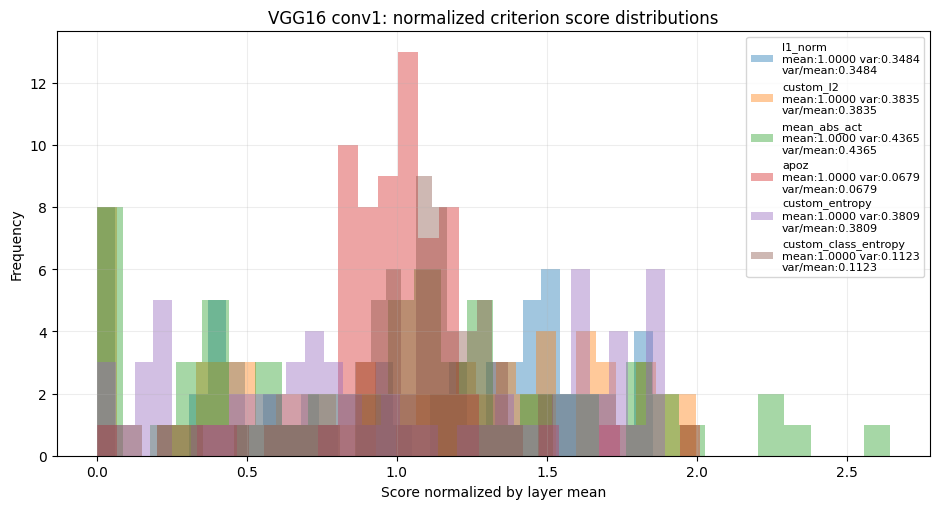

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/paper_style_diagnostics/vgg16_conv1_normalized_score_histograms_local.png


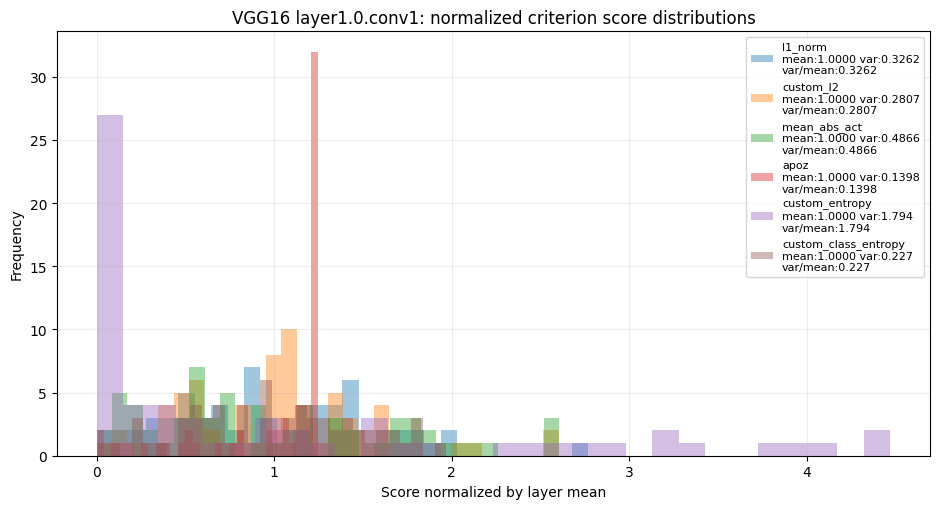

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/paper_style_diagnostics/vgg16_layer1_0_conv1_normalized_score_histograms_local.png


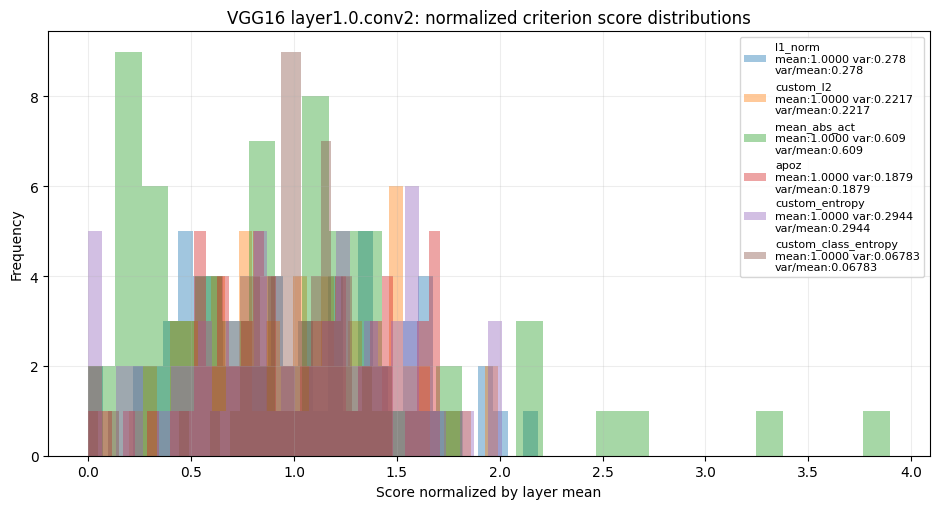

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/paper_style_diagnostics/vgg16_layer1_0_conv2_normalized_score_histograms_local.png


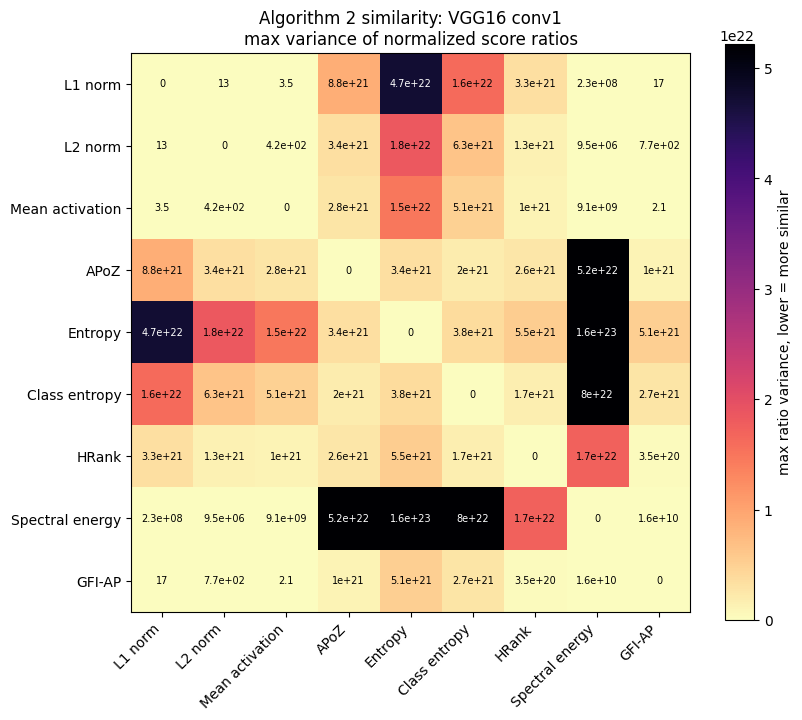

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/paper_style_diagnostics/vgg16_conv1_algorithm2_ratio_variance_heatmap_local.png


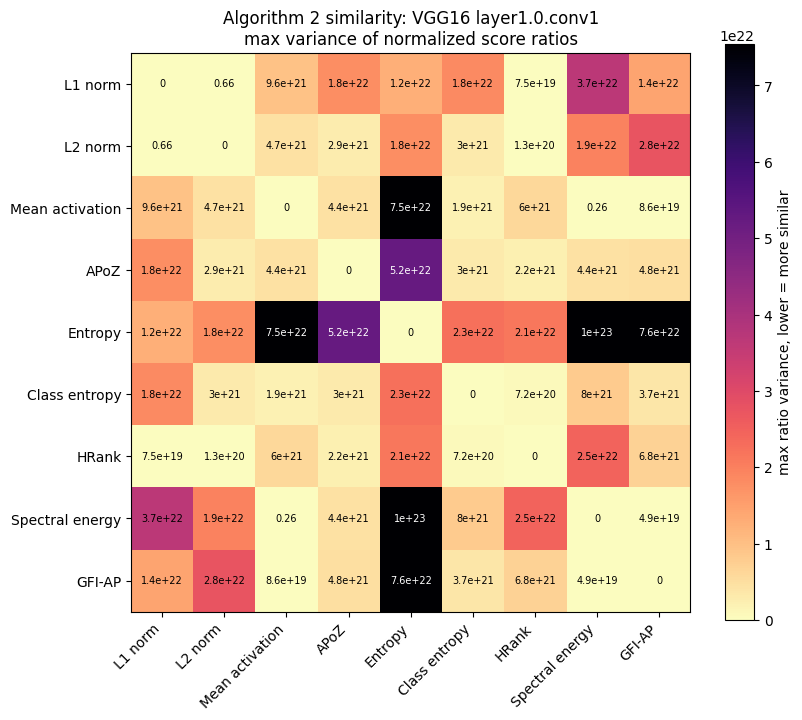

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/paper_style_diagnostics/vgg16_layer1_0_conv1_algorithm2_ratio_variance_heatmap_local.png


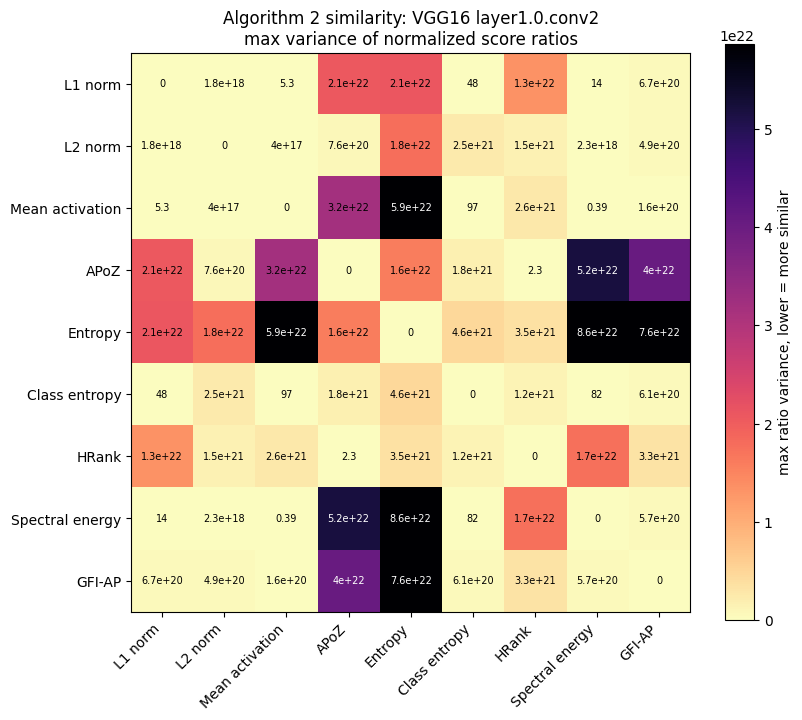

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/paper_style_diagnostics/vgg16_layer1_0_conv2_algorithm2_ratio_variance_heatmap_local.png


In [14]:
# [ReduCNN LFPC cell note]
# Purpose: Experiment helper or execution cell.
# Mechanics: It defines helper functions or executes a notebook-specific step used by the LFPC pruning workflow.
# Expected result: The following cells can reuse the variables, functions, or artifacts created here.

def _safe_read_csv(path):
    try:
        if path is None or not path.exists() or path.stat().st_size == 0:
            return pd.DataFrame()
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        print("Ignoring empty CSV:", path)
        return pd.DataFrame()

# Paper-style diagnostics adapted to our VGG16 candidate methods.
# Table: top-k pruned filter indices per criterion/layer.
# Figures: normalized score histograms and Algorithm-2 max-ratio-variance heatmaps.

import inspect
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Safety checks
# ---------------------------------------------------------------------

if "METHOD_METADATA" not in globals():
    raise NameError("METHOD_METADATA must be defined before running diagnostics")

if "score_maps" not in globals() or not score_maps:
    raise RuntimeError("score_maps is missing or empty. Run the scoring cell first.")

if "METHODS_BY_SCOPE" not in globals():
    raise NameError("METHODS_BY_SCOPE must be defined before running diagnostics")

if "common_layers_by_scope" not in globals():
    raise NameError("common_layers_by_scope must be defined before running diagnostics")

if "OUT_DIR" not in globals():
    raise NameError("OUT_DIR must be defined before running diagnostics")


# ---------------------------------------------------------------------
# Diagnostic config
# ---------------------------------------------------------------------

DIAGNOSTIC_TOP_K = 8

if "SELECTED_SCOPE_FOR_DEMO" in globals() and SELECTED_SCOPE_FOR_DEMO in METHODS_BY_SCOPE:
    DIAGNOSTIC_SCOPE = SELECTED_SCOPE_FOR_DEMO
else:
    DIAGNOSTIC_SCOPE = next(iter(METHODS_BY_SCOPE))

if "SELECTED_PRUNE_RATIO_FOR_DEMO" in globals():
    DIAGNOSTIC_RATIO = float(SELECTED_PRUNE_RATIO_FOR_DEMO)
elif "PRUNE_RATIOS" in globals() and len(PRUNE_RATIOS):
    DIAGNOSTIC_RATIO = float(PRUNE_RATIOS[0])
else:
    DIAGNOSTIC_RATIO = 0.30

if "SELECTED_VARIANCE_THRESHOLD_FOR_DEMO" in globals():
    DIAGNOSTIC_VARIANCE_THRESHOLD = float(SELECTED_VARIANCE_THRESHOLD_FOR_DEMO)
elif "VARIANCE_THRESHOLDS" in globals() and len(VARIANCE_THRESHOLDS):
    DIAGNOSTIC_VARIANCE_THRESHOLD = float(VARIANCE_THRESHOLDS[0])
else:
    DIAGNOSTIC_VARIANCE_THRESHOLD = 0.01

DIAGNOSTIC_METHOD_PRIORITY = [
    "l1_norm",
    "custom_l2",
    "mean_abs_act",
    "apoz",
    "custom_entropy",
    "custom_class_entropy",
    "custom_hrank",
    "custom_spectral_energy",
    "chip",
    "custom_reprune",
    "custom_tis",
    "custom_nisp",
]


# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------

def _layer_sort_key(layer):
    text = str(layer)
    if "." in text:
        prefix, suffix = text.rsplit(".", 1)
        try:
            return (prefix, int(suffix))
        except Exception:
            pass
    return (text, 10**9)


def _as_1d_float_array(values):
    arr = np.asarray(values, dtype=np.float64)
    return arr.reshape(-1)


def _metadata_direction(method):
    """
    Resolve score direction from METHOD_METADATA.

    Supported conventions:
    - lower_is_more_pruneable
    - higher_is_more_pruneable
    - higher_is_more_important
    - lower_is_more_important
    """
    meta = METHOD_METADATA.get(method, {}) if isinstance(METHOD_METADATA, dict) else {}

    direction = (
        meta.get("score_direction")
        or meta.get("direction")
        or meta.get("importance_direction")
        or "lower_is_more_pruneable"
    )

    return str(direction)


def _fallback_orient_scores(values, method):
    """
    Fallback orientation if orient_scores_for_pruning is unavailable
    or has an incompatible signature.

    Output convention:
    lower score = more pruneable
    """
    arr = _as_1d_float_array(values)
    direction = _metadata_direction(method)

    if direction == "lower_is_more_pruneable":
        return arr

    if direction == "higher_is_more_pruneable":
        return -arr

    if direction == "higher_is_more_important":
        # Higher importance means less pruneable.
        # Therefore lower raw scores are more pruneable already.
        return arr

    if direction == "lower_is_more_important":
        # Lower importance means less pruneable.
        # Invert so lower oriented values become more pruneable.
        return -arr

    # Common special case: APOZ often means higher zero-activation percentage
    # means more pruneable. If metadata is missing, protect this case.
    if str(method).lower() == "apoz":
        return -arr

    raise ValueError(
        f"Unknown score direction for method={method}: {direction}. "
        "Set METHOD_METADATA[method]['score_direction'] explicitly."
    )


def _oriented_scores(method, values):
    """
    Robust wrapper around orient_scores_for_pruning.

    Supports both signatures:
    - orient_scores_for_pruning(values, method)
    - orient_scores_for_pruning(values, method, METHOD_METADATA)

    Falls back to metadata-based orientation if needed.
    """
    if "orient_scores_for_pruning" not in globals():
        return _fallback_orient_scores(values, method)

    fn = orient_scores_for_pruning

    # Try 2-argument version first because your current notebook error says
    # orient_scores_for_pruning() takes 2 positional arguments.
    try:
        return _as_1d_float_array(fn(values, method))
    except TypeError:
        pass
    except Exception as exc:
        print(f"orient_scores_for_pruning(values, method) failed for {method_display_name(method)}: {exc}")

    # Try 3-argument version for older/newer notebook variants.
    try:
        return _as_1d_float_array(fn(values, method, METHOD_METADATA))
    except TypeError:
        pass
    except Exception as exc:
        print(f"orient_scores_for_pruning(values, method, METHOD_METADATA) failed for {method_display_name(method)}: {exc}")

    # Fallback.
    return _fallback_orient_scores(values, method)


def _normalize_scores_fallback(values, eps=None):
    """
    Safe mean-normalization fallback.
    """
    arr = _as_1d_float_array(values)

    if eps is None:
        eps = max(1e-12, np.finfo(arr.dtype).eps * 100)

    finite = np.isfinite(arr)
    if not finite.any():
        return np.ones_like(arr, dtype=np.float64)

    finite_values = arr[finite]
    arr = np.nan_to_num(
        arr,
        nan=float(np.median(finite_values)),
        posinf=float(np.max(finite_values)),
        neginf=float(np.min(finite_values)),
    )

    if arr.size == 0:
        return arr

    if np.allclose(arr, arr[0], rtol=0.0, atol=eps):
        return np.ones_like(arr, dtype=np.float64)

    arr = arr - np.min(arr) + eps
    mean = np.mean(arr)

    if abs(mean) < eps:
        return np.ones_like(arr, dtype=np.float64)

    out = arr / (mean + eps)

    if not np.all(np.isfinite(out)):
        return np.ones_like(arr, dtype=np.float64)

    return out


def _normalized_by_mean(method, values):
    """
    Robust wrapper around normalize_scores_for_similarity.
    """
    arr = _oriented_scores(method, values)

    if "normalize_scores_for_similarity" in globals():
        try:
            # Newer signature may support log_constant_scores.
            return _as_1d_float_array(
                normalize_scores_for_similarity(arr, log_constant_scores=False)
            )
        except TypeError:
            # Older signature may not support log_constant_scores.
            try:
                return _as_1d_float_array(normalize_scores_for_similarity(arr))
            except Exception:
                pass
        except Exception:
            pass

    return _normalize_scores_fallback(arr)


def _top_pruned_indices(method, values, k=8):
    """
    Return top-k prune candidates under the convention:
    lower oriented score = more pruneable.
    """
    arr = _oriented_scores(method, values)

    if arr.size == 0:
        return []

    k = min(int(k), arr.size)

    return np.argsort(arr, kind="mergesort")[:k].astype(int).tolist()


def _safe_json_dump(path, obj):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, default=str)


# ---------------------------------------------------------------------
# Select methods and layers
# ---------------------------------------------------------------------

scope_methods = [
    m
    for m in DIAGNOSTIC_METHOD_PRIORITY
    if m in METHODS_BY_SCOPE.get(DIAGNOSTIC_SCOPE, [])
    and m in score_maps
]

if not scope_methods:
    scope_methods = [
        m
        for m in METHODS_BY_SCOPE.get(DIAGNOSTIC_SCOPE, [])
        if m in score_maps
    ]

scope_layers = sorted(
    common_layers_by_scope.get(DIAGNOSTIC_SCOPE, []),
    key=_layer_sort_key,
)

preferred_vgg_layers = ["features.5", "features.7", "features.10"]
diagnostic_layers = [
    layer
    for layer in preferred_vgg_layers
    if layer in scope_layers
]

if not diagnostic_layers:
    diagnostic_layers = scope_layers[: min(3, len(scope_layers))]

paper_diag_dir = OUT_DIR / "paper_style_diagnostics"
paper_diag_dir.mkdir(parents=True, exist_ok=True)

print("Paper-style diagnostics")
print("- scope:", DIAGNOSTIC_SCOPE)
print("- ratio:", DIAGNOSTIC_RATIO)
print("- variance threshold:", DIAGNOSTIC_VARIANCE_THRESHOLD)
print("- methods:", clean_method_sequence(scope_methods))
print("- layers:", diagnostic_layers)


# ---------------------------------------------------------------------
# Table: top-k pruned filter indices
# ---------------------------------------------------------------------

filter_index_rows = []

for layer in diagnostic_layers:
    conv_position = scope_layers.index(layer) + 1 if layer in scope_layers else None

    for method in scope_methods:
        if layer not in score_maps.get(method, {}):
            continue

        raw = _oriented_scores(method, score_maps[method][layer])
        norm = _normalized_by_mean(method, score_maps[method][layer])
        top_indices = _top_pruned_indices(
            method,
            score_maps[method][layer],
            DIAGNOSTIC_TOP_K,
        )

        filter_index_rows.append({
            "dataset": globals().get("DATASET_KEY", ""),
            "model": globals().get("MODEL_TARGET", ""),
            "scope": DIAGNOSTIC_SCOPE,
            "layer": layer,
            "vgg16_conv_position": conv_position,
            "criterion": method,
            "score_direction": _metadata_direction(method),
            "top_pruned_filter_indices": top_indices,
            "top_pruned_filter_indices_text": str(top_indices),
            "num_filters": int(raw.size),
            "raw_score_mean": float(np.mean(raw)) if raw.size else np.nan,
            "raw_score_variance": float(np.var(raw, ddof=1)) if raw.size > 1 else 0.0,
            "normalized_score_mean": float(np.mean(norm)) if norm.size else np.nan,
            "normalized_score_variance": float(np.var(norm, ddof=1)) if norm.size > 1 else 0.0,
            "normalized_variance_over_mean": (
                float(np.var(norm, ddof=1) / max(np.mean(norm), 1e-12))
                if norm.size > 1
                else 0.0
            ),
        })

filter_index_df = pd.DataFrame(filter_index_rows)

filter_index_path = paper_diag_dir / f"vgg16_top{DIAGNOSTIC_TOP_K}_pruned_filter_indices_{DIAGNOSTIC_SCOPE}.csv"
filter_index_json_path = paper_diag_dir / f"vgg16_top{DIAGNOSTIC_TOP_K}_pruned_filter_indices_{DIAGNOSTIC_SCOPE}.json"

filter_index_df.to_csv(filter_index_path, index=False)
_safe_json_dump(filter_index_json_path, filter_index_rows)

print("Saved", filter_index_path)
print("Saved", filter_index_json_path)

if not filter_index_df.empty:
    table_cols = [
        "criterion",
        "model",
        "layer",
        "vgg16_conv_position",
        "score_direction",
        "top_pruned_filter_indices_text",
    ]

    try:
        display(filter_index_df[table_cols])
    except NameError:
        print(filter_index_df[table_cols].to_string(index=False))


# ---------------------------------------------------------------------
# Compact LaTeX table for report/paper draft
# ---------------------------------------------------------------------

latex_path = paper_diag_dir / f"vgg16_top{DIAGNOSTIC_TOP_K}_pruned_filter_indices_{DIAGNOSTIC_SCOPE}.tex"

if not filter_index_df.empty:
    latex_df = filter_index_df[
        [
            "criterion",
            "layer",
            "vgg16_conv_position",
            "top_pruned_filter_indices_text",
        ]
    ].copy()

    latex_df = latex_df.rename(columns={
        "criterion": "Criterion",
        "layer": "VGG16 layer",
        "vgg16_conv_position": "Conv position",
        "top_pruned_filter_indices_text": f"Pruned filters index top {DIAGNOSTIC_TOP_K}",
    })

    latex_path.write_text(
        latex_df.to_latex(index=False, escape=True),
        encoding="utf-8",
    )

    print("Saved", latex_path)


# ---------------------------------------------------------------------
# Histograms of normalized scores
# ---------------------------------------------------------------------

for layer in diagnostic_layers:
    fig, ax = plt.subplots(figsize=(9.5, 5.2))
    plotted = 0

    for method in scope_methods[:6]:
        if layer not in score_maps.get(method, {}):
            continue

        norm = _normalized_by_mean(method, score_maps[method][layer])

        if norm.size == 0:
            continue

        mean = float(np.mean(norm))
        var = float(np.var(norm, ddof=1)) if norm.size > 1 else 0.0
        var_mean = float(var / max(mean, 1e-12))

        ax.hist(
            norm,
            bins=min(30, max(8, norm.size // 2)),
            alpha=0.42,
            label=(
                f"{method}\n"
                f"mean:{mean:.4f} var:{var:.4g}\n"
                f"var/mean:{var_mean:.4g}"
            ),
        )

        plotted += 1

    if plotted:
        ax.set_title(f"VGG16 {layer}: normalized criterion score distributions")
        ax.set_xlabel("Score normalized by layer mean")
        ax.set_ylabel("Frequency")
        ax.grid(alpha=0.22)
        ax.legend(fontsize=8, frameon=True)
        fig.tight_layout()

        out = paper_diag_dir / f"vgg16_{layer.replace('.', '_')}_normalized_score_histograms_{DIAGNOSTIC_SCOPE}.png"
        fig.savefig(out, dpi=180)
        plt.show()

        print("Saved", out)
    else:
        plt.close(fig)


# ---------------------------------------------------------------------
# Algorithm-2 max-ratio-variance heatmap by diagnostic layer
# ---------------------------------------------------------------------

if "similarity_df" not in globals() or similarity_df is None:
    details_path = OUT_DIR / "algorithm2_threshold_grid_details.csv"
    similarity_df = _safe_read_csv(details_path)
elif not isinstance(similarity_df, pd.DataFrame):
    similarity_df = pd.DataFrame(similarity_df)
if not similarity_df.empty and "ratio" not in similarity_df.columns and "prune_ratio" in similarity_df.columns:
    similarity_df = similarity_df.copy()
    similarity_df["ratio"] = similarity_df["prune_ratio"]

if similarity_df.empty:
    print("similarity_df is missing or empty; skipping Algorithm-2 heatmaps.")
else:
    # Ensure required columns exist.
    required_similarity_cols = {
        "scope",
        "ratio",
        "variance_threshold",
        "layer",
        "method_a",
        "method_b",
        "max_ratio_variance",
    }

    missing_cols = required_similarity_cols - set(similarity_df.columns)

    if missing_cols:
        print("similarity_df missing columns; skipping heatmaps:", missing_cols)
    else:
        for layer in diagnostic_layers:
            sub = similarity_df[
                (similarity_df["scope"].astype(str) == str(DIAGNOSTIC_SCOPE))
                & np.isclose(similarity_df["ratio"].astype(float), float(DIAGNOSTIC_RATIO))
                & np.isclose(
                    similarity_df["variance_threshold"].astype(float),
                    float(DIAGNOSTIC_VARIANCE_THRESHOLD),
                )
                & (similarity_df["layer"].astype(str) == str(layer))
            ].copy()

            if sub.empty:
                print(f"No Algorithm-2 similarity rows for layer={layer}; skipping heatmap.")
                continue

            methods = sorted(
                set(sub["method_a"]).union(set(sub["method_b"])),
                key=lambda m: scope_methods.index(m) if m in scope_methods else 999,
            )

            matrix = pd.DataFrame(
                np.nan,
                index=methods,
                columns=methods,
                dtype=float,
            )

            for _, row in sub.iterrows():
                a, b = row["method_a"], row["method_b"]

                try:
                    value = float(row["max_ratio_variance"])
                except Exception:
                    value = np.nan

                matrix.loc[a, b] = value
                matrix.loc[b, a] = value

            np.fill_diagonal(matrix.values, 0.0)

            finite = matrix.values[np.isfinite(matrix.values)]
            vmax = float(np.percentile(finite, 95)) if finite.size else 1.0
            vmax = max(vmax, 1e-12)

            fig, ax = plt.subplots(figsize=(8.5, 7.2))

            im = ax.imshow(
                matrix.fillna(vmax).values,
                cmap="magma_r",
                vmin=0.0,
                vmax=vmax,
            )

            ax.set_xticks(np.arange(len(methods)))
            ax.set_xticklabels([method_display_name(m) for m in methods], rotation=45, ha="right")
            ax.set_yticks(np.arange(len(methods)))
            ax.set_yticklabels([method_display_name(m) for m in methods])

            ax.set_title(
                f"Algorithm 2 similarity: VGG16 {layer}\n"
                "max variance of normalized score ratios"
            )

            for i in range(len(methods)):
                for j in range(len(methods)):
                    value = matrix.iloc[i, j]

                    if np.isfinite(value):
                        label = f"{value:.2g}"

                        ax.text(
                            j,
                            i,
                            label,
                            ha="center",
                            va="center",
                            fontsize=7,
                            color="white" if value > vmax * 0.55 else "black",
                        )

            fig.colorbar(
                im,
                ax=ax,
                label="max ratio variance, lower = more similar",
            )

            fig.tight_layout()

            out = paper_diag_dir / f"vgg16_{layer.replace('.', '_')}_algorithm2_ratio_variance_heatmap_{DIAGNOSTIC_SCOPE}.png"
            fig.savefig(out, dpi=180)
            plt.show()

            print("Saved", out)


<!-- reduc_nn_lfpc_cell_doc -->
### Code cell 14: Experiment helper or execution cell

**Context.** This cell belongs to the `FLOPs + Accuracy` LFPC experiment for `Cats-vs-Dogs` with `ResNet18`.

**What it does.** Experiment helper or execution cell.

**How it works.** It defines helper functions or executes a notebook-specific step used by the LFPC pruning workflow.

**Expected result.** The following cells can reuse the variables, functions, or artifacts created here.

If this cell fails, inspect the active dataset/model/objective context and the artifact paths printed by the notebook before continuing.

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/broad_similarity_overview/algorithm2_pairwise_similarity_overview.csv


,scope,ratio,variance_threshold,method_a,method_b,layers_checked,equivalent_layers,equivalent_layer_rate,mean_spearman_rank_corr,mean_prune_set_jaccard,median_max_ratio_variance
25,global,0.3,0.05,custom_senpis,custom_dcp,4,4,1.0,1.000000,1.000000,3.371791e-06
26,global,0.3,0.05,custom_senpis,custom_gfs,4,4,1.0,0.994777,0.926421,9.288244e-03
10,global,0.3,0.05,custom_gfs,custom_dcp,4,4,1.0,0.994777,0.926421,9.288244e-03
0,global,0.3,0.05,chip,custom_autodfp,4,0,0.0,0.904585,0.563518,2.623031e-01
28,global,0.3,0.05,custom_senpis,custom_tis,4,0,0.0,0.679436,0.495327,2.351476e+20
33,global,0.3,0.05,custom_tis,custom_dcp,4,0,0.0,0.679436,0.495327,2.351477e+20
34,global,0.3,0.05,custom_tis,custom_gfs,4,0,0.0,0.669438,0.494551,2.394890e+20
17,global,0.3,0.05,custom_reprune,custom_autodfp,4,0,0.0,0.716025,0.413150,1.616123e+15
3,global,0.3,0.05,chip,custom_nisp,4,0,0.0,0.733762,0.404193,2.401092e+00
11,global,0.3,0.05,custom_nisp,custom_autodfp,4,0,0.0,0.757943,0.396025,2.466400e-01


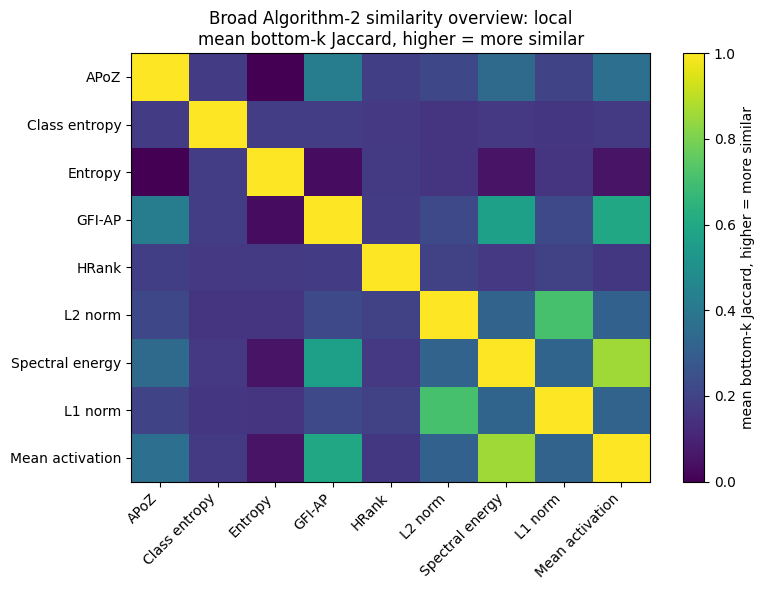

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/broad_similarity_overview/broad_algorithm2_mean_prune_set_jaccard_local.png


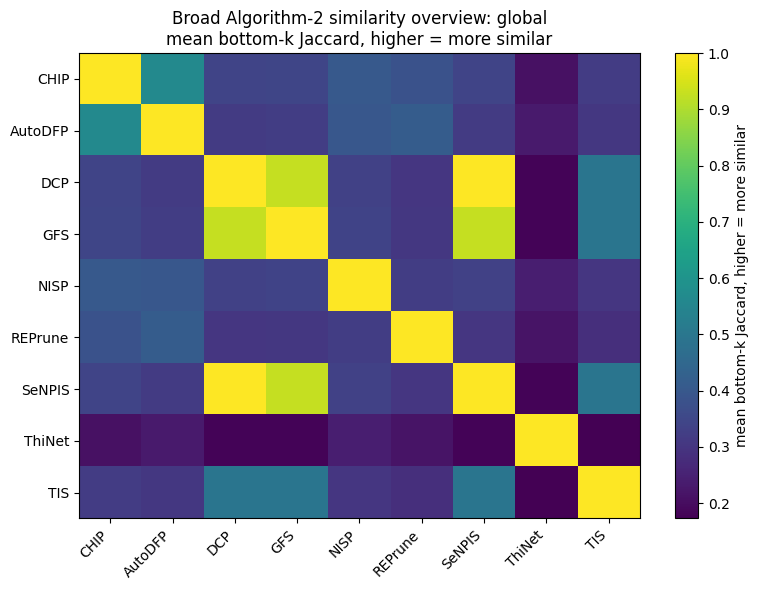

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/broad_similarity_overview/broad_algorithm2_mean_prune_set_jaccard_global.png


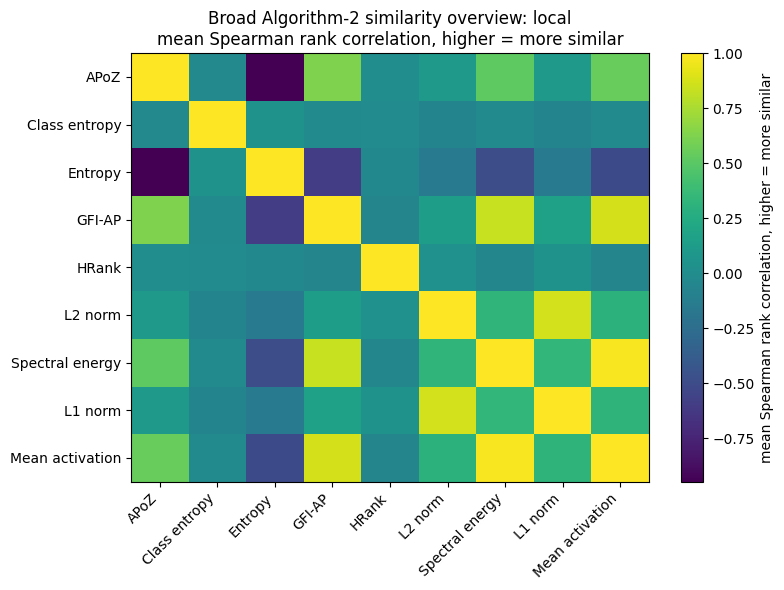

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/broad_similarity_overview/broad_algorithm2_mean_spearman_rank_corr_local.png


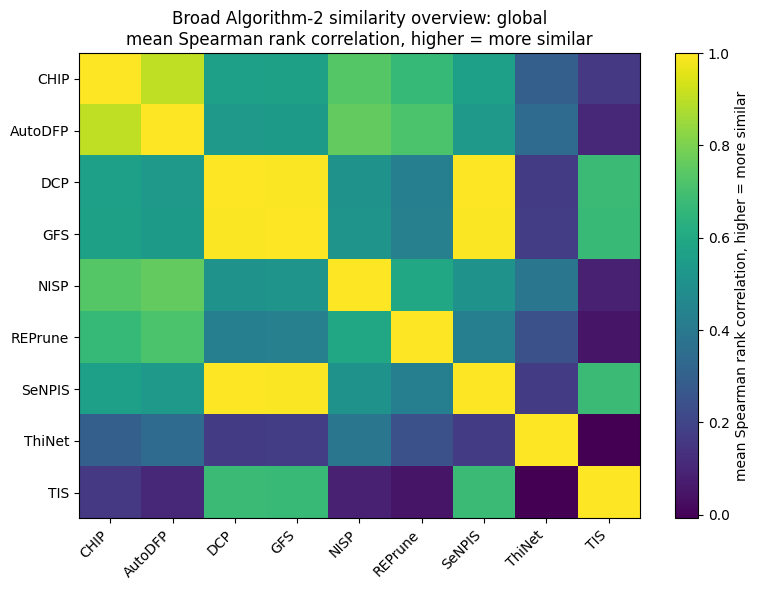

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/broad_similarity_overview/broad_algorithm2_mean_spearman_rank_corr_global.png


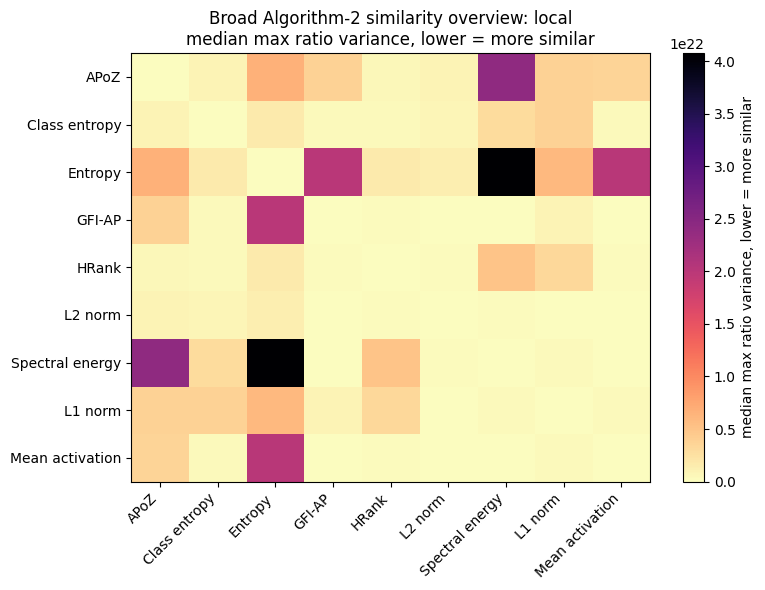

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/broad_similarity_overview/broad_algorithm2_median_max_ratio_variance_local.png


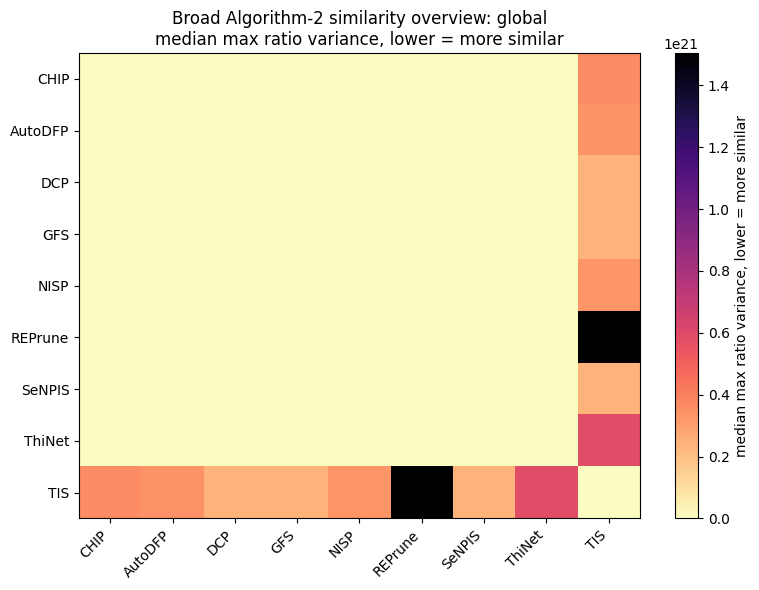

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/broad_similarity_overview/broad_algorithm2_median_max_ratio_variance_global.png


In [15]:
# [ReduCNN LFPC cell note]
# Purpose: Experiment helper or execution cell.
# Mechanics: It defines helper functions or executes a notebook-specific step used by the LFPC pruning workflow.
# Expected result: The following cells can reuse the variables, functions, or artifacts created here.

def _safe_read_csv(path):
    try:
        if path is None or not path.exists() or path.stat().st_size == 0:
            return pd.DataFrame()
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        print("Ignoring empty CSV:", path)
        return pd.DataFrame()


# Broad Algorithm-2 similarity overview across all available method pairs.
# This complements the paper-style top-index table by summarizing every pair,
# across all scored VGG16 layers, for each scope/ratio/threshold condition.
broad_similarity_dir = OUT_DIR / "broad_similarity_overview"
broad_similarity_dir.mkdir(exist_ok=True)

if "similarity_df" not in globals() or similarity_df is None:
    details_path = OUT_DIR / "algorithm2_threshold_grid_details.csv"
    similarity_df = _safe_read_csv(details_path)
elif not isinstance(similarity_df, pd.DataFrame):
    similarity_df = pd.DataFrame(similarity_df)
if not similarity_df.empty and "ratio" not in similarity_df.columns and "prune_ratio" in similarity_df.columns:
    similarity_df = similarity_df.copy()
    similarity_df["ratio"] = similarity_df["prune_ratio"]

required_similarity_cols = {"scope", "ratio", "variance_threshold", "method_a", "method_b"}
missing_similarity_cols = required_similarity_cols - set(similarity_df.columns)

if similarity_df.empty or missing_similarity_cols:
    broad_similarity_df = pd.DataFrame()
    if missing_similarity_cols:
        print("similarity_df missing columns; skipping broad Algorithm-2 overview:", sorted(missing_similarity_cols))
    else:
        print("No Algorithm-2 similarity rows available for broad overview.")
else:
    broad_rows = []
    group_cols = ["scope", "ratio", "variance_threshold", "method_a", "method_b"]
    for keys, grp in similarity_df.groupby(group_cols, dropna=False):
        scope, ratio, variance_threshold, method_a, method_b = keys
        pass_all = grp["is_equivalent"].astype(bool) if "is_equivalent" in grp else pd.Series([], dtype=bool)
        broad_rows.append({
            "dataset": DATASET_KEY,
            "model": MODEL_TARGET,
            "scope": scope,
            "ratio": float(ratio),
            "variance_threshold": float(variance_threshold),
            "method_a": method_a,
            "method_b": method_b,
            "layers_checked": int(len(grp)),
            "equivalent_layers": int(pass_all.sum()) if len(pass_all) else 0,
            "equivalent_layer_rate": float(pass_all.mean()) if len(pass_all) else 0.0,
            "mean_spearman_rank_corr": float(grp["spearman_rank_corr"].mean()) if "spearman_rank_corr" in grp else np.nan,
            "median_spearman_rank_corr": float(grp["spearman_rank_corr"].median()) if "spearman_rank_corr" in grp else np.nan,
            "mean_prune_set_jaccard": float(grp["prune_set_jaccard"].mean()) if "prune_set_jaccard" in grp else np.nan,
            "median_prune_set_jaccard": float(grp["prune_set_jaccard"].median()) if "prune_set_jaccard" in grp else np.nan,
            "median_max_ratio_variance": float(grp["max_ratio_variance"].median()) if "max_ratio_variance" in grp else np.nan,
            "min_max_ratio_variance": float(grp["max_ratio_variance"].min()) if "max_ratio_variance" in grp else np.nan,
            "pass_variance_layers": int(grp["pass_variance"].astype(bool).sum()) if "pass_variance" in grp else np.nan,
            "pass_spearman_layers": int(grp["pass_spearman"].astype(bool).sum()) if "pass_spearman" in grp else np.nan,
            "pass_jaccard_layers": int(grp["pass_jaccard"].astype(bool).sum()) if "pass_jaccard" in grp else np.nan,
        })
    broad_similarity_df = pd.DataFrame(broad_rows).sort_values(
        ["scope", "ratio", "variance_threshold", "equivalent_layer_rate", "mean_prune_set_jaccard", "mean_spearman_rank_corr"],
        ascending=[True, True, True, False, False, False],
    )
    broad_path = broad_similarity_dir / "algorithm2_pairwise_similarity_overview.csv"
    broad_similarity_df.to_csv(broad_path, index=False)
    with open(broad_similarity_dir / "algorithm2_pairwise_similarity_overview.json", "w", encoding="utf-8") as f:
        json.dump(broad_rows, f, indent=2, default=str)
    print("Saved", broad_path)
    display_cols = [
        "scope", "ratio", "variance_threshold", "method_a", "method_b",
        "layers_checked", "equivalent_layers", "equivalent_layer_rate",
        "mean_spearman_rank_corr", "mean_prune_set_jaccard", "median_max_ratio_variance",
    ]
    try:
        display(broad_similarity_df[display_cols].head(40))
    except NameError:
        print(broad_similarity_df[display_cols].head(40).to_string(index=False))

    # Heatmaps for a broader overview at the selected condition.
    for metric, label, cmap, lower_better in [
        ("mean_prune_set_jaccard", "mean bottom-k Jaccard, higher = more similar", "viridis", False),
        ("mean_spearman_rank_corr", "mean Spearman rank correlation, higher = more similar", "viridis", False),
        ("median_max_ratio_variance", "median max ratio variance, lower = more similar", "magma_r", True),
    ]:
        for scope in DEMO_SCOPES:
            sub = broad_similarity_df[
                (broad_similarity_df["scope"] == scope)
                & (broad_similarity_df["ratio"].astype(float) == float(SELECTED_PRUNE_RATIO_FOR_DEMO))
                & (broad_similarity_df["variance_threshold"].astype(float) == float(SELECTED_VARIANCE_THRESHOLD_FOR_DEMO))
            ]
            if sub.empty or metric not in sub:
                continue
            methods = sorted(set(sub["method_a"]).union(set(sub["method_b"])))
            matrix = pd.DataFrame(np.nan, index=methods, columns=methods, dtype=float)
            for _, row in sub.iterrows():
                matrix.loc[row["method_a"], row["method_b"]] = float(row[metric])
                matrix.loc[row["method_b"], row["method_a"]] = float(row[metric])
            diag_value = 0.0 if lower_better else 1.0
            np.fill_diagonal(matrix.values, diag_value)
            finite = matrix.values[np.isfinite(matrix.values)]
            if finite.size == 0:
                continue
            fill = float(np.nanmedian(finite))
            fig, ax = plt.subplots(figsize=(max(8, 0.55 * len(methods)), max(6, 0.45 * len(methods))))
            im = ax.imshow(matrix.fillna(fill).values, cmap=cmap, aspect="auto")
            ax.set_xticks(np.arange(len(methods)))
            ax.set_xticklabels([method_display_name(m) for m in methods], rotation=45, ha="right")
            ax.set_yticks(np.arange(len(methods)))
            ax.set_yticklabels([method_display_name(m) for m in methods])
            ax.set_title(f"Broad Algorithm-2 similarity overview: {scope}\n{label}")
            fig.colorbar(im, ax=ax, label=label)
            fig.tight_layout()
            out = broad_similarity_dir / f"broad_algorithm2_{metric}_{scope}.png"
            fig.savefig(out, dpi=180)
            plt.show()
            print("Saved", out)


<!-- reduc_nn_lfpc_cell_doc -->
### Code cell 15: Experiment helper or execution cell

**Context.** This cell belongs to the `FLOPs + Accuracy` LFPC experiment for `Cats-vs-Dogs` with `ResNet18`.

**What it does.** Experiment helper or execution cell.

**How it works.** It defines helper functions or executes a notebook-specific step used by the LFPC pruning workflow.

**Expected result.** The following cells can reuse the variables, functions, or artifacts created here.

If this cell fails, inspect the active dataset/model/objective context and the artifact paths printed by the notebook before continuing.

In [16]:
# [ReduCNN LFPC cell note]
# Purpose: Experiment helper or execution cell.
# Mechanics: It defines helper functions or executes a notebook-specific step used by the LFPC pruning workflow.
# Expected result: The following cells can reuse the variables, functions, or artifacts created here.

def _safe_read_csv(path):
    try:
        if path is None or not path.exists() or path.stat().st_size == 0:
            return pd.DataFrame()
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        print("Ignoring empty CSV:", path)
        return pd.DataFrame()


# Process 1: LFPC stack discovery only.
# Algorithm 2 + LFPC are used here to discover frozen layer-wise pruning stacks.
# No benchmark runtime is reported from this cell, and no policy-search overhead is mixed into pruning benchmarks.
# Phase-1 additions:
#   - same pruning ratio is used for discovery and fixed-stack benchmark
#   - Algorithm 2 threshold grid includes variance, Spearman, and Jaccard
#   - LFPC objective includes task loss + method-cost penalty + FLOPs/proxy penalty + entropy penalty
#   - LFPC probabilities receive confidence diagnostics and fallback handling
import copy
import torch

def _load_algorithm2_candidates_if_needed():
    """Rebuild Process-1 inputs from Algorithm-2 artifacts after a restart.

    Process 1 consumes representatives_by_condition and substitution_df. Those
    are derived products of the Algorithm-2 threshold grid, so they can be
    reconstructed from algorithm2_candidates_by_config.json and
    algorithm2_threshold_grid_details.csv without rerunning scoring.
    """
    global algorithm2_candidates_by_config, representatives_by_condition, substitution_df, similarity_df

    if "algorithm2_candidates_by_config" not in globals() or algorithm2_candidates_by_config is None:
        candidates_path = OUT_DIR / "algorithm2_candidates_by_config.json"
        if candidates_path.exists():
            with open(candidates_path, "r", encoding="utf-8") as f:
                algorithm2_candidates_by_config = json.load(f)
        else:
            algorithm2_candidates_by_config = {}

    if "similarity_df" not in globals() or similarity_df is None:
        details_path = OUT_DIR / "algorithm2_threshold_grid_details.csv"
        similarity_df = _safe_read_csv(details_path)
    elif not isinstance(similarity_df, pd.DataFrame):
        similarity_df = pd.DataFrame(similarity_df)
    if not similarity_df.empty and "ratio" not in similarity_df.columns and "prune_ratio" in similarity_df.columns:
        similarity_df = similarity_df.copy()
        similarity_df["ratio"] = similarity_df["prune_ratio"]

    if "representatives_by_condition" not in globals() or representatives_by_condition is None:
        representatives_by_condition = {}
    if "substitution_df" not in globals() or substitution_df is None:
        substitution_df = pd.DataFrame()

    if representatives_by_condition and isinstance(substitution_df, pd.DataFrame) and not substitution_df.empty:
        return

    rebuilt_substitution_rows = []
    if algorithm2_candidates_by_config:
        rebuilt_reps = {}
        for _, payload in algorithm2_candidates_by_config.items():
            scope = payload.get("scope")
            ratio = float(payload.get("prune_ratio", payload.get("ratio")))
            variance_threshold = float(payload.get("variance_threshold"))
            spearman_threshold = float(payload.get("spearman_threshold"))
            jaccard_threshold = float(payload.get("jaccard_threshold"))
            key = (scope, ratio, variance_threshold, spearman_threshold, jaccard_threshold)
            candidates_by_layer = payload.get("candidates_by_layer", {}) or {}
            rebuilt_reps[key] = {str(layer): list(methods or []) for layer, methods in candidates_by_layer.items()}
        representatives_by_condition = rebuilt_reps

    if not similarity_df.empty:
        required = {"scope", "ratio", "variance_threshold", "spearman_threshold", "jaccard_threshold", "layer", "method_a", "method_b"}
        if required.issubset(similarity_df.columns):
            for (scope, ratio, variance_threshold, spearman_threshold, jaccard_threshold), grp in similarity_df.groupby(
                ["scope", "ratio", "variance_threshold", "spearman_threshold", "jaccard_threshold"],
                dropna=False,
            ):
                methods_by_layer = {}
                for layer, lg in grp.groupby("layer", dropna=False):
                    methods_by_layer[str(layer)] = sorted(set(lg["method_a"].astype(str)).union(set(lg["method_b"].astype(str))))
                methods = sorted({m for vals in methods_by_layer.values() for m in vals})
                costs = method_cost_map(methods, ratio=float(ratio)) if methods else {}
                representatives, rows = layerwise_similarity_substitutions(
                    grp.to_dict(orient="records"),
                    methods_by_layer=methods_by_layer,
                    method_costs=costs,
                )
                key = (scope, float(ratio), float(variance_threshold), float(spearman_threshold), float(jaccard_threshold))
                if key not in representatives_by_condition:
                    representatives_by_condition[key] = representatives
                for row in rows:
                    row.update({
                        "dataset": DATASET_KEY,
                        "model": MODEL_TARGET,
                        "scope": scope,
                        "ratio": float(ratio),
                        "variance_threshold": float(variance_threshold),
                        "spearman_threshold": float(spearman_threshold),
                        "jaccard_threshold": float(jaccard_threshold),
                        "removed_method": row.get("method") if row.get("was_substituted") else None,
                    })
                rebuilt_substitution_rows.extend(rows)

    if rebuilt_substitution_rows:
        substitution_df = pd.DataFrame(rebuilt_substitution_rows)
    elif not isinstance(substitution_df, pd.DataFrame):
        substitution_df = pd.DataFrame()

    print("Algorithm-2 inputs available for Process 1:", len(representatives_by_condition), "conditions")
    if not representatives_by_condition:
        print("No representatives_by_condition could be loaded. Run the Algorithm-2 threshold grid cell first.")


_load_algorithm2_candidates_if_needed()

if "method_cost_record" not in globals() and "method_efficiency_row" in globals():
    def method_cost_record(method, ratio=None):
        return method_efficiency_row(method, ratio=ratio)

if "algorithm2_time_sec" not in globals():
    algorithm2_time_sec = float(globals().get("algo2_time_sec", 0.0) or 0.0)


def lfpc_conditions_to_run():
    if RUN_LFPC_MATRIX:
        return [
            (s, r, v, sp, jc)
            for s in DEMO_SCOPES
            for r in DEMO_PRUNE_RATIOS
            for (v, sp, jc) in DEMO_THRESHOLD_COMBOS
        ]
    if bool(globals().get("RUN_SELECTED_SCOPE_RATIO_MATRIX", False)):
        return [
            (
                scope,
                ratio,
                SELECTED_VARIANCE_THRESHOLD_FOR_DEMO,
                SELECTED_SPEARMAN_THRESHOLD_FOR_DEMO,
                SELECTED_JACCARD_THRESHOLD_FOR_DEMO,
            )
            for scope in DEMO_SCOPES
            for ratio in DEMO_PRUNE_RATIOS
        ]
    return [
        (
            SELECTED_SCOPE_FOR_DEMO,
            SELECTED_PRUNE_RATIO_FOR_DEMO,
            SELECTED_VARIANCE_THRESHOLD_FOR_DEMO,
            SELECTED_SPEARMAN_THRESHOLD_FOR_DEMO,
            SELECTED_JACCARD_THRESHOLD_FOR_DEMO,
        )
    ]


def filter_layer_candidates_to_score_maps(layer_candidates, score_maps, scope, condition_key=None):
    """Keep only layer/method pairs that exist in current score_maps.

    ResNet18 cats/dogs runs can reload Algorithm-2 artifacts from a previous
    architecture or stale run. This prevents impossible layers such as VGG
    classifier layers from entering LFPC mask construction.
    """
    filtered = {}
    dropped_layers = []
    dropped_pairs = []
    for layer, methods in dict(layer_candidates or {}).items():
        valid = [m for m in list(methods or []) if layer in score_maps.get(m, {})]
        missing = [m for m in list(methods or []) if layer not in score_maps.get(m, {})]
        if valid:
            filtered[str(layer)] = list(dict.fromkeys(valid))
        else:
            dropped_layers.append(str(layer))
        for m in missing:
            dropped_pairs.append({"layer": str(layer), "method": str(m), "scope": str(scope), "condition": str(condition_key)})
    if dropped_layers or dropped_pairs:
        print(
            "Filtered Algorithm-2 candidates to current ResNet18 score maps:",
            "kept_layers=", len(filtered),
            "dropped_layers=", len(dropped_layers),
            "dropped_layer_method_pairs=", len(dropped_pairs),
        )
        try:
            audit_path = OUT_DIR / "filtered_algorithm2_candidates_for_current_score_maps.jsonl"
            with open(audit_path, "a", encoding="utf-8") as f:
                for row in dropped_pairs:
                    f.write(json.dumps(row, default=str) + "\n")
            print("Saved candidate-filter audit:", audit_path)
        except Exception as exc:
            print("Could not save candidate-filter audit:", exc)
    return filtered

lfpc_history_records = []
lfpc_policy_records = []
discovered_stack_records = []

print("Baseline validation accuracy:", baseline_val_acc)
print("Baseline test accuracy:", get_baseline_test_accuracy())
print("Process 1: discovering fixed stacks. Benchmarking happens later in Process 2.")
print("Consistency rule: each discovered stack is benchmarked at the same pruning ratio used during discovery.")

if RUN_STACK_DISCOVERY:
    for scope, ratio, variance_threshold, spearman_threshold, jaccard_threshold in lfpc_conditions_to_run():
        key = (scope, float(ratio), float(variance_threshold), float(spearman_threshold), float(jaccard_threshold))
        if key not in representatives_by_condition:
            print("Skipping missing condition", key)
            continue
        raw_layer_candidates = representatives_by_condition[key]
        layer_candidates = {layer: methods for layer, methods in raw_layer_candidates.items() if methods}
        layer_candidates = filter_layer_candidates_to_score_maps(layer_candidates, score_maps, scope, condition_key=key)
        if not layer_candidates:
            print("Skipping condition with no layer candidates present in current ResNet18 score maps", key)
            continue

        methods = sorted({m for ms in layer_candidates.values() for m in ms})
        ratio_choices = lfpc_layerwise_ratio_choices(ratio, scope=scope) if "lfpc_layerwise_ratio_choices" in globals() else [float(ratio)]
        costs = ratio_candidate_cost_map(methods, ratio_choices, ratio=ratio) if "ratio_candidate_cost_map" in globals() else method_cost_map(methods, ratio=ratio)
        scope_record = assert_scope_consistency(scope, scope)
        print("LFPC discovery condition:", key)
        print("Final fixed-stack pruning scope will use the same scope:", scope)
        print("Final fixed-stack pruning ratio will use the same ratio:", ratio)
        print("Scope consistency check: PASSED")

        layer_masks = build_layerwise_ratio_method_masks(
            score_maps,
            layer_candidates=layer_candidates,
            ratio=ratio,
            scope=scope,
            ratio_choices=ratio_choices,
            method_metadata=METHOD_METADATA,
        ) if "build_layerwise_ratio_method_masks" in globals() else build_method_masks(
            score_maps,
            layer_candidates=layer_candidates,
            ratio=ratio,
            scope=scope,
            method_metadata=METHOD_METADATA,
        )

        layer_weights = layer_flops_proxy_weights(layer_masks)
        sampler_model = copy.deepcopy(baseline_model).to(device)
        sampler = LFPCActivationMaskSampler(
            sampler_model,
            layer_masks,
            costs,
            device=device,
            layer_flops_weights=layer_weights,
        )
        config = LFPCTrainingConfig(
            epochs=max(1, int(CFG.get("lfpc_epochs", 3))),
            tau=1.0,
            lr=0.05,
            lambda_method_cost=LFPC_LAMBDA_METHOD_COST,
            target_cost_ratio=LFPC_TARGET_METHOD_COST_RATIO,
            lambda_task=LFPC_LAMBDA_TASK,
            lambda_flops=LFPC_LAMBDA_FLOPS,
            target_flops_reduction=LFPC_TARGET_FLOPS_REDUCTION,
            lambda_entropy=LFPC_LAMBDA_ENTROPY,
            objective_scenario=OBJECTIVE_SCENARIO,
            objective_terms=OPTIMIZED_OBJECTIVE_TERMS,
            max_allowed_accuracy_drop_pct=MAX_ALLOWED_ACCURACY_DROP_PCT,
            apply_accuracy_drop_constraint=APPLY_ACCURACY_DROP_CONSTRAINT,
            max_batches_per_epoch=CFG.get("policy_max_batches", 8),
        )
        print("Training LFPC discovery policy", key, "layers", len(layer_candidates), "methods", clean_method_sequence(methods), "ratio choices", ratio_choices)
        policy_search_start_time = time.perf_counter()
        history = train_lfpc_sampler(
            sampler_model,
            sampler,
            policy_loader,
            config=config,
            device=device,
        )
        policy_search_time_sec = time.perf_counter() - policy_search_start_time
        for h in history:
            lfpc_history_records.append({
                "dataset": DATASET_KEY,
                "model": MODEL_TARGET,
                "scope": scope,
                "ratio": ratio,
                "variance_threshold": variance_threshold,
                "spearman_threshold": spearman_threshold,
                "jaccard_threshold": jaccard_threshold,
                "threshold_signature": f"v{variance_threshold}_s{spearman_threshold}_j{jaccard_threshold}",
                "objective_scenario": OBJECTIVE_SCENARIO,
                "objective_label": OBJECTIVE_SCENARIO_LABEL,
                "optimized_objective_terms": OPTIMIZED_OBJECTIVE_TERMS,
                "lfpc_objective_description": LFPC_OBJECTIVE_DESCRIPTION,
                "layerwise_ratio_choices": ratio_choices,
                **h,
            })

        final_rows = sampler.final_policy(
            fallback_margin=LFPC_FALLBACK_MARGIN_THRESHOLD,
            fallback_topk=LFPC_FALLBACK_USE_CHEAPEST_TOPK,
        )
        if "normalize_lfpc_ratio_policy_rows" in globals():
            final_rows = normalize_lfpc_ratio_policy_rows(final_rows, default_ratio=ratio)
        selected_methods = sorted({row["selected_method"] for row in final_rows})
        selected_method_cost_sum = sum(float(costs.get(m, 0.0)) for m in selected_methods)
        stack_id = f"LFPC_{OBJECTIVE_SCENARIO}_{DATASET_KEY}_{MODEL_TARGET}_{scope}_r{ratio}_v{variance_threshold}_s{spearman_threshold}_j{jaccard_threshold}"
        policy = {str(row["layer"]): str(row["selected_method"]) for row in final_rows}
        expected_flops_proxy = float(sampler.last_expected_flops_reduction_proxy)

        for row in final_rows:
            layer = row["layer"]
            substitutions = substitution_df[
                (substitution_df["scope"] == scope)
                & (substitution_df["ratio"].astype(float) == float(ratio))
                & (substitution_df["variance_threshold"].astype(float) == float(variance_threshold))
                & (substitution_df["spearman_threshold"].astype(float) == float(spearman_threshold))
                & (substitution_df["jaccard_threshold"].astype(float) == float(jaccard_threshold))
                & (substitution_df["layer"] == layer)
            ] if not substitution_df.empty else pd.DataFrame()
            selected = row["selected_method"]
            selected_subs = substitutions[substitutions["representative"] == selected] if not substitutions.empty and "representative" in substitutions.columns else pd.DataFrame()
            lfpc_policy_records.append({
                "dataset": DATASET_KEY,
                "model": MODEL_TARGET,
                "scope": scope,
                "ratio": ratio,
                "variance_threshold": variance_threshold,
                "spearman_threshold": spearman_threshold,
                "jaccard_threshold": jaccard_threshold,
                "threshold_signature": f"v{variance_threshold}_s{spearman_threshold}_j{jaccard_threshold}",
                "layer": layer,
                "stack_id": stack_id,
                "algorithm2_rule": "substitute only when normalized-ratio variance, Spearman rank correlation, and bottom-k Jaccard all pass",
                "objective_scenario": OBJECTIVE_SCENARIO,
                "objective_label": OBJECTIVE_SCENARIO_LABEL,
                "optimized_objective_terms": OPTIMIZED_OBJECTIVE_TERMS,
                "lfpc_objective": LFPC_OBJECTIVE_DESCRIPTION,
                "selected_method": selected,
                "selected_prune_ratio": row.get("selected_prune_ratio", ratio),
                "selected_method_candidate_token": row.get("selected_method_candidate_token", selected),
                "selected_method_raw": row.get("selected_method_raw"),
                "selected_probability": row.get("selected_probability"),
                "selected_probability_raw": row.get("selected_probability_raw"),
                "runner_up_method": row.get("runner_up_method"),
                "runner_up_probability": row.get("runner_up_probability"),
                "top2_margin": row.get("top2_margin"),
                "entropy": row.get("entropy"),
                "normalized_entropy": row.get("normalized_entropy"),
                "effective_num_methods": row.get("effective_num_methods"),
                "decision_type": row.get("decision_type"),
                "fallback_applied": row.get("fallback_applied"),
                "fallback_reason": row.get("fallback_reason"),
                "candidate_methods_after_algorithm2": row.get("candidate_methods"),
                "candidate_method_tokens_after_algorithm2": row.get("candidate_method_tokens"),
                "candidate_ratio_choices": row.get("candidate_ratio_choices"),
                "probabilities": row.get("probabilities"),
                "probabilities_by_candidate_token": row.get("probabilities_by_candidate_token"),
                "selected_method_estimated_common_cost_sec": method_cost_record(selected, ratio=ratio)["estimated_sec_at_common_budget"],
                "selected_method_raw_cost_sec": method_cost_record(selected, ratio=ratio)["raw_elapsed_sec"],
                "selected_method_batches_used": method_cost_record(selected, ratio=ratio)["batches_used"],
                "selected_method_cost_normalized": float(costs.get(selected, np.nan)),
                "expected_layer_flops_reduction_proxy": row.get("expected_layer_flops_reduction_proxy"),
                "expected_stack_flops_reduction_proxy": expected_flops_proxy,
                "target_flops_reduction": LFPC_TARGET_FLOPS_REDUCTION,
                "lambda_task": LFPC_LAMBDA_TASK,
                "lambda_method_cost": LFPC_LAMBDA_METHOD_COST,
                "lambda_flops": LFPC_LAMBDA_FLOPS,
                "max_allowed_accuracy_drop_pct": MAX_ALLOWED_ACCURACY_DROP_PCT,
                "accuracy_drop_constraint_active": APPLY_ACCURACY_DROP_CONSTRAINT,
                "algorithm2_substitution_applied": bool(not selected_subs.empty),
                "substituted_from": selected_subs["removed_method"].tolist() if not selected_subs.empty and "removed_method" in selected_subs.columns else [],
                "substituted_to": selected,
                "policy_discovery_time_sec": policy_search_time_sec,
                "include_policy_discovery_time_in_runtime": False,
            })

        discovered_stack_records.append({
            "stack_id": stack_id,
            "source": "lfpc_phase1_pairwise_objective_discovery",
            "objective_scenario": OBJECTIVE_SCENARIO,
            "objective_label": OBJECTIVE_SCENARIO_LABEL,
            "optimized_objective_terms": OPTIMIZED_OBJECTIVE_TERMS,
            "lfpc_objective_description": LFPC_OBJECTIVE_DESCRIPTION,
            "dataset": DATASET_KEY,
            "model": MODEL_TARGET,
            "scope": scope,
            "ratio": ratio,
            "benchmark_ratio_must_match_discovery_ratio": True,
            "variance_threshold": variance_threshold,
            "spearman_threshold": spearman_threshold,
            "jaccard_threshold": jaccard_threshold,
            "threshold_signature": f"v{variance_threshold}_s{spearman_threshold}_j{jaccard_threshold}",
            "num_layers": len(policy),
            "selected_methods": selected_methods,
            "selected_method_cost_sum_normalized": selected_method_cost_sum,
            "expected_stack_method_cost_ratio": float(sampler.last_expected_cost_ratio),
            "expected_stack_flops_reduction_proxy": expected_flops_proxy,
            "target_flops_reduction": LFPC_TARGET_FLOPS_REDUCTION,
            "lambda_task": LFPC_LAMBDA_TASK,
            "lambda_method_cost": LFPC_LAMBDA_METHOD_COST,
            "lambda_flops": LFPC_LAMBDA_FLOPS,
            "max_allowed_accuracy_drop_pct": MAX_ALLOWED_ACCURACY_DROP_PCT,
            "accuracy_drop_constraint_active": APPLY_ACCURACY_DROP_CONSTRAINT,
            "num_uncertain_layers": int(sum(1 for row in final_rows if row.get("decision_type") == "uncertain")),
            "num_forced_layers": int(sum(1 for row in final_rows if row.get("decision_type") == "forced")),
            "num_fallback_layers": int(sum(1 for row in final_rows if row.get("fallback_applied"))),
            "layer_policy": policy,
            "layer_ratio_policy": {str(row["layer"]): float(row.get("selected_prune_ratio", ratio)) for row in final_rows},
            "layerwise_ratio_choices": ratio_choices,
            "policy_discovery_time_sec": policy_search_time_sec,
            "algorithm2_time_sec": algorithm2_time_sec,
            "lfpc_training_time_sec": policy_search_time_sec,
            "runtime_note": "Discovery overhead is exported for transparency but excluded from fixed-stack benchmark runtime.",
        })
else:
    print("RUN_STACK_DISCOVERY is False. Expect to load fixed stacks externally before Process 2.")

lfpc_history_df = pd.DataFrame(lfpc_history_records)
lfpc_policy_df = pd.DataFrame(lfpc_policy_records)
discovered_stack_df = pd.DataFrame(discovered_stack_records)

lfpc_history_df.to_csv(OUT_DIR / "lfpc_alpha_history_discovery_phase1.csv", index=False)
lfpc_policy_df.to_csv(OUT_DIR / "lfpc_discovered_layer_policy_phase1.csv", index=False)
discovered_stack_df.to_csv(OUT_DIR / "discovered_fixed_stack_recipes_phase1.csv", index=False)
with open(OUT_DIR / "lfpc_alpha_history_discovery_phase1.json", "w", encoding="utf-8") as f:
    json.dump(lfpc_history_records, f, indent=2, default=str)
with open(OUT_DIR / "lfpc_discovered_layer_policy_phase1.json", "w", encoding="utf-8") as f:
    json.dump(lfpc_policy_records, f, indent=2, default=str)
with open(OUT_DIR / "discovered_fixed_stack_recipes_phase1.json", "w", encoding="utf-8") as f:
    json.dump(discovered_stack_records, f, indent=2, default=str)

print("Saved LFPC phase-1 discovery outputs under", OUT_DIR)
try:
    display(lfpc_policy_df.head(20))
    display(discovered_stack_df[[
        "stack_id", "scope", "ratio", "variance_threshold", "spearman_threshold", "jaccard_threshold",
        "num_layers", "num_uncertain_layers", "num_fallback_layers", "expected_stack_flops_reduction_proxy",
        "selected_methods"
    ]] if not discovered_stack_df.empty else discovered_stack_df)
except NameError:
    print(lfpc_policy_df.head(20).to_string(index=False) if not lfpc_policy_df.empty else "No LFPC policies discovered")
    print(discovered_stack_df.to_string(index=False) if not discovered_stack_df.empty else "No fixed-stack recipes discovered")


Algorithm-2 inputs available for Process 1: 72 conditions
Baseline validation accuracy: 96.09375
Baseline test accuracy: 95.947265625
Process 1: discovering fixed stacks. Benchmarking happens later in Process 2.
Consistency rule: each discovered stack is benchmarked at the same pruning ratio used during discovery.
LFPC discovery condition: ('local', 0.3, 0.05, 0.7, 0.7)
Final fixed-stack pruning scope will use the same scope: local
Final fixed-stack pruning ratio will use the same ratio: 0.3
Scope consistency check: PASSED
Training LFPC discovery policy ('local', 0.3, 0.05, 0.7, 0.7) layers 20 methods ['APoZ', 'Class entropy', 'Entropy', 'GFI-AP', 'HRank', 'L2 norm', 'Spectral energy', 'L1 norm', 'Mean activation'] ratio choices [0.3]
LFPC discovery condition: ('local', 0.45, 0.05, 0.7, 0.7)
Final fixed-stack pruning scope will use the same scope: local
Final fixed-stack pruning ratio will use the same ratio: 0.45
Scope consistency check: PASSED
Training LFPC discovery policy ('local',

,dataset,model,scope,ratio,variance_threshold,spearman_threshold,jaccard_threshold,threshold_signature,layer,stack_id,...,lambda_task,lambda_method_cost,lambda_flops,max_allowed_accuracy_drop_pct,accuracy_drop_constraint_active,algorithm2_substitution_applied,substituted_from,substituted_to,policy_discovery_time_sec,include_policy_discovery_time_in_runtime
0,cats_dogs,resnet18,local,0.3,0.05,0.7,0.7,v0.05_s0.7_j0.7,conv1,LFPC_flops_accuracy_cats_dogs_resnet18_local_r...,...,1.0,0.0,0.35,7.0,False,True,[None],l1_norm,165.282316,False
1,cats_dogs,resnet18,local,0.3,0.05,0.7,0.7,v0.05_s0.7_j0.7,layer1.0.conv1,LFPC_flops_accuracy_cats_dogs_resnet18_local_r...,...,1.0,0.0,0.35,7.0,False,True,[None],custom_hrank,165.282316,False
2,cats_dogs,resnet18,local,0.3,0.05,0.7,0.7,v0.05_s0.7_j0.7,layer1.0.conv2,LFPC_flops_accuracy_cats_dogs_resnet18_local_r...,...,1.0,0.0,0.35,7.0,False,True,[None],mean_abs_act,165.282316,False
3,cats_dogs,resnet18,local,0.3,0.05,0.7,0.7,v0.05_s0.7_j0.7,layer1.1.conv1,LFPC_flops_accuracy_cats_dogs_resnet18_local_r...,...,1.0,0.0,0.35,7.0,False,True,[None],custom_gfi_ap,165.282316,False
4,cats_dogs,resnet18,local,0.3,0.05,0.7,0.7,v0.05_s0.7_j0.7,layer1.1.conv2,LFPC_flops_accuracy_cats_dogs_resnet18_local_r...,...,1.0,0.0,0.35,7.0,False,True,[None],custom_l2,165.282316,False
5,cats_dogs,resnet18,local,0.3,0.05,0.7,0.7,v0.05_s0.7_j0.7,layer2.0.conv1,LFPC_flops_accuracy_cats_dogs_resnet18_local_r...,...,1.0,0.0,0.35,7.0,False,True,[None],custom_l2,165.282316,False
6,cats_dogs,resnet18,local,0.3,0.05,0.7,0.7,v0.05_s0.7_j0.7,layer2.0.conv2,LFPC_flops_accuracy_cats_dogs_resnet18_local_r...,...,1.0,0.0,0.35,7.0,False,True,[None],custom_entropy,165.282316,False
7,cats_dogs,resnet18,local,0.3,0.05,0.7,0.7,v0.05_s0.7_j0.7,layer2.0.downsample.0,LFPC_flops_accuracy_cats_dogs_resnet18_local_r...,...,1.0,0.0,0.35,7.0,False,True,"[None, l1_norm]",custom_l2,165.282316,False
8,cats_dogs,resnet18,local,0.3,0.05,0.7,0.7,v0.05_s0.7_j0.7,layer2.1.conv1,LFPC_flops_accuracy_cats_dogs_resnet18_local_r...,...,1.0,0.0,0.35,7.0,False,True,[None],custom_gfi_ap,165.282316,False
9,cats_dogs,resnet18,local,0.3,0.05,0.7,0.7,v0.05_s0.7_j0.7,layer2.1.conv2,LFPC_flops_accuracy_cats_dogs_resnet18_local_r...,...,1.0,0.0,0.35,7.0,False,True,[None],custom_hrank,165.282316,False


,stack_id,scope,ratio,variance_threshold,spearman_threshold,jaccard_threshold,num_layers,num_uncertain_layers,num_fallback_layers,expected_stack_flops_reduction_proxy,selected_methods
0,LFPC_flops_accuracy_cats_dogs_resnet18_local_r...,local,0.30,0.05,0.7,0.7,20,20,0,0.300000,"[custom_class_entropy, custom_entropy, custom_..."
1,LFPC_flops_accuracy_cats_dogs_resnet18_local_r...,local,0.45,0.05,0.7,0.7,20,20,0,0.450000,"[apoz, custom_class_entropy, custom_entropy, c..."
2,LFPC_flops_accuracy_cats_dogs_resnet18_local_r...,local,0.55,0.05,0.7,0.7,20,20,0,0.550000,"[apoz, custom_class_entropy, custom_entropy, c..."
3,LFPC_flops_accuracy_cats_dogs_resnet18_global_...,global,0.30,0.05,0.7,0.7,20,20,0,0.299008,"[chip, custom_autodfp, custom_gfs, custom_nisp..."
4,LFPC_flops_accuracy_cats_dogs_resnet18_global_...,global,0.45,0.05,0.7,0.7,20,20,0,0.440652,"[chip, custom_autodfp, custom_gfs, custom_nisp..."
5,LFPC_flops_accuracy_cats_dogs_resnet18_global_...,global,0.55,0.05,0.7,0.7,20,20,0,0.549311,"[chip, custom_autodfp, custom_gfs, custom_repr..."


<!-- reduc_nn_lfpc_cell_doc -->
### Code cell 16: Environment, imports, and reproducibility setup

**Context.** This cell belongs to the `FLOPs + Accuracy` LFPC experiment for `Cats-vs-Dogs` with `ResNet18`.

**What it does.** Environment, imports, and reproducibility setup.

**How it works.** It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.

**Expected result.** The notebook runtime has the libraries, paths, and helper functions needed by the experiment.

If this cell fails, inspect the active dataset/model/objective context and the artifact paths printed by the notebook before continuing.

In [ ]:
# [ReduCNN LFPC cell note]
# Purpose: Environment, imports, and reproducibility setup.
# Mechanics: It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.
# Expected result: The notebook runtime has the libraries, paths, and helper functions needed by the experiment.

import json
import numpy as np
import pandas as pd
from pathlib import Path
# Process 2: fixed-stack benchmark against singular methods.
# Benchmark time here means deployment-style pruning time only:
# scoring selected method(s) + mask build + structural pruning + healing + evaluation.
# Algorithm 2 and LFPC discovery/search overhead is deliberately excluded.


def _safe_read_csv(path):
    try:
        if path is None or not Path(path).exists() or Path(path).stat().st_size == 0:
            return pd.DataFrame()
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        print("Ignoring empty CSV:", path)
        return pd.DataFrame()


def _validate_flops_export_frame(df, artifact_name, strict=True):
    """Validate FLOPs fields before exporting artifacts consumed by analysis notebooks."""
    rows = []
    if df is None or df.empty:
        return pd.DataFrame(rows)
    required = ["baseline_flops", "raw_pruned_flops", "healed_flops", "healed_flops_reduction_pct"]
    for col in required:
        if col not in df.columns:
            rows.append({"artifact": artifact_name, "status": "missing_column", "column": col, "row_index": "all", "issue": f"{col} is missing"})
    if rows:
        audit = pd.DataFrame(rows)
    else:
        audit_rows = []
        for idx, row in df.iterrows():
            for col in ["baseline_flops", "raw_pruned_flops", "healed_flops"]:
                val = pd.to_numeric(pd.Series([row.get(col)]), errors="coerce").iloc[0]
                if not np.isfinite(val) or float(val) <= 0:
                    audit_rows.append({
                        "artifact": artifact_name,
                        "status": "invalid_flops_value",
                        "column": col,
                        "row_index": int(idx) if isinstance(idx, (int, np.integer)) else str(idx),
                        "scope": row.get("scope"),
                        "ratio": row.get("ratio"),
                        "stack_or_method": row.get("stack_id", row.get("method", row.get("method_or_stack"))),
                        "issue": f"{col}={val}; FLOPs artifacts must be positive and finite",
                    })
            red = pd.to_numeric(pd.Series([row.get("healed_flops_reduction_pct")]), errors="coerce").iloc[0]
            if not np.isfinite(red):
                audit_rows.append({
                    "artifact": artifact_name,
                    "status": "invalid_flops_reduction",
                    "column": "healed_flops_reduction_pct",
                    "row_index": int(idx) if isinstance(idx, (int, np.integer)) else str(idx),
                    "scope": row.get("scope"),
                    "ratio": row.get("ratio"),
                    "stack_or_method": row.get("stack_id", row.get("method", row.get("method_or_stack"))),
                    "issue": "healed_flops_reduction_pct is NaN/inf; analysis plots would lose the hybrid FLOPs line",
                })
        audit = pd.DataFrame(audit_rows)
    if not audit.empty:
        audit_path = OUT_DIR / f"{artifact_name}_flops_export_audit.csv"
        audit.to_csv(audit_path, index=False)
        with open(OUT_DIR / f"{artifact_name}_flops_export_audit.json", "w", encoding="utf-8") as f:
            json.dump(audit.to_dict(orient="records"), f, indent=2, default=str)
        message = f"FLOPs export audit failed for {artifact_name}; inspect {audit_path}"
        if strict:
            raise RuntimeError(message)
        print("WARNING:", message)
    return audit


def _latest_singular_benchmark_path():
    base = ROOT / "outputs" / "lfpc_hybrid" / DATASET_KEY / MODEL_TARGET
    if not base.exists():
        return None
    candidates = []
    for path in base.rglob("current_run_singular_method_benchmarks.csv"):
        try:
            if not path.exists() or path.stat().st_size <= 0:
                continue
            # Prefer already completed prior runs; ignore the file this run is about to write.
            if path.resolve() == (OUT_DIR / "current_run_singular_method_benchmarks.csv").resolve():
                continue
            df = _filter_cached_singular_rows(_safe_read_csv(path))
            if df.empty:
                continue
            coverage = len({_singular_key(row) for row in df.to_dict(orient="records")})
            objective_hint = 1 if any(part in {"time_accuracy", "objective_time_accuracy"} for part in path.parts) else 0
            candidates.append((objective_hint, coverage, path.stat().st_mtime, path))
        except Exception as exc:
            print("Ignoring unreadable singular benchmark cache:", path, exc)
    if not candidates:
        return None
    return max(candidates, key=lambda item: (item[0], item[1], item[2]))[3]
def _singular_key(row):
    return (str(row.get("scope")), round(float(row.get("ratio")), 8), str(row.get("method")))


def _filter_cached_singular_rows(df):
    if df.empty:
        return df
    required = {"dataset", "model", "scope", "ratio", "method"}
    if not required.issubset(df.columns):
        return pd.DataFrame()
    wanted_scopes = {str(x) for x in DEMO_SCOPES}
    wanted_ratios = {round(float(x), 8) for x in DEMO_PRUNE_RATIOS}
    wanted_methods = {m for scope in DEMO_SCOPES for m in METHODS_BY_SCOPE.get(scope, [])}
    out = df[
        (df["dataset"].astype(str) == str(DATASET_KEY))
        & (df["model"].astype(str) == str(MODEL_TARGET))
        & (df["scope"].astype(str).isin(wanted_scopes))
        & (df["ratio"].astype(float).round(8).isin(wanted_ratios))
        & (df["method"].astype(str).isin(wanted_methods))
    ].copy()
    return out


def _load_all_compatible_singular_benchmarks():
    """Load every compatible prior singular cache for this dataset/model.

    Singular benchmarks are reusable across objective notebooks as long as
    dataset, model, scope, ratio, and method match. We therefore merge all
    compatible prior cache files and keep the best provenance row per key,
    preferring rows with checkpoint paths and then newer files.
    """
    base = ROOT / "outputs" / "lfpc_hybrid" / DATASET_KEY / MODEL_TARGET
    if not base.exists():
        return pd.DataFrame()
    rows = []
    current_path = (OUT_DIR / "current_run_singular_method_benchmarks.csv").resolve()
    for path in base.rglob("current_run_singular_method_benchmarks.csv"):
        try:
            if not path.exists() or path.stat().st_size <= 0:
                continue
            if path.resolve() == current_path:
                continue
            df = _filter_cached_singular_rows(_safe_read_csv(path))
            if df.empty:
                continue
            df = df.copy()
            df["singular_cache_source_path"] = str(path)
            df["singular_cache_source_mtime"] = float(path.stat().st_mtime)
            if "pruned_model_checkpoint_path" in df.columns:
                ckpt = df["pruned_model_checkpoint_path"].astype(str).replace({"nan": "", "None": ""})
                df["singular_cache_has_checkpoint"] = ckpt.str.len() > 0
            else:
                df["singular_cache_has_checkpoint"] = False
            rows.append(df)
        except Exception as exc:
            print("Ignoring unreadable singular benchmark cache:", path, exc)
    if not rows:
        return pd.DataFrame()
    merged = pd.concat(rows, ignore_index=True, sort=False)
    merged["_cache_key"] = merged.apply(_singular_key, axis=1)
    merged = merged.sort_values(["_cache_key", "singular_cache_has_checkpoint", "singular_cache_source_mtime"], ascending=[True, False, False])
    merged = merged.drop_duplicates("_cache_key", keep="first").drop(columns=["_cache_key"], errors="ignore")
    return merged

singular_records = []
singular_cache_path = None
singular_df_cached = pd.DataFrame()
if RUN_SINGULAR_BENCHMARKS and LOAD_LATEST_SINGULAR_BENCHMARKS and not REPRUNE_SINGULAR_METHODS:
    singular_df_cached = _load_all_compatible_singular_benchmarks()
    if not singular_df_cached.empty:
        singular_cache_path = "multiple_compatible_prior_caches"
        print("Loaded compatible cached singular benchmarks from prior runs:", singular_df_cached.shape)
        if "singular_cache_source_path" in singular_df_cached.columns:
            print("Singular cache source files:", singular_df_cached["singular_cache_source_path"].nunique())
        singular_records.extend(singular_df_cached.to_dict(orient="records"))

cached_keys = {_singular_key(row) for row in singular_records}
if REPRUNE_SINGULAR_METHODS:
    print("REPRUNE_SINGULAR_METHODS=True: recomputing all singular benchmarks.")
elif singular_records:
    print("Using cached singular benchmarks. Set REPRUNE_SINGULAR_METHODS=True to recompute them.")

if RUN_SINGULAR_BENCHMARKS:
    print("Singular benchmarking scopes/ratios:", DEMO_SCOPES, DEMO_PRUNE_RATIOS)
    print("Missing singular rows will be benchmarked:", RUN_MISSING_SINGULAR_BENCHMARKS)
    for scope in DEMO_SCOPES:
        methods = [m for m in METHODS_BY_SCOPE.get(scope, []) if m in score_maps]
        for ratio in DEMO_PRUNE_RATIOS:
            for method in methods:
                candidate_key = (str(scope), round(float(ratio), 8), str(method))
                if not REPRUNE_SINGULAR_METHODS and candidate_key in cached_keys:
                    continue
                if not REPRUNE_SINGULAR_METHODS and not RUN_MISSING_SINGULAR_BENCHMARKS:
                    print("Skipping missing singular benchmark because cached artifact was not found and RUN_MISSING_SINGULAR_BENCHMARKS=False:", candidate_key)
                    continue
                scoped_layers = common_layers_by_scope.get(scope, [])
                method_score_map = {
                    layer: orient_scores_for_mask_builder(score_maps[method][layer], method, METHOD_METADATA)
                    for layer in scoped_layers
                    if layer in score_maps[method]
                }
                if not method_score_map:
                    continue
                print("Benchmarking singular fixed method", scope, ratio, method_display_name(method))
                if SINGULAR_BENCHMARK_ENGINE == "direct_pruner":
                    stats = run_direct_singular_pruner(
                        method,
                        ratio=ratio,
                        scope=scope,
                        run_name=f"singular_{scope}_{method}_r{ratio}_healing",
                        include_healing=True,
                        artifact_metadata={
                            "singular_benchmark_engine": SINGULAR_BENCHMARK_ENGINE,
                            "scoring_batches": int(METHOD_SCORING_BATCHES.get(method, SCORING_CALIB_BATCHES)),
                            "chip_max_spatial": METHOD_CHIP_MAX_SPATIAL.get(method, CFG.get("chip_max_spatial", None)),
                        },
                    )
                    score_time = float(stats.get("direct_pruner_score_time_sec", score_time_by_method.get(method, 0.0)))
                elif SINGULAR_BENCHMARK_ENGINE == "score_map":
                    stats = run_pruned_policy(
                        method_score_map,
                        ratio=ratio,
                        scope=scope,
                        run_name=f"singular_{scope}_{method}_r{ratio}_healing",
                        include_healing=True,
                        strategy_type="singular_score_map",
                        artifact_metadata={
                            "method": str(method),
                            "singular_benchmark_engine": SINGULAR_BENCHMARK_ENGINE,
                            "scoring_batches": int(METHOD_SCORING_BATCHES.get(method, SCORING_CALIB_BATCHES)),
                            "chip_max_spatial": METHOD_CHIP_MAX_SPATIAL.get(method, CFG.get("chip_max_spatial", None)),
                        },
                    )
                    score_time = float(score_time_by_method.get(method, 0.0))
                else:
                    raise ValueError("SINGULAR_BENCHMARK_ENGINE must be 'score_map' or 'direct_pruner'")

                e2e = end_to_end_pruning_time(score_time, stats)
                singular_records.append({
                    "process_stage": "fixed_stack_benchmark",
                    "strategy_type": "singular",
                    "method_or_stack": method,
                    "dataset": DATASET_KEY,
                    "model": MODEL_TARGET,
                    "scope": scope,
                    "ratio": ratio,
                    "method": method,
                    "singular_benchmark_engine": SINGULAR_BENCHMARK_ENGINE,
                    "baseline_validation_accuracy_pct": baseline_val_acc,
                    "baseline_test_accuracy_pct": get_baseline_test_accuracy(),
                    "baseline_flops": baseline_flops,
                    "baseline_params": baseline_params,
                    "score_time_sec": score_time,
                    "mask_build_time_sec": float(stats.get("mask_build_time_sec", 0.0) or 0.0),
                    "structural_prune_time_sec": float(stats.get("structural_prune_time_sec", 0.0) or 0.0),
                    "prune_time_sec": float(stats.get("prune_time_sec", 0.0) or 0.0),
                    "heal_time_sec": float(stats.get("heal_time_sec", 0.0) or 0.0),
                    "eval_time_sec": float(stats.get("eval_time_sec", 0.0) or 0.0),
                    "end_to_end_pruning_time_sec": e2e,
                    "runtime_definition": "score selected method + mask build + structural pruning + healing + evaluation; excludes discovery/search overhead",
                    **stats,
                })

singular_df = pd.DataFrame(singular_records)

if not singular_df.empty:
    singular_df["benchmark_status"] = singular_df.get("benchmark_status", "available")
    _scope_violation_records = []
    _valid_scope_mask = []
    for _idx, _row in singular_df.iterrows():
        _scope = str(_row.get("scope"))
        _method = str(_row.get("method"))
        _allowed = set(str(m) for m in METHODS_BY_SCOPE.get(_scope, []))
        _valid = bool(_method in _allowed)
        _valid_scope_mask.append(_valid)
        if not _valid:
            _allowed_label = ", ".join(clean_method_sequence(_allowed)) if "clean_method_sequence" in globals() else ", ".join(sorted(_allowed))
            _scope_violation_records.append({
                "row_index": int(_idx) if isinstance(_idx, (int, np.integer)) else str(_idx),
                "scope": _scope,
                "method": _method,
                "allowed_methods": _allowed_label,
                "source": str(_row.get("singular_cache_source_path", _row.get("singular_cache_source", singular_cache_path if "singular_cache_path" in globals() else "current_run"))),
            })
    if _scope_violation_records:
        _scope_violation_df = pd.DataFrame(_scope_violation_records)
        _scope_violation_path = OUT_DIR / "singular_scope_violation_audit.csv"
        _scope_violation_df.to_csv(_scope_violation_path, index=False)
        with open(OUT_DIR / "singular_scope_violation_audit.json", "w", encoding="utf-8") as f:
            json.dump(_scope_violation_records, f, indent=2, default=str)
        print(f"Filtered {len(_scope_violation_records)} scope-contaminated singular benchmark rows; saved audit:", _scope_violation_path)
        singular_df = singular_df.loc[_valid_scope_mask].reset_index(drop=True)
if not singular_df.empty:
    singular_df["singular_cache_source"] = str(singular_cache_path) if singular_cache_path is not None else "current_run"
    _validate_flops_export_frame(singular_df[singular_df.get("benchmark_status", "available").astype(str) != "missing"].copy(), "current_run_singular_method_benchmarks", strict=False)
singular_path = OUT_DIR / "current_run_singular_method_benchmarks.csv"
singular_df.to_csv(singular_path, index=False)
with open(OUT_DIR / "current_run_singular_method_benchmarks.json", "w", encoding="utf-8") as f:
    json.dump(singular_df.to_dict(orient="records"), f, indent=2, default=str)
print("Saved", singular_path)

fixed_stack_records = []
if RUN_FIXED_STACK_BENCHMARKS:
    if "lfpc_policy_df" not in globals() or lfpc_policy_df.empty:
        policy_path = OUT_DIR / "lfpc_discovered_layer_policy_phase1.csv"
        lfpc_policy_df = _safe_read_csv(policy_path)
        if not lfpc_policy_df.empty:
            print("Reloaded discovered LFPC policy from", policy_path, lfpc_policy_df.shape)
    if "lfpc_policy_df" not in globals() or lfpc_policy_df.empty:
        print("No discovered LFPC policy found. Skipping fixed-stack benchmarks. Run Process 1 discovery first, or check Algorithm-2 candidate generation.")
    else:
        for (scope, ratio, variance_threshold, spearman_threshold, jaccard_threshold), policy_df in lfpc_policy_df.groupby(["scope", "ratio", "variance_threshold", "spearman_threshold", "jaccard_threshold"]):
            policy_df = policy_df.sort_values("layer", key=lambda s: s.astype(str)).copy()
            policy_rows = policy_df.to_dict(orient="records")
            stack_id = str(policy_df["stack_id"].iloc[0]) if "stack_id" in policy_df.columns else f"LFPC_FIXED_STACK_{scope}_r{ratio}_v{variance_threshold}_s{spearman_threshold}_j{jaccard_threshold}"
            selected_methods = fixed_stack_selected_methods(policy_rows)
            if len(set(selected_methods)) <= 1:
                print("Skipping single-method hybrid policy; not informative for hybrid benchmarking:", stack_id, clean_method_sequence(selected_methods))
                continue
            score_time = fixed_stack_scoring_time_sec(policy_rows)
            selected_score_map = build_policy_score_map(policy_rows)
            print("Benchmarking frozen hybrid stack", stack_id, "methods", clean_method_sequence(selected_methods), flush=True)
            stats = run_pruned_policy(
                selected_score_map,
                ratio=float(ratio),
                scope=str(scope),
                run_name=f"fixed_stack_{scope}_r{ratio}_v{variance_threshold}_s{spearman_threshold}_j{jaccard_threshold}_healing",
                include_healing=True,
                policy_rows=policy_rows,
                strategy_type="hybrid_fixed_stack",
                artifact_metadata={
                    "stack_id": stack_id,
                    "variance_threshold": float(variance_threshold),
                    "spearman_threshold": float(spearman_threshold),
                    "jaccard_threshold": float(jaccard_threshold),
                    "selected_methods": selected_methods,
                    "layer_policy": {str(r["layer"]): str(r["selected_method"]) for r in policy_rows},
                },
            )
            e2e = end_to_end_pruning_time(score_time, stats)
            fixed_stack_records.append({
                "process_stage": "fixed_stack_benchmark",
                "strategy_type": "hybrid_fixed_stack",
                "method_or_stack": stack_id,
                "stack_id": stack_id,
                "dataset": DATASET_KEY,
                "model": MODEL_TARGET,
                "objective_scenario": OBJECTIVE_SCENARIO,
                "objective_label": OBJECTIVE_SCENARIO_LABEL,
                "optimized_objective_terms": OPTIMIZED_OBJECTIVE_TERMS,
                "objective_scenario": OBJECTIVE_SCENARIO,
                "objective_label": OBJECTIVE_SCENARIO_LABEL,
                "optimized_objective_terms": OPTIMIZED_OBJECTIVE_TERMS,
                "scope": scope,
                "ratio": float(ratio),
                "variance_threshold": float(variance_threshold),
                "spearman_threshold": float(spearman_threshold),
                "jaccard_threshold": float(jaccard_threshold),
                "num_layers": int(len(policy_rows)),
                "selected_methods": selected_methods,
                "selected_methods_in_layer_order": [str(r["selected_method"]) for r in policy_rows],
                "selected_prune_ratios_in_layer_order": [float(r.get("selected_prune_ratio", ratio)) for r in policy_rows],
                "layer_policy": {str(r["layer"]): str(r["selected_method"]) for r in policy_rows},
                "layer_ratio_policy": {str(r["layer"]): float(r.get("selected_prune_ratio", ratio)) for r in policy_rows},
                "baseline_validation_accuracy_pct": baseline_val_acc,
                "baseline_test_accuracy_pct": get_baseline_test_accuracy(),
                "baseline_flops": baseline_flops,
                "baseline_params": baseline_params,
                "score_time_sec": score_time,
                "mask_build_time_sec": float(stats.get("mask_build_time_sec", 0.0) or 0.0),
                "structural_prune_time_sec": float(stats.get("structural_prune_time_sec", 0.0) or 0.0),
                "prune_time_sec": float(stats.get("prune_time_sec", 0.0) or 0.0),
                "heal_time_sec": float(stats.get("heal_time_sec", 0.0) or 0.0),
                "eval_time_sec": float(stats.get("eval_time_sec", 0.0) or 0.0),
                "end_to_end_pruning_time_sec": e2e,
                "runtime_definition": "score only unique selected methods + mask build + structural pruning + healing + evaluation; excludes Algorithm 2/LFPC discovery/search overhead; benchmark ratio equals discovery ratio",
                "include_policy_discovery_time_in_runtime": False,
                "algorithm2_lfpc_discovery_overhead_included": False,
                **stats,
            })

fixed_stack_benchmark_df = pd.DataFrame(fixed_stack_records)
if not fixed_stack_benchmark_df.empty:
    fixed_stack_benchmark_df["objective_scenario"] = OBJECTIVE_SCENARIO
    fixed_stack_benchmark_df["objective_label"] = OBJECTIVE_SCENARIO_LABEL
    fixed_stack_benchmark_df["optimized_objective_terms"] = [OPTIMIZED_OBJECTIVE_TERMS] * len(fixed_stack_benchmark_df)
    fixed_stack_benchmark_df["max_allowed_accuracy_drop_pct"] = float(MAX_ALLOWED_ACCURACY_DROP_PCT)
    fixed_stack_benchmark_df["accuracy_drop_constraint_active"] = bool(APPLY_ACCURACY_DROP_CONSTRAINT)
    baseline_acc_series = pd.to_numeric(fixed_stack_benchmark_df.get("baseline_test_accuracy_pct"), errors="coerce")
    healed_acc_series = pd.to_numeric(fixed_stack_benchmark_df.get("healed_accuracy_pct"), errors="coerce")
    if baseline_acc_series is not None and healed_acc_series is not None:
        fixed_stack_benchmark_df["accuracy_drop_vs_baseline_pct"] = baseline_acc_series - healed_acc_series
    elif "healed_accuracy_delta_pct" in fixed_stack_benchmark_df.columns:
        fixed_stack_benchmark_df["accuracy_drop_vs_baseline_pct"] = -pd.to_numeric(fixed_stack_benchmark_df["healed_accuracy_delta_pct"], errors="coerce")
    else:
        fixed_stack_benchmark_df["accuracy_drop_vs_baseline_pct"] = np.nan
    fixed_stack_benchmark_df["accuracy_drop_constraint_passed"] = (
        (~bool(APPLY_ACCURACY_DROP_CONSTRAINT))
        | (pd.to_numeric(fixed_stack_benchmark_df["accuracy_drop_vs_baseline_pct"], errors="coerce") <= float(MAX_ALLOWED_ACCURACY_DROP_PCT))
    )
    fixed_stack_benchmark_df["objective_valid_stack"] = fixed_stack_benchmark_df["accuracy_drop_constraint_passed"]
if BENCHMARK_ONLY_STACKS_THAT_BEAT_BASELINE and not fixed_stack_benchmark_df.empty:
    fixed_stack_benchmark_df = fixed_stack_benchmark_df[fixed_stack_benchmark_df["healed_accuracy_delta_pct"].astype(float) > 0].copy()

if not fixed_stack_benchmark_df.empty:
    _validate_flops_export_frame(fixed_stack_benchmark_df, "fixed_hybrid_stack_benchmarks", strict=True)

fixed_stack_all_path = OUT_DIR / "fixed_hybrid_stack_benchmarks_all.csv"
fixed_stack_benchmark_df.to_csv(fixed_stack_all_path, index=False)
if APPLY_ACCURACY_DROP_CONSTRAINT and not fixed_stack_benchmark_df.empty:
    fixed_stack_valid_df = fixed_stack_benchmark_df[fixed_stack_benchmark_df["accuracy_drop_constraint_passed"].astype(bool)].copy()
else:
    fixed_stack_valid_df = fixed_stack_benchmark_df.copy()
fixed_stack_valid_path = OUT_DIR / "fixed_hybrid_stack_benchmarks_constraint_passed.csv"
fixed_stack_valid_df.to_csv(fixed_stack_valid_path, index=False)
fixed_stack_path = OUT_DIR / "fixed_hybrid_stack_benchmarks.csv"
fixed_stack_benchmark_df.to_csv(fixed_stack_path, index=False)
with open(OUT_DIR / "fixed_hybrid_stack_benchmarks.json", "w", encoding="utf-8") as f:
    json.dump(fixed_stack_benchmark_df.to_dict(orient="records"), f, indent=2, default=str)
print("Saved", fixed_stack_path)
print("Saved", fixed_stack_all_path)
print("Saved", fixed_stack_valid_path)

benchmark_rows = []
if not fixed_stack_benchmark_df.empty and not singular_df.empty:
    for _, h in fixed_stack_benchmark_df.iterrows():
        ratio = float(h["ratio"])
        scope = h["scope"]
        singulars = singular_df[(singular_df["scope"] == scope) & (singular_df["ratio"].astype(float) == ratio)]
        for _, s in singulars.iterrows():
            benchmark_rows.append({
                "process_stage": "fixed_stack_vs_singular_benchmark",
                "objective_scenario": OBJECTIVE_SCENARIO,
                "objective_label": OBJECTIVE_SCENARIO_LABEL,
                "optimized_objective_terms": OPTIMIZED_OBJECTIVE_TERMS,
                "accuracy_drop_constraint_active": APPLY_ACCURACY_DROP_CONSTRAINT,
                "max_allowed_accuracy_drop_pct": MAX_ALLOWED_ACCURACY_DROP_PCT,
                "hybrid_accuracy_drop_vs_baseline_pct": h.get("accuracy_drop_vs_baseline_pct"),
                "hybrid_accuracy_drop_constraint_passed": h.get("accuracy_drop_constraint_passed"),
                "scope": scope,
                "ratio": ratio,
                "variance_threshold": h.get("variance_threshold"),
                "spearman_threshold": h.get("spearman_threshold"),
                "jaccard_threshold": h.get("jaccard_threshold"),
                "hybrid_stack_id": h.get("stack_id"),
                "hybrid_selected_methods_display": " + ".join(clean_method_sequence(h.get("selected_methods_in_layer_order", h.get("selected_methods", [])))),
                "compared_singular_method": s.get("method"),
                "compared_singular_method_display": method_display_name(s.get("method")),
                "singular_scope": s.get("scope"),
                "singular_ratio": s.get("ratio"),
                "hybrid_healed_accuracy_pct": h.get("healed_accuracy_pct"),
                "method_healed_accuracy_pct": s.get("healed_accuracy_pct"),
                "accuracy_gain_vs_method_pct": _safe_float(h.get("healed_accuracy_pct"), np.nan) - _safe_float(s.get("healed_accuracy_pct"), np.nan),
                "hybrid_flops_reduction_pct": h.get("healed_flops_reduction_pct"),
                "method_flops_reduction_pct": s.get("healed_flops_reduction_pct"),
                "flops_gain_vs_method_pct": _safe_float(h.get("healed_flops_reduction_pct"), np.nan) - _safe_float(s.get("healed_flops_reduction_pct"), np.nan),
                "hybrid_end_to_end_pruning_time_sec": h.get("end_to_end_pruning_time_sec"),
                "method_end_to_end_pruning_time_sec": s.get("end_to_end_pruning_time_sec"),
                "time_gain_vs_method_sec": _safe_float(s.get("end_to_end_pruning_time_sec"), np.nan) - _safe_float(h.get("end_to_end_pruning_time_sec"), np.nan),
                "runtime_definition": "fixed-stack benchmark excludes Algorithm 2/LFPC discovery/search overhead",
            })

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_path = OUT_DIR / "fixed_stack_vs_singular_methods.csv"
benchmark_df.to_csv(benchmark_path, index=False)
with open(OUT_DIR / "fixed_stack_vs_singular_methods.json", "w", encoding="utf-8") as f:
    json.dump(benchmark_rows, f, indent=2, default=str)
print("Saved", benchmark_path)


# Strict quality audit: same-scope/same-ratio comparisons only, and saved hybrid checkpoints required.
comparison_quality_rows = []
if not fixed_stack_benchmark_df.empty:
    if "pruned_model_checkpoint_path" not in fixed_stack_benchmark_df.columns:
        comparison_quality_rows.append({"audit": "hybrid_checkpoint", "status": "missing_column", "issue": "fixed_stack_benchmark_df lacks pruned_model_checkpoint_path"})
    else:
        _ckpt = fixed_stack_benchmark_df["pruned_model_checkpoint_path"].astype(str).replace({"nan": "", "None": ""})
        _missing = int(_ckpt.eq("").sum())
        if _missing:
            comparison_quality_rows.append({"audit": "hybrid_checkpoint", "status": "missing_values", "issue": f"{_missing}/{len(fixed_stack_benchmark_df)} hybrid rows lack saved checkpoint path"})
    if not singular_df.empty and {"scope", "ratio", "healed_flops_reduction_pct"}.issubset(fixed_stack_benchmark_df.columns) and {"scope", "ratio", "healed_flops_reduction_pct"}.issubset(singular_df.columns):
        _tol = float(globals().get("LOCAL_UNIFORM_RATIO_FLOPS_TOLERANCE_PCT", 1.0))
        for _idx, _h in fixed_stack_benchmark_df.iterrows():
            _scope = str(_h.get("scope"))
            _ratio = float(_h.get("ratio"))
            _hybrid_flops = _safe_float(_h.get("healed_flops_reduction_pct"), np.nan)
            _ratio_policy = _h.get("layer_ratio_policy", {})
            if isinstance(_ratio_policy, str):
                try:
                    import ast
                    _ratio_policy = ast.literal_eval(_ratio_policy)
                except Exception:
                    _ratio_policy = {}
            _policy_vals = []
            if isinstance(_ratio_policy, dict):
                for _v in _ratio_policy.values():
                    try:
                        _policy_vals.append(float(_v))
                    except Exception:
                        pass
            _uniform_policy = not _policy_vals or all(abs(float(x) - _ratio) < 1e-8 for x in _policy_vals)
            if _scope == "local" and _uniform_policy and np.isfinite(_hybrid_flops):
                _sg = singular_df[(singular_df["scope"].astype(str) == _scope) & np.isclose(pd.to_numeric(singular_df["ratio"], errors="coerce"), _ratio)].copy()
                _sg_flops = pd.to_numeric(_sg.get("healed_flops_reduction_pct", pd.Series(dtype=float)), errors="coerce").dropna()
                if not _sg_flops.empty:
                    _singular_ref = float(_sg_flops.median())
                    _diff = abs(_hybrid_flops - _singular_ref)
                    if _diff > _tol:
                        comparison_quality_rows.append({
                            "audit": "local_uniform_ratio_flops_consistency",
                            "status": "failed",
                            "issue": f"hybrid stack {_h.get('stack_id')} local r={_ratio:g} has FLOPs {_hybrid_flops:.4f} but same-ratio singular median is {_singular_ref:.4f}; diff {_diff:.4f} > {_tol:g}",
                        })
if not benchmark_df.empty:
    if {"scope", "ratio", "singular_scope", "singular_ratio"}.issubset(benchmark_df.columns):
        _bad = benchmark_df[
            (benchmark_df["scope"].astype(str) != benchmark_df["singular_scope"].astype(str))
            | (~np.isclose(pd.to_numeric(benchmark_df["ratio"], errors="coerce"), pd.to_numeric(benchmark_df["singular_ratio"], errors="coerce")))
        ]
        if not _bad.empty:
            comparison_quality_rows.append({"audit": "same_scope_same_ratio", "status": "failed", "issue": f"{len(_bad)} comparison rows mix scope or ratio"})
comparison_quality_audit_df = pd.DataFrame(comparison_quality_rows)
comparison_quality_audit_path = OUT_DIR / "fixed_stack_vs_singular_quality_audit.csv"
comparison_quality_audit_df.to_csv(comparison_quality_audit_path, index=False)
print("Saved comparison quality audit:", comparison_quality_audit_path)
if not comparison_quality_audit_df.empty:
    try:
        display(comparison_quality_audit_df)
    except Exception:
        print(comparison_quality_audit_df.to_string(index=False))
    raise RuntimeError("Fixed-stack vs singular comparison quality audit failed; inspect fixed_stack_vs_singular_quality_audit.csv")

# Thesis-facing objective-aware all-singular comparison plots.
# Every discovered fixed hybrid stack is compared against every singular method
# with the same scope and pruning ratio, using only the metrics in the active
# paired objective. This keeps the evidence aligned with the optimization goal.
try:
    import re
    import matplotlib.pyplot as plt

    all_compare_dir = OUT_DIR / "all_singular_comparisons"
    all_compare_dir.mkdir(exist_ok=True)

    OBJECTIVE_METRIC_SPECS = {
        "time": {
            "hybrid_col": "end_to_end_pruning_time_sec",
            "singular_col": "end_to_end_pruning_time_sec",
            "benchmark_hybrid_col": "hybrid_end_to_end_pruning_time_sec",
            "benchmark_singular_col": "method_end_to_end_pruning_time_sec",
            "gain_col": "time_gain_vs_method_sec",
            "label": "Pruning time (s)",
            "gain_label": "Time saved vs singular (s)",
            "higher_is_better": False,
            "fmt": ".2f",
            "suffix": "s",
        },
        "accuracy": {
            "hybrid_col": "healed_accuracy_pct",
            "singular_col": "healed_accuracy_pct",
            "benchmark_hybrid_col": "hybrid_healed_accuracy_pct",
            "benchmark_singular_col": "method_healed_accuracy_pct",
            "gain_col": "accuracy_gain_vs_method_pct",
            "label": "Healed accuracy (%)",
            "gain_label": "Accuracy gain vs singular (pp)",
            "higher_is_better": True,
            "fmt": ".2f",
            "suffix": "%",
        },
        "flops": {
            "hybrid_col": "healed_flops_reduction_pct",
            "singular_col": "healed_flops_reduction_pct",
            "benchmark_hybrid_col": "hybrid_flops_reduction_pct",
            "benchmark_singular_col": "method_flops_reduction_pct",
            "gain_col": "flops_gain_vs_method_pct",
            "label": "FLOPs reduction (%)",
            "gain_label": "FLOPs gain vs singular (pp)",
            "higher_is_better": True,
            "fmt": ".2f",
            "suffix": "%",
        },
    }

    objective_terms = tuple(globals().get("OPTIMIZED_OBJECTIVE_TERMS", ()))
    if not objective_terms:
        scenario = str(globals().get("OBJECTIVE_SCENARIO", "flops_accuracy"))
        objective_terms = {
            "time_flops": ("time", "flops"),
            "time_accuracy": ("time", "accuracy"),
            "flops_accuracy": ("flops", "accuracy"),
        }.get(scenario, ("flops", "accuracy"))
    objective_terms = tuple(term for term in objective_terms if term in OBJECTIVE_METRIC_SPECS)
    if len(objective_terms) != 2:
        objective_terms = ("flops", "accuracy")

    def _slug(value):
        text = str(value)
        text = re.sub(r"[^A-Za-z0-9_.-]+", "_", text)
        return text.strip("_") or "item"

    def _value_from(row, col):
        return _safe_float(row.get(col), np.nan)

    if not benchmark_df.empty:
        benchmark_df["compared_singular_method_display"] = benchmark_df["compared_singular_method"].map(method_display_name)
        benchmark_df["hybrid_stack_label"] = benchmark_df.groupby(["scope", "ratio", "hybrid_stack_id"]).ngroup().map(lambda i: f"Hybrid stack {int(i) + 1}")
        for term, spec in OBJECTIVE_METRIC_SPECS.items():
            h_col = spec["benchmark_hybrid_col"]
            s_col = spec["benchmark_singular_col"]
            if h_col in benchmark_df.columns and s_col in benchmark_df.columns:
                if spec["higher_is_better"]:
                    benchmark_df[f"{term}_objective_delta_vs_singular"] = pd.to_numeric(benchmark_df[h_col], errors="coerce") - pd.to_numeric(benchmark_df[s_col], errors="coerce")
                else:
                    benchmark_df[f"{term}_objective_delta_vs_singular"] = pd.to_numeric(benchmark_df[s_col], errors="coerce") - pd.to_numeric(benchmark_df[h_col], errors="coerce")
        benchmark_display_path = OUT_DIR / "fixed_stack_vs_all_singular_display.csv"
        benchmark_df.to_csv(benchmark_display_path, index=False)
        print("Saved thesis-facing all-singular comparison table:", benchmark_display_path)

    if not fixed_stack_benchmark_df.empty and not singular_df.empty:
        for _, hybrid in fixed_stack_benchmark_df.iterrows():
            scope = hybrid.get("scope")
            ratio = float(hybrid.get("ratio"))
            stack_id = hybrid.get("stack_id", "stack")
            singular_grp = singular_df[
                (singular_df["scope"].astype(str) == str(scope))
                & np.isclose(singular_df["ratio"].astype(float), ratio)
            ].copy()
            # Represent every literature-compatible singular method for this scope.
            # If a method failed scoring/benchmarking, it is kept in the CSV/plot as missing
            # instead of silently disappearing from the downstream analysis.
            expected_singular_methods = list(METHODS_BY_SCOPE.get(str(scope), []))
            present_methods = set(singular_grp["method"].astype(str)) if "method" in singular_grp.columns else set()
            missing_methods = [m for m in expected_singular_methods if str(m) not in present_methods]
            if missing_methods:
                missing_rows = pd.DataFrame([
                    {"scope": scope, "ratio": ratio, "method": m, "benchmark_status": "missing"}
                    for m in missing_methods
                ])
                singular_grp = pd.concat([singular_grp, missing_rows], ignore_index=True, sort=False)
            if singular_grp.empty:
                continue

            stack_methods = " + ".join(clean_method_sequence(hybrid.get("selected_methods_in_layer_order", hybrid.get("selected_methods", []))))
            stack_label = f"Hybrid stack {stack_id}"
            comparison_rows = []
            for _, singular in singular_grp.iterrows():
                singular_status = singular.get("benchmark_status", "available")
                singular_display = method_display_name(singular.get("method"))
                if singular_status == "missing":
                    singular_display = f"{singular_display} (missing)"
                comparison_rows.append({
                    "scope": scope,
                    "ratio": ratio,
                    "objective_scenario": globals().get("OBJECTIVE_SCENARIO", ""),
                    "objective_label": globals().get("OBJECTIVE_SCENARIO_LABEL", ""),
                    "objective_terms": " + ".join(objective_terms),
                    "hybrid_stack_id": stack_id,
                    "hybrid_methods_display": stack_methods,
                    "singular_method": singular.get("method"),
                    "singular_method_display": singular_display,
                    "singular_benchmark_status": singular_status,
                    **{
                        f"hybrid_{term}": _value_from(hybrid, OBJECTIVE_METRIC_SPECS[term]["hybrid_col"])
                        for term in objective_terms
                    },
                    **{
                        f"singular_{term}": _value_from(singular, OBJECTIVE_METRIC_SPECS[term]["singular_col"])
                        for term in objective_terms
                    },
                    **{
                        f"{term}_objective_delta_vs_singular": (
                            _value_from(hybrid, OBJECTIVE_METRIC_SPECS[term]["hybrid_col"]) - _value_from(singular, OBJECTIVE_METRIC_SPECS[term]["singular_col"])
                            if OBJECTIVE_METRIC_SPECS[term]["higher_is_better"]
                            else _value_from(singular, OBJECTIVE_METRIC_SPECS[term]["singular_col"]) - _value_from(hybrid, OBJECTIVE_METRIC_SPECS[term]["hybrid_col"])
                        )
                        for term in objective_terms
                    },
                })
            stack_compare_df = pd.DataFrame(comparison_rows)
            if stack_compare_df.empty:
                continue
            stack_compare_path = all_compare_dir / f"stack_{_slug(stack_id)}_{scope}_r{ratio:.2f}_{_slug(globals().get('OBJECTIVE_SCENARIO', 'objective'))}_vs_all_singular.csv"
            stack_compare_df.to_csv(stack_compare_path, index=False)

            singular_labels = stack_compare_df["singular_method_display"].tolist()
            x_labels = singular_labels + [stack_label]
            singular_statuses = stack_compare_df.get("singular_benchmark_status", pd.Series(["available"] * len(stack_compare_df))).astype(str).tolist()
            colors = ["#CBD5E1" if status == "missing" else "#94A3B8" for status in singular_statuses] + ["#2563EB"]
            fig, axes = plt.subplots(2, len(objective_terms), figsize=(max(12, 0.62 * len(x_labels) * len(objective_terms)), 7.4), constrained_layout=True)
            axes = np.asarray(axes).reshape(2, len(objective_terms))
            x = np.arange(len(x_labels))

            for col_idx, term in enumerate(objective_terms):
                spec = OBJECTIVE_METRIC_SPECS[term]
                singular_vals = pd.to_numeric(stack_compare_df[f"singular_{term}"], errors="coerce").to_numpy(dtype=float)
                hybrid_val = _value_from(hybrid, spec["hybrid_col"])
                vals = np.concatenate([singular_vals, [hybrid_val]])
                ax = axes[0, col_idx]
                bars = ax.bar(x, vals, color=colors)
                ax.set_title(spec["label"])
                ax.set_ylabel(spec["label"])
                ax.set_xticks(x)
                ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8)
                ax.grid(axis="y", alpha=0.25)
                for bar, val, label in zip(bars, vals, x_labels):
                    if np.isfinite(val):
                        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{val:{spec['fmt']}}{spec['suffix']}", ha="center", va="bottom", fontsize=7, rotation=90)
                    elif "(missing)" in str(label):
                        ax.text(bar.get_x() + bar.get_width() / 2, 0, "missing", ha="center", va="bottom", fontsize=7, rotation=90, color="#64748B")

                delta_vals = pd.to_numeric(stack_compare_df[f"{term}_objective_delta_vs_singular"], errors="coerce").to_numpy(dtype=float)
                ax = axes[1, col_idx]
                delta_colors = ["#10B981" if np.isfinite(v) and v >= 0 else "#EF4444" for v in delta_vals]
                bars = ax.bar(np.arange(len(singular_labels)), delta_vals, color=delta_colors)
                ax.axhline(0, color="#0F172A", linewidth=0.9)
                ax.set_title(spec["gain_label"])
                ax.set_ylabel(spec["gain_label"])
                ax.set_xticks(np.arange(len(singular_labels)))
                ax.set_xticklabels(singular_labels, rotation=45, ha="right", fontsize=8)
                ax.grid(axis="y", alpha=0.25)
                for bar, val in zip(bars, delta_vals):
                    if np.isfinite(val):
                        va = "bottom" if val >= 0 else "top"
                        ax.text(bar.get_x() + bar.get_width() / 2, val, f"{val:+.2f}", ha="center", va=va, fontsize=7, rotation=90)

            guard_text = ""
            if globals().get("APPLY_ACCURACY_DROP_CONSTRAINT", False):
                guard_text = f"; accuracy-drop guard <= {globals().get('MAX_ALLOWED_ACCURACY_DROP_PCT', '')} pp"
            fig.suptitle(
                f"{globals().get('OBJECTIVE_SCENARIO_LABEL', 'Objective')} | {str(scope).title()} | ratio {ratio:.2f} | {stack_methods}{guard_text}",
                fontsize=11,
            )
            out = all_compare_dir / f"stack_{_slug(stack_id)}_{scope}_r{ratio:.2f}_{_slug(globals().get('OBJECTIVE_SCENARIO', 'objective'))}_objective_vs_all_singular.png"
            fig.savefig(out, dpi=220, bbox_inches="tight")
            plt.close(fig)
            print("Saved objective-aware all-singular comparison:", out)
except Exception as exc:
    print("All-singular comparison plotting skipped:", exc)



try:
    singular_display_df = singular_df.copy()
    if not singular_display_df.empty and "method" in singular_display_df.columns:
        singular_display_df["method_display"] = singular_display_df["method"].map(method_display_name)
    fixed_stack_display_df = fixed_stack_benchmark_df.copy()
    if not fixed_stack_display_df.empty and "selected_methods_in_layer_order" in fixed_stack_display_df.columns:
        fixed_stack_display_df["selected_methods_display"] = fixed_stack_display_df["selected_methods_in_layer_order"].map(lambda v: " + ".join(clean_method_sequence(v)))
    display(singular_display_df.head(30))
    display(fixed_stack_display_df.head(30))
    display(benchmark_df.head(30))
except NameError:
    print(singular_df.head(30).to_string(index=False) if not singular_df.empty else "No singular benchmarks run")
    print(fixed_stack_benchmark_df.head(30).to_string(index=False) if not fixed_stack_benchmark_df.empty else "No fixed hybrid stack benchmarks run")
    print(benchmark_df.head(30).to_string(index=False) if not benchmark_df.empty else "No fixed-stack comparison rows")


<!-- reduc_nn_lfpc_cell_doc -->
### Code cell 17: Experiment helper or execution cell

**Context.** This cell belongs to the `FLOPs + Accuracy` LFPC experiment for `Cats-vs-Dogs` with `ResNet18`.

**What it does.** Experiment helper or execution cell.

**How it works.** It defines helper functions or executes a notebook-specific step used by the LFPC pruning workflow.

**Expected result.** The following cells can reuse the variables, functions, or artifacts created here.

If this cell fails, inspect the active dataset/model/objective context and the artifact paths printed by the notebook before continuing.

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/explicit_stack_reports/explicit_fixed_hybrid_stack_recipes.csv
Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/explicit_stack_reports/fixed_hybrid_stacks_that_beat_baseline_accuracy.csv


,stack_id,stack_signature,baseline_test_accuracy_pct,hybrid_healed_accuracy_pct,hybrid_accuracy_delta_vs_baseline_pct,hybrid_flops_reduction_pct,hybrid_param_reduction_pct,hybrid_score_time_sec,hybrid_mask_build_time_sec,hybrid_structural_prune_time_sec,hybrid_heal_time_sec,hybrid_eval_time_sec,hybrid_end_to_end_pruning_time_sec,best_singular_method_same_scope_ratio,best_singular_accuracy_pct,accuracy_gain_vs_best_singular_pct,best_singular_flops_reduction_pct,flops_gain_vs_best_singular_pct,time_gain_vs_best_singular_sec
0,LFPC_flops_accuracy_cats_dogs_resnet18_global_...,conv1 -> custom_thinet | layer1.0.conv1 -> chi...,95.947266,94.335938,-1.611328,NaN,58.793412,550.727952,0.000612,0.305895,456.369548,19.098512,1026.502519,custom_autodfp,96.679688,-2.343750,NaN,NaN,-967.484485
1,LFPC_flops_accuracy_cats_dogs_resnet18_global_...,conv1 -> chip | layer1.0.conv1 -> custom_nisp ...,95.947266,93.847656,-2.099609,NaN,75.335964,550.727952,0.000915,0.737956,41.011252,17.548959,610.027034,chip,96.777344,-2.929688,NaN,NaN,-280.921723
3,LFPC_flops_accuracy_cats_dogs_resnet18_local_r...,conv1 -> l1_norm | layer1.0.conv1 -> custom_hr...,95.947266,92.480469,-3.466797,NaN,51.030289,115.960755,0.000836,0.153304,39.673897,17.832929,173.621721,custom_l2,94.238281,-1.757812,49.334208,NaN,-114.030453
2,LFPC_flops_accuracy_cats_dogs_resnet18_global_...,conv1 -> custom_tis | layer1.0.conv1 -> custom...,95.947266,91.699219,-4.248047,NaN,81.438793,549.213158,0.000970,0.171613,42.661790,17.567095,609.614626,chip,95.214844,-3.515625,NaN,NaN,-277.504314
4,LFPC_flops_accuracy_cats_dogs_resnet18_local_r...,conv1 -> custom_spectral_energy | layer1.0.con...,95.947266,83.300781,-12.646484,NaN,69.652118,116.367786,0.000843,0.096300,38.902650,17.519339,172.886918,l1_norm,90.429688,-7.128906,NaN,NaN,-115.367070
5,LFPC_flops_accuracy_cats_dogs_resnet18_local_r...,conv1 -> custom_class_entropy | layer1.0.conv1...,95.947266,78.222656,-17.724609,NaN,79.749172,116.432879,0.000850,0.204661,38.418226,17.687012,172.743628,custom_l2,85.742188,-7.519531,NaN,NaN,-117.666525


Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/explicit_stack_reports/explicit_fixed_hybrid_stack_recipes.md


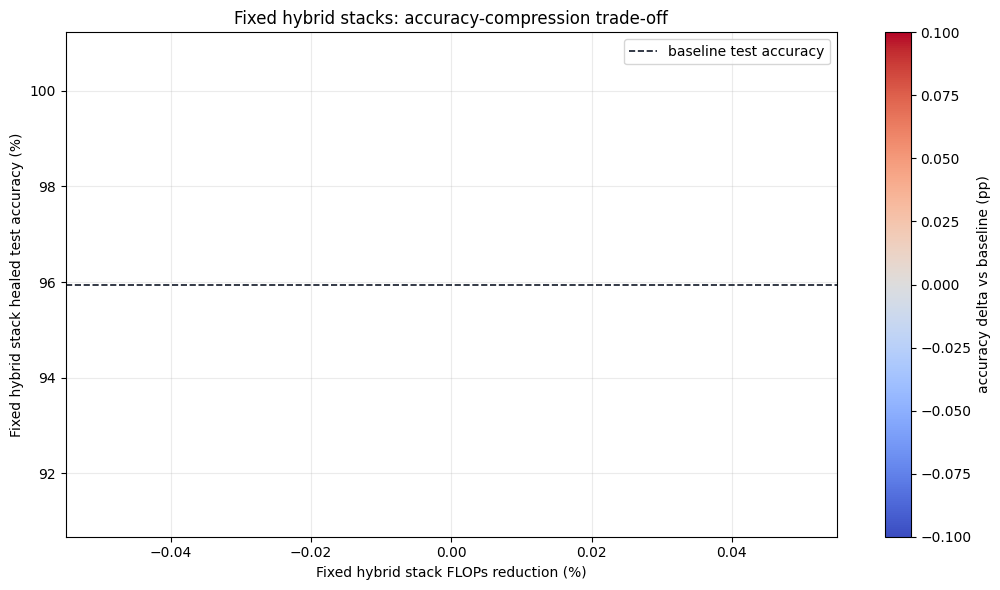

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/explicit_stack_reports/fixed_hybrid_stack_accuracy_flops.png


In [18]:
# [ReduCNN LFPC cell note]
# Purpose: Experiment helper or execution cell.
# Mechanics: It defines helper functions or executes a notebook-specific step used by the LFPC pruning workflow.
# Expected result: The following cells can reuse the variables, functions, or artifacts created here.

# Fixed hybrid stack recipe report.
# This report uses Process 2 fixed-stack benchmark outputs only.
stack_report_dir = OUT_DIR / "explicit_stack_reports"

def _safe_read_csv(path):
    try:
        if path is None or not path.exists() or path.stat().st_size == 0:
            return pd.DataFrame()
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        print("Ignoring empty CSV:", path)
        return pd.DataFrame()

stack_report_dir.mkdir(exist_ok=True)

if "fixed_stack_benchmark_df" not in globals():
    fixed_stack_path = OUT_DIR / "fixed_hybrid_stack_benchmarks.csv"
    fixed_stack_benchmark_df = _safe_read_csv(fixed_stack_path)
if "singular_df" not in globals():
    singular_path = OUT_DIR / "current_run_singular_method_benchmarks.csv"
    singular_df = _safe_read_csv(singular_path)


def _stack_signature_from_layer_policy(layer_policy):
    if isinstance(layer_policy, str):
        try:
            layer_policy = json.loads(layer_policy.replace("'", '"'))
        except Exception:
            return layer_policy
    if not isinstance(layer_policy, dict):
        return ""
    return " | ".join(f"{layer} -> {method}" for layer, method in sorted(layer_policy.items(), key=lambda kv: str(kv[0])))


def _best_singular(scope, ratio):
    if singular_df.empty:
        return None
    sub = singular_df[(singular_df["scope"].astype(str) == str(scope)) & (singular_df["ratio"].astype(float) == float(ratio))].copy()
    if sub.empty:
        return None
    sort_cols = [c for c in ["healed_accuracy_pct", "healed_flops_reduction_pct"] if c in sub.columns]
    if sort_cols:
        return sub.sort_values(sort_cols, ascending=[False] * len(sort_cols)).iloc[0]
    return sub.iloc[0]

stack_rows = []
if fixed_stack_benchmark_df.empty:
    print("No fixed hybrid stack benchmark rows were produced.")
else:
    for _, h in fixed_stack_benchmark_df.iterrows():
        scope = h.get("scope")
        ratio = float(h.get("ratio"))
        best = _best_singular(scope, ratio)
        baseline_test = _safe_float(h.get("baseline_test_accuracy_pct"), get_baseline_test_accuracy())
        hybrid_acc = _safe_float(h.get("healed_accuracy_pct"), np.nan)
        hybrid_flops_red = _safe_float(h.get("healed_flops_reduction_pct"), np.nan)
        hybrid_param_red = _safe_float(h.get("healed_params_reduction_pct"), np.nan)
        singular_same = singular_df[(singular_df["scope"].astype(str) == str(scope)) & (singular_df["ratio"].astype(float) == ratio)].copy() if not singular_df.empty else pd.DataFrame()
        stack_rows.append({
            "stack_id": h.get("stack_id"),
            "hybrid_method": "LFPC fixed stack",
            "dataset": DATASET_KEY,
            "model": MODEL_TARGET,
            "scope": scope,
            "ratio": ratio,
            "variance_threshold": h.get("variance_threshold"),
            "num_layers": h.get("num_layers"),
            "selected_methods_in_layer_order": h.get("selected_methods_in_layer_order"),
            "unique_selected_methods": h.get("selected_methods"),
            "stack_signature": _stack_signature_from_layer_policy(h.get("layer_policy")),
            "layer_policy": h.get("layer_policy"),
            "baseline_test_accuracy_pct": baseline_test,
            "hybrid_healed_accuracy_pct": hybrid_acc,
            "hybrid_accuracy_delta_vs_baseline_pct": None if np.isnan(hybrid_acc) or np.isnan(baseline_test) else hybrid_acc - baseline_test,
            "hybrid_flops_reduction_pct": hybrid_flops_red,
            "hybrid_param_reduction_pct": hybrid_param_red,
            "hybrid_score_time_sec": _safe_float(h.get("score_time_sec"), np.nan),
            "hybrid_mask_build_time_sec": _safe_float(h.get("mask_build_time_sec"), np.nan),
            "hybrid_structural_prune_time_sec": _safe_float(h.get("structural_prune_time_sec"), np.nan),
            "hybrid_heal_time_sec": _safe_float(h.get("heal_time_sec"), np.nan),
            "hybrid_eval_time_sec": _safe_float(h.get("eval_time_sec"), np.nan),
            "hybrid_end_to_end_pruning_time_sec": _safe_float(h.get("end_to_end_pruning_time_sec"), np.nan),
            "runtime_definition": "score selected methods + mask build + structural pruning + healing + evaluation; excludes Algorithm 2/LFPC discovery overhead",
            "best_singular_method_same_scope_ratio": None if best is None else best.get("method"),
            "best_singular_accuracy_pct": None if best is None else best.get("healed_accuracy_pct"),
            "accuracy_gain_vs_best_singular_pct": None if best is None else hybrid_acc - _safe_float(best.get("healed_accuracy_pct"), np.nan),
            "best_singular_flops_reduction_pct": None if best is None else best.get("healed_flops_reduction_pct"),
            "flops_gain_vs_best_singular_pct": None if best is None else hybrid_flops_red - _safe_float(best.get("healed_flops_reduction_pct"), np.nan),
            "best_singular_end_to_end_pruning_time_sec": None if best is None else best.get("end_to_end_pruning_time_sec"),
            "time_gain_vs_best_singular_sec": None if best is None else _safe_float(best.get("end_to_end_pruning_time_sec"), np.nan) - _safe_float(h.get("end_to_end_pruning_time_sec"), np.nan),
            "singular_methods_compared": singular_same["method"].astype(str).tolist() if not singular_same.empty else [],
            "singular_methods_beaten_on_accuracy": singular_same[singular_same["healed_accuracy_pct"].astype(float) < hybrid_acc]["method"].astype(str).tolist() if (not singular_same.empty and not np.isnan(hybrid_acc)) else [],
            "singular_methods_beaten_on_flops": singular_same[singular_same["healed_flops_reduction_pct"].astype(float) < hybrid_flops_red]["method"].astype(str).tolist() if (not singular_same.empty and not np.isnan(hybrid_flops_red)) else [],
        })

explicit_stack_df = pd.DataFrame(stack_rows)
explicit_stack_path = stack_report_dir / "explicit_fixed_hybrid_stack_recipes.csv"
explicit_stack_df.to_csv(explicit_stack_path, index=False)
with open(stack_report_dir / "explicit_fixed_hybrid_stack_recipes.json", "w", encoding="utf-8") as f:
    json.dump(stack_rows, f, indent=2, default=str)

if explicit_stack_df.empty:
    print("No explicit fixed hybrid stack rows were produced.")
else:
    beat_baseline_df = explicit_stack_df[explicit_stack_df["hybrid_accuracy_delta_vs_baseline_pct"].astype(float) > 0].copy()
    beat_path = stack_report_dir / "fixed_hybrid_stacks_that_beat_baseline_accuracy.csv"
    beat_baseline_df.to_csv(beat_path, index=False)
    with open(stack_report_dir / "fixed_hybrid_stacks_that_beat_baseline_accuracy.json", "w", encoding="utf-8") as f:
        json.dump(beat_baseline_df.to_dict(orient="records"), f, indent=2, default=str)
    print("Saved", explicit_stack_path)
    print("Saved", beat_path)

    report_cols = [
        "stack_id", "stack_signature", "baseline_test_accuracy_pct", "hybrid_healed_accuracy_pct",
        "hybrid_accuracy_delta_vs_baseline_pct", "hybrid_flops_reduction_pct", "hybrid_param_reduction_pct",
        "hybrid_score_time_sec", "hybrid_mask_build_time_sec", "hybrid_structural_prune_time_sec",
        "hybrid_heal_time_sec", "hybrid_eval_time_sec", "hybrid_end_to_end_pruning_time_sec",
        "best_singular_method_same_scope_ratio", "best_singular_accuracy_pct", "accuracy_gain_vs_best_singular_pct",
        "best_singular_flops_reduction_pct", "flops_gain_vs_best_singular_pct", "time_gain_vs_best_singular_sec",
    ]
    show_df = explicit_stack_df.sort_values(
        ["hybrid_accuracy_delta_vs_baseline_pct", "hybrid_flops_reduction_pct"], ascending=[False, False]
    )
    try:
        display(show_df[report_cols])
    except NameError:
        print(show_df[report_cols].to_string(index=False))

    md_lines = [
        "# Explicit Fixed Hybrid Stack Recipes",
        "",
        "Benchmark runtime = scoring selected methods + mask build + structural pruning + healing + evaluation.",
        "Algorithm 2 and LFPC policy-search overhead are excluded.",
        "",
    ]
    for _, row in show_df.iterrows():
        md_lines.extend([
            f"## {row['stack_id']}",
            f"- Stack: `{clean_stack_signature(row['stack_signature'])}`",
            f"- Accuracy: {row['hybrid_healed_accuracy_pct']:.4f}% vs baseline {row['baseline_test_accuracy_pct']:.4f}% "
            f"(delta {row['hybrid_accuracy_delta_vs_baseline_pct']:.4f} pp)",
            f"- FLOPs reduction: {row['hybrid_flops_reduction_pct']:.4f}%",
            f"- Parameter reduction: {row['hybrid_param_reduction_pct']:.4f}%",
            f"- End-to-end pruning time: {row['hybrid_end_to_end_pruning_time_sec']:.4f}s "
            f"(score {row['hybrid_score_time_sec']:.4f}s, mask {row['hybrid_mask_build_time_sec']:.4f}s, "
            f"surgery {row['hybrid_structural_prune_time_sec']:.4f}s, heal {row['hybrid_heal_time_sec']:.4f}s, eval {row['hybrid_eval_time_sec']:.4f}s)",
            "- All-singular comparison: see `fixed_stack_vs_all_singular_display.csv` and per-stack objective-pair plots in `all_singular_comparisons/`.",
            "",
        ])
    md_path = stack_report_dir / "explicit_fixed_hybrid_stack_recipes.md"
    md_path.write_text("\n".join(md_lines), encoding="utf-8")
    print("Saved", md_path)

    fig, ax = plt.subplots(figsize=(10.5, 6.0))
    colors = explicit_stack_df["hybrid_accuracy_delta_vs_baseline_pct"].astype(float)
    sc = ax.scatter(
        explicit_stack_df["hybrid_flops_reduction_pct"].astype(float),
        explicit_stack_df["hybrid_healed_accuracy_pct"].astype(float),
        c=colors,
        cmap="coolwarm",
        s=150,
        edgecolor="#0F172A",
    )
    ax.axhline(get_baseline_test_accuracy(), color="#111827", linewidth=1.2, linestyle="--", label="baseline test accuracy")
    for _, row in explicit_stack_df.iterrows():
        label = f"{row['scope']}, r={row['ratio']}, v={row['variance_threshold']}"
        ax.annotate(label, (row["hybrid_flops_reduction_pct"], row["hybrid_healed_accuracy_pct"]), fontsize=8, xytext=(5, 4), textcoords="offset points")
    ax.set_xlabel("Fixed hybrid stack FLOPs reduction (%)")
    ax.set_ylabel("Fixed hybrid stack healed test accuracy (%)")
    ax.set_title("Fixed hybrid stacks: accuracy-compression trade-off")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    fig.colorbar(sc, ax=ax, label="accuracy delta vs baseline (pp)")
    fig.tight_layout()
    out = stack_report_dir / "fixed_hybrid_stack_accuracy_flops.png"
    fig.savefig(out, dpi=180)
    plt.show()
    print("Saved", out)


<!-- reduc_nn_lfpc_cell_doc -->
### Code cell 18: Experiment helper or execution cell

**Context.** This cell belongs to the `FLOPs + Accuracy` LFPC experiment for `Cats-vs-Dogs` with `ResNet18`.

**What it does.** Experiment helper or execution cell.

**How it works.** It defines helper functions or executes a notebook-specific step used by the LFPC pruning workflow.

**Expected result.** The following cells can reuse the variables, functions, or artifacts created here.

If this cell fails, inspect the active dataset/model/objective context and the artifact paths printed by the notebook before continuing.

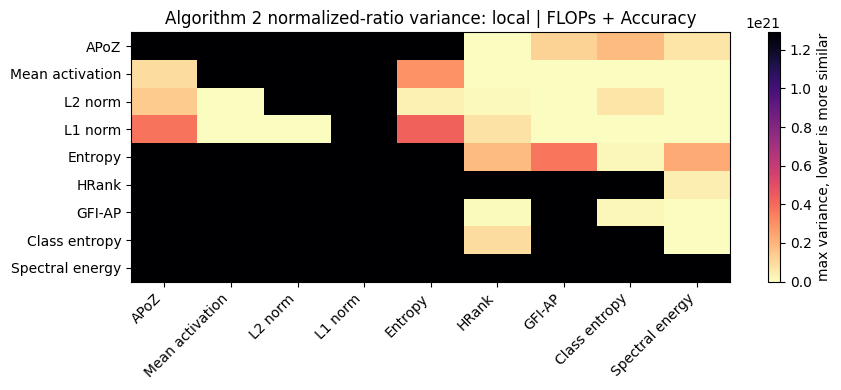

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/report_visuals/algorithm2_similarity_heatmap_local.png


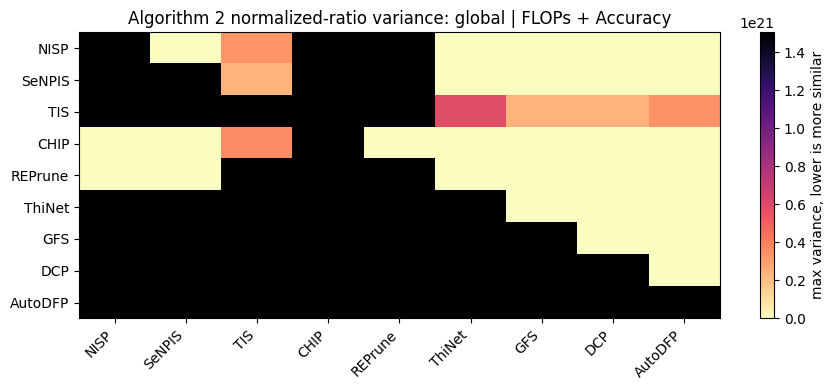

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/report_visuals/algorithm2_similarity_heatmap_global.png
Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/report_visuals/fixed_stack_rank_annotation_map.csv


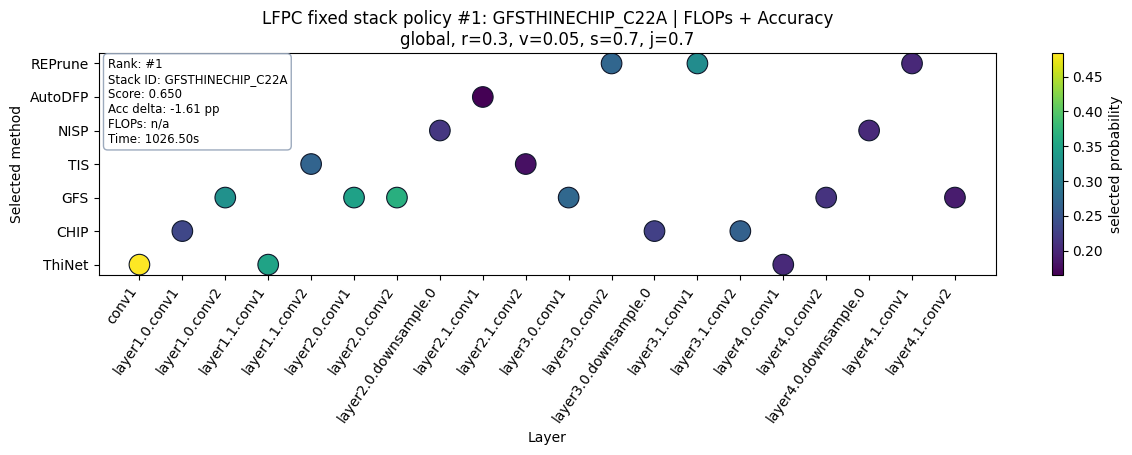

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/report_visuals/fixed_stack_selected_method_by_layer_rank1_GFSTHINECHIP_C22A_global_r0.3_v0.05_s0.7_j0.7.png


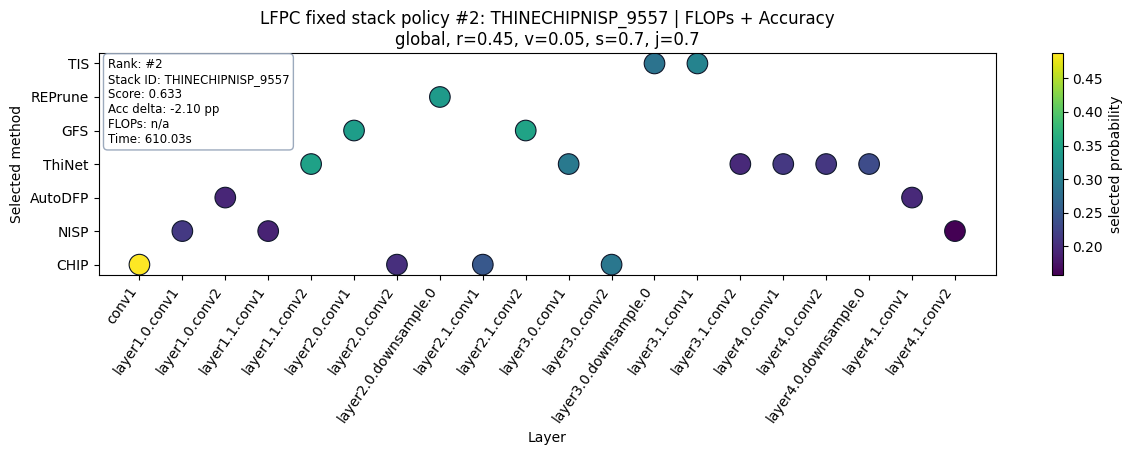

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/report_visuals/fixed_stack_selected_method_by_layer_rank2_THINECHIPNISP_9557_global_r0.45_v0.05_s0.7_j0.7.png


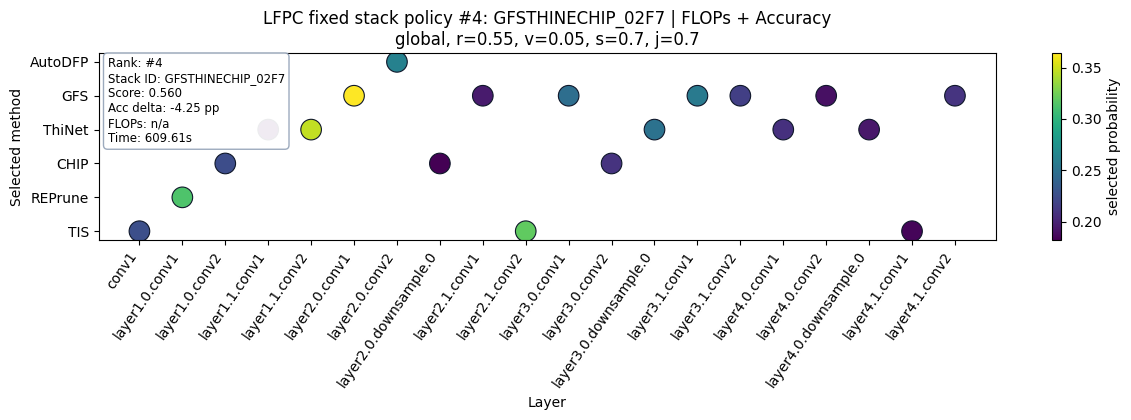

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/report_visuals/fixed_stack_selected_method_by_layer_rank4_GFSTHINECHIP_02F7_global_r0.55_v0.05_s0.7_j0.7.png


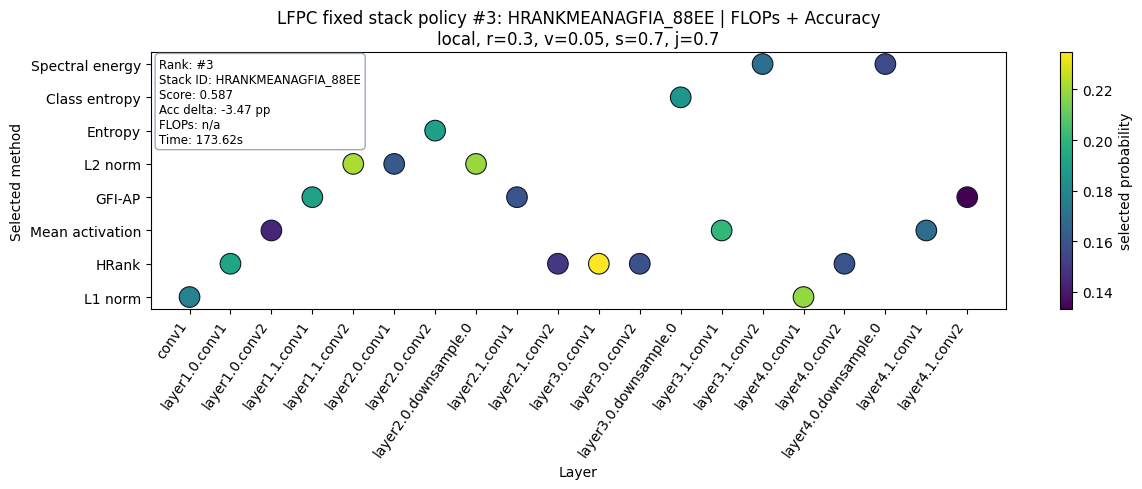

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/report_visuals/fixed_stack_selected_method_by_layer_rank3_HRANKMEANAGFIA_88EE_local_r0.3_v0.05_s0.7_j0.7.png


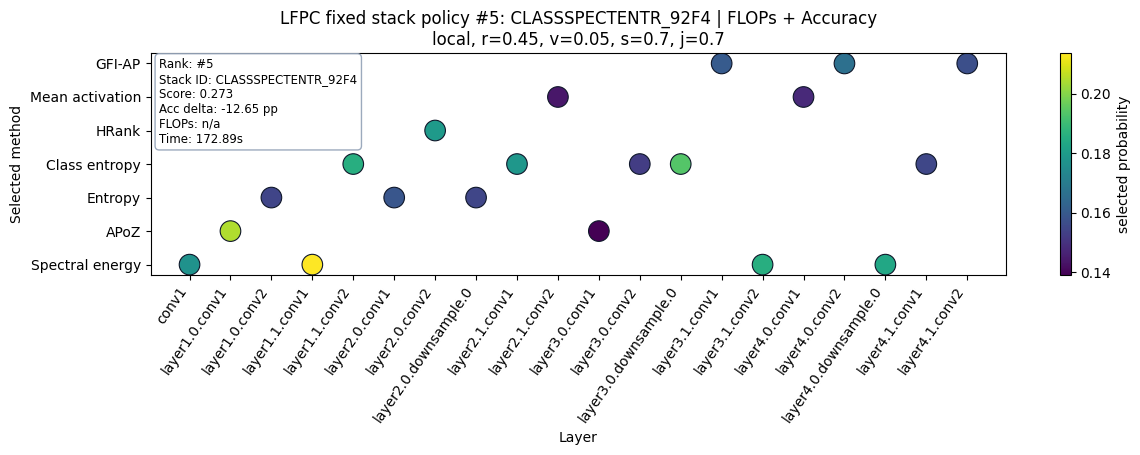

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/report_visuals/fixed_stack_selected_method_by_layer_rank5_CLASSSPECTENTR_92F4_local_r0.45_v0.05_s0.7_j0.7.png


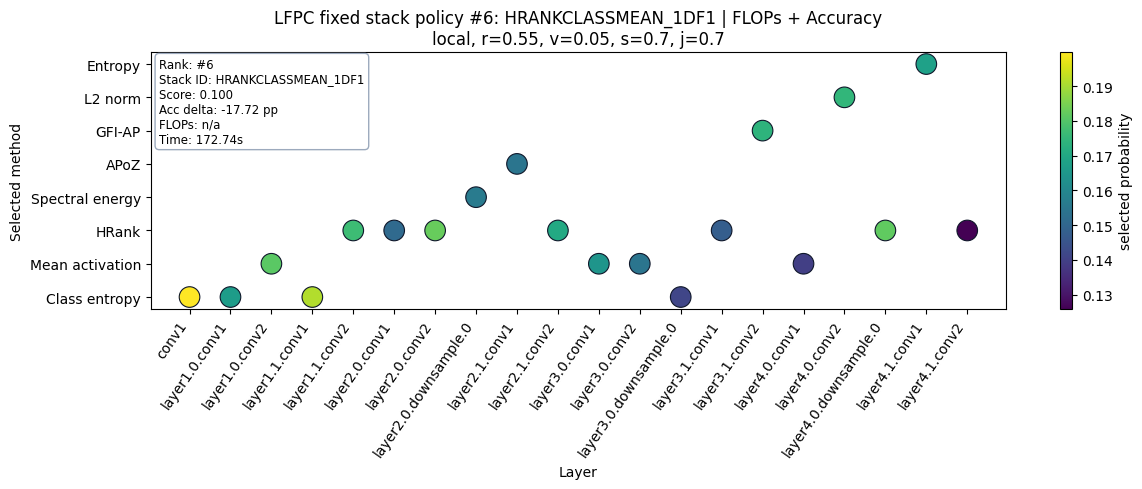

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/report_visuals/fixed_stack_selected_method_by_layer_rank6_HRANKCLASSMEAN_1DF1_local_r0.55_v0.05_s0.7_j0.7.png


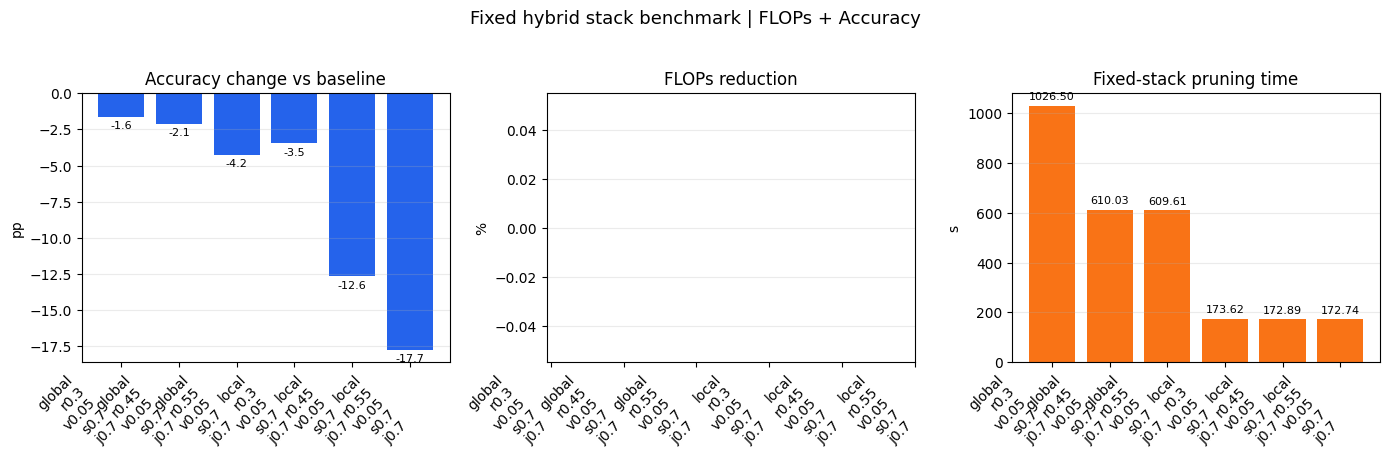

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/report_visuals/fixed_hybrid_stack_benchmark_bars.png


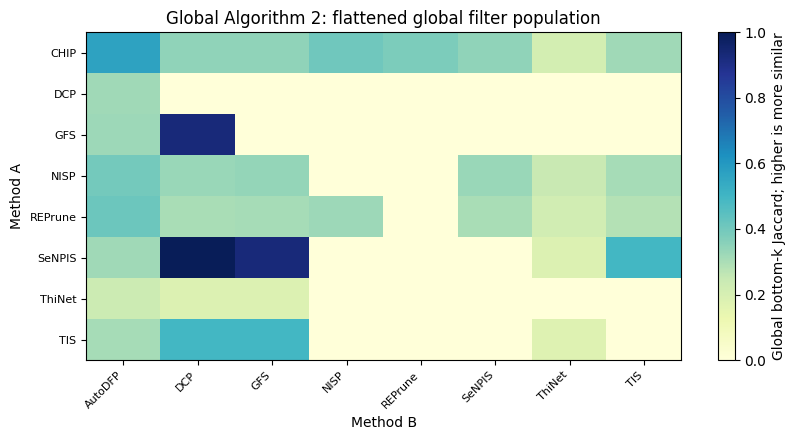

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/report_visuals/global_algorithm2_flat_jaccard_heatmap.png


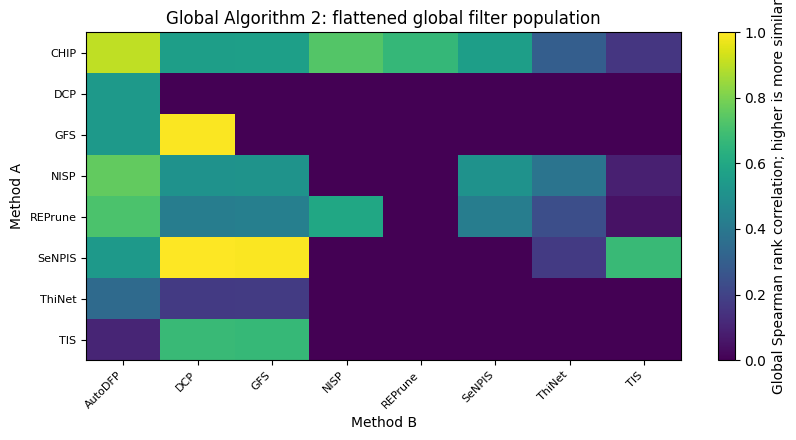

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/report_visuals/global_algorithm2_flat_spearman_heatmap.png


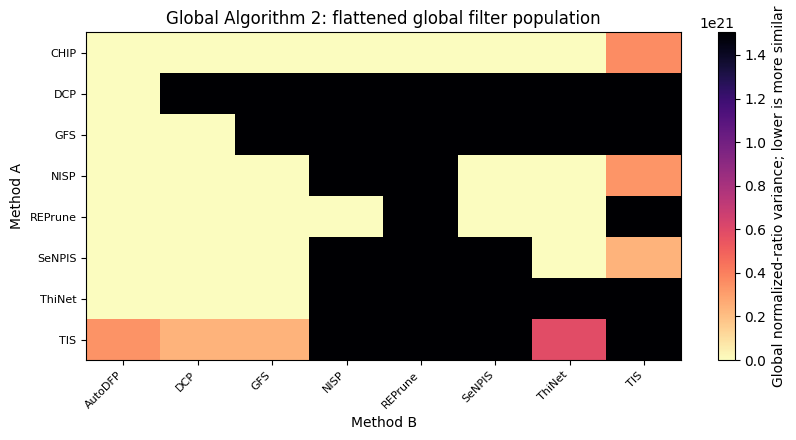

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/report_visuals/global_algorithm2_flat_variance_heatmap.png
Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/report_visuals/global_algorithm2_flat_similarity_audit.csv
Global Algorithm-2 layer-slice rows exist, but no layer has global-pruned filters for the selected condition.


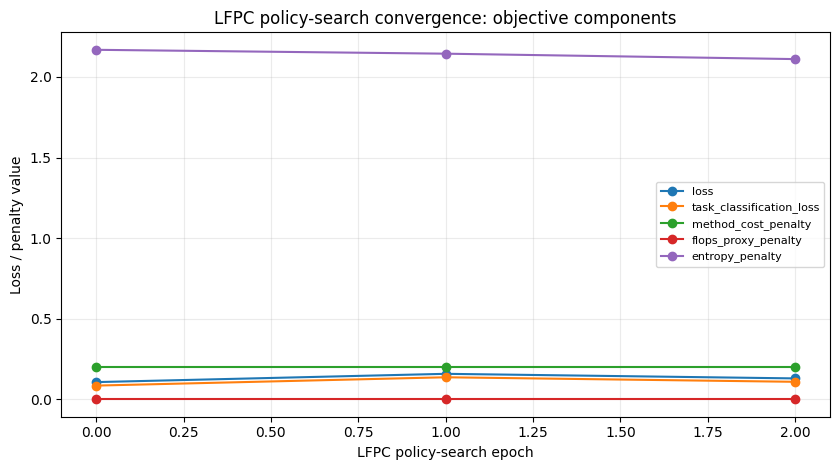

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/report_visuals/lfpc_policy_search_loss_components.png


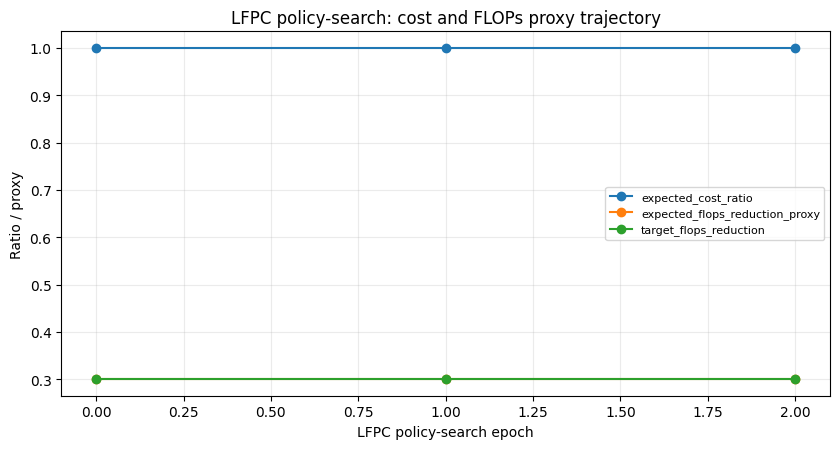

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/report_visuals/lfpc_policy_search_cost_flops_trajectory.png


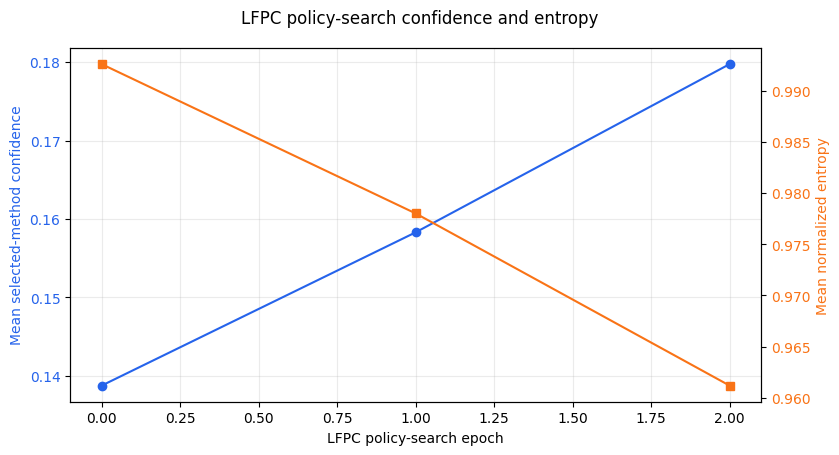

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/report_visuals/lfpc_policy_search_confidence_entropy.png
Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/report_visuals/lfpc_policy_search_history_for_thesis.csv


In [19]:
# [ReduCNN LFPC cell note]
# Purpose: Experiment helper or execution cell.
# Mechanics: It defines helper functions or executes a notebook-specific step used by the LFPC pruning workflow.
# Expected result: The following cells can reuse the variables, functions, or artifacts created here.

#Reporting and plots

def _safe_read_csv(path):
    try:
        if path is None or not path.exists() or path.stat().st_size == 0:
            return pd.DataFrame()
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        print("Ignoring empty CSV:", path)
        return pd.DataFrame()

# Transparent diagnostics and visuals.
REPORT_DIR = OUT_DIR / "report_visuals"
REPORT_DIR.mkdir(exist_ok=True)

if "expected_methods_for_scope" not in globals():
    def expected_methods_for_scope(scope, observed_methods=None):
        scope_key = str(scope).lower()
        if scope_key == "local":
            expected = list(globals().get("REQUIRED_LOCAL_METHODS", []))
        elif scope_key == "global":
            expected = list(globals().get("REQUIRED_GLOBAL_METHODS", []))
        else:
            expected = []
        if not expected:
            expected = list(globals().get("METHODS_BY_SCOPE", {}).get(scope, []))
        observed = [str(m) for m in (observed_methods or [])]
        return list(dict.fromkeys([str(m) for m in expected] + observed))

if "similarity_df" not in globals() or similarity_df is None:
    details_path = OUT_DIR / "algorithm2_threshold_grid_details.csv"
    similarity_df_safe = _safe_read_csv(details_path)
elif isinstance(similarity_df, pd.DataFrame):
    similarity_df_safe = similarity_df.copy()
else:
    similarity_df_safe = pd.DataFrame(similarity_df)

if "lfpc_policy_df" not in globals():
    policy_path = OUT_DIR / "lfpc_discovered_layer_policy_phase1.csv"
    lfpc_policy_df = _safe_read_csv(policy_path)
if "fixed_stack_benchmark_df" not in globals():
    fixed_stack_path = OUT_DIR / "fixed_hybrid_stack_benchmarks.csv"
    fixed_stack_benchmark_df = _safe_read_csv(fixed_stack_path)
if not similarity_df_safe.empty and "ratio" not in similarity_df_safe.columns and "prune_ratio" in similarity_df_safe.columns:
    similarity_df_safe["ratio"] = similarity_df_safe["prune_ratio"]


# Robust helper fallback for report cells that are rerun after a kernel restart.
# The main configuration cell defines this, but report-only reruns should still work.
if "expected_methods_for_scope" not in globals():
    def expected_methods_for_scope(scope, fallback_methods=None):
        scope = str(scope)
        fallback_methods = list(fallback_methods or [])
        methods_by_scope = globals().get("METHODS_BY_SCOPE", {}) or {}
        if scope in methods_by_scope and methods_by_scope.get(scope):
            return list(dict.fromkeys([str(m) for m in methods_by_scope.get(scope, [])]))
        taxonomy = globals().get("LITERATURE_METHOD_TAXONOMY", {}) or {}
        if scope in taxonomy:
            methods = []
            for group_methods in taxonomy.get(scope, {}).values():
                methods.extend([str(m) for m in group_methods])
            if methods:
                return list(dict.fromkeys(methods))
        if scope == "local":
            return list(dict.fromkeys([
                "apoz", "mean_abs_act", "custom_l2", "l1_norm", "custom_entropy",
                "custom_hrank", "custom_gfi_ap", "custom_class_entropy", "custom_spectral_energy",
                *fallback_methods,
            ]))
        if scope == "global":
            return list(dict.fromkeys([
                "custom_nisp", "custom_senpis", "custom_tis", "chip", "custom_reprune",
                "custom_thinet", "custom_gfs", "custom_dcp", "custom_autodfp",
                *fallback_methods,
            ]))
        return list(dict.fromkeys(fallback_methods))

# Similarity heatmap for selected condition.
required_heatmap_cols = {"scope", "ratio", "variance_threshold", "spearman_threshold", "jaccard_threshold", "method_a", "method_b", "max_ratio_variance"}
missing_heatmap_cols = required_heatmap_cols - set(similarity_df_safe.columns)
if similarity_df_safe.empty:
    print("similarity_df is missing or empty; skipping final Algorithm-2 similarity heatmap.")
elif missing_heatmap_cols:
    print("similarity_df missing columns; skipping final Algorithm-2 similarity heatmap:", sorted(missing_heatmap_cols))
else:
    for scope in DEMO_SCOPES:
        sub = similarity_df_safe[
            (similarity_df_safe["scope"] == scope)
            & (similarity_df_safe["ratio"].astype(float) == float(SELECTED_PRUNE_RATIO_FOR_DEMO))
            & (similarity_df_safe["variance_threshold"].astype(float) == float(SELECTED_VARIANCE_THRESHOLD_FOR_DEMO))
            & (similarity_df_safe["spearman_threshold"].astype(float) == float(SELECTED_SPEARMAN_THRESHOLD_FOR_DEMO))
            & (similarity_df_safe["jaccard_threshold"].astype(float) == float(SELECTED_JACCARD_THRESHOLD_FOR_DEMO))
        ].copy()
        if sub.empty:
            continue
        piv = sub.pivot_table(index="method_a", columns="method_b", values="max_ratio_variance", aggfunc="min")
        matrix_methods = expected_methods_for_scope(scope, sorted(set(sub["method_a"].astype(str)).union(set(sub["method_b"].astype(str)))))
        if matrix_methods:
            piv = piv.reindex(index=matrix_methods, columns=matrix_methods)
        fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(piv))))
        finite = piv.values[np.isfinite(piv.values)]
        fill = float(np.nanmax(finite)) if finite.size else 0.0
        im = ax.imshow(piv.fillna(fill).values, aspect="auto", cmap="magma_r")
        ax.set_xticks(np.arange(len(piv.columns)))
        ax.set_xticklabels([method_display_name(x) for x in piv.columns], rotation=45, ha="right")
        ax.set_yticks(np.arange(len(piv.index)))
        ax.set_yticklabels([method_display_name(x) for x in piv.index])
        ax.set_title(f"Algorithm 2 normalized-ratio variance: {scope} | {OBJECTIVE_SCENARIO_LABEL}")
        fig.colorbar(im, ax=ax, label="max variance, lower is more similar")
        fig.tight_layout()
        out = REPORT_DIR / f"algorithm2_similarity_heatmap_{scope}.png"
        fig.savefig(out, dpi=180)
        plt.show()
        print("Saved", out)

# Final selected method by layer.
import hashlib
import re


def _stack_report_token(method):
    aliases = {
        "l1_norm": "L1", "custom_l2": "L2", "mean_abs_act": "MeanAct", "apoz": "APoZ",
        "custom_entropy": "Entropy", "custom_class_entropy": "ClassEntropy", "custom_hrank": "HRank",
        "custom_spectral_energy": "Spectral", "custom_reprune": "REPrune", "custom_tis": "TIS",
        "custom_nisp": "NISP", "chip": "CHIP", "custom_autodfp": "AutoDFP", "custom_gfi_ap": "GFIAP",
        "custom_thinet": "ThiNet", "custom_dcp": "DCP", "custom_senpips": "SeNPIPS", "custom_gfs": "GFS",
    }
    raw = str(method).strip().strip("[](){}'\"")
    label = aliases.get(raw.lower())
    if label is None:
        try:
            label = method_display_name(raw)
        except Exception:
            label = raw
    token = re.sub(r"[^A-Za-z0-9]+", "", str(label)).upper()
    return token[:5] or "METH"


def _stack_report_parse_methods(value):
    if value is None:
        return []
    if isinstance(value, (list, tuple, set, pd.Series, np.ndarray)):
        return [str(v) for v in value if str(v) and str(v).lower() != "nan"]
    text = str(value).strip()
    if not text or text.lower() == "nan":
        return []
    try:
        import ast
        parsed = ast.literal_eval(text)
        if isinstance(parsed, (list, tuple, set)):
            return [str(v) for v in parsed if str(v) and str(v).lower() != "nan"]
    except Exception:
        pass
    for sep in [" + ", "|", ",", ";"]:
        if sep in text:
            return [part.strip().strip("[](){}'\"") for part in text.split(sep) if part.strip().strip("[](){}'\"")]
    return [text.strip().strip("[](){}'\"")]


def stack_report_display_id(methods, unique_key=""):
    clean = [str(m) for m in methods if str(m) and str(m).lower() != "nan"]
    if clean:
        counts = pd.Series(clean).value_counts()
        dominant = list(counts.index[:3])
    else:
        dominant = ["stack"]
    prefix = "".join(_stack_report_token(m) for m in dominant)[:14]
    digest_source = "|".join(clean) + "|" + str(unique_key)
    digest = hashlib.blake2s(digest_source.encode("utf-8"), digest_size=2).hexdigest().upper()
    return f"{prefix}_{digest}"


def _stack_report_norm_high(series):
    s = pd.to_numeric(series, errors="coerce")
    lo = s.min(skipna=True)
    hi = s.max(skipna=True)
    if not np.isfinite(lo) or not np.isfinite(hi) or abs(hi - lo) < 1e-12:
        return pd.Series(np.ones(len(s)) * 0.5, index=s.index)
    return (s - lo) / (hi - lo)


def _stack_report_norm_low(series):
    return 1.0 - _stack_report_norm_high(series)


def _stack_report_target_pct(value):
    try:
        v = float(value)
    except Exception:
        return np.nan
    if not np.isfinite(v):
        return np.nan
    return 100.0 * v if v <= 1.0 else v


def _stack_report_target_aware_score(frame):
    work = frame.copy()
    for col in ["healed_accuracy_delta_pct", "healed_flops_reduction_pct", "end_to_end_pruning_time_sec"]:
        if col not in work.columns:
            work[col] = np.nan
        work[col] = pd.to_numeric(work[col], errors="coerce")
    acc_score = _stack_report_norm_high(work["healed_accuracy_delta_pct"])
    flops_score = _stack_report_norm_high(work["healed_flops_reduction_pct"])
    time_score = _stack_report_norm_low(work["end_to_end_pruning_time_sec"])
    target_flops_pct = _stack_report_target_pct(globals().get("LFPC_TARGET_FLOPS_REDUCTION", np.nan))
    if np.isfinite(target_flops_pct):
        flops_gap = (work["healed_flops_reduction_pct"] - target_flops_pct).fillna(-np.inf)
        work["flops_target_gap_pct"] = flops_gap
        work["flops_target_met"] = flops_gap >= -1e-9
        work["flops_target_score"] = (work["healed_flops_reduction_pct"] / max(target_flops_pct, 1e-9)).clip(lower=0.0, upper=1.0).fillna(0.0)
    else:
        work["flops_target_gap_pct"] = np.nan
        work["flops_target_met"] = False
        work["flops_target_score"] = flops_score
    max_drop = float(globals().get("MAX_ALLOWED_ACCURACY_DROP_PCT", 7.0))
    work["accuracy_gate_pass"] = work["healed_accuracy_delta_pct"] >= -max_drop
    terms = set(globals().get("OPTIMIZED_OBJECTIVE_TERMS", ()))
    if terms == {"flops", "accuracy"}:
        score = 0.55 * acc_score + 0.25 * work["flops_target_score"] + 0.20 * flops_score
    elif terms == {"time", "accuracy"}:
        score = 0.60 * acc_score + 0.40 * time_score
    elif terms == {"time", "flops"}:
        score = 0.40 * time_score + 0.35 * work["flops_target_score"] + 0.25 * flops_score
    else:
        score = 0.50 * acc_score + 0.20 * work["flops_target_score"] + 0.15 * flops_score + 0.15 * time_score
    work["stack_report_score"] = pd.to_numeric(score, errors="coerce")
    return work


def build_stack_rank_annotation_table(benchmark_df):
    if benchmark_df is None or benchmark_df.empty:
        return pd.DataFrame()
    ranked = benchmark_df.copy()
    for col in ["ratio", "variance_threshold", "spearman_threshold", "jaccard_threshold", "healed_accuracy_delta_pct", "healed_flops_reduction_pct", "end_to_end_pruning_time_sec"]:
        if col in ranked.columns:
            ranked[col] = pd.to_numeric(ranked[col], errors="coerce")
    ranked = _stack_report_target_aware_score(ranked)
    method_source = "selected_methods_in_layer_order" if "selected_methods_in_layer_order" in ranked.columns else "selected_methods"
    if method_source not in ranked.columns:
        ranked[method_source] = ""
    ranked["stack_display_id"] = [
        stack_report_display_id(_stack_report_parse_methods(methods), row.get("stack_id", row.name))
        for _, row in ranked.assign(_methods_for_id=ranked[method_source]).iterrows()
        for methods in [row.get("_methods_for_id", "")]
    ]
    sort_cols = ["accuracy_gate_pass", "flops_target_met", "stack_report_score", "healed_accuracy_delta_pct", "healed_flops_reduction_pct", "end_to_end_pruning_time_sec"]
    ascending = [False, False, False, False, False, True]
    ranked = ranked.sort_values([c for c in sort_cols if c in ranked.columns], ascending=ascending[:len([c for c in sort_cols if c in ranked.columns])]).reset_index(drop=True)
    ranked["stack_report_rank"] = np.arange(1, len(ranked) + 1)
    keep_cols = [c for c in [
        "stack_report_rank", "stack_display_id", "stack_report_score", "accuracy_gate_pass", "flops_target_met", "flops_target_gap_pct", "stack_id", "scope", "ratio", "variance_threshold", "spearman_threshold", "jaccard_threshold",
        "selected_methods", "selected_methods_in_layer_order", "healed_accuracy_delta_pct", "healed_flops_reduction_pct", "end_to_end_pruning_time_sec"
    ] if c in ranked.columns]
    return ranked[keep_cols].copy()


fixed_stack_rank_annotations = build_stack_rank_annotation_table(fixed_stack_benchmark_df if "fixed_stack_benchmark_df" in globals() else pd.DataFrame())
if not fixed_stack_rank_annotations.empty:
    rank_path = REPORT_DIR / "fixed_stack_rank_annotation_map.csv"
    fixed_stack_rank_annotations.to_csv(rank_path, index=False)
    print("Saved", rank_path)

_stack_rank_lookup = {}
for _, _rank_row in fixed_stack_rank_annotations.iterrows():
    _key = (
        str(_rank_row.get("scope", "")),
        round(float(_rank_row.get("ratio", np.nan)), 8),
        round(float(_rank_row.get("variance_threshold", np.nan)), 10),
        round(float(_rank_row.get("spearman_threshold", np.nan)), 10),
        round(float(_rank_row.get("jaccard_threshold", np.nan)), 10),
    )
    _stack_rank_lookup[_key] = _rank_row.to_dict()

if "lfpc_policy_df" in globals() and not lfpc_policy_df.empty:
    for (scope, ratio, threshold, spearman_threshold, jaccard_threshold), grp in lfpc_policy_df.groupby(["scope", "ratio", "variance_threshold", "spearman_threshold", "jaccard_threshold"]):
        grp = grp.sort_values("layer")
        methods = list(dict.fromkeys(grp["selected_method"].astype(str)))
        method_to_y = {m: i for i, m in enumerate(methods)}
        xs = np.arange(len(grp))
        ys = [method_to_y[m] for m in grp["selected_method"].astype(str)]
        lookup_key = (str(scope), round(float(ratio), 8), round(float(threshold), 10), round(float(spearman_threshold), 10), round(float(jaccard_threshold), 10))
        rank_info = _stack_rank_lookup.get(lookup_key, {})
        stack_rank = int(rank_info.get("stack_report_rank", 0)) if rank_info else 0
        stack_display_id = rank_info.get("stack_display_id") or stack_report_display_id(grp["selected_method"].astype(str).tolist(), lookup_key)
        fig, ax = plt.subplots(figsize=(max(10, 0.62 * len(grp)), max(4.2, 0.35 * len(methods) + 2.2)))
        sc = ax.scatter(xs, ys, s=220, c=grp["selected_probability"].astype(float), cmap="viridis", edgecolor="#0F172A", linewidth=0.8)
        ax.set_xticks(xs)
        ax.set_xticklabels(grp["layer"].astype(str), rotation=55, ha="right")
        ax.set_yticks(range(len(methods)))
        ax.set_yticklabels([method_display_name(m) for m in methods])
        ax.set_xlabel("Layer")
        ax.set_ylabel("Selected method")
        rank_label = f"#{stack_rank}" if stack_rank else "unranked"
        ax.set_title(f"LFPC fixed stack policy {rank_label}: {stack_display_id} | {OBJECTIVE_SCENARIO_LABEL}\n{scope}, r={ratio}, v={threshold}, s={spearman_threshold}, j={jaccard_threshold}")
        metric_lines = [f"Rank: {rank_label}", f"Stack ID: {stack_display_id}"]
        if rank_info:
            metric_lines.extend([
                f"Score: {float(rank_info.get('stack_report_score', np.nan)):.3f}" if np.isfinite(float(rank_info.get('stack_report_score', np.nan))) else "Score: n/a",
                f"Acc delta: {float(rank_info.get('healed_accuracy_delta_pct', np.nan)):.2f} pp" if np.isfinite(float(rank_info.get('healed_accuracy_delta_pct', np.nan))) else "Acc delta: n/a",
                f"FLOPs: {float(rank_info.get('healed_flops_reduction_pct', np.nan)):.2f}%" if np.isfinite(float(rank_info.get('healed_flops_reduction_pct', np.nan))) else "FLOPs: n/a",
                f"Time: {float(rank_info.get('end_to_end_pruning_time_sec', np.nan)):.2f}s" if np.isfinite(float(rank_info.get('end_to_end_pruning_time_sec', np.nan))) else "Time: n/a",
            ])
        ax.text(0.01, 0.98, "\n".join(metric_lines), transform=ax.transAxes, va="top", ha="left", fontsize=8.5, bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#94A3B8", alpha=0.92))
        fig.colorbar(sc, ax=ax, label="selected probability")
        fig.tight_layout()
        out = REPORT_DIR / f"fixed_stack_selected_method_by_layer_rank{stack_rank}_{stack_display_id}_{scope}_r{ratio}_v{threshold}_s{spearman_threshold}_j{jaccard_threshold}.png"
        fig.savefig(out, dpi=180)
        plt.show()
        print("Saved", out)

# Fixed hybrid benchmark bars.
if "fixed_stack_benchmark_df" in globals() and not fixed_stack_benchmark_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    labels = [f"{r.scope}\nr{r.ratio}\nv{r.variance_threshold}\ns{r.spearman_threshold}\nj{r.jaccard_threshold}" for _, r in fixed_stack_benchmark_df.iterrows()]
    x = np.arange(len(labels))
    bars0 = axes[0].bar(x, fixed_stack_benchmark_df["healed_accuracy_delta_pct"].astype(float), color="#2563EB")
    if APPLY_ACCURACY_DROP_CONSTRAINT:
        axes[0].axhline(-float(MAX_ALLOWED_ACCURACY_DROP_PCT), color="#DC2626", linestyle="--", linewidth=1.3, label=f"max drop {MAX_ALLOWED_ACCURACY_DROP_PCT:g} pp")
        axes[0].legend(fontsize=8)
    axes[0].set_title("Accuracy change vs baseline")
    axes[0].set_ylabel("pp")
    bars1 = axes[1].bar(x, fixed_stack_benchmark_df["healed_flops_reduction_pct"].astype(float), color="#059669")
    axes[1].set_title("FLOPs reduction")
    axes[1].set_ylabel("%")
    bars2 = axes[2].bar(x, fixed_stack_benchmark_df["end_to_end_pruning_time_sec"].astype(float), color="#F97316")
    axes[2].set_title("Fixed-stack pruning time")
    axes[2].set_ylabel("s")
    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.grid(axis="y", alpha=0.25)
    for ax, bars, fmt in [(axes[0], bars0, "{:.1f}"), (axes[1], bars1, "{:.1f}"), (axes[2], bars2, "{:.2f}")]:
        try:
            ax.bar_label(bars, labels=[fmt.format(float(b.get_height())) for b in bars], padding=3, fontsize=8)
        except Exception:
            pass
    fig.suptitle(f"Fixed hybrid stack benchmark | {OBJECTIVE_SCENARIO_LABEL}", y=1.03, fontsize=13)
    fig.tight_layout()
    out = REPORT_DIR / "fixed_hybrid_stack_benchmark_bars.png"
    fig.savefig(out, dpi=180)
    plt.show()
    print("Saved", out)


# --- GLOBAL LAYER-SLICE AND LFPC TRAINING EVIDENCE VISUALS ---
# These figures are thesis evidence: global pruning remains globally ranked,
# but agreement is explained layer-by-layer after slicing the global masks back
# to each layer. LFPC policy-search history is plotted as convergence evidence.
import ast


def _num_col(df, col, default=np.nan):
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce")
    return pd.Series([default] * len(df), index=df.index, dtype="float64")


def _selected_condition(df, scope):
    if df.empty:
        return df
    work = df[df["scope"].astype(str).str.lower() == str(scope).lower()].copy()
    if work.empty:
        return work
    for col, val in [
        ("ratio", globals().get("SELECTED_PRUNE_RATIO_FOR_DEMO", None)),
        ("variance_threshold", globals().get("SELECTED_VARIANCE_THRESHOLD_FOR_DEMO", None)),
        ("spearman_threshold", globals().get("SELECTED_SPEARMAN_THRESHOLD_FOR_DEMO", None)),
        ("jaccard_threshold", globals().get("SELECTED_JACCARD_THRESHOLD_FOR_DEMO", None)),
    ]:
        if col in work.columns and val is not None:
            filt = work[np.isclose(pd.to_numeric(work[col], errors="coerce"), float(val), rtol=0, atol=1e-12)]
            if not filt.empty:
                work = filt
    return work


def _short_method_pair(row):
    return f"{row['method_a']}\nvs\n{row['method_b']}"


def _parse_prob_dict(value):
    if isinstance(value, dict):
        return value
    if isinstance(value, str):
        try:
            parsed = json.loads(value)
            return parsed if isinstance(parsed, dict) else {}
        except Exception:
            try:
                parsed = ast.literal_eval(value)
                return parsed if isinstance(parsed, dict) else {}
            except Exception:
                return {}
    return {}



# A0. True global agreement heatmap: one flattened prunable population.
if not similarity_df_safe.empty and {"scope", "method_a", "method_b", "prune_set_jaccard", "algorithm2_metric_scope"}.issubset(similarity_df_safe.columns):
    gflat = _selected_condition(similarity_df_safe, "global")
    gflat = gflat[gflat["algorithm2_metric_scope"].astype(str).eq("global_flat_all_prunable_filters")].copy() if not gflat.empty else gflat
    if not gflat.empty:
        gflat["pair"] = gflat.apply(_short_method_pair, axis=1)
        for metric, label, cmap, out_name in [
            ("prune_set_jaccard", "Global bottom-k Jaccard; higher is more similar", "YlGnBu", "global_algorithm2_flat_jaccard_heatmap.png"),
            ("spearman_rank_corr", "Global Spearman rank correlation; higher is more similar", "viridis", "global_algorithm2_flat_spearman_heatmap.png"),
            ("max_ratio_variance", "Global normalized-ratio variance; lower is more similar", "magma_r", "global_algorithm2_flat_variance_heatmap.png"),
        ]:
            if metric not in gflat.columns:
                continue
            mat = gflat.pivot_table(index="method_a", columns="method_b", values=metric, aggfunc="mean")
            fig, ax = plt.subplots(figsize=(max(8.5, 0.45 * len(mat.columns)), max(4.5, 0.35 * len(mat))))
            vals = mat.values.astype(float)
            if metric == "max_ratio_variance":
                finite = vals[np.isfinite(vals)]
                fill = float(np.nanmax(finite)) if finite.size else 0.0
                im = ax.imshow(mat.fillna(fill).values, aspect="auto", cmap=cmap)
            else:
                im = ax.imshow(mat.fillna(0.0).values, aspect="auto", vmin=0, vmax=1, cmap=cmap)
            ax.set_xticks(np.arange(len(mat.columns)))
            ax.set_xticklabels([method_display_name(x) for x in mat.columns], rotation=45, ha="right", fontsize=8)
            ax.set_yticks(np.arange(len(mat.index)))
            ax.set_yticklabels([method_display_name(x) for x in mat.index], fontsize=8)
            ax.set_title("Global Algorithm 2: flattened global filter population")
            ax.set_xlabel("Method B")
            ax.set_ylabel("Method A")
            fig.colorbar(im, ax=ax, label=label)
            fig.tight_layout()
            out = REPORT_DIR / out_name
            fig.savefig(out, dpi=180)
            plt.show()
            print("Saved", out)

        flat_cols = [c for c in [
            "scope", "ratio", "variance_threshold", "spearman_threshold", "jaccard_threshold",
            "method_a", "method_b", "algorithm2_metric_scope", "jaccard_mode", "num_filters", "num_layers",
            "method_a_pruned_global", "method_b_pruned_global", "prune_union_global", "prune_intersection_global",
            "prune_set_jaccard", "spearman_rank_corr", "max_ratio_variance", "is_equivalent", "selected_representative", "removed_method", "reason",
        ] if c in gflat.columns]
        flat_audit_path = REPORT_DIR / "global_algorithm2_flat_similarity_audit.csv"
        gflat[flat_cols].to_csv(flat_audit_path, index=False)
        print("Saved", flat_audit_path)
    else:
        print("No flattened global Algorithm-2 rows found for the selected condition yet; rerun Algorithm 2 after this patch.")
else:
    print("Global flattened Algorithm-2 diagnostics need similarity_df; run Algorithm 2 first.")

# A. Global mask layer-slice agreement heatmap.
if not similarity_df_safe.empty and {"scope", "layer", "method_a", "method_b", "prune_set_jaccard", "prune_union_in_layer"}.issubset(similarity_df_safe.columns):
    gsub = _selected_condition(similarity_df_safe, "global")
    if not gsub.empty:
        gsub = gsub.copy()
        gsub["prune_set_jaccard_num"] = _num_col(gsub, "prune_set_jaccard")
        gsub["prune_union_in_layer_num"] = _num_col(gsub, "prune_union_in_layer", 0).fillna(0)
        gsub["pair"] = gsub.apply(_short_method_pair, axis=1)
        informative = gsub[gsub["prune_union_in_layer_num"] > 0].copy()
        if informative.empty:
            print("Global Algorithm-2 layer-slice rows exist, but no layer has global-pruned filters for the selected condition.")
        else:
            pivot = informative.pivot_table(index="layer", columns="pair", values="prune_set_jaccard_num", aggfunc="mean")
            # Keep the most informative method-pairs to avoid unreadable thesis plots.
            pair_order = informative.groupby("pair")["prune_set_jaccard_num"].mean().sort_values(ascending=False).index.tolist()[:16]
            pivot = pivot.reindex(columns=pair_order)
            fig, ax = plt.subplots(figsize=(max(10, 0.55 * len(pivot.columns)), max(4.5, 0.38 * len(pivot))))
            im = ax.imshow(pivot.fillna(0.0).values, aspect="auto", vmin=0, vmax=1, cmap="YlGnBu")
            ax.set_xticks(np.arange(len(pivot.columns)))
            ax.set_xticklabels([method_display_name(x) for x in pivot.columns], rotation=55, ha="right", fontsize=8)
            ax.set_yticks(np.arange(len(pivot.index)))
            ax.set_yticklabels([method_display_name(x) for x in pivot.index], fontsize=8)
            ax.set_title("Global Algorithm 2: layer-sliced prune-set Jaccard")
            ax.set_xlabel("Method pair")
            ax.set_ylabel("Layer after global pruning")
            fig.colorbar(im, ax=ax, label="Jaccard on globally pruned filters")
            fig.tight_layout()
            out = REPORT_DIR / "global_algorithm2_layer_sliced_jaccard_heatmap.png"
            fig.savefig(out, dpi=180)
            plt.show()
            print("Saved", out)

            counts = informative.pivot_table(index="layer", columns="method_a", values="method_a_pruned_in_layer", aggfunc="max")
            counts = counts.fillna(0.0)
            fig, ax = plt.subplots(figsize=(max(9, 0.55 * len(counts.columns)), max(4, 0.35 * len(counts))))
            bottom = np.zeros(len(counts), dtype=float)
            x = np.arange(len(counts))
            for method in counts.columns:
                vals = counts[method].astype(float).values
                ax.bar(x, vals, bottom=bottom, label=str(method))
                bottom += vals
            ax.set_xticks(x)
            ax.set_xticklabels([method_display_name(x) for x in counts.index.astype(str)], rotation=50, ha="right", fontsize=8)
            ax.set_ylabel("Filters selected by global mask")
            ax.set_title("Global pruning distribution by layer and method")
            ax.grid(axis="y", alpha=0.25)
            ax.legend(fontsize=7, ncol=2, bbox_to_anchor=(1.02, 1), loc="upper left")
            fig.tight_layout()
            out = REPORT_DIR / "global_pruned_filter_counts_by_layer_method.png"
            fig.savefig(out, dpi=180)
            plt.show()
            print("Saved", out)

            audit_cols = [c for c in [
                "scope", "ratio", "variance_threshold", "spearman_threshold", "jaccard_threshold",
                "layer", "method_a", "method_b", "algorithm2_metric_scope", "global_pair_informative",
                "method_a_pruned_in_layer", "method_b_pruned_in_layer", "prune_union_in_layer",
                "prune_intersection_in_layer", "prune_set_jaccard", "spearman_rank_corr",
                "max_ratio_variance", "full_layer_spearman_rank_corr_diagnostic",
                "full_layer_max_ratio_variance_diagnostic", "is_equivalent", "reason",
            ] if c in gsub.columns]
            audit_path = REPORT_DIR / "global_algorithm2_layer_sliced_similarity_audit.csv"
            gsub[audit_cols].to_csv(audit_path, index=False)
            print("Saved", audit_path)
else:
    print("Global layer-slice Algorithm-2 diagnostics need similarity_df with prune-set columns; run Algorithm 2 first.")


# B. LFPC policy-search convergence/evidence plots.
if "lfpc_history_df" not in globals() or not isinstance(lfpc_history_df, pd.DataFrame):
    lfpc_history_df = _safe_read_csv(OUT_DIR / "lfpc_alpha_history_discovery_phase1.csv")

if isinstance(lfpc_history_df, pd.DataFrame) and not lfpc_history_df.empty:
    hist = lfpc_history_df.copy()
    if "epoch" not in hist.columns:
        hist["epoch"] = np.arange(len(hist))
    group_cols = [c for c in ["scope", "ratio", "variance_threshold", "spearman_threshold", "jaccard_threshold"] if c in hist.columns]
    if group_cols:
        # Plot the selected/default condition when available; otherwise the first condition.
        chosen = hist.copy()
        for col, val in [
            ("scope", globals().get("SELECTED_SCOPE_FOR_DEMO", None)),
            ("ratio", globals().get("SELECTED_PRUNE_RATIO_FOR_DEMO", None)),
            ("variance_threshold", globals().get("SELECTED_VARIANCE_THRESHOLD_FOR_DEMO", None)),
            ("spearman_threshold", globals().get("SELECTED_SPEARMAN_THRESHOLD_FOR_DEMO", None)),
            ("jaccard_threshold", globals().get("SELECTED_JACCARD_THRESHOLD_FOR_DEMO", None)),
        ]:
            if col in chosen.columns and val is not None:
                if col == "scope":
                    filt = chosen[chosen[col].astype(str) == str(val)]
                else:
                    filt = chosen[np.isclose(pd.to_numeric(chosen[col], errors="coerce"), float(val), rtol=0, atol=1e-12)]
                if not filt.empty:
                    chosen = filt
        if chosen.empty:
            first_key = next(iter(hist.groupby(group_cols, dropna=False).groups))
            if not isinstance(first_key, tuple):
                first_key = (first_key,)
            mask = np.ones(len(hist), dtype=bool)
            for c, v in zip(group_cols, first_key):
                mask &= (hist[c].astype(str) == str(v))
            chosen = hist[mask].copy()
    else:
        chosen = hist.copy()

    chosen = chosen.sort_values("epoch").copy()
    loss_cols = [c for c in ["loss", "task_classification_loss", "method_cost_penalty", "flops_proxy_penalty", "entropy_penalty"] if c in chosen.columns]
    if loss_cols:
        fig, ax = plt.subplots(figsize=(8.5, 4.8))
        for col in loss_cols:
            ax.plot(pd.to_numeric(chosen["epoch"], errors="coerce"), pd.to_numeric(chosen[col], errors="coerce"), marker="o", label=col)
        ax.set_xlabel("LFPC policy-search epoch")
        ax.set_ylabel("Loss / penalty value")
        ax.set_title("LFPC policy-search convergence: objective components")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
        fig.tight_layout()
        out = REPORT_DIR / "lfpc_policy_search_loss_components.png"
        fig.savefig(out, dpi=180)
        plt.show()
        print("Saved", out)

    curve_cols = [c for c in ["expected_cost_ratio", "expected_flops_reduction_proxy", "target_flops_reduction"] if c in chosen.columns]
    if curve_cols:
        fig, ax = plt.subplots(figsize=(8.5, 4.6))
        for col in curve_cols:
            ax.plot(pd.to_numeric(chosen["epoch"], errors="coerce"), pd.to_numeric(chosen[col], errors="coerce"), marker="o", label=col)
        ax.set_xlabel("LFPC policy-search epoch")
        ax.set_ylabel("Ratio / proxy")
        ax.set_title("LFPC policy-search: cost and FLOPs proxy trajectory")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
        fig.tight_layout()
        out = REPORT_DIR / "lfpc_policy_search_cost_flops_trajectory.png"
        fig.savefig(out, dpi=180)
        plt.show()
        print("Saved", out)

    prob_records = []
    if "probabilities" in chosen.columns:
        for _, row in chosen.iterrows():
            probs_by_layer = _parse_prob_dict(row.get("probabilities"))
            max_probs = []
            entropies = []
            effective_methods = []
            for _layer, probs in probs_by_layer.items():
                vals = np.asarray(list((probs or {}).values()), dtype=float)
                vals = vals[np.isfinite(vals)]
                if vals.size:
                    vals = vals / max(vals.sum(), 1e-12)
                    max_probs.append(float(vals.max()))
                    ent = float(-(vals * np.log(vals + 1e-12)).sum())
                    entropies.append(ent / np.log(vals.size) if vals.size > 1 else 0.0)
                    effective_methods.append(float(np.exp(ent)))
            prob_records.append({
                "epoch": row.get("epoch"),
                "mean_max_policy_probability": float(np.mean(max_probs)) if max_probs else np.nan,
                "mean_normalized_policy_entropy": float(np.mean(entropies)) if entropies else np.nan,
                "mean_effective_methods": float(np.mean(effective_methods)) if effective_methods else np.nan,
            })
    prob_df = pd.DataFrame(prob_records)
    if not prob_df.empty:
        prob_df.to_csv(REPORT_DIR / "lfpc_policy_search_probability_confidence.csv", index=False)
        fig, ax1 = plt.subplots(figsize=(8.5, 4.6))
        x = pd.to_numeric(prob_df["epoch"], errors="coerce")
        ax1.plot(x, prob_df["mean_max_policy_probability"], marker="o", color="#2563EB", label="mean max probability")
        ax1.set_xlabel("LFPC policy-search epoch")
        ax1.set_ylabel("Mean selected-method confidence", color="#2563EB")
        ax1.tick_params(axis="y", labelcolor="#2563EB")
        ax1.grid(alpha=0.25)
        ax2 = ax1.twinx()
        ax2.plot(x, prob_df["mean_normalized_policy_entropy"], marker="s", color="#F97316", label="mean normalized entropy")
        ax2.set_ylabel("Mean normalized entropy", color="#F97316")
        ax2.tick_params(axis="y", labelcolor="#F97316")
        fig.suptitle("LFPC policy-search confidence and entropy")
        fig.tight_layout()
        out = REPORT_DIR / "lfpc_policy_search_confidence_entropy.png"
        fig.savefig(out, dpi=180)
        plt.show()
        print("Saved", out)

    history_audit_path = REPORT_DIR / "lfpc_policy_search_history_for_thesis.csv"
    chosen.to_csv(history_audit_path, index=False)
    print("Saved", history_audit_path)
else:
    print("LFPC policy-search history is missing/empty; run Process 1 discovery to produce convergence evidence plots.")


## Phase 2 + Phase 3 Enhancement Plan

This notebook now extends the Phase 1 workflow with **Phase 2 fair comparison** and **Phase 3 robustness/stability diagnostics**.

### Phase 2: Fair comparison framework

The goal is to compare the discovered fixed hybrid stack fairly against singular pruning methods.

Implemented outputs:

- A standardized benchmark table with common fields for hybrid and singular methods.
- Best hybrid stack per `scope × pruning_ratio`, selected using accuracy first, then FLOPs reduction, then runtime.
- Hybrid-vs-best-singular comparison for each `scope × pruning_ratio`.
- Pareto-front diagnostics using accuracy, FLOPs reduction, and pruning runtime.
- Clean visuals for best hybrid stacks and hybrid-vs-singular comparisons.

The benchmark runtime remains deployment-style only:

`selected-method scoring + mask build + structural pruning + healing/fine-tuning + evaluation`

It excludes Algorithm 2 threshold search and policy-search overhead.

### Phase 3: Robustness and stability diagnostics

The goal is to test whether the policy decisions are stable across threshold-grid conditions and whether the search process converged sensibly.

Implemented outputs:

- Layer-wise method stability across Algorithm 2 threshold configurations.
- Method-selection frequency per layer.
- Stability rate, entropy, effective number of selected methods, and dominant method per layer.
- Condition-level stability summaries.
- Search-history/convergence summaries when policy-search history is available.
- Optional seed-repeat scaffold for future expensive runs.

Phase 3 does not rerun the full experiment by default. It first uses the threshold-grid matrix already produced in Phase 1, which is much cheaper and immediately available.


<!-- reduc_nn_lfpc_cell_doc -->
### Code cell 19: Environment, imports, and reproducibility setup

**Context.** This cell belongs to the `FLOPs + Accuracy` LFPC experiment for `Cats-vs-Dogs` with `ResNet18`.

**What it does.** Environment, imports, and reproducibility setup.

**How it works.** It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.

**Expected result.** The notebook runtime has the libraries, paths, and helper functions needed by the experiment.

If this cell fails, inspect the active dataset/model/objective context and the artifact paths printed by the notebook before continuing.

Using in-memory lfpc_policy_df: (120, 52)
Using in-memory fixed_stack_benchmark_df: (6, 65)
Using in-memory lfpc_history_df: (18, 30)
Using in-memory singular_df: (54, 49)
Saved standardized benchmark table: /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/phase2_phase3_outputs/lfpc_phase23_standardized_benchmark_table.csv
Saved best hybrid table: /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/phase2_phase3_outputs/lfpc_phase23_best_hybrid_by_scope_ratio.csv
Saved secondary best-singular summary table: /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/phase2_phase3_outputs/lfpc_phase23_secondary_best_singular_summary.csv


/tmp/ipykernel_791/3857666385.py:786: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  phase23_benchmark_df = pd.concat([hybrid_std, singular_std], ignore_index=True) if (not hybrid_std.empty or not singular_std.empty) else pd.DataFrame()


Saved hybrid-vs-all-singular table: /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/phase2_phase3_outputs/lfpc_phase23_hybrid_vs_all_singular.csv
Saved policy stability: /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/phase2_phase3_outputs/lfpc_phase23_policy_stability_by_layer.csv
Saved condition stability: /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/phase2_phase3_outputs/lfpc_phase23_condition_stability_summary.csv
Saved convergence summary: /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/phase2_phase3_output

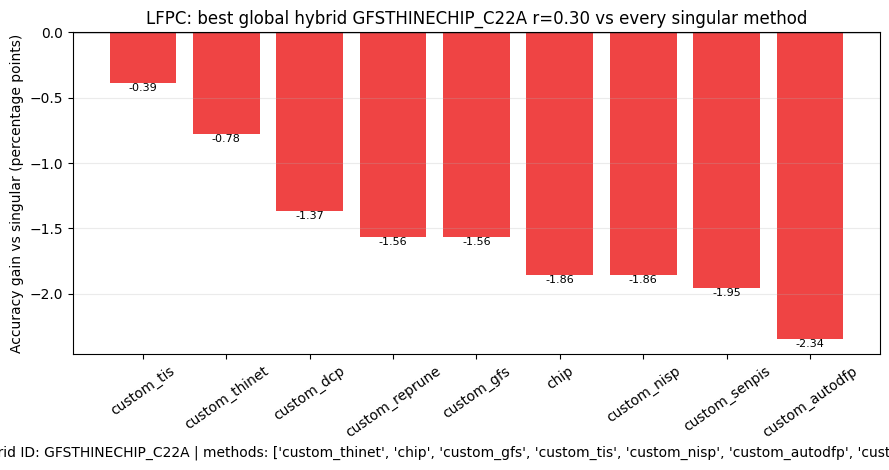

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/phase2_phase3_outputs/visuals/lfpc_phase2_hybrid_vs_all_singular_global_r0.30.png


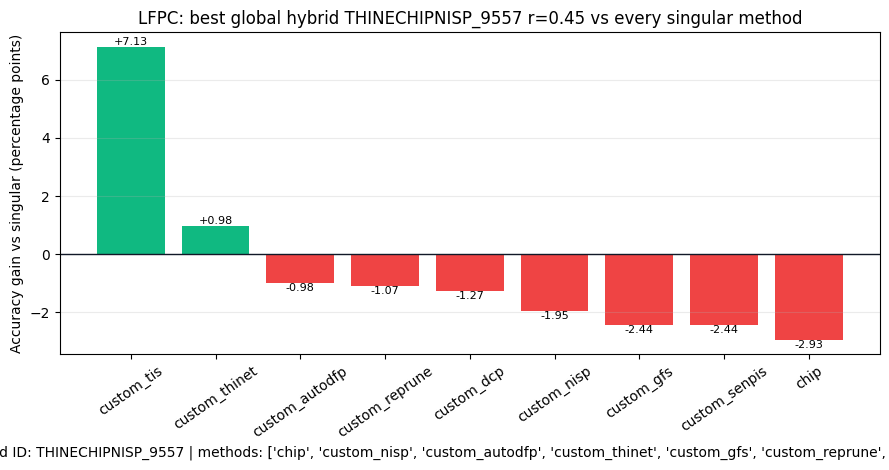

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/phase2_phase3_outputs/visuals/lfpc_phase2_hybrid_vs_all_singular_global_r0.45.png


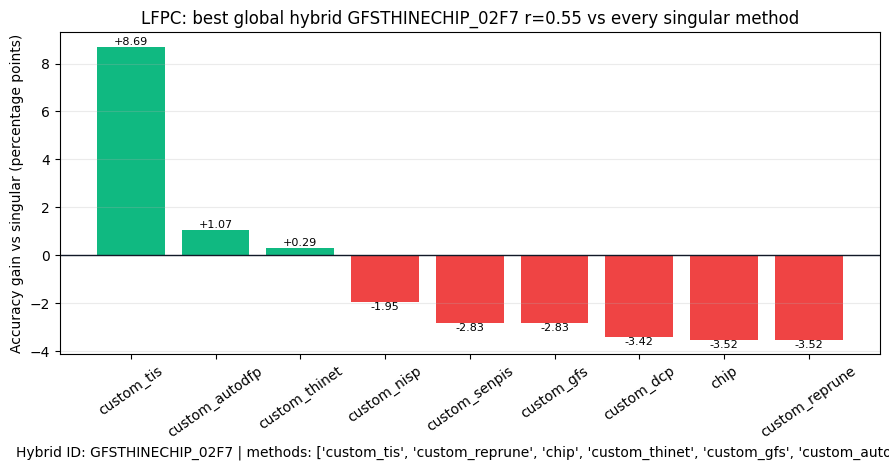

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/phase2_phase3_outputs/visuals/lfpc_phase2_hybrid_vs_all_singular_global_r0.55.png


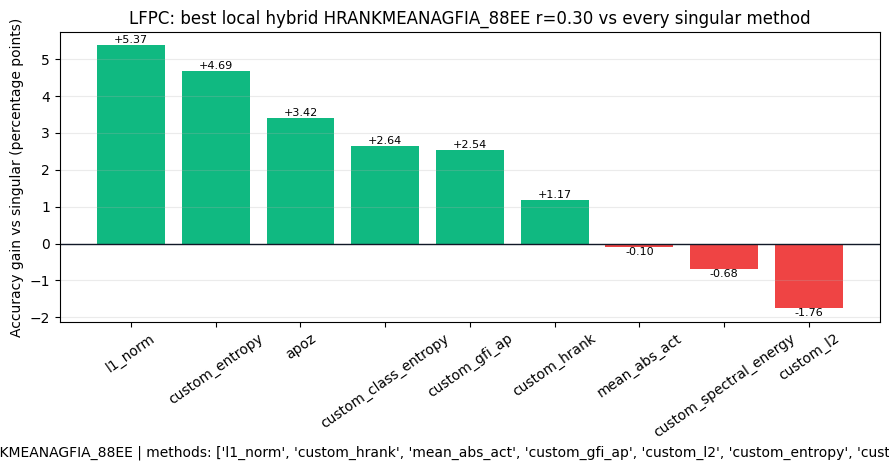

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/phase2_phase3_outputs/visuals/lfpc_phase2_hybrid_vs_all_singular_local_r0.30.png


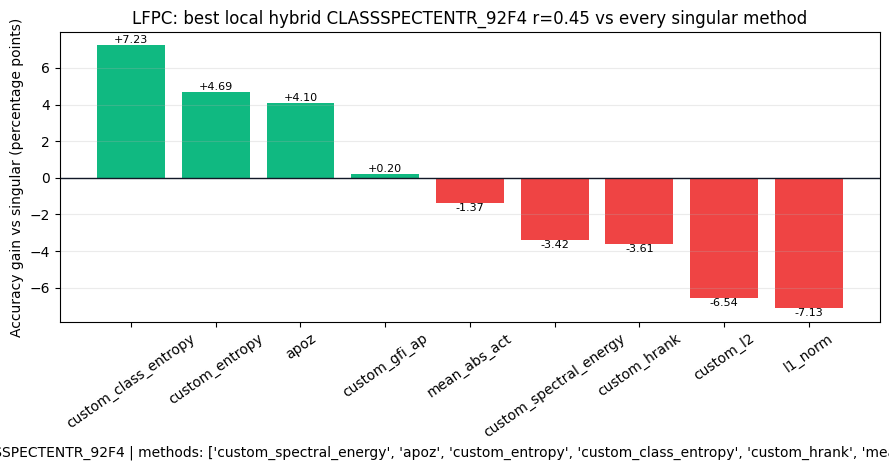

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/phase2_phase3_outputs/visuals/lfpc_phase2_hybrid_vs_all_singular_local_r0.45.png


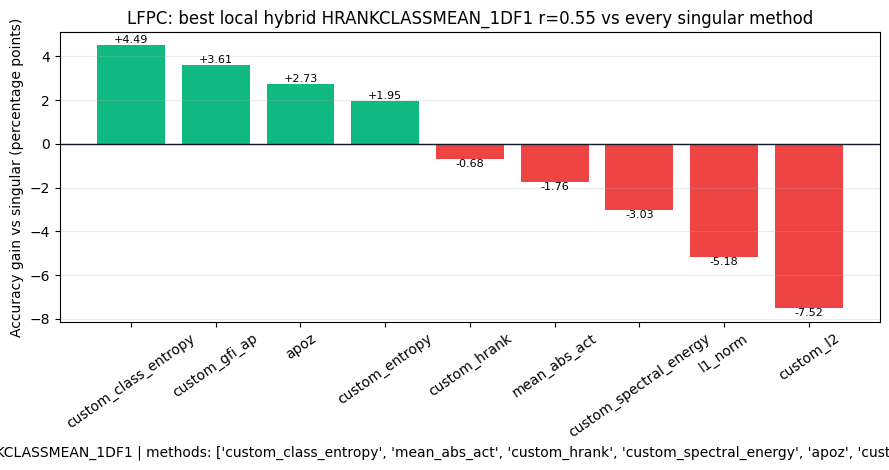

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/phase2_phase3_outputs/visuals/lfpc_phase2_hybrid_vs_all_singular_local_r0.55.png


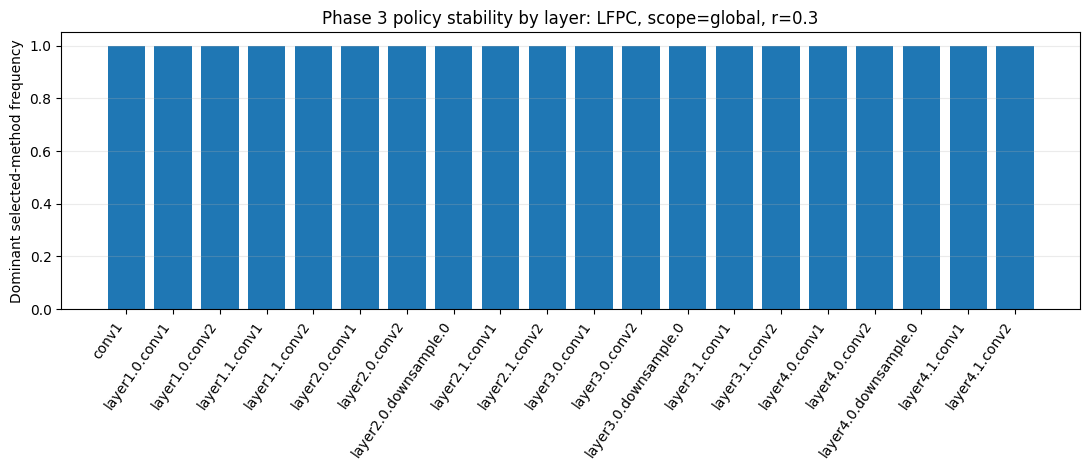

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/phase2_phase3_outputs/visuals/lfpc_phase3_policy_stability_global_r0p3.png


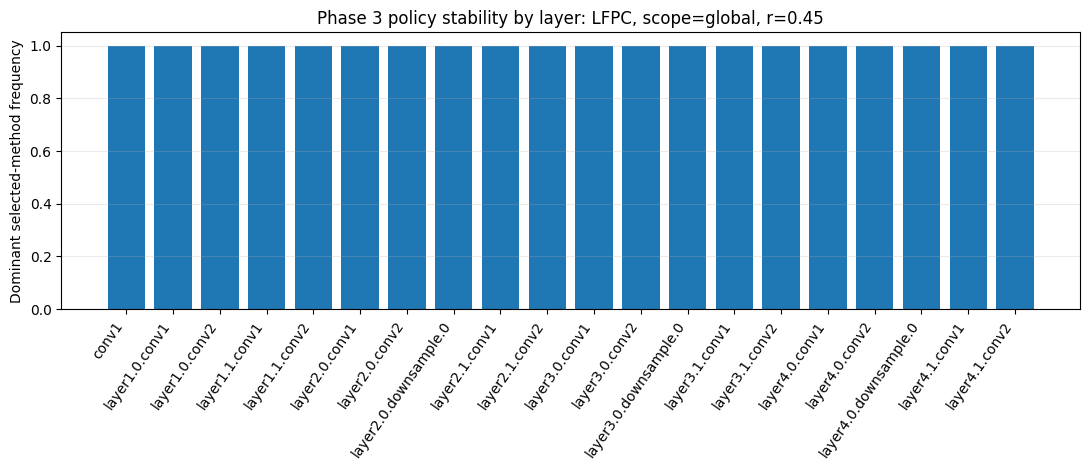

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/phase2_phase3_outputs/visuals/lfpc_phase3_policy_stability_global_r0p45.png


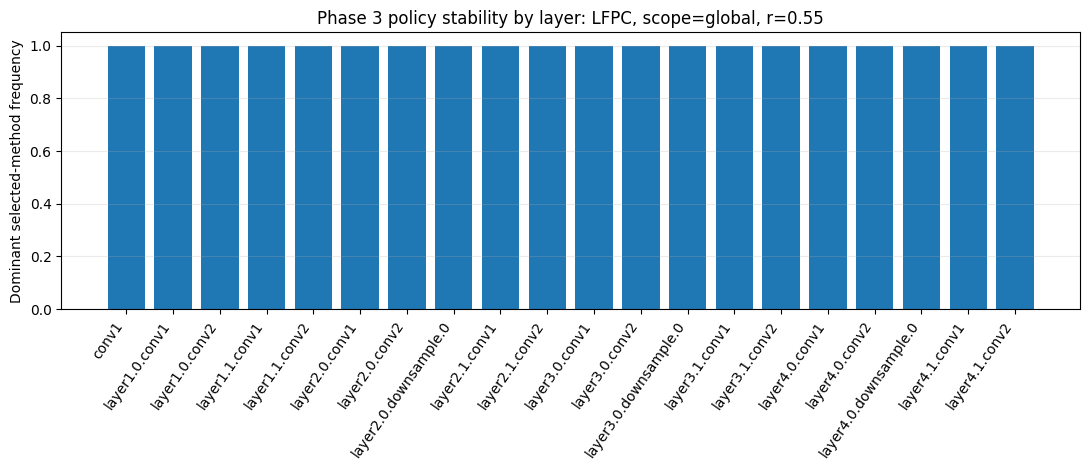

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/phase2_phase3_outputs/visuals/lfpc_phase3_policy_stability_global_r0p55.png


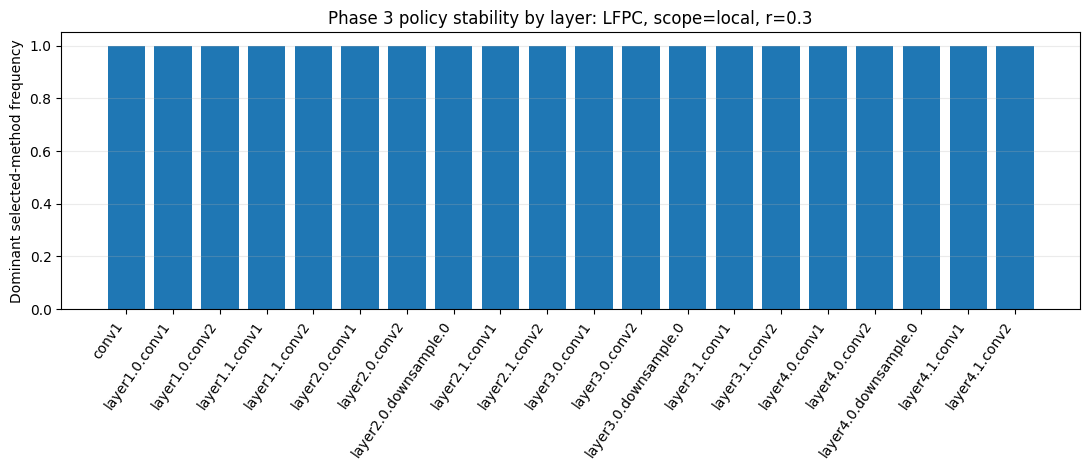

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/phase2_phase3_outputs/visuals/lfpc_phase3_policy_stability_local_r0p3.png


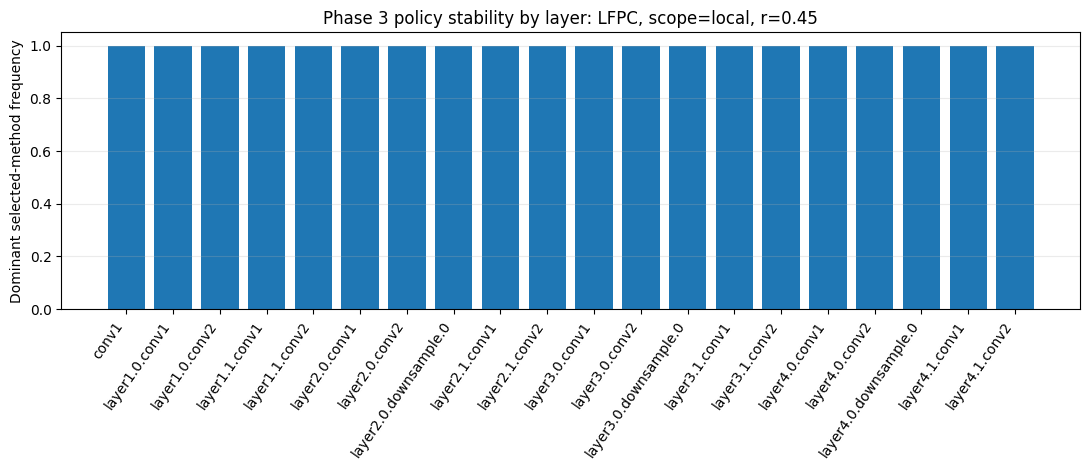

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/phase2_phase3_outputs/visuals/lfpc_phase3_policy_stability_local_r0p45.png


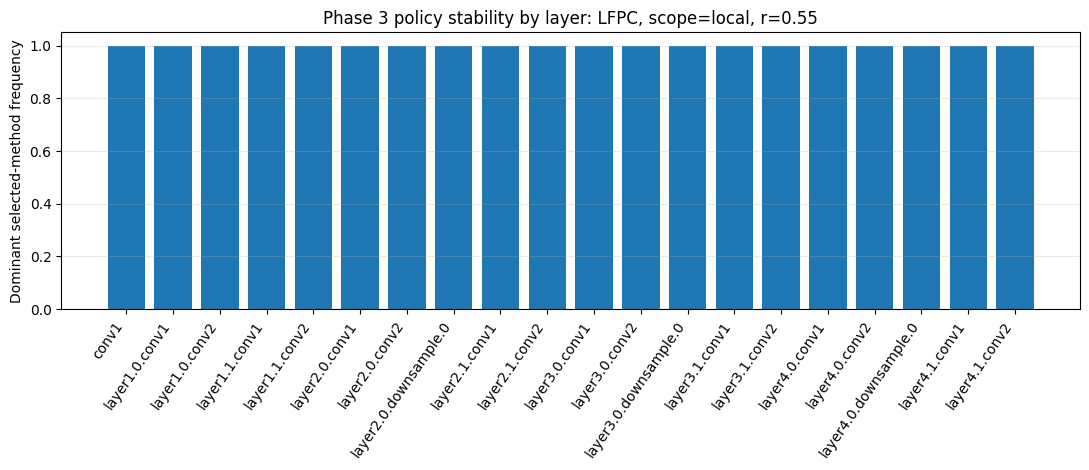

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/phase2_phase3_outputs/visuals/lfpc_phase3_policy_stability_local_r0p55.png


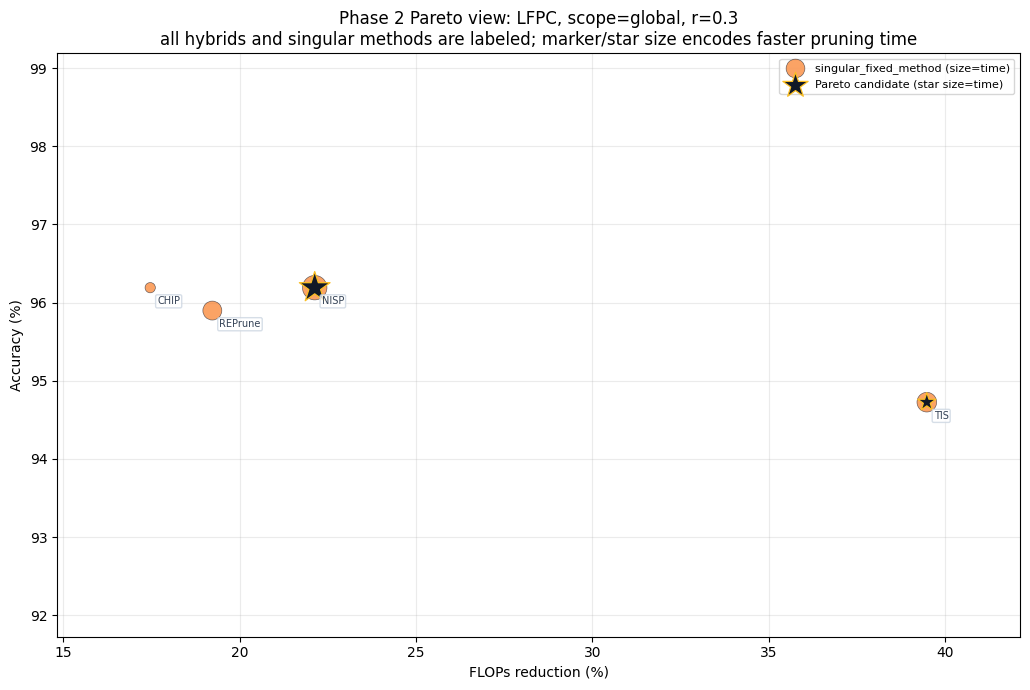

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/phase2_phase3_outputs/visuals/lfpc_phase2_pareto_global_r0p3.png


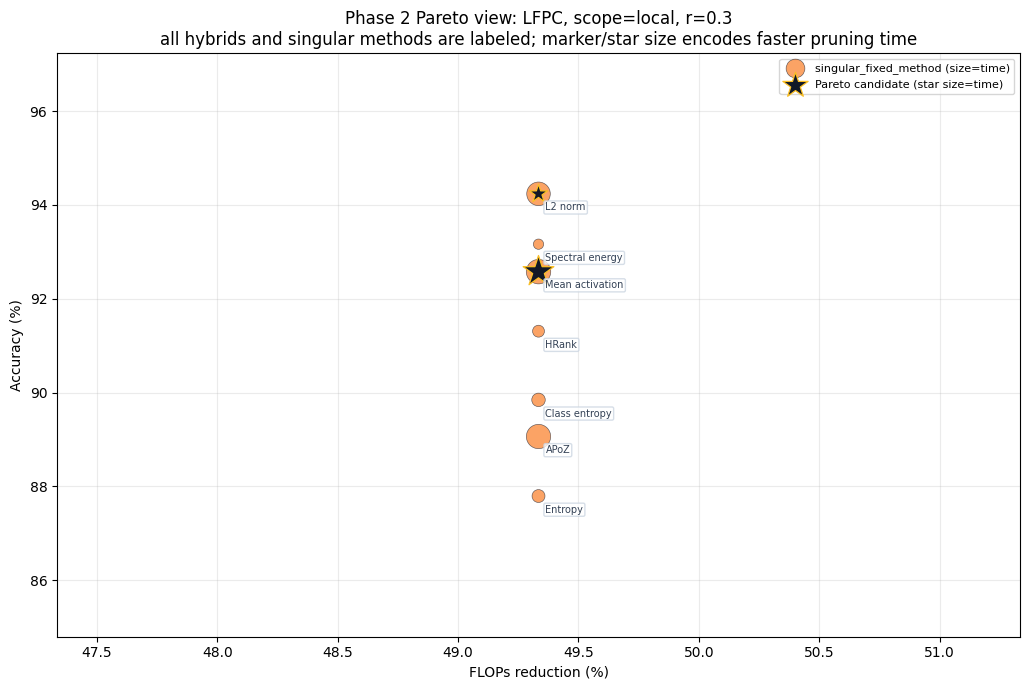

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/phase2_phase3_outputs/visuals/lfpc_phase2_pareto_local_r0p3.png
Saved seed-repeat scaffold: /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/phase2_phase3_outputs/lfpc_phase3_seed_repeat_scaffold.md

Phase 2/3 outputs saved under: /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/phase2_phase3_outputs

Best hybrid by scope/ratio


,accuracy_delta_source,accuracy_drop_constraint_active,accuracy_drop_constraint_passed,accuracy_drop_vs_baseline_pct,accuracy_source,algorithm2_lfpc_discovery_overhead_included,approach,baseline_accuracy_source,baseline_flops,baseline_params,...,standard_params_reduction_pct,standard_runtime_sec,strategy_type,structural_prune_time_sec,variance_threshold,flops_target_gap_pct,flops_target_met,flops_target_score,accuracy_target_met,objective_target_aware_score
0,healed_accuracy_delta_pct,False,True,1.611328,healed_accuracy_pct,False,LFPC,baseline_test_accuracy_pct,0.0,11177538.0,...,58.793412,1026.502519,hybrid_fixed_stack,0.305895,0.05,-inf,False,0.0,True,0.650000
1,healed_accuracy_delta_pct,False,True,2.099609,healed_accuracy_pct,False,LFPC,baseline_test_accuracy_pct,0.0,11177538.0,...,75.335964,610.027034,hybrid_fixed_stack,0.737956,0.05,-inf,False,0.0,True,0.633333
2,healed_accuracy_delta_pct,False,True,4.248047,healed_accuracy_pct,False,LFPC,baseline_test_accuracy_pct,0.0,11177538.0,...,81.438793,609.614626,hybrid_fixed_stack,0.171613,0.05,-inf,False,0.0,True,0.560000
3,healed_accuracy_delta_pct,False,True,3.466797,healed_accuracy_pct,False,LFPC,baseline_test_accuracy_pct,0.0,11177538.0,...,51.030289,173.621721,hybrid_fixed_stack,0.153304,0.05,-inf,False,0.0,True,0.586667
4,healed_accuracy_delta_pct,False,True,12.646484,healed_accuracy_pct,False,LFPC,baseline_test_accuracy_pct,0.0,11177538.0,...,69.652118,172.886918,hybrid_fixed_stack,0.096300,0.05,-inf,False,0.0,False,0.273333
5,healed_accuracy_delta_pct,False,True,17.724609,healed_accuracy_pct,False,LFPC,baseline_test_accuracy_pct,0.0,11177538.0,...,79.749172,172.743628,hybrid_fixed_stack,0.204661,0.05,-inf,False,0.0,False,0.100000



Objective-aware hybrid vs all singular counterparts


,dataset,model,scope,ratio,hybrid_stack_id,hybrid_report_id,hybrid_stack_methods,hybrid_layer_policy,variance_threshold,spearman_threshold,...,singular_method_display,hybrid_accuracy_pct,singular_accuracy_pct,accuracy_gain_vs_singular_pct,hybrid_flops_reduction_pct,singular_flops_reduction_pct,flops_gain_vs_singular_pct,hybrid_runtime_sec,singular_runtime_sec,runtime_gain_vs_singular_sec
0,cats_dogs,resnet18,global,0.30,LFPC_flops_accuracy_cats_dogs_resnet18_global_...,GFSTHINECHIP_C22A,"[custom_thinet, chip, custom_gfs, custom_tis, ...","{'conv1': 'custom_thinet', 'layer1.0.conv1': '...",0.05,0.7,...,CHIP,94.335938,96.191406,-1.855469,NaN,17.460507,NaN,1026.502519,327.772387,-698.730132
1,cats_dogs,resnet18,global,0.30,LFPC_flops_accuracy_cats_dogs_resnet18_global_...,GFSTHINECHIP_C22A,"[custom_thinet, chip, custom_gfs, custom_tis, ...","{'conv1': 'custom_thinet', 'layer1.0.conv1': '...",0.05,0.7,...,AutoDFP,94.335938,96.679688,-2.343750,NaN,NaN,NaN,1026.502519,59.018034,-967.484485
2,cats_dogs,resnet18,global,0.30,LFPC_flops_accuracy_cats_dogs_resnet18_global_...,GFSTHINECHIP_C22A,"[custom_thinet, chip, custom_gfs, custom_tis, ...","{'conv1': 'custom_thinet', 'layer1.0.conv1': '...",0.05,0.7,...,DCP,94.335938,95.703125,-1.367188,NaN,NaN,NaN,1026.502519,84.724358,-941.778161
3,cats_dogs,resnet18,global,0.30,LFPC_flops_accuracy_cats_dogs_resnet18_global_...,GFSTHINECHIP_C22A,"[custom_thinet, chip, custom_gfs, custom_tis, ...","{'conv1': 'custom_thinet', 'layer1.0.conv1': '...",0.05,0.7,...,GFS,94.335938,95.898438,-1.562500,NaN,NaN,NaN,1026.502519,88.131540,-938.370979
4,cats_dogs,resnet18,global,0.30,LFPC_flops_accuracy_cats_dogs_resnet18_global_...,GFSTHINECHIP_C22A,"[custom_thinet, chip, custom_gfs, custom_tis, ...","{'conv1': 'custom_thinet', 'layer1.0.conv1': '...",0.05,0.7,...,NISP,94.335938,96.191406,-1.855469,NaN,22.125225,NaN,1026.502519,58.009185,-968.493334
5,cats_dogs,resnet18,global,0.30,LFPC_flops_accuracy_cats_dogs_resnet18_global_...,GFSTHINECHIP_C22A,"[custom_thinet, chip, custom_gfs, custom_tis, ...","{'conv1': 'custom_thinet', 'layer1.0.conv1': '...",0.05,0.7,...,REPrune,94.335938,95.898438,-1.562500,NaN,19.222209,NaN,1026.502519,96.677228,-929.825291
6,cats_dogs,resnet18,global,0.30,LFPC_flops_accuracy_cats_dogs_resnet18_global_...,GFSTHINECHIP_C22A,"[custom_thinet, chip, custom_gfs, custom_tis, ...","{'conv1': 'custom_thinet', 'layer1.0.conv1': '...",0.05,0.7,...,SeNPIS,94.335938,96.289062,-1.953125,NaN,NaN,NaN,1026.502519,90.119784,-936.382736
7,cats_dogs,resnet18,global,0.30,LFPC_flops_accuracy_cats_dogs_resnet18_global_...,GFSTHINECHIP_C22A,"[custom_thinet, chip, custom_gfs, custom_tis, ...","{'conv1': 'custom_thinet', 'layer1.0.conv1': '...",0.05,0.7,...,ThiNet,94.335938,95.117188,-0.781250,NaN,NaN,NaN,1026.502519,88.989514,-937.513005
8,cats_dogs,resnet18,global,0.30,LFPC_flops_accuracy_cats_dogs_resnet18_global_...,GFSTHINECHIP_C22A,"[custom_thinet, chip, custom_gfs, custom_tis, ...","{'conv1': 'custom_thinet', 'layer1.0.conv1': '...",0.05,0.7,...,TIS,94.335938,94.726562,-0.390625,NaN,39.483322,NaN,1026.502519,89.981807,-936.520712
9,cats_dogs,resnet18,global,0.45,LFPC_flops_accuracy_cats_dogs_resnet18_global_...,THINECHIPNISP_9557,"[chip, custom_nisp, custom_autodfp, custom_thi...","{'conv1': 'chip', 'layer1.0.conv1': 'custom_ni...",0.05,0.7,...,CHIP,93.847656,96.777344,-2.929688,NaN,NaN,NaN,610.027034,329.105311,-280.921723



Hybrid vs all singular counterparts


...


Convergence summary


,approach,num_history_rows,scope,ratio,variance_threshold,spearman_threshold,jaccard_threshold,first_iteration,last_iteration,objective_column,first_objective,last_objective,best_objective,objective_improvement
0,LFPC,3,global,0.30,0.05,0.7,0.7,0.0,2.0,loss,0.101725,0.089317,0.089317,0.012408
1,LFPC,3,global,0.45,0.05,0.7,0.7,0.0,2.0,loss,0.148526,0.147130,0.124888,0.023638
2,LFPC,3,global,0.55,0.05,0.7,0.7,0.0,2.0,loss,0.132995,0.157710,0.132995,0.000000
3,LFPC,3,local,0.30,0.05,0.7,0.7,0.0,2.0,loss,0.106415,0.129384,0.106415,0.000000
4,LFPC,3,local,0.45,0.05,0.7,0.7,0.0,2.0,loss,0.187506,0.111851,0.102728,0.084779
5,LFPC,3,local,0.55,0.05,0.7,0.7,0.0,2.0,loss,0.131118,0.166759,0.131118,0.000000


Saved artifact completeness audit: /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/artifact_completeness_audit.csv


,artifact,status,issue
0,fixed_hybrid_stack_benchmarks,metric_values_missing,healed_flops_reduction_pct: 6/6 missing
1,current_run_singular_method_benchmarks,metric_values_missing,healed_flops_reduction_pct: 43/54 missing
2,current_run_singular_method_benchmarks,checkpoint_column_unavailable_warning,pruned_model_checkpoint_path


Set STRICT_ARTIFACT_COMPLETENESS_AUDIT=True to make this audit blocking.


In [20]:
# [ReduCNN LFPC cell note]
# Purpose: Environment, imports, and reproducibility setup.
# Mechanics: It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.
# Expected result: The notebook runtime has the libraries, paths, and helper functions needed by the experiment.


# ---------------------------------------------------------------------
# PHASE 2 + PHASE 3: Fair comparison, robustness, and stability diagnostics
# ---------------------------------------------------------------------
# This cell is intentionally robust: it reloads Phase-1 artifacts from OUT_DIR
# if the current kernel was restarted.
#
# Phase 2:
#   - Standardized benchmark table
#   - Best fixed hybrid stack per scope × pruning ratio
#   - Hybrid stacks vs every singular method at the same scope and pruning ratio
#   - Pareto diagnostics
#
# Phase 3:
#   - Policy stability across Algorithm-2 threshold-grid conditions
#   - Layer-wise dominant method / entropy / effective number of methods
#   - Search convergence summaries where history exists
#
# Runtime definition remains:
#   fixed-stack scoring + mask build + structural pruning + healing + evaluation
#   EXCLUDING Algorithm 2 and policy-search overhead.

import json
import math
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

APPROACH_NAME = "LFPC"
POLICY_DF_NAME = "lfpc_policy_df"
HYBRID_SUMMARY_DF_NAME = "fixed_stack_benchmark_df"
HISTORY_DF_NAME = "lfpc_history_df"
EVIDENCE_DF_NAME = ""

POLICY_CSV = "lfpc_discovered_layer_policy_phase1.csv"
HYBRID_SUMMARY_CSV = "fixed_hybrid_stack_benchmarks.csv"
HISTORY_CSV = "lfpc_alpha_history_discovery_phase1.csv"
EVIDENCE_CSV = ""

PHASE23_DIR = OUT_DIR / "phase2_phase3_outputs"
PHASE23_DIR.mkdir(parents=True, exist_ok=True)

RUN_PHASE3_SEED_REPEAT_SCAFFOLD = globals().get("RUN_PHASE3_SEED_REPEAT_SCAFFOLD", False)
PHASE3_STABILITY_GROUP_COLS = ["scope", "ratio"]
PHASE3_LAYER_COL = "layer"
PHASE3_METHOD_COL = "selected_method"


# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

def _load_df(global_name, csv_name):
    obj = globals().get(global_name, None)
    if isinstance(obj, pd.DataFrame) and not obj.empty:
        print(f"Using in-memory {global_name}: {obj.shape}")
        return obj.copy()

    path = OUT_DIR / csv_name if csv_name else None
    if path is not None and path.exists():
        try:
            if path.stat().st_size == 0:
                print(f"{global_name} file is empty; returning empty DataFrame: {path}")
                return pd.DataFrame()
            df = pd.read_csv(path)
            print(f"Loaded {global_name} from {path}: {df.shape}")
            return df
        except pd.errors.EmptyDataError:
            print(f"{global_name} file has no columns; returning empty DataFrame: {path}")
            return pd.DataFrame()

    print(f"{global_name} not found; returning empty DataFrame.")
    return pd.DataFrame()


def _first_col(df, candidates, default=None):
    for c in candidates:
        if c in df.columns:
            return c
    return default


def _to_num(s, default=np.nan):
    try:
        return pd.to_numeric(s, errors="coerce").fillna(default)
    except Exception:
        return pd.Series([], dtype=float)


def _safe_float(x, default=np.nan):
    try:
        if x is None:
            return default
        return float(x)
    except Exception:
        return default


def _safe_json_loads(x):
    if isinstance(x, dict):
        return x
    if isinstance(x, list):
        return x
    if not isinstance(x, str):
        return x
    try:
        return json.loads(x)
    except Exception:
        try:
            import ast
            return ast.literal_eval(x)
        except Exception:
            return x


def _json_dumps(x):
    try:
        return json.dumps(_safe_json_loads(x), default=str)
    except Exception:
        return json.dumps(str(x))


def _sanitize_filename(text):
    return (
        str(text)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
        .replace(".", "p")
        .replace("=", "")
        .replace("|", "_")
        .replace(":", "_")
    )


def _accuracy_columns(df):
    return [
        c for c in [
            "healed_accuracy_pct",
            "test_accuracy_pct",
            "final_test_accuracy_pct",
            "final_test_accuracy",
            "val_accuracy_pct",
            "validation_accuracy_pct",
            "post_heal_acc",
            "post_heal_accuracy_pct",
            "accuracy_pct",
        ]
        if c in df.columns
    ]


def _metric_series(df, candidates, default=np.nan):
    col = _first_col(df, candidates)
    if col is None:
        return pd.Series([default] * len(df), index=df.index), None
    return pd.to_numeric(df[col], errors="coerce").fillna(default), col


def _derive_accuracy(df):
    values, col = _metric_series(
        df,
        [
            "healed_accuracy_pct",
            "test_accuracy_pct",
            "final_test_accuracy_pct",
            "final_test_accuracy",
            "val_accuracy_pct",
            "validation_accuracy_pct",
            "post_heal_acc",
            "post_heal_accuracy_pct",
            "accuracy_pct",
        ],
        default=np.nan,
    )
    return values, col or "not_available"


def _derive_baseline_accuracy(df):
    values, col = _metric_series(
        df,
        [
            "baseline_test_accuracy_pct",
            "baseline_validation_accuracy_pct",
            "baseline_accuracy_pct",
            "baseline_accuracy",
            "baseline_acc",
        ],
        default=np.nan,
    )
    return values, col or "not_available"


def _derive_accuracy_delta(df):
    values, col = _metric_series(
        df,
        [
            "healed_accuracy_delta_pct",
            "accuracy_delta_pct",
            "test_accuracy_delta_pct",
            "val_accuracy_delta_pct",
            "final_accuracy_delta_pct",
        ],
        default=np.nan,
    )
    if col is not None:
        return values, col

    acc, acc_col = _derive_accuracy(df)
    base, base_col = _derive_baseline_accuracy(df)
    if acc_col != "not_available" and base_col != "not_available":
        return (acc - base), f"{acc_col} - {base_col}"

    return pd.Series([np.nan] * len(df), index=df.index), "not_available"


def _derive_flops(df):
    values, col = _metric_series(
        df,
        [
            "healed_flops_reduction_pct",
            "flops_reduction_pct",
            "final_flops_reduction_pct",
            "actual_flops_reduction_pct",
            "flops_reduction",
        ],
        default=np.nan,
    )
    if col is not None:
        return values, col

    base_col = _first_col(df, ["baseline_flops", "original_flops"])
    final_col = _first_col(df, ["pruned_flops", "final_flops", "healed_flops"])
    if base_col and final_col:
        base = pd.to_numeric(df[base_col], errors="coerce")
        final = pd.to_numeric(df[final_col], errors="coerce")
        return ((base - final) / base.replace(0, np.nan) * 100), f"derived:{base_col}/{final_col}"

    return pd.Series([np.nan] * len(df), index=df.index), "not_available"


def _derive_params(df):
    values, col = _metric_series(
        df,
        [
            "healed_params_reduction_pct",
            "params_reduction_pct",
            "final_params_reduction_pct",
            "actual_params_reduction_pct",
            "params_reduction",
        ],
        default=np.nan,
    )
    if col is not None:
        return values, col

    base_col = _first_col(df, ["baseline_params", "original_params"])
    final_col = _first_col(df, ["pruned_params", "final_params", "healed_params"])
    if base_col and final_col:
        base = pd.to_numeric(df[base_col], errors="coerce")
        final = pd.to_numeric(df[final_col], errors="coerce")
        return ((base - final) / base.replace(0, np.nan) * 100), f"derived:{base_col}/{final_col}"

    return pd.Series([np.nan] * len(df), index=df.index), "not_available"


def _derive_runtime(df):
    values, col = _metric_series(
        df,
        [
            "end_to_end_pruning_time_sec",
            "fixed_stack_end_to_end_pruning_time_sec",
            "fixed_strategy_e2e",
            "total_time_sec",
            "pruning_time_sec",
            "fixed_stack_score_time_sec",
        ],
        default=np.nan,
    )
    return values, col or "not_available"


def _standardize_hybrid_summary(df, approach_name):
    if df.empty:
        return pd.DataFrame()

    out = df.copy()

    acc, acc_source = _derive_accuracy(out)
    acc_delta, acc_delta_source = _derive_accuracy_delta(out)
    flops, flops_source = _derive_flops(out)
    params, params_source = _derive_params(out)
    runtime, runtime_source = _derive_runtime(out)
    base_acc, base_source = _derive_baseline_accuracy(out)

    if "method_or_stack" not in out.columns:
        if "stack_id" in out.columns:
            out["method_or_stack"] = out["stack_id"].astype(str)
        else:
            out["method_or_stack"] = approach_name + "_fixed_stack"

    out["approach"] = approach_name
    out["strategy_type"] = "hybrid_fixed_stack"
    out["standard_accuracy_pct"] = acc
    out["standard_accuracy_delta_pct"] = acc_delta
    out["standard_flops_reduction_pct"] = flops
    out["standard_params_reduction_pct"] = params
    out["standard_runtime_sec"] = runtime
    out["standard_baseline_accuracy_pct"] = base_acc

    out["accuracy_source"] = acc_source
    out["accuracy_delta_source"] = acc_delta_source
    out["flops_source"] = flops_source
    out["params_source"] = params_source
    out["runtime_source"] = runtime_source
    out["baseline_accuracy_source"] = base_source

    out["policy_discovery_overhead_included_in_benchmark"] = False
    out["runtime_definition_phase23"] = (
        "fixed-stack scoring + mask build + structural pruning + healing/fine-tuning + evaluation; "
        "excludes Algorithm 2 and policy-search overhead"
    )
    return out


def _standardize_singular(df):
    if df.empty:
        return pd.DataFrame()

    out = df.copy()

    acc, acc_source = _derive_accuracy(out)
    acc_delta, acc_delta_source = _derive_accuracy_delta(out)
    flops, flops_source = _derive_flops(out)
    params, params_source = _derive_params(out)
    runtime, runtime_source = _derive_runtime(out)
    base_acc, base_source = _derive_baseline_accuracy(out)

    if "method_or_stack" not in out.columns:
        out["method_or_stack"] = out["method"].astype(str) if "method" in out.columns else "singular_method"
    if "method" not in out.columns:
        out["method"] = out["method_or_stack"].astype(str)

    out["approach"] = "SingularBaseline"
    out["strategy_type"] = "singular_fixed_method"
    out["standard_accuracy_pct"] = acc
    out["standard_accuracy_delta_pct"] = acc_delta
    out["standard_flops_reduction_pct"] = flops
    out["standard_params_reduction_pct"] = params
    out["standard_runtime_sec"] = runtime
    out["standard_baseline_accuracy_pct"] = base_acc

    out["accuracy_source"] = acc_source
    out["accuracy_delta_source"] = acc_delta_source
    out["flops_source"] = flops_source
    out["params_source"] = params_source
    out["runtime_source"] = runtime_source
    out["baseline_accuracy_source"] = base_source

    out["policy_discovery_overhead_included_in_benchmark"] = False
    out["runtime_definition_phase23"] = (
        "single-method scoring + mask build + structural pruning + healing/fine-tuning + evaluation"
    )
    return out


def _select_best_hybrid(df):
    if df.empty:
        return pd.DataFrame()

    work = df.copy()
    for col in ["standard_accuracy_pct", "standard_flops_reduction_pct", "standard_runtime_sec"]:
        work[col] = pd.to_numeric(work[col], errors="coerce")

    work = _phase23_target_aware_score(work)
    work["_runtime_sort"] = work["standard_runtime_sec"].fillna(np.inf)
    sort_cols = ["accuracy_target_met", "flops_target_met", "objective_target_aware_score", "standard_accuracy_delta_pct", "standard_accuracy_pct", "standard_flops_reduction_pct", "_runtime_sort"]
    sort_cols = [c for c in sort_cols if c in work.columns]
    ascending = [False, False, False, False, False, False, True][:len(sort_cols)]

    group_cols = [c for c in ["scope", "ratio"] if c in work.columns]
    if len(group_cols) < 2:
        return work.sort_values(sort_cols, ascending=ascending, na_position="last").head(1).drop(columns=["_runtime_sort"], errors="ignore")

    idx_rows = []
    for _, g in work.groupby(group_cols, dropna=False):
        best = g.sort_values(sort_cols, ascending=ascending, na_position="last").iloc[0]
        idx_rows.append(best)

    return pd.DataFrame(idx_rows).drop(columns=["_runtime_sort"], errors="ignore")


def _best_singular_by_scope_ratio(singular_std):
    if singular_std.empty:
        return pd.DataFrame()

    work = singular_std.copy()
    for col in ["standard_accuracy_pct", "standard_flops_reduction_pct", "standard_runtime_sec"]:
        work[col] = pd.to_numeric(work[col], errors="coerce")
    work["_runtime_sort"] = work["standard_runtime_sec"].fillna(np.inf)

    rows = []
    group_cols = [c for c in ["scope", "ratio"] if c in work.columns]
    if len(group_cols) < 2:
        rows.append(work.sort_values(
            ["standard_accuracy_pct", "standard_flops_reduction_pct", "_runtime_sort"],
            ascending=[False, False, True],
        ).iloc[0])
    else:
        for _, g in work.groupby(group_cols, dropna=False):
            rows.append(g.sort_values(
                ["standard_accuracy_pct", "standard_flops_reduction_pct", "_runtime_sort"],
                ascending=[False, False, True],
            ).iloc[0])

    return pd.DataFrame(rows).drop(columns=["_runtime_sort"], errors="ignore")


def _policy_stability(policy_df, approach_name):
    if policy_df.empty:
        return pd.DataFrame(), pd.DataFrame()

    required = {"scope", "ratio", "layer", "selected_method"}
    if not required.issubset(policy_df.columns):
        print("Policy dataframe missing stability columns:", required - set(policy_df.columns))
        return pd.DataFrame(), pd.DataFrame()

    rows = []
    for (scope, ratio, layer), grp in policy_df.groupby(["scope", "ratio", "layer"], dropna=False):
        methods = grp["selected_method"].astype(str)
        counts = methods.value_counts()
        total = int(counts.sum())
        dominant = counts.index[0] if total else None
        dominant_count = int(counts.iloc[0]) if total else 0
        stability_rate = dominant_count / total if total else np.nan

        probs = counts.values.astype(float) / total if total else np.array([])
        entropy = float(-(probs * np.log(probs + 1e-12)).sum()) if probs.size else np.nan
        normalized_entropy = float(entropy / np.log(len(probs))) if probs.size > 1 else 0.0
        effective_methods = float(np.exp(entropy)) if probs.size else np.nan

        rows.append({
            "approach": approach_name,
            "scope": scope,
            "ratio": ratio,
            "layer": layer,
            "num_conditions": total,
            "num_unique_selected_methods": int(len(counts)),
            "dominant_method": dominant,
            "dominant_method_count": dominant_count,
            "stability_rate": stability_rate,
            "selection_entropy": entropy,
            "normalized_selection_entropy": normalized_entropy,
            "effective_num_selected_methods": effective_methods,
            "method_frequency_json": json.dumps(counts.to_dict(), default=str),
            "stability_label": (
                "stable" if stability_rate >= 0.80 else
                "moderate" if stability_rate >= 0.60 else
                "unstable"
            ),
        })

    layer_stability = pd.DataFrame(rows)

    summary_rows = []
    if not layer_stability.empty:
        for (scope, ratio), grp in layer_stability.groupby(["scope", "ratio"], dropna=False):
            summary_rows.append({
                "approach": approach_name,
                "scope": scope,
                "ratio": ratio,
                "num_layers": int(len(grp)),
                "mean_stability_rate": float(grp["stability_rate"].mean()),
                "median_stability_rate": float(grp["stability_rate"].median()),
                "num_stable_layers": int((grp["stability_rate"] >= 0.80).sum()),
                "num_moderate_layers": int(((grp["stability_rate"] >= 0.60) & (grp["stability_rate"] < 0.80)).sum()),
                "num_unstable_layers": int((grp["stability_rate"] < 0.60).sum()),
                "mean_effective_num_selected_methods": float(grp["effective_num_selected_methods"].mean()),
            })
    condition_summary = pd.DataFrame(summary_rows)

    return layer_stability, condition_summary


def _convergence_summary(history_df, evidence_df, approach_name):
    rows = []

    if not history_df.empty:
        # Try to find objective/reward/loss columns.
        objective_col = _first_col(history_df, ["objective", "mean_objective", "loss", "task_loss", "total_loss", "val_loss"])
        reward_col = _first_col(history_df, ["reward", "mean_reward", "best_reward"])
        iter_col = _first_col(history_df, ["iteration", "epoch", "step"])

        group_cols = [c for c in ["scope", "ratio", "variance_threshold", "spearman_threshold", "jaccard_threshold"] if c in history_df.columns]

        if group_cols:
            iterator = history_df.groupby(group_cols, dropna=False)
        else:
            iterator = [(("all",), history_df)]

        for keys, grp in iterator:
            rec = {"approach": approach_name, "num_history_rows": int(len(grp))}
            if group_cols:
                if not isinstance(keys, tuple):
                    keys = (keys,)
                rec.update({col: val for col, val in zip(group_cols, keys)})

            if iter_col:
                rec["first_iteration"] = _safe_float(pd.to_numeric(grp[iter_col], errors="coerce").min())
                rec["last_iteration"] = _safe_float(pd.to_numeric(grp[iter_col], errors="coerce").max())

            if objective_col:
                vals = pd.to_numeric(grp[objective_col], errors="coerce")
                rec["objective_column"] = objective_col
                rec["first_objective"] = _safe_float(vals.iloc[0])
                rec["last_objective"] = _safe_float(vals.iloc[-1])
                rec["best_objective"] = _safe_float(vals.min())
                rec["objective_improvement"] = _safe_float(vals.iloc[0] - vals.min())

            if reward_col:
                vals = pd.to_numeric(grp[reward_col], errors="coerce")
                rec["reward_column"] = reward_col
                rec["first_reward"] = _safe_float(vals.iloc[0])
                rec["last_reward"] = _safe_float(vals.iloc[-1])
                rec["best_reward"] = _safe_float(vals.max())
                rec["reward_improvement"] = _safe_float(vals.max() - vals.iloc[0])

            rows.append(rec)

    # Evidence summary for Bayesian-style evidence trail.
    if not evidence_df.empty:
        reward_col = _first_col(evidence_df, ["reward", "policy_reward", "alpha_increment"])
        if reward_col:
            rec = {
                "approach": approach_name,
                "num_evidence_rows": int(len(evidence_df)),
                "evidence_reward_column": reward_col,
                "mean_evidence_reward": _safe_float(pd.to_numeric(evidence_df[reward_col], errors="coerce").mean()),
                "max_evidence_reward": _safe_float(pd.to_numeric(evidence_df[reward_col], errors="coerce").max()),
            }
            rows.append(rec)

    return pd.DataFrame(rows)


def _mark_pareto(df):
    if df.empty:
        return df
    work = df.copy()
    acc = pd.to_numeric(work["standard_accuracy_pct"], errors="coerce").fillna(-np.inf).values
    flops = pd.to_numeric(work["standard_flops_reduction_pct"], errors="coerce").fillna(-np.inf).values
    runtime = pd.to_numeric(work["standard_runtime_sec"], errors="coerce").fillna(np.inf).values

    is_pareto = np.ones(len(work), dtype=bool)
    for i in range(len(work)):
        for j in range(len(work)):
            if i == j:
                continue
            # j dominates i if >= acc, >= flops, <= runtime, and strictly better in one.
            dominates = (
                acc[j] >= acc[i]
                and flops[j] >= flops[i]
                and runtime[j] <= runtime[i]
                and (
                    acc[j] > acc[i]
                    or flops[j] > flops[i]
                    or runtime[j] < runtime[i]
                )
            )
            if dominates:
                is_pareto[i] = False
                break
    work["is_pareto_candidate"] = is_pareto
    return work



def _phase23_stack_report_token(method):
    import re
    aliases = {
        "l1_norm": "L1", "custom_l2": "L2", "mean_abs_act": "MeanAct", "apoz": "APoZ",
        "custom_entropy": "Entropy", "custom_class_entropy": "ClassEntropy", "custom_hrank": "HRank",
        "custom_spectral_energy": "Spectral", "custom_reprune": "REPrune", "custom_tis": "TIS",
        "custom_nisp": "NISP", "chip": "CHIP", "custom_autodfp": "AutoDFP", "custom_gfi_ap": "GFIAP",
        "custom_thinet": "ThiNet", "custom_dcp": "DCP", "custom_senpips": "SeNPIPS", "custom_gfs": "GFS",
    }
    raw = str(method).strip().strip("[](){}'\"")
    text = aliases.get(raw.lower())
    if text is None:
        text = method_display_name(raw) if "method_display_name" in globals() else raw
    text = re.sub(r"[^A-Za-z0-9]+", "", str(text)).upper()
    return text[:5] or "METH"


def _phase23_parse_methods(value):
    if isinstance(value, (list, tuple, set)):
        return [str(x) for x in value]
    if isinstance(value, str):
        try:
            import ast
            parsed = ast.literal_eval(value)
            if isinstance(parsed, (list, tuple, set)):
                return [str(x) for x in parsed]
        except Exception:
            pass
        return [x.strip().strip("[](){}'\"") for x in re.split(r"[,+|]", value) if x.strip().strip("[](){}'\"")]
    return []


def _phase23_method_display_label(method):
    raw = str(method).strip().strip("[](){}'\"")
    if not raw or raw.lower() == "nan":
        return "unknown"
    try:
        return str(method_display_name(raw))
    except Exception:
        aliases = {
            "l1_norm": "L1", "custom_l2": "L2", "mean_abs_act": "MeanAct", "apoz": "APoZ",
            "custom_entropy": "Entropy", "custom_class_entropy": "ClassEntropy", "custom_hrank": "HRank",
            "custom_spectral_energy": "Spectral", "custom_reprune": "REPrune", "custom_tis": "TIS",
            "custom_nisp": "NISP", "chip": "CHIP", "custom_autodfp": "AutoDFP", "custom_gfi_ap": "GFI-AP",
            "custom_thinet": "ThiNet", "custom_dcp": "DCP", "custom_senpips": "SeNPIPS", "custom_senpis": "SeNPIPS", "custom_gfs": "GFS",
        }
        return aliases.get(raw.lower(), raw)


def _phase23_stack_display_id(row):
    import hashlib
    strategy = str(row.get("strategy_type", ""))
    if strategy == "hybrid_fixed_stack":
        methods = _phase23_parse_methods(row.get("selected_methods_in_layer_order", row.get("selected_methods", "")))
        if not methods:
            methods = _phase23_parse_methods(row.get("method_or_stack", row.get("stack_id", "stack")))
        key = row.get("stack_id", row.get("method_or_stack", "stack"))
        methods = [str(m) for m in methods if str(m) and str(m).lower() != "nan"] or ["stack"]
        dominant = list(pd.Series(methods).value_counts().index[:3])
        # Canonical hybrid policy ID shared with layerwise plots: no separators in
        # the dominant-method prefix, underscore before digest, digest based on
        # layer-order methods + stack_id.
        prefix = "".join(_phase23_stack_report_token(m) for m in dominant)[:14]
        digest_source = "|".join(methods) + "|" + str(key)
        digest = hashlib.blake2s(digest_source.encode("utf-8"), digest_size=2).hexdigest().upper()
        return f"{prefix}_{digest}"
    method = row.get("method", row.get("method_or_stack", "singular"))
    return _phase23_method_display_label(method)


def _phase23_norm_high(series):
    s = pd.to_numeric(series, errors="coerce")
    lo, hi = s.min(), s.max()
    if not np.isfinite(lo) or not np.isfinite(hi) or abs(hi - lo) < 1e-12:
        return pd.Series(0.5, index=s.index)
    return (s - lo) / (hi - lo)


def _phase23_norm_low(series):
    return 1.0 - _phase23_norm_high(series)


def _phase23_target_pct(value):
    try:
        v = float(value)
    except Exception:
        return np.nan
    if not np.isfinite(v):
        return np.nan
    return 100.0 * v if v <= 1.0 else v


def _phase23_target_aware_score(frame):
    work = frame.copy()
    for col in ["standard_accuracy_delta_pct", "standard_accuracy_pct", "standard_flops_reduction_pct", "standard_runtime_sec"]:
        if col not in work.columns:
            work[col] = np.nan
        work[col] = pd.to_numeric(work[col], errors="coerce")
    acc_delta = work["standard_accuracy_delta_pct"]
    if acc_delta.isna().all() and {"standard_accuracy_pct", "standard_baseline_accuracy_pct"}.issubset(work.columns):
        acc_delta = pd.to_numeric(work["standard_accuracy_pct"], errors="coerce") - pd.to_numeric(work["standard_baseline_accuracy_pct"], errors="coerce")
    acc_score = _phase23_norm_high(acc_delta)
    flops_score = _phase23_norm_high(work["standard_flops_reduction_pct"])
    time_score = _phase23_norm_low(work["standard_runtime_sec"])
    target_flops_pct = _phase23_target_pct(globals().get("LFPC_TARGET_FLOPS_REDUCTION", np.nan))
    if np.isfinite(target_flops_pct):
        flops_gap = (work["standard_flops_reduction_pct"] - target_flops_pct).fillna(-np.inf)
        work["flops_target_gap_pct"] = flops_gap
        work["flops_target_met"] = flops_gap >= -1e-9
        # Reward getting to the target first; above-target reductions still compete via flops_score.
        work["flops_target_score"] = (work["standard_flops_reduction_pct"] / max(target_flops_pct, 1e-9)).clip(lower=0.0, upper=1.0).fillna(0.0)
    else:
        work["flops_target_gap_pct"] = np.nan
        work["flops_target_met"] = False
        work["flops_target_score"] = flops_score
    max_drop = float(globals().get("MAX_ALLOWED_ACCURACY_DROP_PCT", 7.0))
    work["accuracy_target_met"] = acc_delta >= -max_drop
    terms = set(globals().get("OPTIMIZED_OBJECTIVE_TERMS", ()))
    if terms == {"flops", "accuracy"}:
        score = 0.55 * acc_score + 0.25 * work["flops_target_score"] + 0.20 * flops_score
    elif terms == {"time", "accuracy"}:
        score = 0.60 * acc_score + 0.40 * time_score
    elif terms == {"time", "flops"}:
        score = 0.40 * time_score + 0.35 * work["flops_target_score"] + 0.25 * flops_score
    else:
        score = 0.50 * acc_score + 0.20 * work["flops_target_score"] + 0.15 * flops_score + 0.15 * time_score
    work["objective_target_aware_score"] = pd.to_numeric(score, errors="coerce")
    return work


def add_phase23_stack_annotations(df):
    if df.empty:
        return df
    work = df.copy()
    work["stack_display_id"] = work.apply(_phase23_stack_display_id, axis=1)
    work["stack_plot_label"] = work["stack_display_id"]
    hybrid_mask = work.get("strategy_type", pd.Series(index=work.index, dtype=str)).astype(str).eq("hybrid_fixed_stack")
    work["stack_report_rank"] = np.nan
    if hybrid_mask.any():
        h = work.loc[hybrid_mask].copy()
        acc_col = "standard_accuracy_pct" if "standard_accuracy_pct" in h.columns else "accuracy_change_pp"
        flops_col = "standard_flops_reduction_pct" if "standard_flops_reduction_pct" in h.columns else "flops_reduction_pct"
        time_col = "standard_runtime_sec" if "standard_runtime_sec" in h.columns else "fixed_pruning_time_sec"
        if acc_col not in h.columns:
            h[acc_col] = np.nan
        if flops_col not in h.columns:
            h[flops_col] = np.nan
        if time_col not in h.columns:
            h[time_col] = np.nan
        h = _phase23_target_aware_score(h.rename(columns={acc_col: "standard_accuracy_pct", flops_col: "standard_flops_reduction_pct", time_col: "standard_runtime_sec"}) if acc_col != "standard_accuracy_pct" or flops_col != "standard_flops_reduction_pct" or time_col != "standard_runtime_sec" else h)
        h["_rank_score"] = h["objective_target_aware_score"]
        sort_cols = ["accuracy_target_met", "flops_target_met", "_rank_score", "standard_accuracy_delta_pct", "standard_accuracy_pct", "standard_flops_reduction_pct", "standard_runtime_sec"]
        sort_cols = [c for c in sort_cols if c in h.columns]
        ascending = [False, False, False, False, False, False, True][:len(sort_cols)]
        h = h.sort_values(sort_cols, ascending=ascending, na_position="last")
        for rank, idx in enumerate(h.index, start=1):
            work.at[idx, "stack_report_rank"] = rank
            work.at[idx, "stack_plot_label"] = f"#{rank} {work.at[idx, 'stack_display_id']}"
    return work


def pareto_size_from_runtime(runtime_values, min_size=70, max_size=360):
    rt = pd.to_numeric(runtime_values, errors="coerce")
    finite = rt[np.isfinite(rt) & (rt > 0)]
    if finite.empty:
        return pd.Series((min_size + max_size) / 2, index=rt.index)
    filled = rt.fillna(finite.median()).clip(lower=max(float(finite.min()), 1e-9))
    inv = 1.0 / filled
    lo, hi = inv.min(), inv.max()
    if abs(hi - lo) < 1e-12:
        return pd.Series((min_size + max_size) / 2, index=rt.index)
    return min_size + (inv - lo) / (hi - lo) * (max_size - min_size)


# ---------------------------------------------------------------------
# Load Phase-1 artifacts
# ---------------------------------------------------------------------

policy_df = _load_df(POLICY_DF_NAME, POLICY_CSV)
hybrid_summary_df = _load_df(HYBRID_SUMMARY_DF_NAME, HYBRID_SUMMARY_CSV)
history_df = _load_df(HISTORY_DF_NAME, HISTORY_CSV) if HISTORY_CSV else pd.DataFrame()
evidence_df = _load_df(EVIDENCE_DF_NAME, EVIDENCE_CSV) if EVIDENCE_CSV else pd.DataFrame()

singular_df_phase23 = _load_df("singular_df", "current_run_singular_method_benchmarks.csv")

if policy_df.empty:
    print("WARNING: Policy dataframe is empty. Run Phase 1 policy discovery first.")
if hybrid_summary_df.empty:
    print("WARNING: Hybrid benchmark summary dataframe is empty. Run fixed-stack benchmark first.")
if singular_df_phase23.empty:
    print("WARNING: Singular benchmark dataframe is empty. Phase 2 singular comparisons will be limited.")


# ---------------------------------------------------------------------
# Phase 2: standardized fair benchmark and best-stack selection
# ---------------------------------------------------------------------

hybrid_std = _standardize_hybrid_summary(hybrid_summary_df, APPROACH_NAME)
singular_std = _standardize_singular(singular_df_phase23)

common_cols = sorted(set(hybrid_std.columns).union(set(singular_std.columns)))
if not hybrid_std.empty:
    hybrid_std = hybrid_std.reindex(columns=common_cols)
if not singular_std.empty:
    singular_std = singular_std.reindex(columns=common_cols)

phase23_benchmark_df = pd.concat([hybrid_std, singular_std], ignore_index=True) if (not hybrid_std.empty or not singular_std.empty) else pd.DataFrame()

if not phase23_benchmark_df.empty:
    phase23_benchmark_df = add_phase23_stack_annotations(phase23_benchmark_df)
    phase23_benchmark_df = _mark_pareto(phase23_benchmark_df)

phase23_benchmark_path = PHASE23_DIR / f"{APPROACH_NAME.lower()}_phase23_standardized_benchmark_table.csv"
phase23_benchmark_json = PHASE23_DIR / f"{APPROACH_NAME.lower()}_phase23_standardized_benchmark_table.json"
phase23_benchmark_df.to_csv(phase23_benchmark_path, index=False)
with open(phase23_benchmark_json, "w", encoding="utf-8") as f:
    json.dump(phase23_benchmark_df.to_dict(orient="records"), f, indent=2, default=str)

print("Saved standardized benchmark table:", phase23_benchmark_path)

best_hybrid_df = _select_best_hybrid(hybrid_std)
best_singular_df = _best_singular_by_scope_ratio(singular_std)

best_hybrid_path = PHASE23_DIR / f"{APPROACH_NAME.lower()}_phase23_best_hybrid_by_scope_ratio.csv"
best_hybrid_df.to_csv(best_hybrid_path, index=False)
print("Saved best hybrid table:", best_hybrid_path)

# Secondary single-top-singular summary retained only as a compact diagnostic.
comparison_rows = []
if not best_hybrid_df.empty:
    for _, h in best_hybrid_df.iterrows():
        scope = h.get("scope")
        ratio = h.get("ratio")
        srow = None
        if not best_singular_df.empty and "scope" in best_singular_df.columns and "ratio" in best_singular_df.columns:
            sub = best_singular_df[
                (best_singular_df["scope"].astype(str) == str(scope))
                & np.isclose(best_singular_df["ratio"].astype(float), float(ratio))
            ].copy()
            if not sub.empty:
                srow = sub.iloc[0]

        comparison_rows.append({
            "approach": APPROACH_NAME,
            "scope": scope,
            "ratio": ratio,
            "best_hybrid_stack": h.get("method_or_stack", h.get("stack_id")),
            "best_hybrid_accuracy_pct": _safe_float(h.get("standard_accuracy_pct")),
            "best_hybrid_accuracy_delta_pct": _safe_float(h.get("standard_accuracy_delta_pct")),
            "best_hybrid_flops_reduction_pct": _safe_float(h.get("standard_flops_reduction_pct")),
            "best_hybrid_params_reduction_pct": _safe_float(h.get("standard_params_reduction_pct")),
            "best_hybrid_runtime_sec": _safe_float(h.get("standard_runtime_sec")),
            "best_hybrid_variance_threshold": h.get("variance_threshold"),
            "best_hybrid_spearman_threshold": h.get("spearman_threshold"),
            "best_hybrid_jaccard_threshold": h.get("jaccard_threshold"),
            "best_singular_method": None if srow is None else srow.get("method", srow.get("method_or_stack")),
            "best_singular_method_display": None if srow is None else method_display_name(srow.get("method", srow.get("method_or_stack"))),
            "best_singular_accuracy_pct": None if srow is None else _safe_float(srow.get("standard_accuracy_pct")),
            "best_singular_flops_reduction_pct": None if srow is None else _safe_float(srow.get("standard_flops_reduction_pct")),
            "best_singular_params_reduction_pct": None if srow is None else _safe_float(srow.get("standard_params_reduction_pct")),
            "best_singular_runtime_sec": None if srow is None else _safe_float(srow.get("standard_runtime_sec")),
            "accuracy_gain_vs_best_singular_pct": None if srow is None else _safe_float(h.get("standard_accuracy_pct")) - _safe_float(srow.get("standard_accuracy_pct")),
            "flops_gain_vs_best_singular_pct": None if srow is None else _safe_float(h.get("standard_flops_reduction_pct")) - _safe_float(srow.get("standard_flops_reduction_pct")),
            "runtime_gain_vs_best_singular_sec": None if srow is None else _safe_float(srow.get("standard_runtime_sec")) - _safe_float(h.get("standard_runtime_sec")),
            "winner_by_accuracy": (
                APPROACH_NAME if srow is None or _safe_float(h.get("standard_accuracy_pct")) >= _safe_float(srow.get("standard_accuracy_pct"))
                else "SingularBaseline"
            ),
            "winner_by_accuracy_flops_runtime": "review_full_table",
        })

hybrid_vs_singular_df = pd.DataFrame(comparison_rows)
hybrid_vs_singular_path = PHASE23_DIR / f"{APPROACH_NAME.lower()}_phase23_secondary_best_singular_summary.csv"
hybrid_vs_singular_df.to_csv(hybrid_vs_singular_path, index=False)
with open(PHASE23_DIR / f"{APPROACH_NAME.lower()}_phase23_secondary_best_singular_summary.json", "w", encoding="utf-8") as f:
    json.dump(comparison_rows, f, indent=2, default=str)
print("Saved secondary best-singular summary table:", hybrid_vs_singular_path)

# Hybrid vs every singular counterpart, not only the best singular. This makes it
# visible which individual criteria the ResNet18 stacks beat or fail to beat.
all_singular_rows = []
if not best_hybrid_df.empty and not singular_std.empty:
    for _, h in best_hybrid_df.iterrows():
        scope = h.get("scope")
        ratio = _safe_float(h.get("ratio"))
        singular_same = singular_std[
            (singular_std["scope"].astype(str) == str(scope))
            & np.isclose(pd.to_numeric(singular_std["ratio"], errors="coerce"), float(ratio))
        ].copy()
        for _, s in singular_same.iterrows():
            all_singular_rows.append({
                "dataset": h.get("dataset"),
                "model": h.get("model"),
                "scope": scope,
                "ratio": ratio,
                "hybrid_stack_id": h.get("stack_id", h.get("method_or_stack")),
                "hybrid_report_id": _phase23_stack_display_id(h) if "_phase23_stack_display_id" in globals() else str(h.get("stack_id", h.get("method_or_stack", "Hybrid"))),
                "hybrid_stack_methods": h.get("selected_methods", h.get("method_or_stack")),
                "hybrid_layer_policy": h.get("layer_policy"),
                "variance_threshold": h.get("variance_threshold"),
                "spearman_threshold": h.get("spearman_threshold"),
                "jaccard_threshold": h.get("jaccard_threshold"),
                "singular_method": s.get("method", s.get("method_or_stack")),
                "singular_method_display": method_display_name(s.get("method", s.get("method_or_stack"))),
                "hybrid_accuracy_pct": _safe_float(h.get("standard_accuracy_pct")),
                "singular_accuracy_pct": _safe_float(s.get("standard_accuracy_pct")),
                "accuracy_gain_vs_singular_pct": _safe_float(h.get("standard_accuracy_pct")) - _safe_float(s.get("standard_accuracy_pct")),
                "hybrid_flops_reduction_pct": _safe_float(h.get("standard_flops_reduction_pct")),
                "singular_flops_reduction_pct": _safe_float(s.get("standard_flops_reduction_pct")),
                "flops_gain_vs_singular_pct": _safe_float(h.get("standard_flops_reduction_pct")) - _safe_float(s.get("standard_flops_reduction_pct")),
                "hybrid_runtime_sec": _safe_float(h.get("standard_runtime_sec")),
                "singular_runtime_sec": _safe_float(s.get("standard_runtime_sec")),
                "runtime_gain_vs_singular_sec": _safe_float(s.get("standard_runtime_sec")) - _safe_float(h.get("standard_runtime_sec")),
            })

hybrid_vs_all_singular_df = pd.DataFrame(all_singular_rows)
hybrid_vs_all_singular_path = PHASE23_DIR / f"{APPROACH_NAME.lower()}_phase23_hybrid_vs_all_singular.csv"
hybrid_vs_all_singular_df.to_csv(hybrid_vs_all_singular_path, index=False)
with open(PHASE23_DIR / f"{APPROACH_NAME.lower()}_phase23_hybrid_vs_all_singular.json", "w", encoding="utf-8") as f:
    json.dump(hybrid_vs_all_singular_df.to_dict(orient="records"), f, indent=2, default=str)
print("Saved hybrid-vs-all-singular table:", hybrid_vs_all_singular_path)


# ---------------------------------------------------------------------
# Phase 3: threshold-grid policy stability
# ---------------------------------------------------------------------

policy_stability_df, condition_stability_df = _policy_stability(policy_df, APPROACH_NAME)

policy_stability_path = PHASE23_DIR / f"{APPROACH_NAME.lower()}_phase23_policy_stability_by_layer.csv"
condition_stability_path = PHASE23_DIR / f"{APPROACH_NAME.lower()}_phase23_condition_stability_summary.csv"

policy_stability_df.to_csv(policy_stability_path, index=False)
condition_stability_df.to_csv(condition_stability_path, index=False)

with open(PHASE23_DIR / f"{APPROACH_NAME.lower()}_phase23_policy_stability_by_layer.json", "w", encoding="utf-8") as f:
    json.dump(policy_stability_df.to_dict(orient="records"), f, indent=2, default=str)
with open(PHASE23_DIR / f"{APPROACH_NAME.lower()}_phase23_condition_stability_summary.json", "w", encoding="utf-8") as f:
    json.dump(condition_stability_df.to_dict(orient="records"), f, indent=2, default=str)

print("Saved policy stability:", policy_stability_path)
print("Saved condition stability:", condition_stability_path)

convergence_df = _convergence_summary(history_df, evidence_df, APPROACH_NAME)
convergence_path = PHASE23_DIR / f"{APPROACH_NAME.lower()}_phase23_convergence_summary.csv"
convergence_df.to_csv(convergence_path, index=False)
print("Saved convergence summary:", convergence_path)


# ---------------------------------------------------------------------
# Phase 2/3 visuals
# ---------------------------------------------------------------------

VIS_DIR = PHASE23_DIR / "visuals"
VIS_DIR.mkdir(parents=True, exist_ok=True)

# 1) Secondary best-singular summary is intentionally not plotted.
# Primary evidence is per discovered stack vs every singular method for the active objective pair.
if False and not hybrid_vs_singular_df.empty:
    plot_df = hybrid_vs_singular_df.copy()
    labels = [f"{r.scope}\nr={r.ratio}" for _, r in plot_df.iterrows()]
    x = np.arange(len(plot_df))
    width = 0.38

    fig, axes = plt.subplots(1, 3, figsize=(max(13, 2.0 * len(plot_df)), 4.8))

    axes[0].bar(x - width/2, pd.to_numeric(plot_df["best_hybrid_accuracy_pct"], errors="coerce"), width, label=APPROACH_NAME)
    axes[0].bar(x + width/2, pd.to_numeric(plot_df["best_singular_accuracy_pct"], errors="coerce"), width, label="Single top singular")
    axes[0].set_title("Accuracy")
    axes[0].set_ylabel("%")

    axes[1].bar(x - width/2, pd.to_numeric(plot_df["best_hybrid_flops_reduction_pct"], errors="coerce"), width, label=APPROACH_NAME)
    axes[1].bar(x + width/2, pd.to_numeric(plot_df["best_singular_flops_reduction_pct"], errors="coerce"), width, label="Single top singular")
    axes[1].set_title("FLOPs reduction")
    axes[1].set_ylabel("%")

    axes[2].bar(x - width/2, pd.to_numeric(plot_df["best_hybrid_runtime_sec"], errors="coerce"), width, label=APPROACH_NAME)
    axes[2].bar(x + width/2, pd.to_numeric(plot_df["best_singular_runtime_sec"], errors="coerce"), width, label="Single top singular")
    axes[2].set_title("Fixed-stack pruning time")
    axes[2].set_ylabel("seconds")

    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.grid(axis="y", alpha=0.25)
        ax.legend()

    fig.suptitle(f"Secondary compact diagnostic: {APPROACH_NAME} fixed stack vs single top singular", y=1.04)
    fig.tight_layout()

    out = VIS_DIR / f"{APPROACH_NAME.lower()}_phase2_secondary_best_singular_summary.png"
    fig.savefig(out, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved", out)

# 1b) Best hybrid stack against every singular method for each same scope/ratio.
if not hybrid_vs_all_singular_df.empty:
    for (scope, ratio), grp in hybrid_vs_all_singular_df.groupby(["scope", "ratio"], dropna=False):
        grp = grp.copy().sort_values("accuracy_gain_vs_singular_pct", ascending=False)
        fig, ax = plt.subplots(figsize=(max(9, 0.75 * len(grp)), 4.8))
        values = grp["accuracy_gain_vs_singular_pct"].astype(float)
        colors = ["#10B981" if x >= 0 else "#EF4444" for x in values]
        bars = ax.bar(grp["singular_method"].astype(str), values, color=colors)
        ax.axhline(0, color="#111827", linewidth=1.0)
        for bar in bars:
            value = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, value, f"{value:+.2f}", ha="center", va="bottom" if value >= 0 else "top", fontsize=8)
        stack_label = str(grp.get("hybrid_report_id", grp["hybrid_stack_id"]).iloc[0])[:120]
        method_label = str(grp["hybrid_stack_methods"].iloc[0])[:120]
        ax.set_title(f"{APPROACH_NAME}: best {scope} hybrid {stack_label} r={float(ratio):.2f} vs every singular method")
        ax.set_ylabel("Accuracy gain vs singular (percentage points)")
        ax.set_xlabel(f"Hybrid ID: {stack_label} | methods: {method_label}")
        ax.tick_params(axis="x", rotation=35)
        ax.grid(axis="y", alpha=0.25)
        fig.tight_layout()
        out = VIS_DIR / f"{APPROACH_NAME.lower()}_phase2_hybrid_vs_all_singular_{scope}_r{float(ratio):.2f}.png"
        fig.savefig(out, dpi=180)
        plt.show()
        print("Saved", out)

# 2) Policy stability heatmap-like bar plot.
if not policy_stability_df.empty:
    for (scope, ratio), grp in policy_stability_df.groupby(["scope", "ratio"], dropna=False):
        grp = grp.sort_values("layer", key=lambda s: s.astype(str)).copy()
        x = np.arange(len(grp))

        fig, ax = plt.subplots(figsize=(max(10, 0.55 * len(grp)), 4.8))
        ax.bar(x, pd.to_numeric(grp["stability_rate"], errors="coerce"))
        ax.set_xticks(x)
        ax.set_xticklabels(grp["layer"].astype(str), rotation=55, ha="right")
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("Dominant selected-method frequency")
        ax.set_title(f"Phase 3 policy stability by layer: {APPROACH_NAME}, scope={scope}, r={ratio}")
        ax.grid(axis="y", alpha=0.25)
        fig.tight_layout()

        out = VIS_DIR / f"{APPROACH_NAME.lower()}_phase3_policy_stability_{_sanitize_filename(scope)}_r{_sanitize_filename(ratio)}.png"
        fig.savefig(out, dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved", out)

# 3) Pareto scatter.
if not phase23_benchmark_df.empty and {"standard_accuracy_pct", "standard_flops_reduction_pct", "standard_runtime_sec"}.issubset(phase23_benchmark_df.columns):
    plot_df = phase23_benchmark_df.copy()
    plot_df["standard_accuracy_pct"] = pd.to_numeric(plot_df["standard_accuracy_pct"], errors="coerce")
    plot_df["standard_flops_reduction_pct"] = pd.to_numeric(plot_df["standard_flops_reduction_pct"], errors="coerce")
    plot_df["standard_runtime_sec"] = pd.to_numeric(plot_df["standard_runtime_sec"], errors="coerce")

    def _pareto_point_label(row):
        strategy = str(row.get("strategy_type", ""))
        if strategy == "hybrid_fixed_stack":
            display_id = str(row.get("stack_display_id", row.get("stack_plot_label", row.get("method_or_stack", row.get("stack_id", "")))))
            if display_id.lower() == "nan" or not display_id:
                display_id = str(row.get("method_or_stack", row.get("stack_id", "Hybrid")))
            rank = row.get("stack_report_rank", np.nan)
            if pd.notna(rank):
                try:
                    return f"#{int(rank)} {display_id}"
                except Exception:
                    return display_id
            return display_id
        method = row.get("method", row.get("method_or_stack", ""))
        label = method_display_name(method) if "method_display_name" in globals() else str(method)
        return str(label if label and str(label).lower() != "nan" else row.get("stack_display_id", row.get("method_or_stack", "Singular")))

    def _pad_axis(values, lower_bound=None, upper_bound=None, min_pad=1.0, frac=0.12):
        vals = pd.to_numeric(values, errors="coerce")
        vals = vals[np.isfinite(vals)]
        if vals.empty:
            return None
        lo, hi = float(vals.min()), float(vals.max())
        span = max(abs(hi - lo), min_pad)
        pad = max(min_pad, span * frac)
        lo -= pad
        hi += pad
        if lower_bound is not None:
            lo = max(float(lower_bound), lo)
        if upper_bound is not None:
            hi = min(float(upper_bound), hi)
        if hi <= lo:
            hi = lo + max(1.0, min_pad)
        return lo, hi

    for (scope, ratio), grp in plot_df.groupby(["scope", "ratio"], dropna=False):
        grp = grp.dropna(subset=["standard_accuracy_pct", "standard_flops_reduction_pct"]).copy()
        if grp.empty:
            continue

        fig, ax = plt.subplots(figsize=(10.4, 7.0))
        for strategy, sg in grp.groupby("strategy_type"):
            sg = sg.copy()
            sizes = pareto_size_from_runtime(sg["standard_runtime_sec"], min_size=55, max_size=310)
            is_hybrid = str(strategy) == "hybrid_fixed_stack"
            marker = "D" if is_hybrid else "o"
            color = "#2563EB" if is_hybrid else "#F97316"
            label = "hybrid_fixed_stack (size=time)" if is_hybrid else "singular_fixed_method (size=time)"
            ax.scatter(
                sg["standard_flops_reduction_pct"],
                sg["standard_accuracy_pct"],
                s=sizes,
                marker=marker,
                label=label,
                alpha=0.66,
                color=color,
                edgecolors="#111827",
                linewidths=0.45,
                zorder=3 if is_hybrid else 2,
            )
            # Every plotted point gets an ID: hybrids use the same stack_display_id as layerwise plots;
            # singular points use their pruning method label.
            for _, row in sg.iterrows():
                point_label = _pareto_point_label(row)
                if not point_label or str(point_label).lower() == "nan":
                    continue
                offset = (7, 7) if is_hybrid else (5, -12)
                ax.annotate(
                    point_label,
                    (row["standard_flops_reduction_pct"], row["standard_accuracy_pct"]),
                    xytext=offset,
                    textcoords="offset points",
                    fontsize=7.5 if is_hybrid else 7,
                    color="#111827" if is_hybrid else "#334155",
                    bbox=dict(boxstyle="round,pad=0.16", facecolor="white", edgecolor="#CBD5E1", alpha=0.78),
                    zorder=6,
                )
        pareto = grp[grp.get("is_pareto_candidate", False).astype(bool)] if "is_pareto_candidate" in grp.columns else pd.DataFrame()
        if not pareto.empty:
            pareto_sizes = pareto_size_from_runtime(pareto["standard_runtime_sec"], min_size=190, max_size=540)
            ax.scatter(
                pareto["standard_flops_reduction_pct"],
                pareto["standard_accuracy_pct"],
                s=pareto_sizes,
                marker="*",
                color="#111827",
                edgecolors="#FBBF24",
                linewidths=0.9,
                label="Pareto candidate (star size=time)",
                zorder=5,
            )
        xlim = _pad_axis(grp["standard_flops_reduction_pct"], lower_bound=0.0, min_pad=2.0)
        ylim = _pad_axis(grp["standard_accuracy_pct"], lower_bound=0.0, upper_bound=100.0, min_pad=3.0)
        if xlim is not None:
            ax.set_xlim(*xlim)
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.set_xlabel("FLOPs reduction (%)")
        ax.set_ylabel("Accuracy (%)")
        ax.set_title(f"Phase 2 Pareto view: {APPROACH_NAME}, scope={scope}, r={ratio}\nall hybrids and singular methods are labeled; marker/star size encodes faster pruning time")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8, loc="best")
        fig.tight_layout()

        out = VIS_DIR / f"{APPROACH_NAME.lower()}_phase2_pareto_{_sanitize_filename(scope)}_r{_sanitize_filename(ratio)}.png"
        fig.savefig(out, dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved", out)



# ---------------------------------------------------------------------
# Optional seed-repeat scaffold
# ---------------------------------------------------------------------

seed_scaffold_path = PHASE23_DIR / f"{APPROACH_NAME.lower()}_phase3_seed_repeat_scaffold.md"
seed_scaffold_path.write_text(
    f"""# Phase 3 seed-repeat scaffold for {APPROACH_NAME}

This notebook currently computes stability across Algorithm-2 threshold-grid conditions.
For a heavier final robustness study, run the full discovery+fixed-stack benchmark with multiple seeds.

Suggested seeds:
`[42, 123, 2025]`

Recommended final robustness outputs:
- selected method agreement per layer across seeds
- mean ± std of final fixed-stack accuracy
- mean ± std of FLOPs reduction
- mean ± std of fixed-stack runtime
- seed-level best configuration per scope × pruning ratio

Keep discovery ratio equal to benchmark ratio for every seed.
Do not include policy-search overhead in fixed-stack benchmark runtime.
""",
    encoding="utf-8",
)
print("Saved seed-repeat scaffold:", seed_scaffold_path)


# ---------------------------------------------------------------------
# Display compact summaries
# ---------------------------------------------------------------------

print("\nPhase 2/3 outputs saved under:", PHASE23_DIR)

try:
    print("\nBest hybrid by scope/ratio")
    display(best_hybrid_df.head(20))
    print("\nObjective-aware hybrid vs all singular counterparts")
    display(hybrid_vs_all_singular_df.head(30))
    print("\nHybrid vs all singular counterparts")
    display(hybrid_vs_all_singular_df.head(40))
    print("\nPolicy stability summary")
    display(condition_stability_df.head(20))
    print("\nConvergence summary")
    display(convergence_df.head(20))
except NameError:
    print(best_hybrid_df.head(20).to_string(index=False) if not best_hybrid_df.empty else "No best hybrid rows")
    print(hybrid_vs_all_singular_df.head(80).to_string(index=False) if not hybrid_vs_all_singular_df.empty else "No hybrid-vs-all-singular rows")
    print("Secondary best-singular summary only:")
    print(hybrid_vs_singular_df.head(20).to_string(index=False) if not hybrid_vs_singular_df.empty else "No secondary best-singular rows")
    print(condition_stability_df.head(20).to_string(index=False) if not condition_stability_df.empty else "No stability rows")
    print(convergence_df.head(20).to_string(index=False) if not convergence_df.empty else "No convergence rows")


# --- Artifact completeness and scope audit for rerun-safe reporting ---
# Default is non-blocking because singular benchmarks may be reused from prior cache runs
# or filled later when RUN_MISSING_SINGULAR_BENCHMARKS=True. Set this True for final frozen artifacts.
STRICT_ARTIFACT_COMPLETENESS_AUDIT = bool(globals().get("STRICT_ARTIFACT_COMPLETENESS_AUDIT", False))
# Hybrid-vs-singular reporting must never mix local and global scopes, and every
# available benchmark row must expose accuracy, FLOPs, time, and checkpoint provenance.
def _artifact_scope_methods(scope):
    return set(str(m) for m in METHODS_BY_SCOPE.get(str(scope), []))


def _artifact_audit_frame(name, df, required_cols, metric_cols, require_checkpoint=True):
    rows = []
    if df is None or df.empty:
        rows.append({"artifact": name, "status": "empty", "issue": "artifact has no rows"})
        return pd.DataFrame(rows)
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        rows.append({"artifact": name, "status": "schema_missing", "issue": ", ".join(missing_cols)})
    for col in metric_cols:
        if col not in df.columns:
            rows.append({"artifact": name, "status": "metric_column_missing", "issue": col})
        else:
            missing_count = int(pd.to_numeric(df[col], errors="coerce").isna().sum())
            if missing_count:
                rows.append({"artifact": name, "status": "metric_values_missing", "issue": f"{col}: {missing_count}/{len(df)} missing"})
    if "pruned_model_checkpoint_path" in df.columns:
        normalized = df["pruned_model_checkpoint_path"].astype(str).replace({"nan": "", "None": ""})
        missing_ckpt = int(normalized.eq("").sum())
        if missing_ckpt:
            status = "checkpoint_path_missing" if require_checkpoint else "checkpoint_path_unavailable_warning"
            rows.append({"artifact": name, "status": status, "issue": f"{missing_ckpt}/{len(df)} rows missing checkpoint path"})
    else:
        status = "checkpoint_column_missing" if require_checkpoint else "checkpoint_column_unavailable_warning"
        rows.append({"artifact": name, "status": status, "issue": "pruned_model_checkpoint_path"})
    return pd.DataFrame(rows)


def _scope_violation_frame(df):
    rows = []
    if df is None or df.empty or not {"scope", "method"}.issubset(df.columns):
        return pd.DataFrame(rows)
    for idx, row in df.iterrows():
        scope = str(row.get("scope"))
        method = str(row.get("method"))
        if method and method != "nan" and method not in _artifact_scope_methods(scope):
            rows.append({"artifact": "current_run_singular_method_benchmarks", "status": "scope_violation", "issue": f"row {idx}: method {method} is not allowed in {scope} scope"})
    return pd.DataFrame(rows)

artifact_audit_parts = [
    _artifact_audit_frame(
        "fixed_hybrid_stack_benchmarks",
        hybrid_summary_df if isinstance(globals().get("hybrid_summary_df", None), pd.DataFrame) else (fixed_stack_benchmark_df if "fixed_stack_benchmark_df" in globals() else pd.DataFrame()),
        ["scope", "ratio", "stack_id", "healed_accuracy_pct", "healed_flops_reduction_pct", "end_to_end_pruning_time_sec", "pruned_model_checkpoint_path"],
        ["healed_accuracy_pct", "healed_flops_reduction_pct", "end_to_end_pruning_time_sec"],
    ),
    _artifact_audit_frame(
        "current_run_singular_method_benchmarks",
        singular_df_phase23 if isinstance(globals().get("singular_df_phase23", None), pd.DataFrame) else (singular_df if "singular_df" in globals() else pd.DataFrame()),
        ["scope", "ratio", "method", "healed_accuracy_pct", "healed_flops_reduction_pct", "end_to_end_pruning_time_sec"],
        ["healed_accuracy_pct", "healed_flops_reduction_pct", "end_to_end_pruning_time_sec"],
        require_checkpoint=False,
    ),
    _scope_violation_frame(singular_df_phase23 if isinstance(globals().get("singular_df_phase23", None), pd.DataFrame) else (singular_df if "singular_df" in globals() else pd.DataFrame())),
]
_nonempty_artifact_audits = [x for x in artifact_audit_parts if x is not None and not x.empty]
artifact_completeness_audit = pd.concat(_nonempty_artifact_audits, ignore_index=True) if _nonempty_artifact_audits else pd.DataFrame()
artifact_completeness_path = OUT_DIR / "artifact_completeness_audit.csv"
artifact_completeness_audit.to_csv(artifact_completeness_path, index=False)
print("Saved artifact completeness audit:", artifact_completeness_path)
if not artifact_completeness_audit.empty:
    display(artifact_completeness_audit)
    blocking = artifact_completeness_audit[artifact_completeness_audit["status"].isin([
        "schema_missing", "metric_column_missing", "metric_values_missing", "checkpoint_column_missing", "checkpoint_path_missing", "scope_violation",
    ])]
    if not blocking.empty:
        msg = "Artifact completeness/scope audit found issues; inspect artifact_completeness_audit.csv before final reporting."
        if STRICT_ARTIFACT_COMPLETENESS_AUDIT:
            raise RuntimeError(msg)
        print("WARNING:", msg)
        print("Set STRICT_ARTIFACT_COMPLETENESS_AUDIT=True to make this audit blocking.")


## Realistic Alignment Thresholds + Enhanced Score-Distribution Diagnostics

This addendum keeps the existing notebook workflow intact but improves two things:

1. **Realistic Algorithm-2 threshold grid.** Spearman and Jaccard thresholds now include practical low/moderate/substantial/strong/near-equivalent alignment bands instead of only strict near-equivalence.
2. **More interpretable score-distribution visuals.** Raw score distributions can be misleading because pruning criteria live on different scales. These diagnostics orient scores so that lower means more pruneable, normalize them safely, and visualize:
   - method score distributions by layer,
   - ECDFs for score separation,
   - bottom-k prune-set overlap heatmaps,
   - Spearman and Jaccard agreement heatmaps,
   - alignment-band summaries.

Use these visuals to report what is realistically possible rather than pretending heterogeneous pruning criteria have near-perfect agreement.


<!-- reduc_nn_lfpc_cell_doc -->
### Code cell 20: Environment, imports, and reproducibility setup

**Context.** This cell belongs to the `FLOPs + Accuracy` LFPC experiment for `Cats-vs-Dogs` with `ResNet18`.

**What it does.** Environment, imports, and reproducibility setup.

**How it works.** It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.

**Expected result.** The notebook runtime has the libraries, paths, and helper functions needed by the experiment.

If this cell fails, inspect the active dataset/model/objective context and the artifact paths printed by the notebook before continuing.

Realistic alignment diagnostics output: /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics
Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/algorithm2_realistic_alignment_bands.csv
Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/algorithm2_alignment_band_counts_by_condition.csv


,scope,ratio,variance_threshold,spearman_threshold,jaccard_threshold,pairs_checked,spearman_band__practical_moderate_alignment,spearman_band__below_practical_range,spearman_band__substantial_alignment,spearman_band__practical_low_alignment,spearman_band__near_equivalence,spearman_band__strong_alignment,jaccard_band__below_practical_range,jaccard_band__practical_low_overlap,jaccard_band__near_equivalent_overlap,jaccard_band__practical_moderate_overlap,jaccard_band__substantial_overlap,jaccard_band__strong_overlap
0,global,0.30,0.05,0.5,0.5,36,14,12,3,3,3,1,27,5,3,1,NaN,NaN
1,global,0.30,0.05,0.5,0.7,36,14,12,3,3,3,1,27,5,3,1,NaN,NaN
2,global,0.30,0.05,0.7,0.5,36,14,12,3,3,3,1,27,5,3,1,NaN,NaN
3,global,0.30,0.05,0.7,0.7,36,14,12,3,3,3,1,27,5,3,1,NaN,NaN
4,global,0.30,0.10,0.5,0.5,36,14,12,3,3,3,1,27,5,3,1,NaN,NaN
5,global,0.30,0.10,0.5,0.7,36,14,12,3,3,3,1,27,5,3,1,NaN,NaN
6,global,0.30,0.10,0.7,0.5,36,14,12,3,3,3,1,27,5,3,1,NaN,NaN
7,global,0.30,0.10,0.7,0.7,36,14,12,3,3,3,1,27,5,3,1,NaN,NaN
8,global,0.30,0.20,0.5,0.5,36,14,12,3,3,3,1,27,5,3,1,NaN,NaN
9,global,0.30,0.20,0.5,0.7,36,14,12,3,3,3,1,27,5,3,1,NaN,NaN


Score-distribution diagnostics: scope=local, methods=8, layers=['conv1', 'layer1.0.conv1', 'layer1.0.conv2', 'layer1.1.conv1', 'layer1.1.conv2']


/tmp/ipykernel_791/935665666.py:384: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_values, labels=plot_methods, showfliers=False, patch_artist=True)


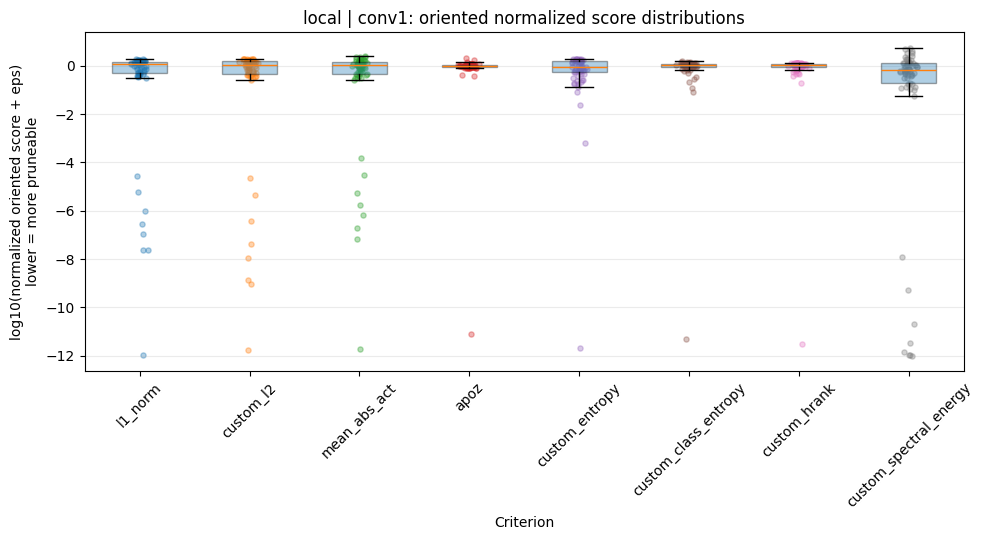

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/score_distribution_boxstrip_local_conv1.png


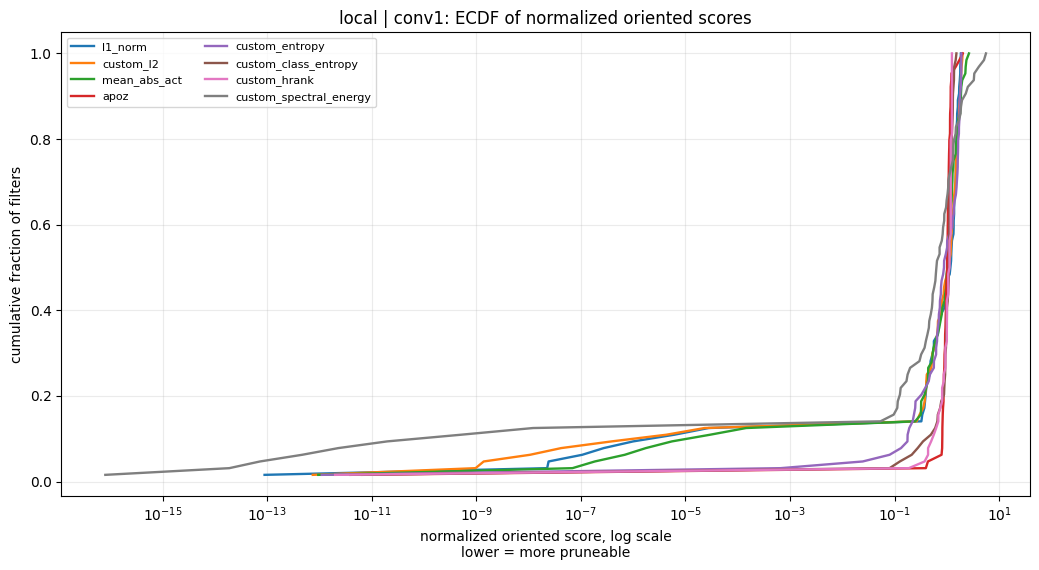

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/score_distribution_ecdf_local_conv1.png


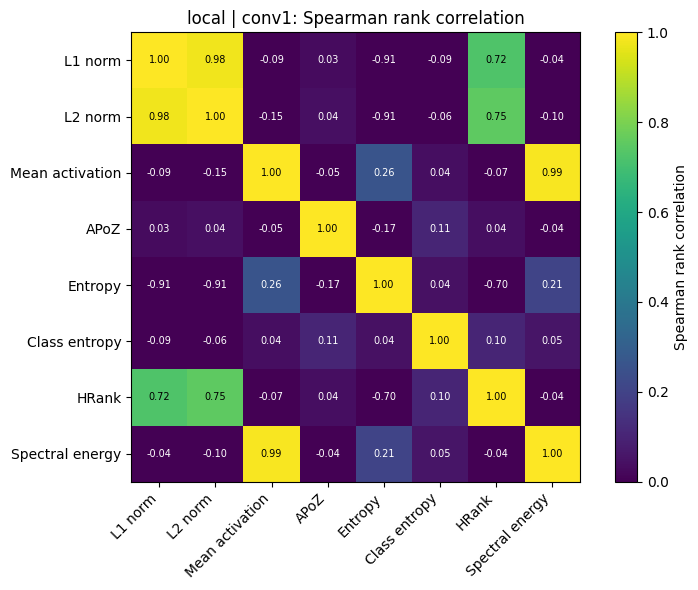

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/spearman_heatmap_local_conv1.png


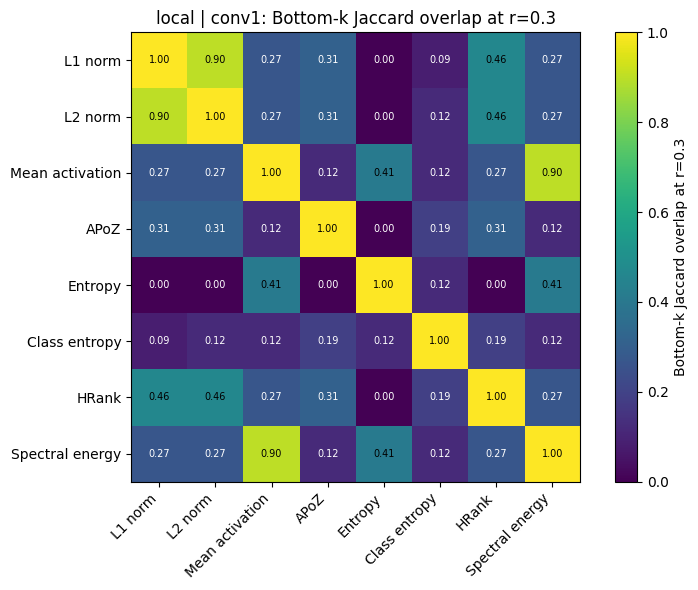

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/bottomk_jaccard_heatmap_local_conv1.png


/tmp/ipykernel_791/935665666.py:384: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_values, labels=plot_methods, showfliers=False, patch_artist=True)


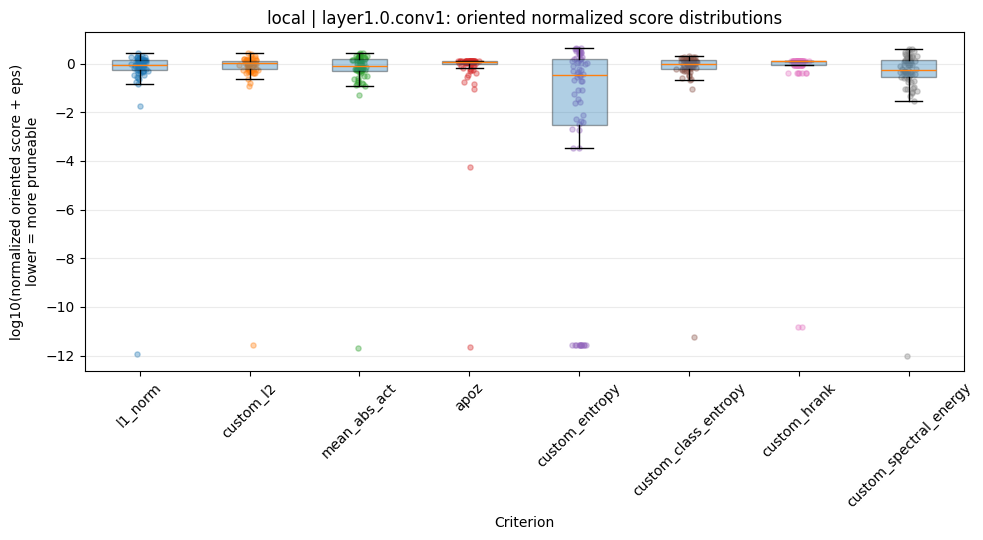

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/score_distribution_boxstrip_local_layer1p0pconv1.png


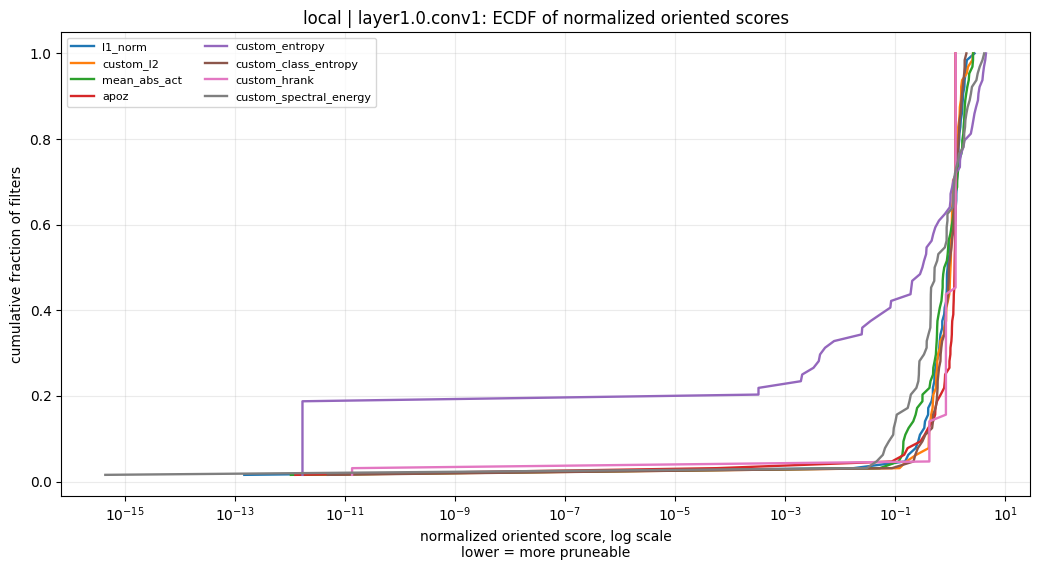

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/score_distribution_ecdf_local_layer1p0pconv1.png


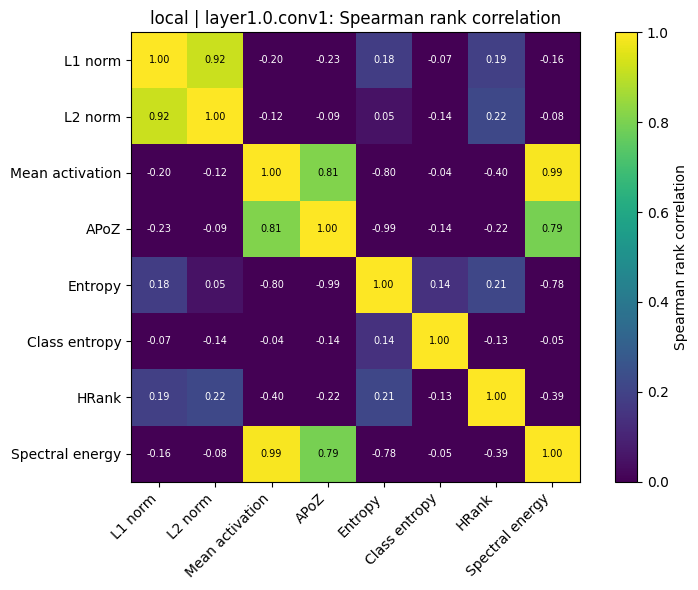

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/spearman_heatmap_local_layer1p0pconv1.png


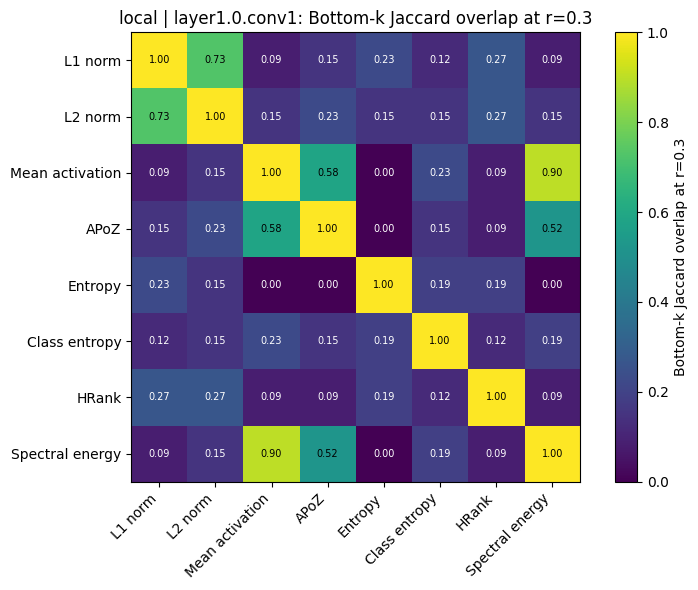

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/bottomk_jaccard_heatmap_local_layer1p0pconv1.png


/tmp/ipykernel_791/935665666.py:384: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_values, labels=plot_methods, showfliers=False, patch_artist=True)


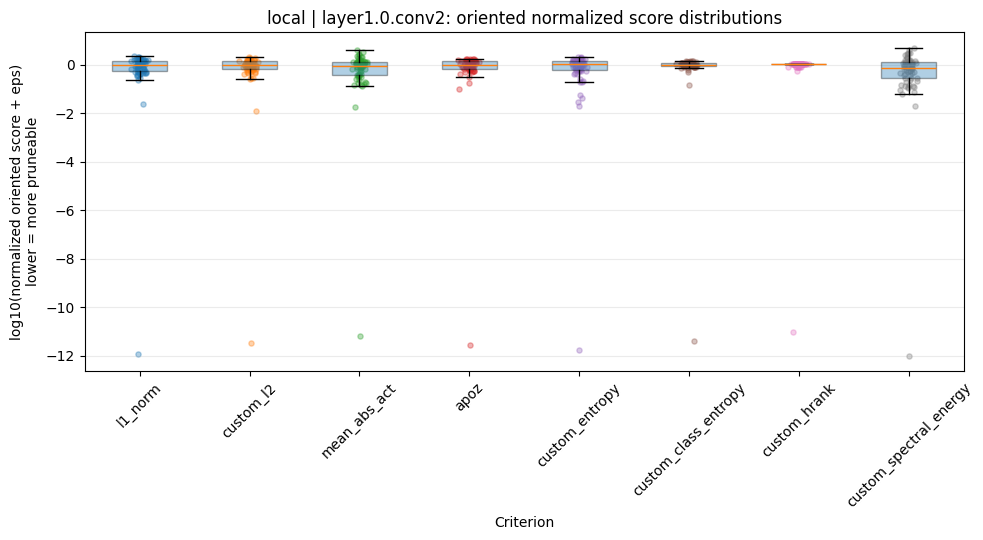

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/score_distribution_boxstrip_local_layer1p0pconv2.png


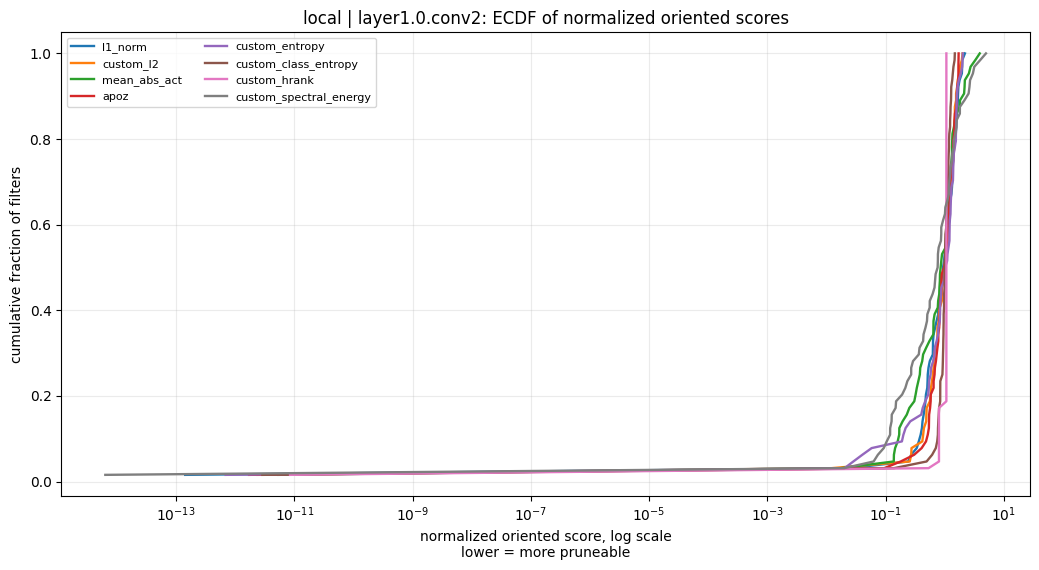

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/score_distribution_ecdf_local_layer1p0pconv2.png


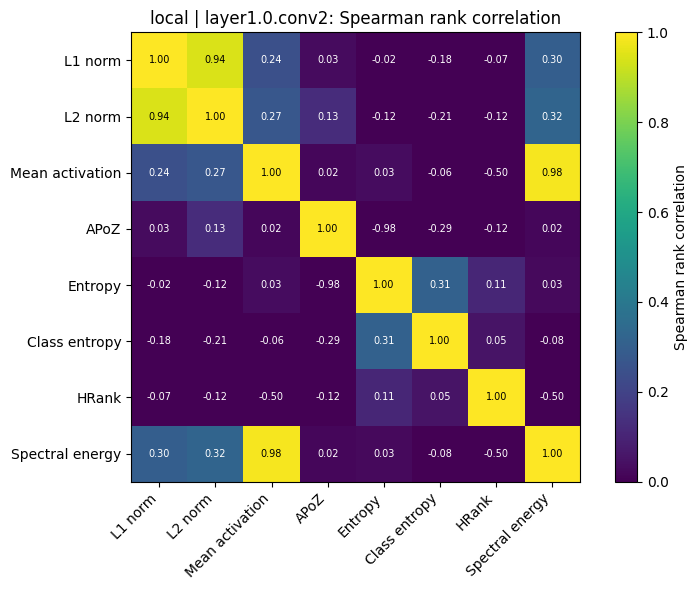

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/spearman_heatmap_local_layer1p0pconv2.png


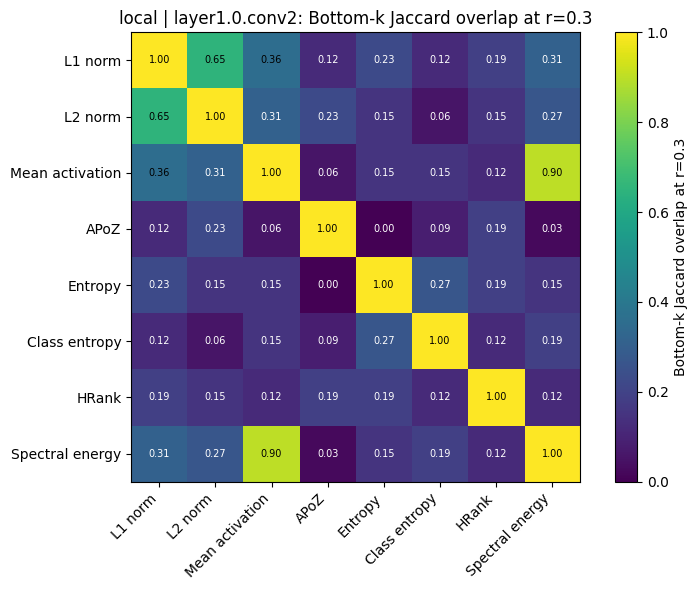

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/bottomk_jaccard_heatmap_local_layer1p0pconv2.png


/tmp/ipykernel_791/935665666.py:384: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_values, labels=plot_methods, showfliers=False, patch_artist=True)


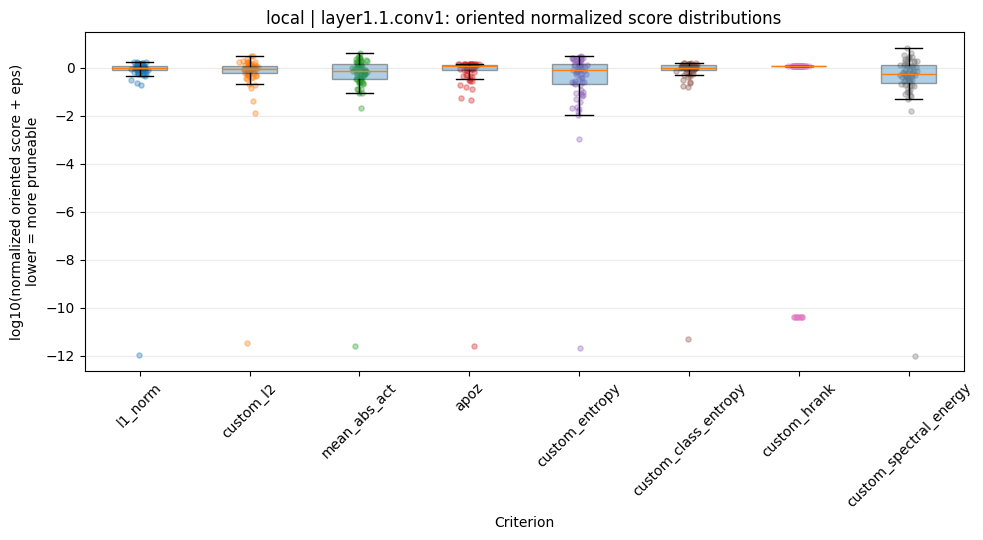

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/score_distribution_boxstrip_local_layer1p1pconv1.png


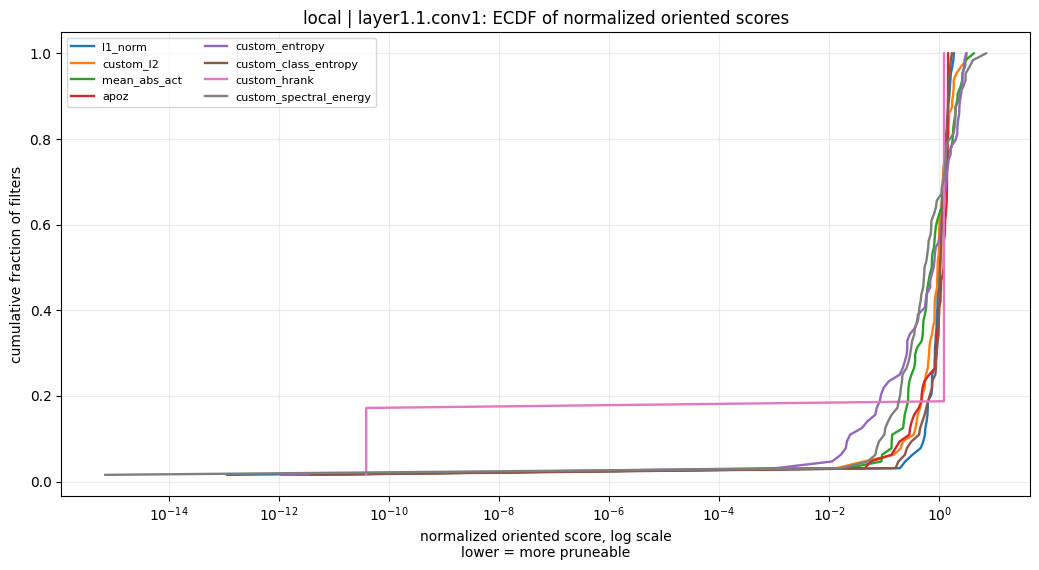

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/score_distribution_ecdf_local_layer1p1pconv1.png


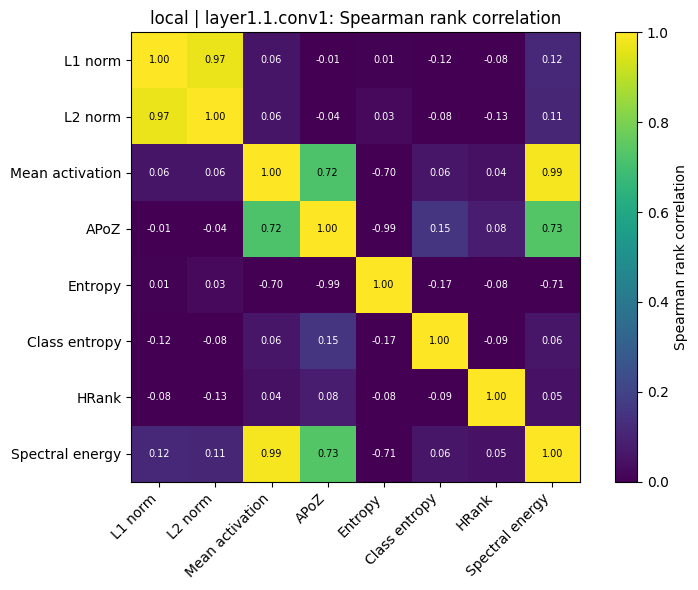

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/spearman_heatmap_local_layer1p1pconv1.png


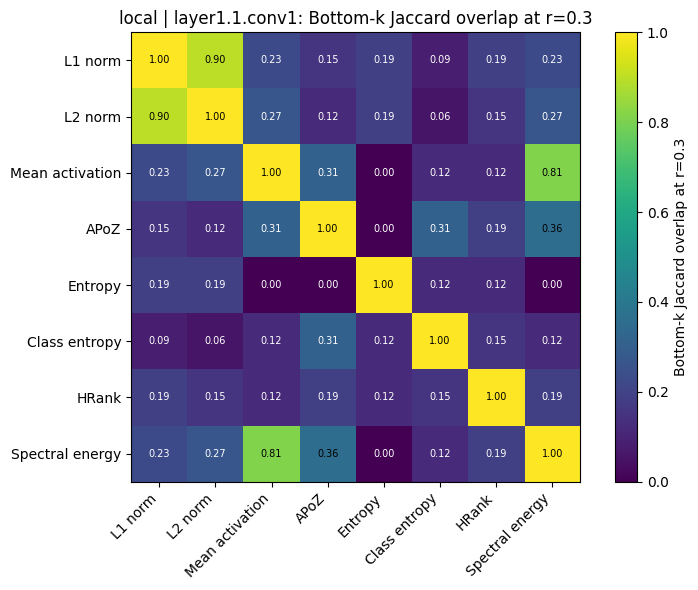

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/bottomk_jaccard_heatmap_local_layer1p1pconv1.png


/tmp/ipykernel_791/935665666.py:384: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_values, labels=plot_methods, showfliers=False, patch_artist=True)


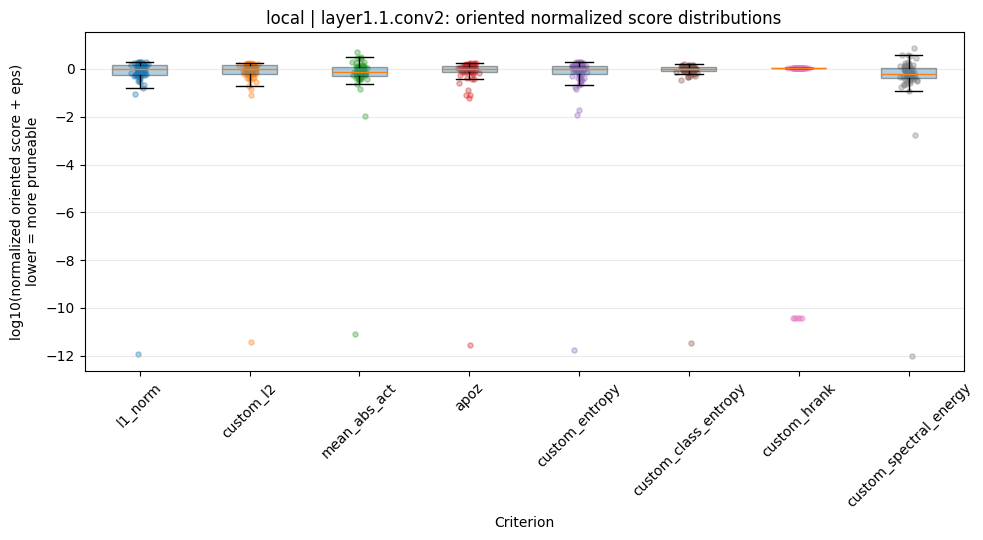

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/score_distribution_boxstrip_local_layer1p1pconv2.png


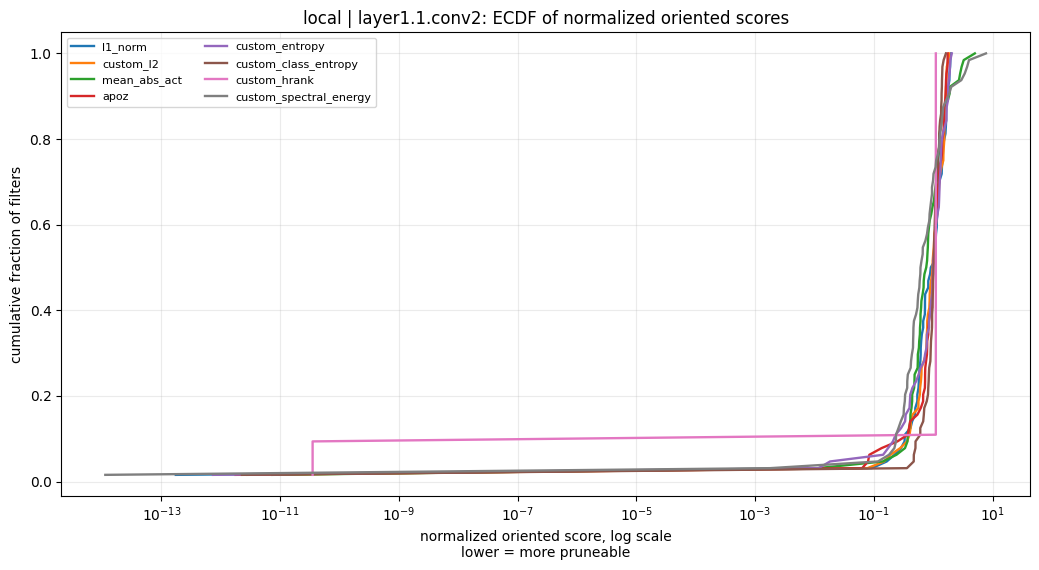

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/score_distribution_ecdf_local_layer1p1pconv2.png


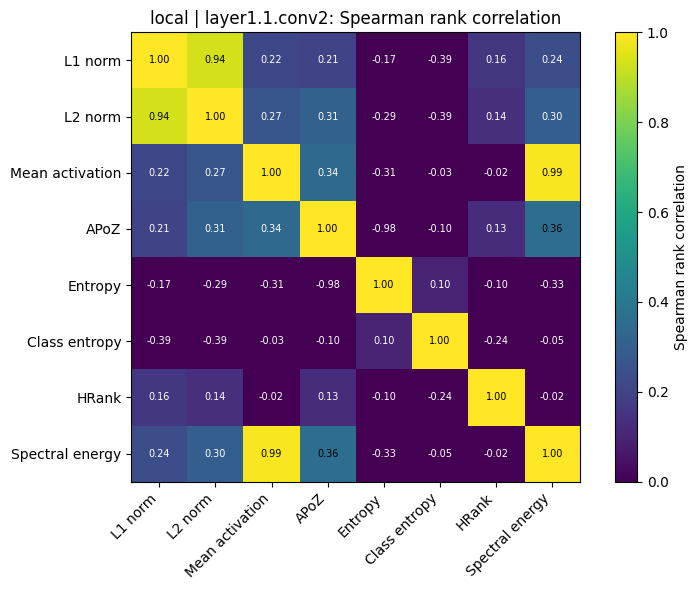

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/spearman_heatmap_local_layer1p1pconv2.png


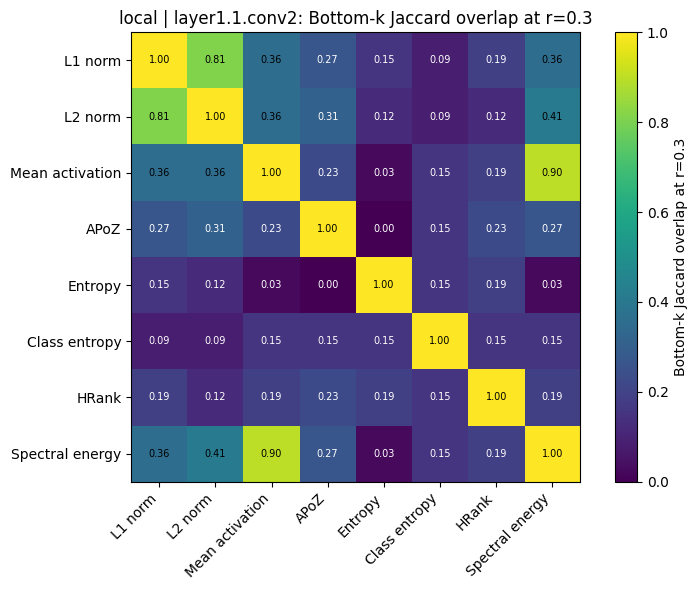

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/bottomk_jaccard_heatmap_local_layer1p1pconv2.png
Score-distribution diagnostics: scope=global, methods=9, layers=['conv1', 'layer1.0.conv1', 'layer1.0.conv2', 'layer1.1.conv1', 'layer1.1.conv2']


/tmp/ipykernel_791/935665666.py:384: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_values, labels=plot_methods, showfliers=False, patch_artist=True)


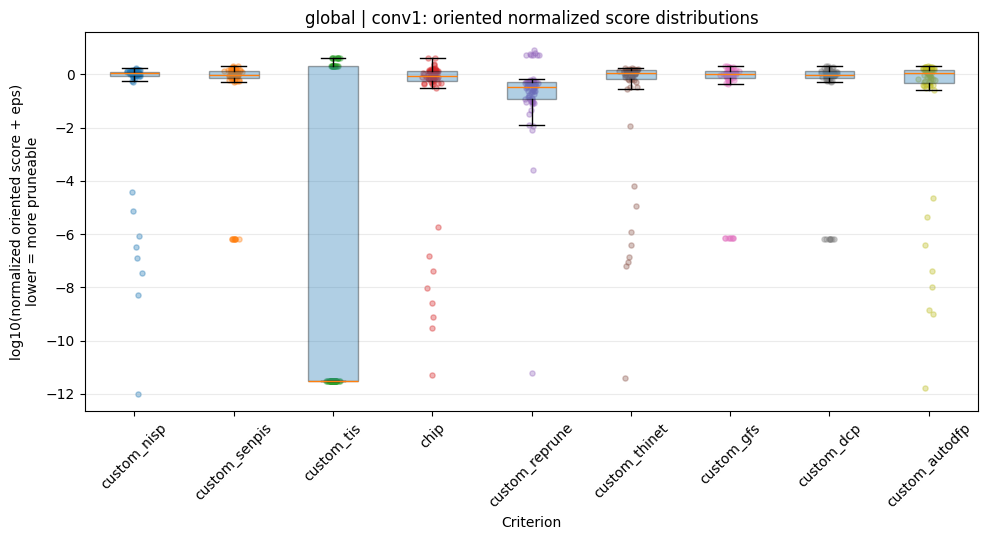

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/score_distribution_boxstrip_global_conv1.png


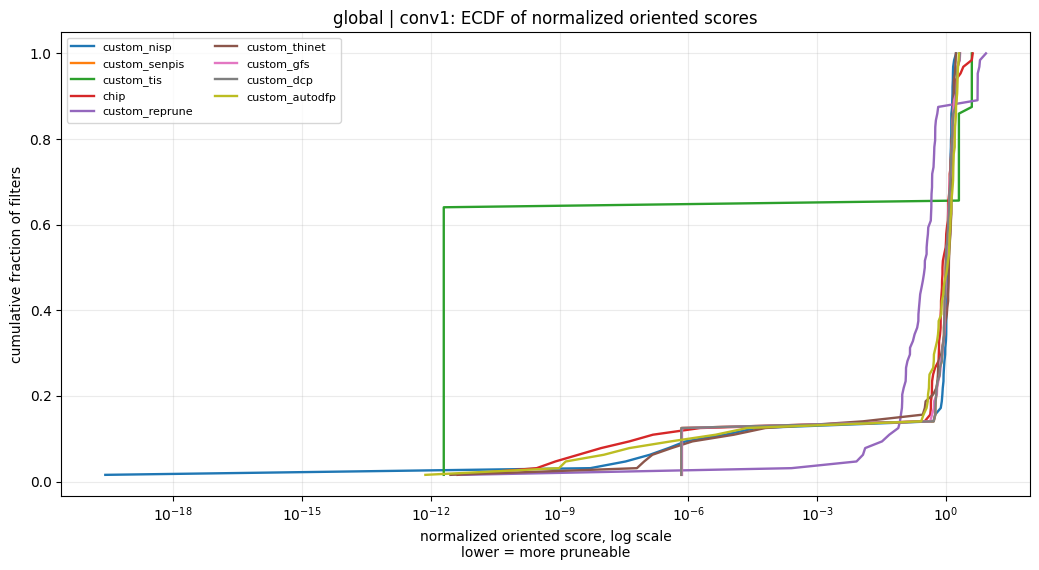

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/score_distribution_ecdf_global_conv1.png


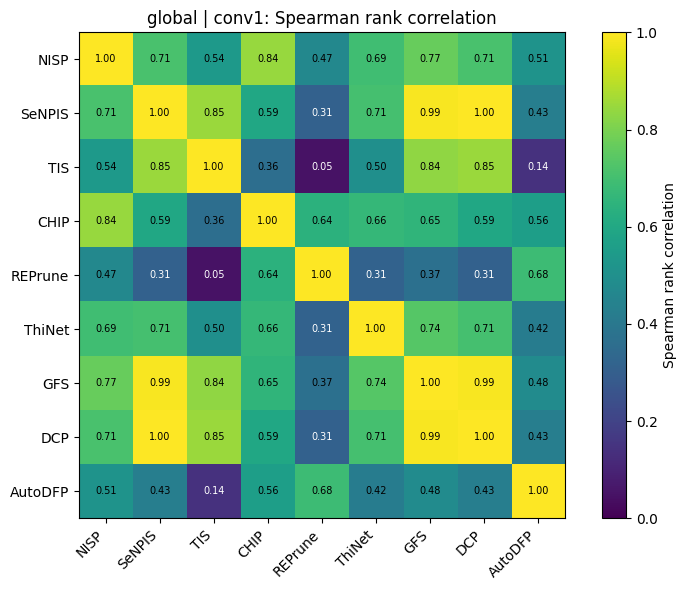

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/spearman_heatmap_global_conv1.png


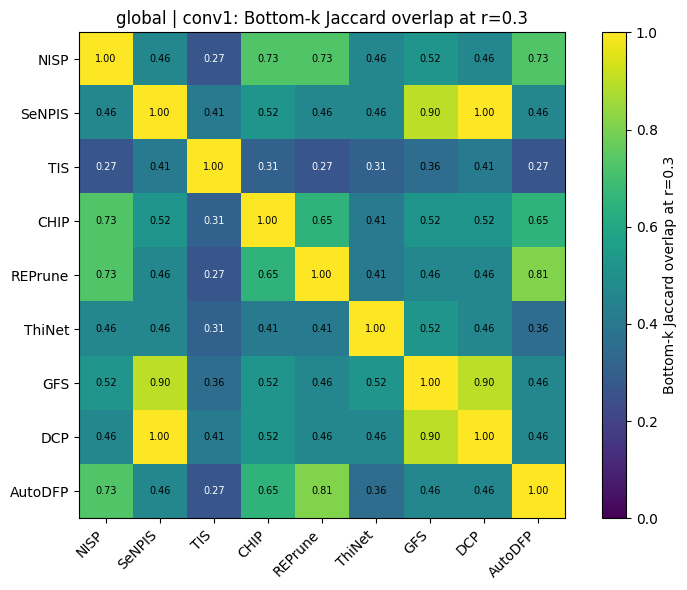

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/bottomk_jaccard_heatmap_global_conv1.png


/tmp/ipykernel_791/935665666.py:384: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_values, labels=plot_methods, showfliers=False, patch_artist=True)


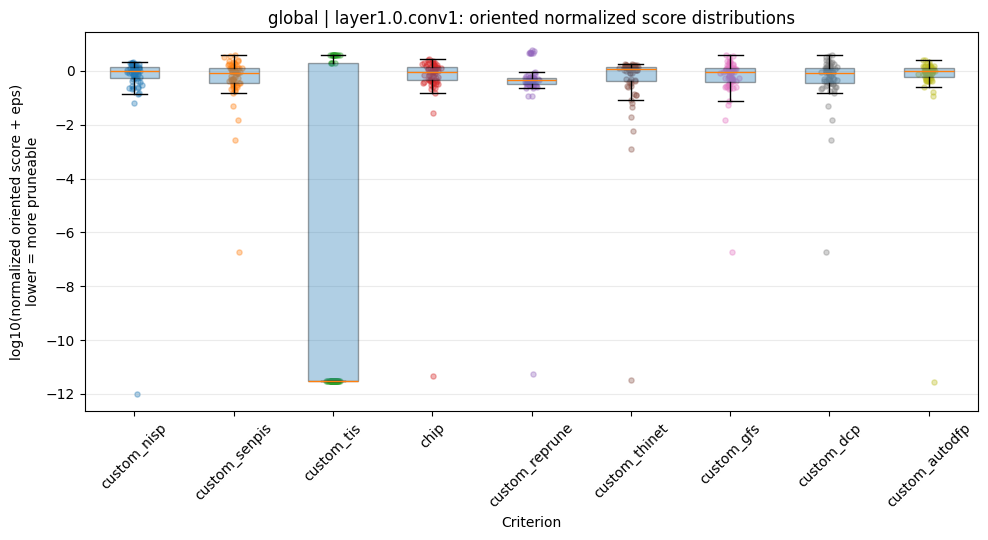

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/score_distribution_boxstrip_global_layer1p0pconv1.png


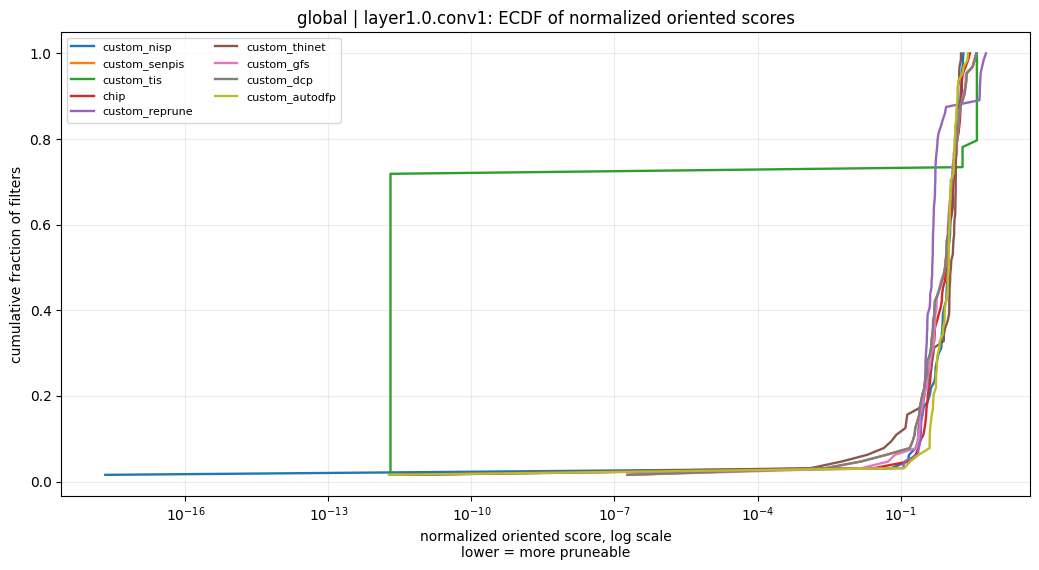

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/score_distribution_ecdf_global_layer1p0pconv1.png


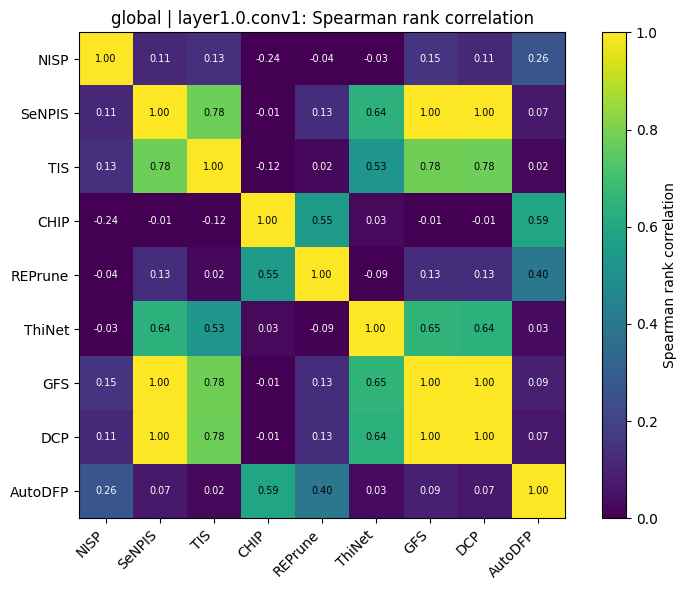

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/spearman_heatmap_global_layer1p0pconv1.png


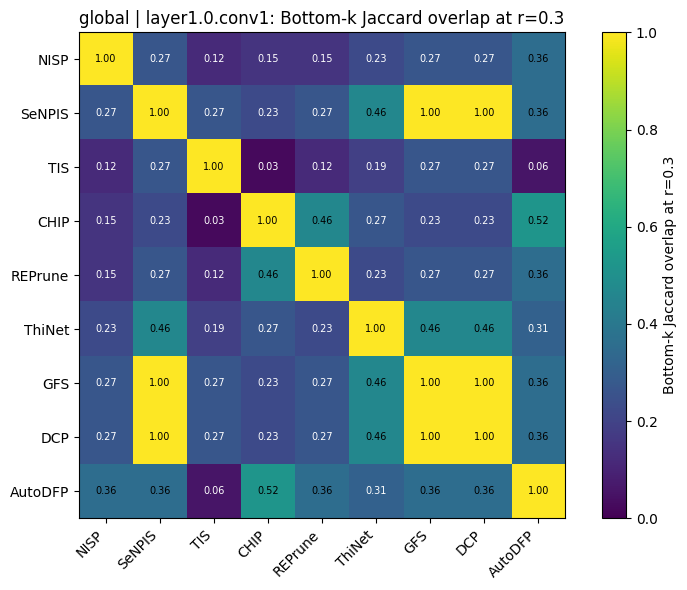

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/bottomk_jaccard_heatmap_global_layer1p0pconv1.png


/tmp/ipykernel_791/935665666.py:384: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_values, labels=plot_methods, showfliers=False, patch_artist=True)


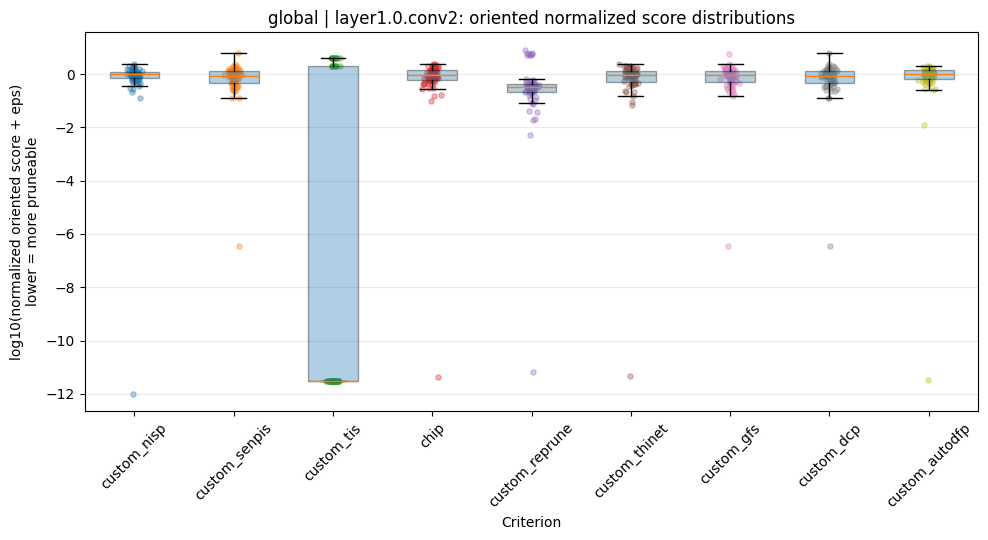

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/score_distribution_boxstrip_global_layer1p0pconv2.png


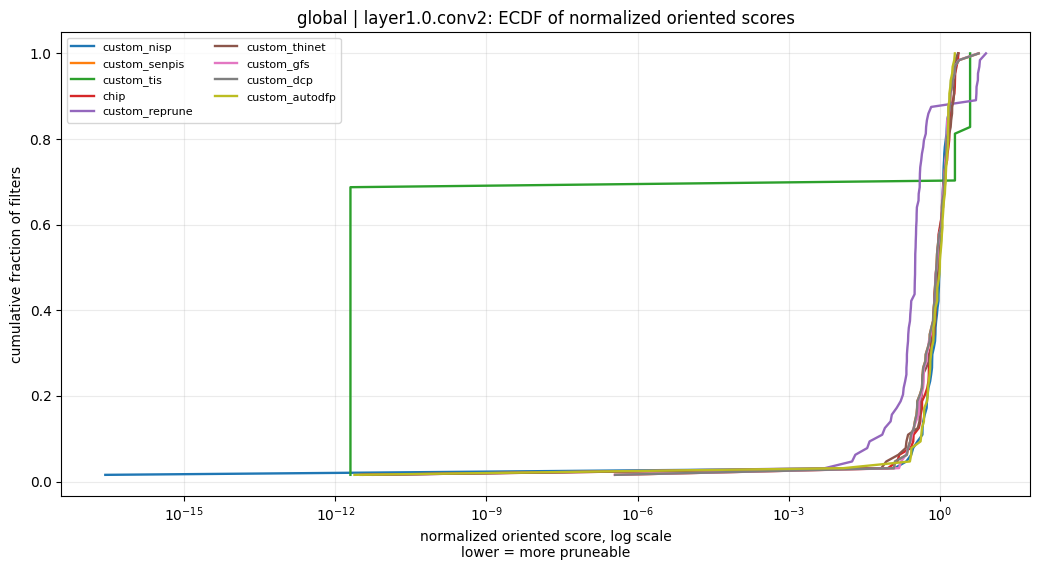

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/score_distribution_ecdf_global_layer1p0pconv2.png


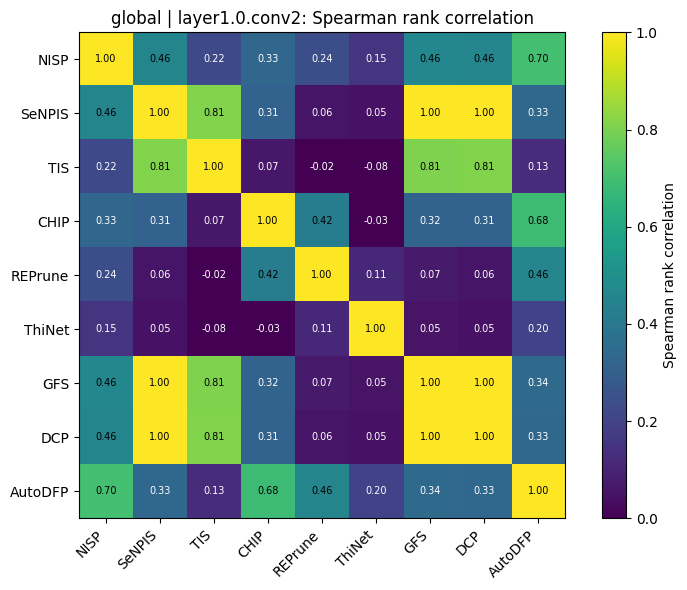

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/spearman_heatmap_global_layer1p0pconv2.png


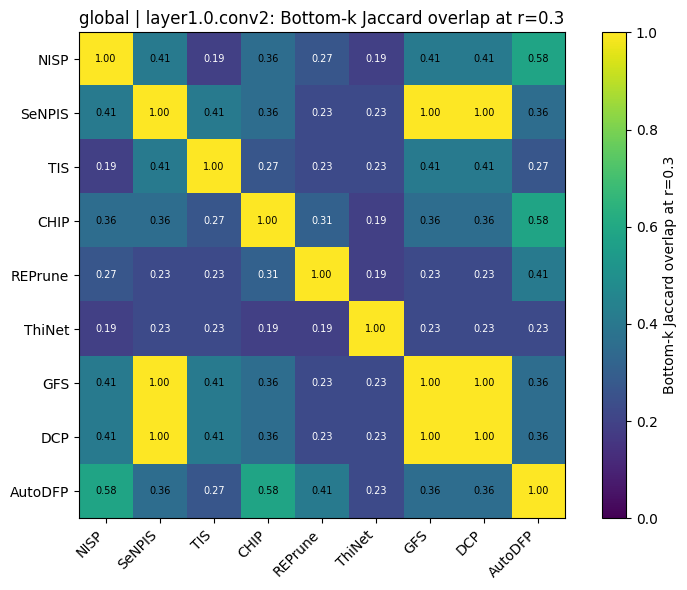

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/bottomk_jaccard_heatmap_global_layer1p0pconv2.png


/tmp/ipykernel_791/935665666.py:384: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_values, labels=plot_methods, showfliers=False, patch_artist=True)


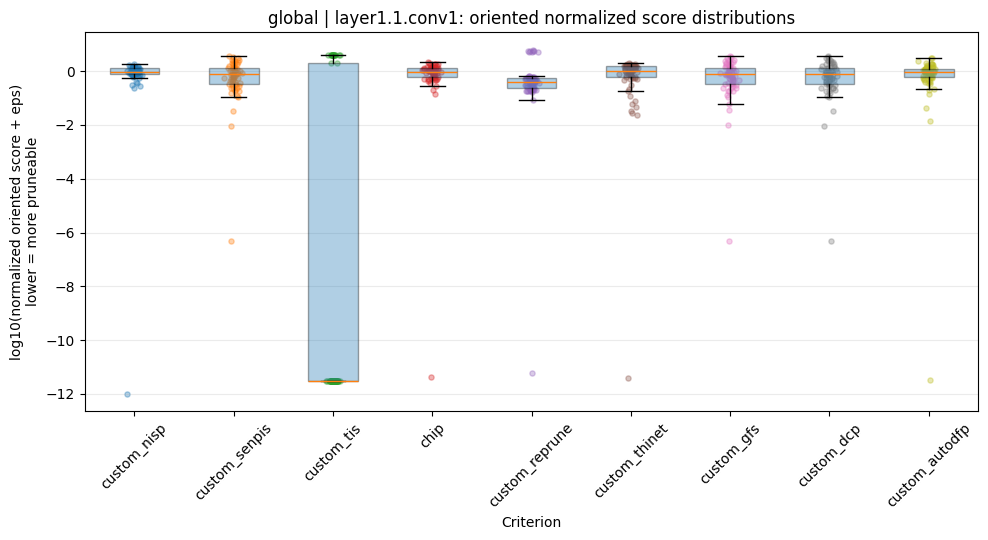

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/score_distribution_boxstrip_global_layer1p1pconv1.png


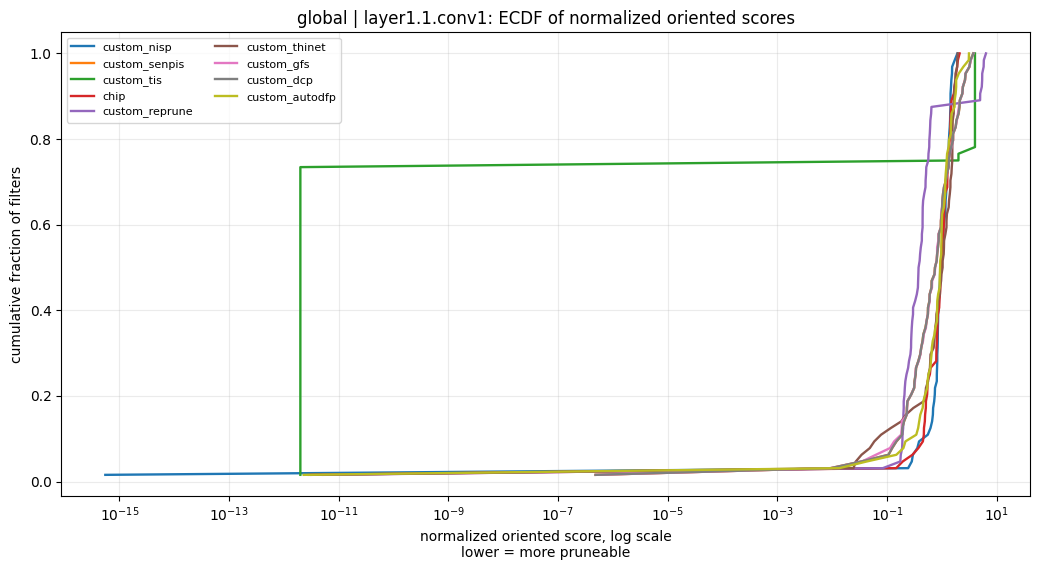

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/score_distribution_ecdf_global_layer1p1pconv1.png


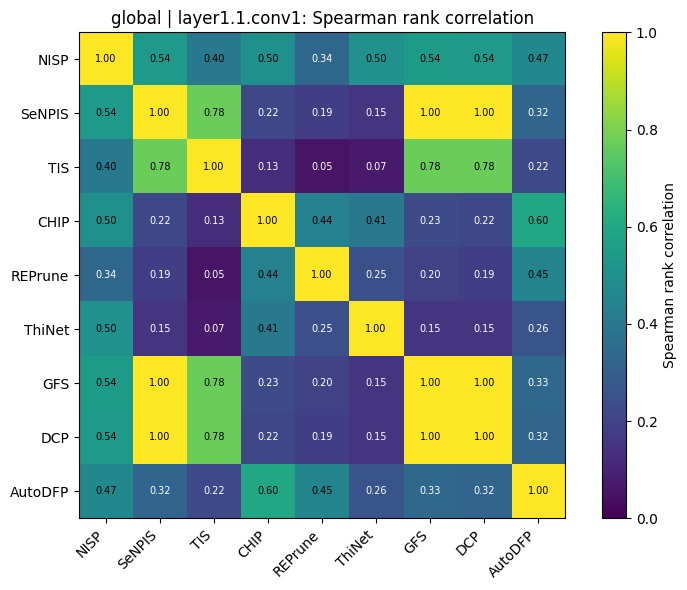

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/spearman_heatmap_global_layer1p1pconv1.png


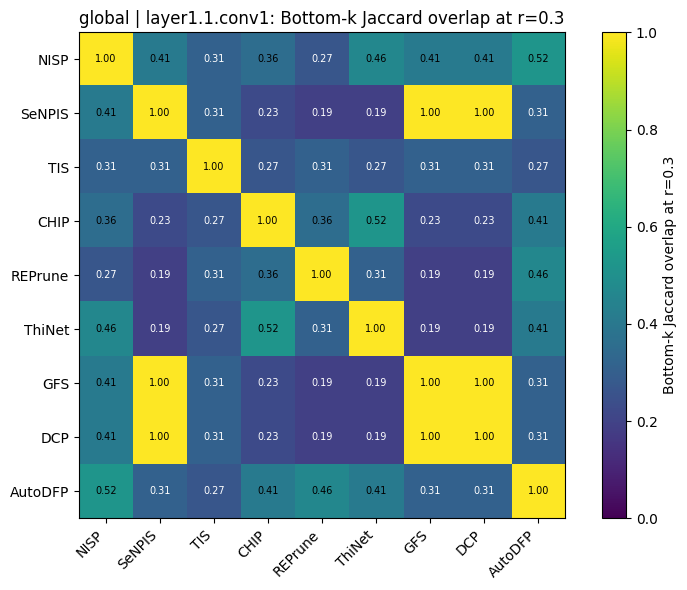

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/bottomk_jaccard_heatmap_global_layer1p1pconv1.png


/tmp/ipykernel_791/935665666.py:384: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_values, labels=plot_methods, showfliers=False, patch_artist=True)


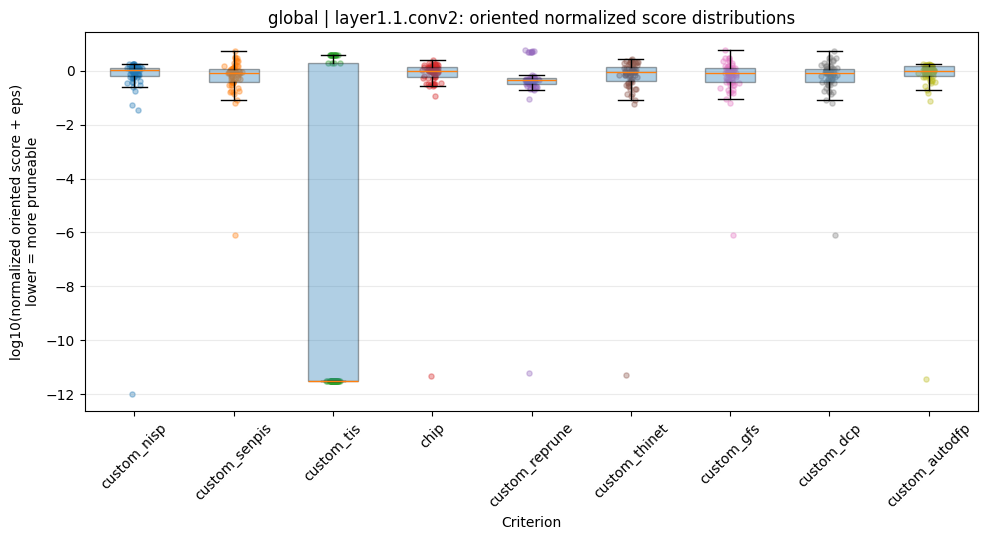

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/score_distribution_boxstrip_global_layer1p1pconv2.png


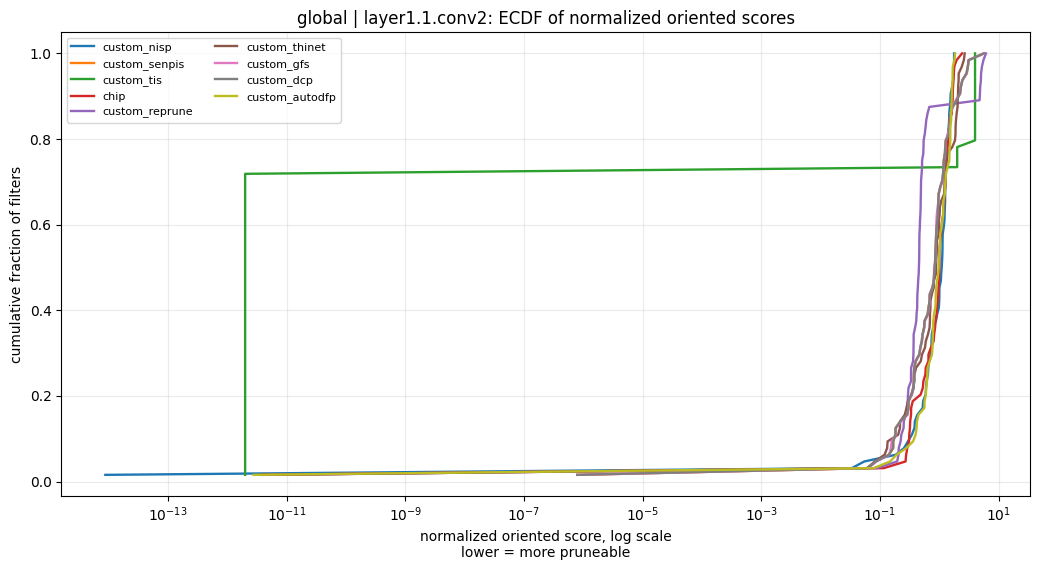

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/score_distribution_ecdf_global_layer1p1pconv2.png


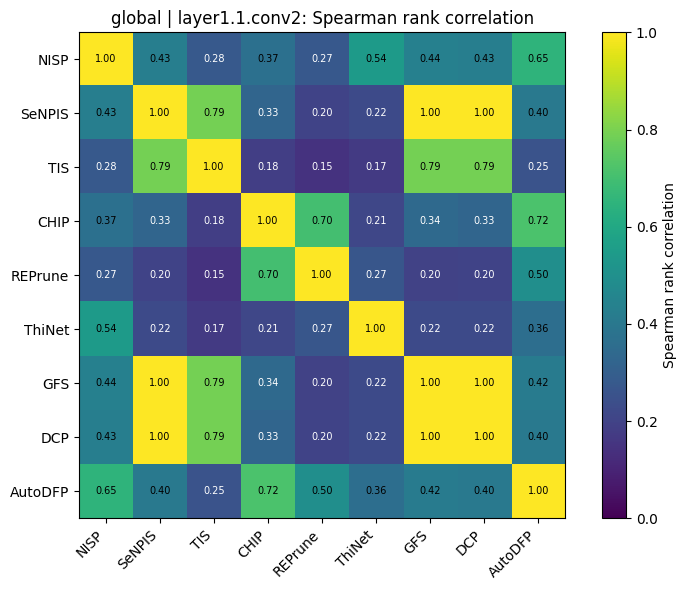

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/spearman_heatmap_global_layer1p1pconv2.png


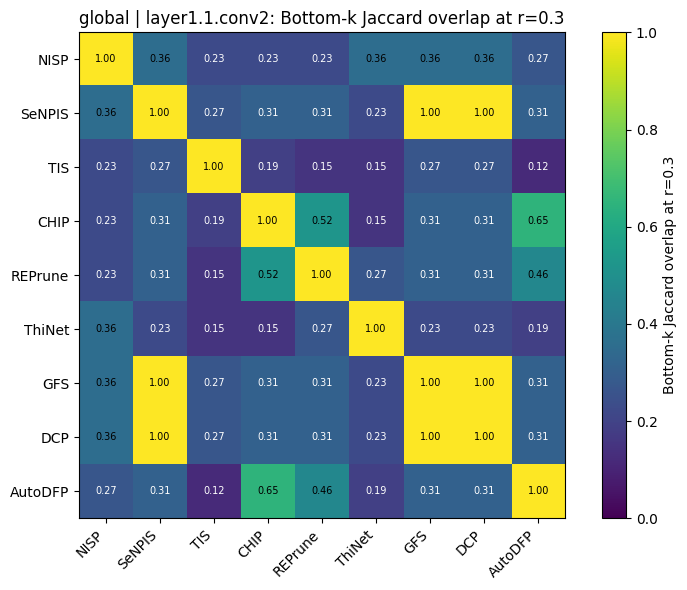

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/bottomk_jaccard_heatmap_global_layer1p1pconv2.png
Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/layer_method_score_distribution_summary.csv


,scope,layer,method,num_filters,score_direction,oriented_mean,oriented_std,normalized_mean,normalized_std,normalized_iqr,log_normalized_median,bottom_k_count,bottom_k_indices
0,local,conv1,l1_norm,64,higher_is_more_important,11.195458,6.607965,1.0,0.590236,1.016222,0.073656,19,"[2, 3, 4, 7, 9, 13, 17, 18, 21, 29, 36, 37, 38..."
1,local,conv1,custom_l2,64,higher_is_more_important,1.339931,0.829750,1.0,0.619249,1.026045,0.038718,19,"[2, 3, 4, 7, 9, 12, 13, 17, 18, 21, 36, 37, 38..."
2,local,conv1,mean_abs_act,64,higher_is_more_important,1.051356,0.694643,1.0,0.660712,0.936467,0.017576,19,"[0, 2, 4, 5, 7, 8, 9, 13, 15, 23, 24, 36, 38, ..."
3,local,conv1,apoz,64,higher_is_more_important,-0.501472,0.039893,1.0,0.260586,0.206965,0.004329,19,"[3, 6, 7, 12, 13, 19, 22, 27, 29, 32, 35, 36, ..."
4,local,conv1,custom_entropy,64,higher_is_more_important,1.479913,0.556864,1.0,0.617187,1.076922,-0.054342,19,"[0, 5, 8, 15, 23, 24, 30, 31, 39, 40, 41, 43, ..."
5,local,conv1,custom_class_entropy,64,higher_is_more_important,3.065577,0.086057,1.0,0.335096,0.286503,0.039529,19,"[0, 6, 7, 10, 12, 13, 14, 16, 20, 24, 26, 27, ..."
6,local,conv1,custom_hrank,64,higher_is_more_important,63.875977,0.142388,1.0,0.284221,0.265107,0.050305,19,"[2, 4, 6, 7, 9, 13, 17, 19, 21, 26, 28, 35, 36..."
7,local,conv1,custom_spectral_energy,64,higher_is_more_important,12429.846877,14459.147475,1.0,1.163260,1.114989,-0.195078,19,"[0, 2, 4, 5, 7, 9, 13, 15, 23, 24, 31, 36, 38,..."
8,local,layer1.0.conv1,l1_norm,64,higher_is_more_important,18.236040,3.884142,1.0,0.571102,0.863480,-0.045633,19,"[11, 16, 17, 21, 24, 25, 29, 30, 32, 44, 47, 4..."
9,local,layer1.0.conv1,custom_l2,64,higher_is_more_important,1.252491,0.286778,1.0,0.529846,0.747946,0.008413,19,"[10, 11, 17, 23, 24, 25, 29, 30, 32, 43, 44, 4..."



Realistic alignment interpretation:
- Near-perfect agreement among heterogeneous pruning criteria is not expected.
- Spearman/Jaccard thresholds in this notebook intentionally include practical low, moderate,
  substantial, strong, and near-equivalent regimes.
- Lower thresholds are not interpreted as strict equivalence. They define realistic operating
  points for candidate-reduction and fixed-stack discovery.
- Final evidence should come from frozen-stack benchmark performance, supported by score
  distribution diagnostics, bottom-k Jaccard overlap, Spearman agreement, LFPC confidence,
  and stability across conditions.

Saved /content/drive/.shortcut-targets-by-id/14yEksjdTCzFQE3AZWABhD1iHHWdo3v5Z/activation-based-pruning/outputs/lfpc_hybrid/cats_dogs/resnet18/flops_accuracy/20260520_210706/realistic_alignment_diagnostics/realistic_alignment_interpretation_note.txt


In [21]:
# [ReduCNN LFPC cell note]
# Purpose: Environment, imports, and reproducibility setup.
# Mechanics: It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.
# Expected result: The notebook runtime has the libraries, paths, and helper functions needed by the experiment.


# ---------------------------------------------------------------------
# Realistic alignment diagnostics + improved score-distribution visuals
# ---------------------------------------------------------------------
# This cell is additive: it does not replace or break earlier outputs.
# It improves interpretation of Algorithm 2 and layer-wise criterion score distributions.
#
# Outputs are saved under:
#   OUT_DIR / "realistic_alignment_diagnostics"

import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REALISTIC_DIAG_DIR = OUT_DIR / "realistic_alignment_diagnostics"
REALISTIC_DIAG_DIR.mkdir(parents=True, exist_ok=True)

print("Realistic alignment diagnostics output:", REALISTIC_DIAG_DIR)


# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

def _safe_float(x, default=np.nan):
    try:
        return float(x)
    except Exception:
        return default


def _as_1d_float_array(values):
    arr = np.asarray(values, dtype=np.float64)
    return arr.reshape(-1)


def _sanitize_filename(text):
    return (
        str(text)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
        .replace(".", "p")
        .replace("=", "")
        .replace("|", "_")
        .replace(":", "_")
        .replace(",", "_")
    )


def _layer_sort_key(layer):
    text = str(layer)
    if "." in text:
        prefix, suffix = text.rsplit(".", 1)
        try:
            return (prefix, int(suffix))
        except Exception:
            pass
    return (text, 10**9)


def _metadata_direction(method):
    meta = METHOD_METADATA.get(method, {}) if isinstance(METHOD_METADATA, dict) else {}
    return str(
        meta.get("score_direction")
        or meta.get("direction")
        or meta.get("importance_direction")
        or "lower_is_more_pruneable"
    )


def _fallback_orient_scores(values, method):
    """Return scores where lower means more pruneable."""
    arr = _as_1d_float_array(values)
    direction = _metadata_direction(method)

    if direction == "lower_is_more_pruneable":
        return arr
    if direction == "higher_is_more_pruneable":
        return -arr
    if direction == "higher_is_more_important":
        return arr
    if direction == "lower_is_more_important":
        return -arr

    # Common protection: APOZ usually means higher zeros = more pruneable.
    if str(method).lower() == "apoz":
        return -arr

    return arr


def _oriented_scores(method, values):
    """
    Robust wrapper for orient_scores_for_pruning across notebook versions.
    Final convention: lower score = more pruneable.
    """
    if "orient_scores_for_pruning" in globals():
        fn = orient_scores_for_pruning
        try:
            return _as_1d_float_array(fn(values, method))
        except TypeError:
            pass
        except Exception:
            pass
        try:
            return _as_1d_float_array(fn(values, method, METHOD_METADATA))
        except TypeError:
            pass
        except Exception:
            pass
    return _fallback_orient_scores(values, method)


def _safe_normalize(scores, eps=None):
    """Positive mean normalization for comparing distributions."""
    x = _as_1d_float_array(scores)
    if eps is None:
        eps = max(1e-12, np.finfo(x.dtype).eps * 100)

    if x.size == 0:
        return x

    finite = np.isfinite(x)
    if not finite.any():
        return np.ones_like(x, dtype=np.float64)

    finite_values = x[finite]
    x = np.nan_to_num(
        x,
        nan=float(np.median(finite_values)),
        posinf=float(np.max(finite_values)),
        neginf=float(np.min(finite_values)),
    )

    if np.allclose(x, x[0], rtol=0.0, atol=eps):
        return np.ones_like(x, dtype=np.float64)

    x = x - np.min(x) + eps
    mean = np.mean(x)

    if abs(mean) < eps:
        return np.ones_like(x, dtype=np.float64)

    out = x / (mean + eps)
    if not np.all(np.isfinite(out)):
        return np.ones_like(x, dtype=np.float64)
    return out


def _rankdata_average_ties(x):
    x = _as_1d_float_array(x)
    sorter = np.argsort(x, kind="mergesort")
    inv = np.empty_like(sorter)
    inv[sorter] = np.arange(len(x))
    sorted_x = x[sorter]
    obs = np.r_[True, sorted_x[1:] != sorted_x[:-1]]
    dense = np.cumsum(obs) - 1
    counts = np.bincount(dense)
    cumulative = np.cumsum(counts)
    starts = cumulative - counts
    avg_ranks = (starts + cumulative - 1) / 2.0
    return avg_ranks[dense][inv]


def _spearman_corr(a, b):
    a = _as_1d_float_array(a)
    b = _as_1d_float_array(b)
    if len(a) != len(b):
        return np.nan
    if len(a) < 2:
        return 1.0
    ra = _rankdata_average_ties(a)
    rb = _rankdata_average_ties(b)
    if np.std(ra) == 0 or np.std(rb) == 0:
        return 1.0 if np.std(ra) == 0 and np.std(rb) == 0 else 0.0
    return float(np.corrcoef(ra, rb)[0, 1])


def _bottom_k_set(scores, ratio):
    x = _as_1d_float_array(scores)
    if x.size == 0:
        return set()
    k = max(1, int(round(float(ratio) * len(x))))
    k = min(k, len(x))
    return set(np.argsort(x, kind="mergesort")[:k].astype(int).tolist())


def _jaccard(a, b):
    u = set(a) | set(b)
    if not u:
        return 1.0
    return len(set(a) & set(b)) / len(u)


def _alignment_label(value, bands, lower_is_better=False):
    if value is None or not np.isfinite(float(value)):
        return "not_available"
    value = float(value)
    # For these bands, higher is better.
    selected = "below_practical_range"
    for label, threshold in sorted(bands.items(), key=lambda kv: kv[1]):
        if value >= threshold:
            selected = label
    return selected


def _candidate_methods_for_scope(scope):
    priority = [
        "l1_norm", "custom_l2", "l2_norm", "mean_abs_act", "apoz",
        "custom_entropy", "custom_class_entropy", "custom_hrank",
        "custom_spectral_energy", "chip", "custom_reprune", "custom_tis", "custom_nisp",
    ]
    scoped = [m for m in priority if m in METHODS_BY_SCOPE.get(scope, []) and m in score_maps]
    if str(scope).lower() == "global":
        scoped = [m for m in expected_methods_for_scope(scope) if m in score_maps]
    if not scoped:
        scoped = [m for m in METHODS_BY_SCOPE.get(scope, []) if m in score_maps]
    return scoped


def _selected_scopes():
    if "DEMO_SCOPES" in globals():
        return list(DEMO_SCOPES)
    if "SELECTED_SCOPE_FOR_DEMO" in globals():
        return [SELECTED_SCOPE_FOR_DEMO]
    if "METHODS_BY_SCOPE" in globals():
        return list(METHODS_BY_SCOPE.keys())
    return []


def _selected_ratio():
    if "SELECTED_PRUNE_RATIO_FOR_DEMO" in globals():
        return float(SELECTED_PRUNE_RATIO_FOR_DEMO)
    if "PRUNE_RATIOS" in globals() and len(PRUNE_RATIOS):
        return float(PRUNE_RATIOS[0])
    return 0.30


def _selected_layers_for_scope(scope, max_layers=5):
    layers = sorted(common_layers_by_scope.get(scope, []), key=_layer_sort_key)
    preferred = ["features.0", "features.5", "features.10", "features.19", "features.28"]
    selected = [l for l in preferred if l in layers]
    if len(selected) < max_layers:
        for l in layers:
            if l not in selected:
                selected.append(l)
            if len(selected) >= max_layers:
                break
    return selected[:max_layers]


SPEARMAN_ALIGNMENT_BANDS = globals().get("SPEARMAN_ALIGNMENT_BANDS", {
    "practical_low_alignment": 0.40,
    "practical_moderate_alignment": 0.50,
    "substantial_alignment": 0.70,
    "strong_alignment": 0.90,
    "near_equivalence": 0.95,
})
JACCARD_ALIGNMENT_BANDS = globals().get("JACCARD_ALIGNMENT_BANDS", {
    "practical_low_overlap": 0.40,
    "practical_moderate_overlap": 0.50,
    "substantial_overlap": 0.70,
    "strong_overlap": 0.80,
    "near_equivalent_overlap": 0.90,
})


# ---------------------------------------------------------------------
# A. Alignment-band summary from similarity_df
# ---------------------------------------------------------------------

if "similarity_df" in globals() and isinstance(similarity_df, pd.DataFrame) and not similarity_df.empty:
    sim = similarity_df.copy()

    if "spearman_rank_corr" in sim.columns:
        sim["spearman_alignment_band"] = sim["spearman_rank_corr"].apply(
            lambda x: _alignment_label(_safe_float(x), SPEARMAN_ALIGNMENT_BANDS)
        )
    if "prune_set_jaccard" in sim.columns:
        sim["jaccard_overlap_band"] = sim["prune_set_jaccard"].apply(
            lambda x: _alignment_label(_safe_float(x), JACCARD_ALIGNMENT_BANDS)
        )
    if "max_ratio_variance" in sim.columns:
        vals = pd.to_numeric(sim["max_ratio_variance"], errors="coerce")
        sim["log10_max_ratio_variance"] = np.log10(vals.clip(lower=1e-12))

    sim_path = REALISTIC_DIAG_DIR / "algorithm2_realistic_alignment_bands.csv"
    sim.to_csv(sim_path, index=False)
    with open(REALISTIC_DIAG_DIR / "algorithm2_realistic_alignment_bands.json", "w", encoding="utf-8") as f:
        json.dump(sim.to_dict(orient="records"), f, indent=2, default=str)
    print("Saved", sim_path)

    # Band count summary.
    band_rows = []
    group_cols = [c for c in ["scope", "ratio", "variance_threshold", "spearman_threshold", "jaccard_threshold"] if c in sim.columns]
    for keys, grp in sim.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row["pairs_checked"] = int(len(grp))
        if "spearman_alignment_band" in grp.columns:
            for label, count in grp["spearman_alignment_band"].value_counts(dropna=False).items():
                row[f"spearman_band__{label}"] = int(count)
        if "jaccard_overlap_band" in grp.columns:
            for label, count in grp["jaccard_overlap_band"].value_counts(dropna=False).items():
                row[f"jaccard_band__{label}"] = int(count)
        band_rows.append(row)
    band_df = pd.DataFrame(band_rows)
    band_path = REALISTIC_DIAG_DIR / "algorithm2_alignment_band_counts_by_condition.csv"
    band_df.to_csv(band_path, index=False)
    print("Saved", band_path)

    try:
        display(band_df.head(20))
    except NameError:
        print(band_df.head(20).to_string(index=False))
else:
    print("similarity_df is missing/empty; alignment-band summary will be skipped until Algorithm 2 runs.")


# ---------------------------------------------------------------------
# B. Improved score-distribution visuals by layer
# ---------------------------------------------------------------------

score_summary_rows = []
selected_ratio = _selected_ratio()

for scope in _selected_scopes():
    methods = _candidate_methods_for_scope(scope)
    layers = _selected_layers_for_scope(scope, max_layers=5)

    if not methods or not layers:
        print(f"Skipping score-distribution diagnostics for scope={scope}: no methods or layers.")
        continue

    print(f"Score-distribution diagnostics: scope={scope}, methods={len(methods)}, layers={layers}")

    for layer in layers:
        layer_records = []
        arrays = {}

        for method in methods:
            if method not in score_maps or layer not in score_maps[method]:
                continue

            oriented = _oriented_scores(method, score_maps[method][layer])
            norm = _safe_normalize(oriented)
            log_norm = np.log10(norm + 1e-12)
            arrays[method] = {
                "oriented": oriented,
                "normalized": norm,
                "log_normalized": log_norm,
            }

            prune_set = _bottom_k_set(oriented, selected_ratio)
            score_summary_rows.append({
                "scope": scope,
                "layer": layer,
                "method": method,
                "num_filters": int(len(oriented)),
                "score_direction": _metadata_direction(method),
                "oriented_mean": float(np.mean(oriented)) if len(oriented) else np.nan,
                "oriented_std": float(np.std(oriented, ddof=1)) if len(oriented) > 1 else 0.0,
                "normalized_mean": float(np.mean(norm)) if len(norm) else np.nan,
                "normalized_std": float(np.std(norm, ddof=1)) if len(norm) > 1 else 0.0,
                "normalized_iqr": float(np.percentile(norm, 75) - np.percentile(norm, 25)) if len(norm) else np.nan,
                "log_normalized_median": float(np.median(log_norm)) if len(log_norm) else np.nan,
                "bottom_k_count": int(len(prune_set)),
                "bottom_k_indices": sorted(prune_set),
            })

        if not arrays:
            continue

        # 1) Box/strip plot of log-normalized scores: clearer than overlaid histograms.
        plot_methods = list(arrays.keys())
        plot_values = [arrays[m]["log_normalized"] for m in plot_methods]

        fig, ax = plt.subplots(figsize=(max(10, 0.75 * len(plot_methods)), 5.5))
        bp = ax.boxplot(plot_values, labels=plot_methods, showfliers=False, patch_artist=True)
        for patch in bp["boxes"]:
            patch.set_alpha(0.35)

        # Overlay a small deterministic jittered sample for texture.
        rng = np.random.default_rng(123)
        for i, vals in enumerate(plot_values, start=1):
            vals = np.asarray(vals)
            if len(vals) == 0:
                continue
            sample = vals if len(vals) <= 120 else rng.choice(vals, size=120, replace=False)
            jitter = rng.normal(loc=i, scale=0.035, size=len(sample))
            ax.scatter(jitter, sample, s=14, alpha=0.35)

        ax.set_title(f"{scope} | {layer}: oriented normalized score distributions")
        ax.set_ylabel("log10(normalized oriented score + eps)\nlower = more pruneable")
        ax.set_xlabel("Criterion")
        ax.tick_params(axis="x", rotation=45)
        ax.grid(axis="y", alpha=0.25)
        fig.tight_layout()
        out = REALISTIC_DIAG_DIR / f"score_distribution_boxstrip_{_sanitize_filename(scope)}_{_sanitize_filename(layer)}.png"
        fig.savefig(out, dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved", out)

        # 2) ECDF plot: shows separation without histogram binning artifacts.
        fig, ax = plt.subplots(figsize=(10.5, 5.8))
        for method in plot_methods[:10]:
            vals = np.sort(arrays[method]["normalized"])
            if len(vals) == 0:
                continue
            y = np.arange(1, len(vals) + 1) / len(vals)
            ax.plot(vals, y, lw=1.7, label=method)
        ax.set_xscale("log")
        ax.set_title(f"{scope} | {layer}: ECDF of normalized oriented scores")
        ax.set_xlabel("normalized oriented score, log scale\nlower = more pruneable")
        ax.set_ylabel("cumulative fraction of filters")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8, ncol=2, frameon=True)
        fig.tight_layout()
        out = REALISTIC_DIAG_DIR / f"score_distribution_ecdf_{_sanitize_filename(scope)}_{_sanitize_filename(layer)}.png"
        fig.savefig(out, dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved", out)

        # 3) Pairwise bottom-k Jaccard and Spearman heatmaps for this layer.
        methods_for_matrix = expected_methods_for_scope(scope, plot_methods) if str(scope).lower() == "global" else plot_methods
        jac_mat = pd.DataFrame(np.nan, index=methods_for_matrix, columns=methods_for_matrix)
        rho_mat = pd.DataFrame(np.nan, index=methods_for_matrix, columns=methods_for_matrix)

        for ma in methods_for_matrix:
            for mb in methods_for_matrix:
                if ma == mb:
                    jac_mat.loc[ma, mb] = 1.0
                    rho_mat.loc[ma, mb] = 1.0
                    continue
                if ma not in arrays or mb not in arrays:
                    continue
                a = arrays[ma]["oriented"]
                b = arrays[mb]["oriented"]
                if len(a) != len(b):
                    continue
                jac_mat.loc[ma, mb] = _jaccard(_bottom_k_set(a, selected_ratio), _bottom_k_set(b, selected_ratio))
                rho_mat.loc[ma, mb] = _spearman_corr(a, b)

        for mat, metric_name, title in [
            (rho_mat, "spearman", "Spearman rank correlation"),
            (jac_mat, "bottomk_jaccard", f"Bottom-k Jaccard overlap at r={selected_ratio}"),
        ]:
            fig, ax = plt.subplots(figsize=(max(8, 0.55 * len(methods_for_matrix)), max(6, 0.45 * len(methods_for_matrix))))
            im = ax.imshow(mat.astype(float).values, vmin=0.0, vmax=1.0, cmap="viridis")
            ax.set_xticks(np.arange(len(methods_for_matrix)))
            ax.set_xticklabels([method_display_name(m) for m in methods_for_matrix], rotation=45, ha="right")
            ax.set_yticks(np.arange(len(methods_for_matrix)))
            ax.set_yticklabels([method_display_name(m) for m in methods_for_matrix])
            ax.set_title(f"{scope} | {layer}: {title}")
            for i in range(len(methods_for_matrix)):
                for j in range(len(methods_for_matrix)):
                    val = mat.iloc[i, j]
                    if np.isfinite(val):
                        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7,
                                color="white" if val < 0.35 else "black")
            fig.colorbar(im, ax=ax, label=title)
            fig.tight_layout()
            out = REALISTIC_DIAG_DIR / f"{metric_name}_heatmap_{_sanitize_filename(scope)}_{_sanitize_filename(layer)}.png"
            fig.savefig(out, dpi=180, bbox_inches="tight")
            plt.show()
            print("Saved", out)


score_summary_df = pd.DataFrame(score_summary_rows)
score_summary_path = REALISTIC_DIAG_DIR / "layer_method_score_distribution_summary.csv"
score_summary_df.to_csv(score_summary_path, index=False)
with open(REALISTIC_DIAG_DIR / "layer_method_score_distribution_summary.json", "w", encoding="utf-8") as f:
    json.dump(score_summary_rows, f, indent=2, default=str)
print("Saved", score_summary_path)

try:
    display(score_summary_df.head(30))
except NameError:
    print(score_summary_df.head(30).to_string(index=False) if not score_summary_df.empty else "No score summary rows.")


# ---------------------------------------------------------------------
# C. Interpretability note for report
# ---------------------------------------------------------------------

report_note = """
Realistic alignment interpretation:
- Near-perfect agreement among heterogeneous pruning criteria is not expected.
- Spearman/Jaccard thresholds in this notebook intentionally include practical low, moderate,
  substantial, strong, and near-equivalent regimes.
- Lower thresholds are not interpreted as strict equivalence. They define realistic operating
  points for candidate-reduction and fixed-stack discovery.
- Final evidence should come from frozen-stack benchmark performance, supported by score
  distribution diagnostics, bottom-k Jaccard overlap, Spearman agreement, LFPC confidence,
  and stability across conditions.
"""
note_path = REALISTIC_DIAG_DIR / "realistic_alignment_interpretation_note.txt"
note_path.write_text(report_note, encoding="utf-8")
print(report_note)
print("Saved", note_path)


## Final Top-Stack Report and Same-Scope Singular Comparisons

Ranks the best discovered hybrid stacks for this notebook objective and compares the top stacks against singular methods from the same scope only.


<!-- reduc_nn_lfpc_cell_doc -->
### Code cell 21: Environment, imports, and reproducibility setup

**Context.** This cell belongs to the `FLOPs + Accuracy` LFPC experiment for `Cats-vs-Dogs` with `ResNet18`.

**What it does.** Environment, imports, and reproducibility setup.

**How it works.** It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.

**Expected result.** The notebook runtime has the libraries, paths, and helper functions needed by the experiment.

If this cell fails, inspect the active dataset/model/objective context and the artifact paths printed by the notebook before continuing.

In [ ]:
# [ReduCNN LFPC cell note]
# Purpose: Environment, imports, and reproducibility setup.
# Mechanics: It loads Python packages, configures runtime helpers, and prepares deterministic or portable execution settings used by later cells.
# Expected result: The notebook runtime has the libraries, paths, and helper functions needed by the experiment.

# --- Final notebook-local top stack report and same-scope singular comparisons ---
# This section embeds the thesis-facing reporting normally done by the analysis notebook.
# It ranks discovered hybrid stacks for this notebook's objective, preserving accuracy first,
# then compares the top stacks against singular methods from the same scope only.
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TOP_STACK_REPORT_K = globals().get("TOP_STACK_REPORT_K", None)  # None means plot/report every discovered fixed hybrid policy.
if TOP_STACK_REPORT_K in (None, "", "all", "ALL"):
    TOP_STACK_REPORT_K = None
else:
    TOP_STACK_REPORT_K = int(TOP_STACK_REPORT_K)
TOP_STACK_REPORT_ACCURACY_GATE_PP = float(globals().get("MAX_ALLOWED_ACCURACY_DROP_PCT", 7.0))
TOP_STACK_REPORT_MIN_SINGULAR_COVERAGE = float(globals().get("TOP_STACK_REPORT_MIN_SINGULAR_COVERAGE", 0.0))

LOCAL_METHOD_SET_FOR_REPORT = set(str(m) for m in globals().get("EXPECTED_LOCAL_METHODS", globals().get("REQUIRED_LOCAL_METHODS", [])))
GLOBAL_METHOD_SET_FOR_REPORT = set(str(m) for m in globals().get("EXPECTED_GLOBAL_METHODS", globals().get("REQUIRED_GLOBAL_METHODS", [])))
if not LOCAL_METHOD_SET_FOR_REPORT:
    LOCAL_METHOD_SET_FOR_REPORT = set(str(m) for m in METHODS_BY_SCOPE.get("local", []))
if not GLOBAL_METHOD_SET_FOR_REPORT:
    GLOBAL_METHOD_SET_FOR_REPORT = set(str(m) for m in METHODS_BY_SCOPE.get("global", []))

TOP_REPORT_DIR = OUT_DIR / "top_stack_reporting"
TOP_REPORT_PLOT_DIR = TOP_REPORT_DIR / "plots"
TOP_REPORT_DIR.mkdir(parents=True, exist_ok=True)
TOP_REPORT_PLOT_DIR.mkdir(parents=True, exist_ok=True)


def _report_read_df(name, filename):
    obj = globals().get(name, None)
    if isinstance(obj, pd.DataFrame) and not obj.empty:
        return obj.copy()
    path = OUT_DIR / filename
    if path.exists() and path.stat().st_size > 0:
        try:
            return pd.read_csv(path)
        except pd.errors.EmptyDataError:
            return pd.DataFrame()
    return pd.DataFrame()


def _num_col(df, col, default=np.nan):
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce")
    return pd.Series([default] * len(df), index=df.index, dtype="float64")


def _first_existing(row, names, default=np.nan):
    for name in names:
        if name in row.index and pd.notna(row.get(name)):
            return row.get(name)
    return default


def _safe_num(value, default=np.nan):
    try:
        out = float(value)
        return out if np.isfinite(out) else default
    except Exception:
        return default


def _norm_high(series):
    s = pd.to_numeric(series, errors="coerce")
    lo, hi = s.min(), s.max()
    if not np.isfinite(lo) or not np.isfinite(hi) or abs(hi - lo) < 1e-12:
        return pd.Series(0.5, index=s.index)
    return (s - lo) / (hi - lo)


def _norm_low(series):
    return 1.0 - _norm_high(series)


def _scope_methods(scope):
    scope = str(scope).lower()
    if scope == "local":
        return [m for m in METHODS_BY_SCOPE.get("local", []) if str(m) in LOCAL_METHOD_SET_FOR_REPORT or not LOCAL_METHOD_SET_FOR_REPORT]
    if scope == "global":
        return [m for m in METHODS_BY_SCOPE.get("global", []) if str(m) in GLOBAL_METHOD_SET_FOR_REPORT or not GLOBAL_METHOD_SET_FOR_REPORT]
    return []


def _method_allowed(method, scope):
    return str(method) in set(str(m) for m in _scope_methods(scope))


def _report_slug(value):
    import re
    text = re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value)).strip("_")
    return text or "item"


def _metric_triplet(df):
    out = df.copy()
    out["report_accuracy_delta_pp"] = _num_col(out, "healed_accuracy_delta_pct")
    if out["report_accuracy_delta_pp"].isna().all() and {"healed_accuracy_pct", "baseline_test_accuracy_pct"}.issubset(out.columns):
        out["report_accuracy_delta_pp"] = _num_col(out, "healed_accuracy_pct") - _num_col(out, "baseline_test_accuracy_pct")
    out["report_flops_reduction_pct"] = _num_col(out, "healed_flops_reduction_pct")
    if out["report_flops_reduction_pct"].isna().any():
        _base_col = "baseline_flops" if "baseline_flops" in out.columns else None
        _final_col = "healed_flops" if "healed_flops" in out.columns else ("raw_pruned_flops" if "raw_pruned_flops" in out.columns else None)
        if _base_col and _final_col:
            _base = pd.to_numeric(out[_base_col], errors="coerce")
            _final = pd.to_numeric(out[_final_col], errors="coerce")
            _derived = ((_base - _final) / _base.replace(0, np.nan) * 100).where(_base > 0)
            out["report_flops_reduction_pct"] = out["report_flops_reduction_pct"].fillna(_derived)
    out["report_time_sec"] = _num_col(out, "end_to_end_pruning_time_sec")
    return out


def _objective_terms_for_report():
    terms = tuple(globals().get("OPTIMIZED_OBJECTIVE_TERMS", ()))
    if terms:
        return tuple(str(t) for t in terms if str(t) in {"accuracy", "flops", "time"})
    scenario = str(globals().get("OBJECTIVE_SCENARIO", "all_three"))
    return {
        "flops_accuracy": ("flops", "accuracy"),
        "time_accuracy": ("time", "accuracy"),
        "time_flops": ("time", "flops"),
        "all_three": ("flops", "time", "accuracy"),
    }.get(scenario, ("flops", "time", "accuracy"))


def _rank_hybrid_stacks(df):
    if df.empty:
        return pd.DataFrame()
    work = _metric_triplet(df)
    work["objective_scenario"] = str(globals().get("OBJECTIVE_SCENARIO", "all_three"))
    work["objective_label"] = str(globals().get("OBJECTIVE_SCENARIO_LABEL", "FLOPs + Time + Accuracy"))
    work["optimized_objective_terms"] = "+".join(_objective_terms_for_report())
    work["accuracy_gate_pp"] = TOP_STACK_REPORT_ACCURACY_GATE_PP
    work["accuracy_gate_passed_for_report"] = work["report_accuracy_delta_pp"] >= -TOP_STACK_REPORT_ACCURACY_GATE_PP
    acc_score = _norm_high(work["report_accuracy_delta_pp"])
    flops_score = _norm_high(work["report_flops_reduction_pct"])
    time_score = _norm_low(work["report_time_sec"])
    terms = set(_objective_terms_for_report())
    if terms == {"flops", "accuracy"}:
        work["report_objective_score"] = 0.60 * acc_score + 0.40 * flops_score
    elif terms == {"time", "accuracy"}:
        work["report_objective_score"] = 0.60 * acc_score + 0.40 * time_score
    elif terms == {"time", "flops"}:
        work["report_objective_score"] = 0.45 * acc_score + 0.30 * flops_score + 0.25 * time_score
    else:
        work["report_objective_score"] = 0.50 * acc_score + 0.25 * flops_score + 0.25 * time_score
    work = work.sort_values(
        ["accuracy_gate_passed_for_report", "report_objective_score", "report_accuracy_delta_pp", "report_flops_reduction_pct", "report_time_sec"],
        ascending=[False, False, False, False, True],
        na_position="last",
    ).copy()
    work["report_rank"] = np.arange(1, len(work) + 1)
    work["report_selection_note"] = np.where(
        work["accuracy_gate_passed_for_report"],
        "accuracy-gate pass",
        "ranked but fails accuracy gate",
    )
    return work


hybrid_df_for_report = _report_read_df("fixed_stack_benchmark_df", "fixed_hybrid_stack_benchmarks.csv")
singular_df_for_report = _report_read_df("singular_df", "current_run_singular_method_benchmarks.csv")
ranked_hybrid_stacks = _rank_hybrid_stacks(hybrid_df_for_report)

top_stack_report_path = TOP_REPORT_DIR / "notebook_top_ranked_hybrid_stacks.csv"
ranked_hybrid_stacks.to_csv(top_stack_report_path, index=False)
with open(TOP_REPORT_DIR / "notebook_top_ranked_hybrid_stacks.json", "w", encoding="utf-8") as f:
    json.dump(ranked_hybrid_stacks.to_dict(orient="records"), f, indent=2, default=str)
print("Saved top ranked hybrid stack report:", top_stack_report_path)

singular_scope_violations = []
if not singular_df_for_report.empty and {"scope", "method"}.issubset(singular_df_for_report.columns):
    for idx, row in singular_df_for_report.iterrows():
        if not _method_allowed(row.get("method"), row.get("scope")):
            singular_scope_violations.append({
                "row_index": idx,
                "scope": row.get("scope"),
                "method": row.get("method"),
                "issue": "singular method is not valid for this scope",
            })
singular_scope_violation_df = pd.DataFrame(singular_scope_violations)
singular_scope_violation_df.to_csv(TOP_REPORT_DIR / "notebook_singular_scope_violation_audit.csv", index=False)
if singular_scope_violations:
    print(f"WARNING: quarantining {len(singular_scope_violations)} scope-contaminated singular benchmark rows; see top_stack_reporting/notebook_singular_scope_violation_audit.csv")
    bad_indices = [r["row_index"] for r in singular_scope_violations]
    singular_df_for_report = singular_df_for_report.drop(index=bad_indices, errors="ignore").reset_index(drop=True)

comparison_rows = []
plot_rows = []
if not ranked_hybrid_stacks.empty and not singular_df_for_report.empty:
    singular_work = _metric_triplet(singular_df_for_report)
    selected_top = ranked_hybrid_stacks.copy() if TOP_STACK_REPORT_K is None else ranked_hybrid_stacks.head(int(TOP_STACK_REPORT_K)).copy()
    for _, h in selected_top.iterrows():
        scope = str(h.get("scope", ""))
        ratio = _safe_num(h.get("ratio"))
        expected_methods = [str(m) for m in _scope_methods(scope)]
        sg = singular_work[
            (singular_work.get("scope", pd.Series(dtype=str)).astype(str) == scope)
            & np.isclose(pd.to_numeric(singular_work.get("ratio", np.nan), errors="coerce"), ratio)
            & singular_work.get("method", pd.Series(dtype=str)).astype(str).isin(expected_methods)
        ].copy()
        present = set(sg["method"].astype(str)) if "method" in sg.columns else set()
        missing = [m for m in expected_methods if m not in present]
        if missing:
            sg = pd.concat([sg, pd.DataFrame([{"scope": scope, "ratio": ratio, "method": m, "benchmark_status": "missing"} for m in missing])], ignore_index=True, sort=False)
        if sg.empty:
            continue
        sg["benchmark_status"] = sg.get("benchmark_status", "available").fillna("available")
        available_methods = int((sg["benchmark_status"].astype(str) != "missing").sum())
        coverage = available_methods / max(1, len(expected_methods))
        stack_id = h.get("stack_id", h.get("method_or_stack", "hybrid_stack"))
        stack_display_id = h.get("stack_display_id", None)
        if stack_display_id is None or str(stack_display_id).lower() == "nan":
            stack_display_id = stack_report_display_id(_stack_report_parse_methods(h.get("selected_methods", h.get("method_or_stack", ""))), stack_id) if "stack_report_display_id" in globals() else str(stack_id)
        for _, s in sg.iterrows():
            method = str(s.get("method"))
            method_label = method_display_name(method) if "method_display_name" in globals() else method
            singular_available = str(s.get("benchmark_status", "available")) != "missing"
            base = {
                "objective_scenario": str(globals().get("OBJECTIVE_SCENARIO", "all_three")),
                "objective_label": str(globals().get("OBJECTIVE_SCENARIO_LABEL", "FLOPs + Time + Accuracy")),
                "optimized_objective_terms": "+".join(_objective_terms_for_report()),
                "hybrid_report_rank": int(h.get("report_rank", 0)),
                "hybrid_stack_id": stack_id,
                "scope": scope,
                "ratio": ratio,
                "singular_method": method,
                "singular_method_display": method_label,
                "singular_scope": s.get("scope"),
                "singular_ratio": s.get("ratio"),
                "singular_available": singular_available,
                "same_scope_benchmark_method_count": len(expected_methods),
                "same_scope_available_singular_count": available_methods,
                "same_scope_singular_coverage": coverage,
                "hybrid_accuracy_gate_passed_for_report": bool(h.get("accuracy_gate_passed_for_report", False)),
                "hybrid_report_selection_note": h.get("report_selection_note", ""),
            }
            metrics = [
                ("accuracy_delta_pp", h.get("report_accuracy_delta_pp"), s.get("report_accuracy_delta_pp"), True),
                ("flops_reduction_pct", h.get("report_flops_reduction_pct"), s.get("report_flops_reduction_pct"), True),
                ("time_sec_lower_is_better", h.get("report_time_sec"), s.get("report_time_sec"), False),
            ]
            for metric, hv, sv, higher_is_better in metrics:
                hv = _safe_num(hv)
                sv = _safe_num(sv)
                advantage = (hv - sv) if higher_is_better else (sv - hv)
                comparison_rows.append({
                    **base,
                    "metric": metric,
                    "hybrid_value": hv,
                    "singular_value": sv,
                    "hybrid_advantage_vs_singular": advantage if np.isfinite(advantage) else np.nan,
                    "advantage_direction": "positive means hybrid is better than singular",
                })
        # Plot every selected hybrid policy. Missing singular methods remain visible in the CSV/audit;
        # available singular values are plotted whenever present.
        if coverage < TOP_STACK_REPORT_MIN_SINGULAR_COVERAGE:
            print(f"WARNING: low same-scope singular coverage for {stack_id}: {coverage:.1%}")
        comp = pd.DataFrame([r for r in comparison_rows if r["hybrid_stack_id"] == stack_id and r["scope"] == scope and abs(float(r["ratio"]) - ratio) < 1e-9])
        fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
        panel_specs = [
            ("accuracy_delta_pp", "Accuracy delta vs baseline (pp)", "Hybrid accuracy delta", "#10B981", False),
            ("flops_reduction_pct", "FLOPs reduction (%)", "Hybrid FLOPs reduction", "#2563EB", False),
            ("time_sec_lower_is_better", "Pruning time (s)", "Hybrid pruning time", "#F97316", True),
        ]
        for ax, (metric, ylabel, hybrid_label, color, lower_is_better) in zip(axes, panel_specs):
            sub = comp[(comp["metric"] == metric) & (comp["singular_available"])].dropna(subset=["singular_value"]).copy()
            hybrid_value = _safe_num(h.get("report_accuracy_delta_pp") if metric == "accuracy_delta_pp" else h.get("report_flops_reduction_pct") if metric == "flops_reduction_pct" else h.get("report_time_sec"))
            sub = sub.sort_values("singular_value", ascending=lower_is_better)
            bars = ax.bar(sub["singular_method_display"], sub["singular_value"], color=color, alpha=0.72, label="Singular method") if not sub.empty else None
            if np.isfinite(hybrid_value):
                ax.axhline(hybrid_value, color="#111827", linewidth=1.6, linestyle="--", label=hybrid_label)
            if metric == "accuracy_delta_pp":
                ax.axhline(0, color="#64748B", linewidth=0.9, alpha=0.65)
            if sub.empty:
                ax.text(0.5, 0.5, "No same-scope singular values", transform=ax.transAxes, ha="center", va="center")
            else:
                try:
                    ax.bar_label(bars, labels=[f"{v:.2f}" for v in sub["singular_value"]], padding=2, fontsize=7)
                except Exception:
                    pass
            ax.set_title(metric.replace("_", " "))
            ax.set_ylabel(ylabel)
            ax.tick_params(axis="x", rotation=55)
            ax.grid(axis="y", alpha=0.25)
            ax.legend(loc="best", fontsize=7)
        fig.suptitle(
            f"Top {int(h.get('report_rank', 0))} hybrid vs same-scope singular | {globals().get('OBJECTIVE_SCENARIO_LABEL', '')} | {scope} | r={ratio:g}\n{stack_id}",
            y=1.05,
            fontsize=11,
        )
        fig.tight_layout()
        plot_path = TOP_REPORT_PLOT_DIR / f"top{int(h.get('report_rank', 0))}_{_report_slug(stack_id)}_{scope}_r{ratio:g}_vs_same_scope_singular.png"
        fig.savefig(plot_path, bbox_inches="tight")
        plt.show()
        plot_rows.append({
            "hybrid_report_rank": int(h.get("report_rank", 0)),
            "hybrid_stack_id": stack_id,
            "scope": scope,
            "ratio": ratio,
            "same_scope_singular_coverage": coverage,
            "plot": str(plot_path),
        })

comparison_df = pd.DataFrame(comparison_rows)
comparison_path = TOP_REPORT_DIR / "notebook_top_stack_vs_same_scope_singular_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
with open(TOP_REPORT_DIR / "notebook_top_stack_vs_same_scope_singular_comparison.json", "w", encoding="utf-8") as f:
    json.dump(comparison_df.to_dict(orient="records"), f, indent=2, default=str)
plot_index_df = pd.DataFrame(plot_rows)
plot_index_df.to_csv(TOP_REPORT_DIR / "plot_index_notebook_top_stack_vs_same_scope_singular.csv", index=False)
print("Saved top-stack same-scope singular comparison:", comparison_path)
print("Saved plot index:", TOP_REPORT_DIR / "plot_index_notebook_top_stack_vs_same_scope_singular.csv")

# Strict reporting audit for the final notebook-local top-stack comparison.
top_report_quality_rows = []
if not comparison_df.empty:
    if {"scope", "ratio", "singular_scope", "singular_ratio"}.issubset(comparison_df.columns):
        _bad = comparison_df[
            (comparison_df["scope"].astype(str) != comparison_df["singular_scope"].astype(str))
            | (~np.isclose(pd.to_numeric(comparison_df["ratio"], errors="coerce"), pd.to_numeric(comparison_df["singular_ratio"], errors="coerce")))
        ]
        if not _bad.empty:
            top_report_quality_rows.append({"audit": "same_scope_same_ratio", "status": "failed", "issue": f"{len(_bad)} top-report rows mix scope or ratio"})
    _tol = float(globals().get("LOCAL_UNIFORM_RATIO_FLOPS_TOLERANCE_PCT", 1.0))
    _flops_rows = comparison_df[(comparison_df.get("metric", pd.Series(dtype=str)).astype(str) == "flops_reduction_pct") & (comparison_df.get("singular_available", pd.Series(dtype=bool)).astype(bool))].copy()
    for (_stack, _scope, _ratio), _grp in _flops_rows.groupby(["hybrid_stack_id", "scope", "ratio"], dropna=False):
        if str(_scope) != "local":
            continue
        _hvals = pd.to_numeric(_grp["hybrid_value"], errors="coerce").dropna()
        _svals = pd.to_numeric(_grp["singular_value"], errors="coerce").dropna()
        if _hvals.empty or _svals.empty:
            continue
        _diff = abs(float(_hvals.iloc[0]) - float(_svals.median()))
        if _diff > _tol:
            top_report_quality_rows.append({
                "audit": "local_uniform_ratio_flops_consistency",
                "status": "failed",
                "issue": f"top report stack {_stack} local r={float(_ratio):g} has hybrid FLOPs {float(_hvals.iloc[0]):.4f} vs same-ratio singular median {float(_svals.median()):.4f}; diff {_diff:.4f} > {_tol:g}",
            })
top_report_quality_audit_df = pd.DataFrame(top_report_quality_rows)
top_report_quality_audit_path = TOP_REPORT_DIR / "notebook_top_stack_comparison_quality_audit.csv"
top_report_quality_audit_df.to_csv(top_report_quality_audit_path, index=False)
print("Saved top-stack comparison quality audit:", top_report_quality_audit_path)
if not top_report_quality_audit_df.empty:
    display(top_report_quality_audit_df)
    raise RuntimeError("Top-stack comparison quality audit failed; inspect top_stack_reporting/notebook_top_stack_comparison_quality_audit.csv")

if not ranked_hybrid_stacks.empty:
    display_cols = [
        "report_rank", "scope", "ratio", "stack_id", "report_objective_score", "report_accuracy_delta_pp",
        "report_flops_reduction_pct", "report_time_sec", "accuracy_gate_passed_for_report", "report_selection_note",
    ]
    display(ranked_hybrid_stacks[[c for c in display_cols if c in ranked_hybrid_stacks.columns]] if TOP_STACK_REPORT_K is None else ranked_hybrid_stacks[[c for c in display_cols if c in ranked_hybrid_stacks.columns]].head(int(TOP_STACK_REPORT_K)))
if not comparison_df.empty:
    display(comparison_df.head(45))
